# Punjab InSAR → Physics-Aware SWIN3D (Synthetic First)

This notebook follows your requested sequence:
1. Check Punjab GMTSAR time-series products.
2. Inspect and subset W3RA data over the same AOI.
3. Build and validate a synthetic poroelastic forward-model test.
4. Train a physics-aware 3D model scaffold on synthetic data.
5. Prepare transfer to real Punjab inversion (without GRACE for now).

In [1]:
from pathlib import Path
import warnings
import importlib

required = ['numpy','pandas','matplotlib','h5py','xarray','scipy','torch','h5netcdf','netCDF4','geopandas','shapely','pyproj']
missing = []
for m in required:
    try:
        importlib.import_module(m)
    except Exception:
        missing.append(m)

if missing:
    warnings.warn(f'Missing packages: {missing}')
else:
    print('All required imports are available.')

All required imports are available.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import xarray as xr
from scipy.io import whosmat, loadmat

DATA_DIRS = [
    Path('/mnt/data/aoi_punjab_2'),
    Path('/mnt/data/aoi_punjab'),
]
W3RA_DIR = Path('/mnt/data/w3ra_era5_10km_monthly_2003_2024')
OUT_DIR = Path('/home/ubuntu/work/punjab/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Punjab dirs:')
for d in DATA_DIRS:
    print(' ', d, 'exists=', d.exists())
print('W3RA dir:', W3RA_DIR, 'exists=', W3RA_DIR.exists())

Punjab dirs:
  /mnt/data/aoi_punjab_2 exists= True
  /mnt/data/aoi_punjab exists= True
W3RA dir: /mnt/data/w3ra_era5_10km_monthly_2003_2024 exists= True


In [3]:
def list_h5_datasets(h5_path):
    info = []
    with h5py.File(h5_path, 'r') as f:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                info.append((name, obj.shape, str(obj.dtype)))
        f.visititems(visitor)
    return info

def pick_first_numeric_dataset(h5_path):
    with h5py.File(h5_path, 'r') as f:
        candidates = []
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset) and np.issubdtype(obj.dtype, np.number):
                candidates.append((name, obj.shape))
        f.visititems(visitor)
        if not candidates:
            return None, None
        candidates = sorted(candidates, key=lambda x: np.prod(x[1]) if len(x[1]) > 0 else 0, reverse=True)
        name, shape = candidates[0]
        data = f[name][()]
    return name, np.array(data)

def read_dates_h5(h5_path):
    if not h5_path.exists():
        return None
    with h5py.File(h5_path, 'r') as f:
        vals = []
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                arr = obj[()]
                vals.append(arr)
        f.visititems(visitor)
    if not vals:
        return None
    arr = np.ravel(np.array(vals[0]))
    out = []
    for v in arr:
        if isinstance(v, (bytes, bytearray)):
            s = v.decode('utf-8', errors='ignore')
        else:
            s = str(v)
        out.append(s)
    dates = pd.to_datetime(pd.Series(out), errors='coerce')
    if dates.notna().sum() == 0:
        return None
    return dates

In [4]:
# Inventory Punjab HDF5 files and inspect dataset schemas
records = []
for d in DATA_DIRS:
    for fn in ['disp_all_ll.h5','coh_ll.h5','vel_ll.h5','aquisition_dates_ll.h5']:
        p = d / fn
        records.append({'dir': str(d), 'file': fn, 'exists': p.exists()})

inv_df = pd.DataFrame(records)
display(inv_df)

for d in DATA_DIRS:
    disp = d / 'disp_all_ll.h5'
    if disp.exists():
        print(f'\n--- {disp} ---')
        for name, shape, dtype in list_h5_datasets(disp)[:20]:
            print(f'  {name}: shape={shape}, dtype={dtype}')

,dir,file,exists
0,/mnt/data/aoi_punjab_2,disp_all_ll.h5,True
1,/mnt/data/aoi_punjab_2,coh_ll.h5,True
2,/mnt/data/aoi_punjab_2,vel_ll.h5,True
3,/mnt/data/aoi_punjab_2,aquisition_dates_ll.h5,True
4,/mnt/data/aoi_punjab,disp_all_ll.h5,True
5,/mnt/data/aoi_punjab,coh_ll.h5,True
6,/mnt/data/aoi_punjab,vel_ll.h5,True
7,/mnt/data/aoi_punjab,aquisition_dates_ll.h5,True



--- /mnt/data/aoi_punjab_2/disp_all_ll.h5 ---
  lat: shape=(1130,), dtype=float64
  lon: shape=(1850,), dtype=float64
  time: shape=(0,), dtype=>f4
  z: shape=(225, 1130, 1850), dtype=float32

--- /mnt/data/aoi_punjab/disp_all_ll.h5 ---
  lat: shape=(1130,), dtype=float64
  lon: shape=(1850,), dtype=float64
  time: shape=(0,), dtype=>f4
  z: shape=(225, 1130, 1850), dtype=float32


Using deformation dataset: z shape= (225, 1130, 1850)


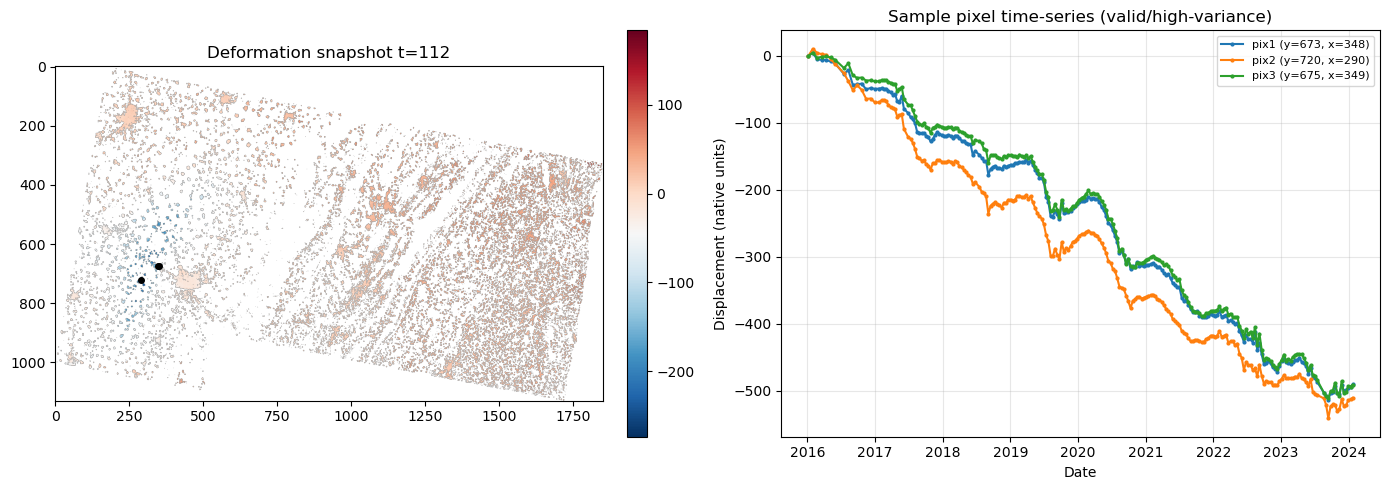

In [5]:
# Plot sample deformation map + robust sample pixel time-series from first available Punjab stack
stack_dir = next((d for d in DATA_DIRS if (d / 'disp_all_ll.h5').exists()), None)
assert stack_dir is not None, 'No Punjab stack with disp_all_ll.h5 found.'

disp_path = stack_dir / 'disp_all_ll.h5'
date_path = stack_dir / 'aquisition_dates_ll.h5'

disp_name, disp = pick_first_numeric_dataset(disp_path)
print('Using deformation dataset:', disp_name, 'shape=', disp.shape)

# Normalize axis order to (T, Y, X) if possible
arr = np.array(disp)
if arr.ndim == 2:
    arr = arr[None, :, :]
elif arr.ndim >= 3:
    if arr.shape[0] < 5 and arr.shape[-1] >= 5:
        arr = np.moveaxis(arr, -1, 0)
    elif arr.shape[0] > arr.shape[-1] and arr.shape[-1] >= 5:
        arr = np.moveaxis(arr, -1, 0)

T, H, W = arr.shape[0], arr.shape[1], arr.shape[2]
dates = read_dates_h5(date_path)
if dates is None or len(dates) < T:
    dates = pd.date_range('2000-01-01', periods=T, freq='12D')

# Compute valid-mask and temporal variance for robust pixel selection
valid_frac = np.mean(np.isfinite(arr), axis=0)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    ts_std = np.nanstd(arr, axis=0)
score = np.where(valid_frac > 0.8, ts_std, np.nan)

if np.all(~np.isfinite(score)):
    yx = [(H//2, W//2)]
else:
    flat = np.nan_to_num(score, nan=-np.inf).ravel()
    top_idx = np.argpartition(flat, -3)[-3:]
    yx = [np.unravel_index(i, (H, W)) for i in top_idx]

mid_t = T // 2
fig, ax = plt.subplots(1, 2, figsize=(14,5))
im = ax[0].imshow(arr[mid_t], cmap='RdBu_r')
for y, x in yx:
    ax[0].plot(x, y, 'ko', ms=4)
ax[0].set_title(f'Deformation snapshot t={mid_t}')
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

for i, (y, x) in enumerate(yx):
    ax[1].plot(dates[:T], arr[:T, y, x], '-o', ms=2, label=f'pix{i+1} (y={y}, x={x})')
ax[1].set_title('Sample pixel time-series (valid/high-variance)')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Displacement (native units)')
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# W3RA inventory and quick schema check (without full loading)
mat_files = sorted(W3RA_DIR.glob('W3RA_ERA5_10km_Monthly_*.mat'))
print('W3RA yearly MAT count:', len(mat_files))
print('First 5 files:')
for p in mat_files[:5]:
    print(' ', p.name)

if mat_files:
    sample = mat_files[len(mat_files)//2]
    print('\nSample MAT schema:', sample.name)
    for name, shape, typ in whosmat(str(sample)):
        print(f'  {name}: shape={shape}, class={typ}')

latlon_mat = W3RA_DIR / 'LatLon_10km.mat'
if latlon_mat.exists():
    print('\nLatLon schema:')
    for name, shape, typ in whosmat(str(latlon_mat)):
        print(f'  {name}: shape={shape}, class={typ}')

W3RA yearly MAT count: 22
First 5 files:
  W3RA_ERA5_10km_Monthly_2003.mat
  W3RA_ERA5_10km_Monthly_2004.mat
  W3RA_ERA5_10km_Monthly_2005.mat
  W3RA_ERA5_10km_Monthly_2006.mat
  W3RA_ERA5_10km_Monthly_2007.mat

Sample MAT schema: W3RA_ERA5_10km_Monthly_2014.mat
  S0_M: shape=(12, 2142930), class=double
  Sd_M: shape=(12, 2142930), class=double
  Sg_M: shape=(12, 2142930), class=double
  Sr_M: shape=(12, 2142930), class=double
  Ss_M: shape=(12, 2142930), class=double
  Ssnow_M: shape=(12, 2142930), class=double
  Stot_M: shape=(12, 2142930), class=double

LatLon schema:
  latitude: shape=(1801, 1), class=double
  longitude: shape=(3600, 1), class=double


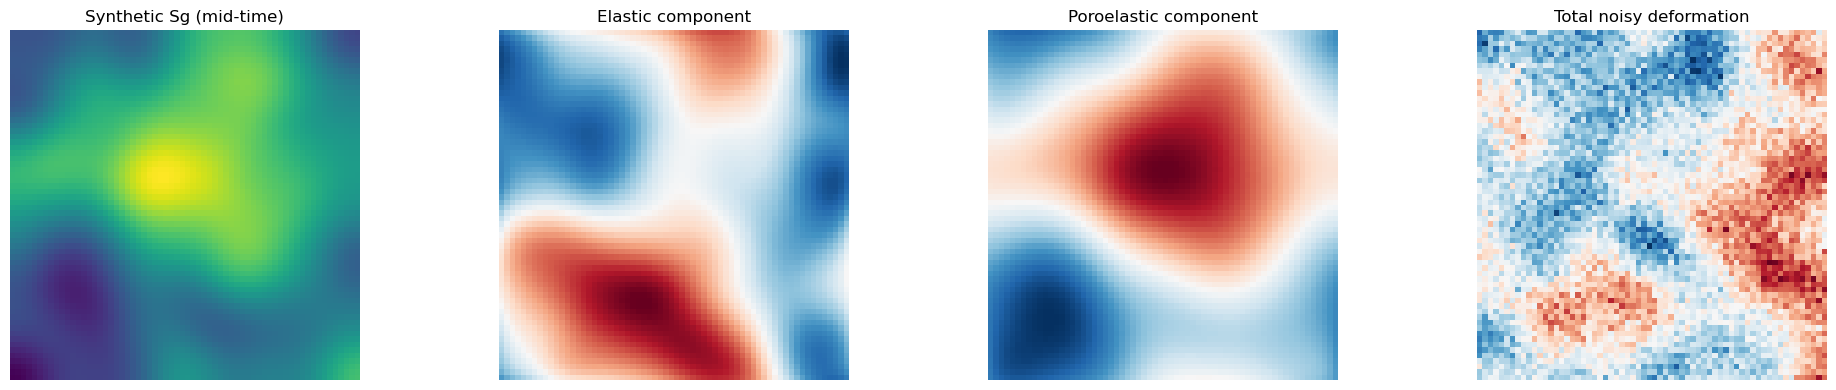

Synthetic layers shape: (108, 4, 64, 64)
Synthetic deformation shape: (108, 64, 64)


In [7]:
# Synthetic elastic + poroelastic forward-model sanity test
# Build a synthetic benchmark that matches the manuscript logic: elastic loading from S0/Ss/Sd and poroelastic response from Sg.

from dataclasses import dataclass
from scipy.ndimage import gaussian_filter
import torch

SEED = 42
T_SYN = 108
H_SYN = 64
W_SYN = 64
LAYER_NAMES = ('S0', 'Ss', 'Sd', 'Sg')
Sg_INDEX = LAYER_NAMES.index('Sg')
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


@dataclass(frozen=True)
class PhysicsConfig:
    E: float = 1e9
    nu: float = 0.25
    rho_w: float = 1000.0
    g: float = 9.81
    alpha: float = 0.8
    Hg: float = 150.0
    Seff: float = 0.2
    dx: float = 10000.0
    dy: float = 10000.0
    a_load: float = 3000.0
    a_poro: float = 3000.0


PHYSICS = PhysicsConfig()


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


def build_elastic_kernel(E, nu, dx, dy, a, nx, ny):
    xgrid = (np.arange(nx) - nx / 2) * dx
    ygrid = (np.arange(ny) - ny / 2) * dy
    xx, yy = np.meshgrid(xgrid, ygrid)
    r = np.sqrt(xx**2 + yy**2)
    r[r < 1e-6] = 1e-6
    return (1 + nu) / (np.pi * E * (1 - nu)) * (1 - np.exp(-r / a)) / r


def build_poroelastic_kernel(E, nu, alpha, hg, dx, dy, a, nx, ny):
    xgrid = (np.arange(nx) - nx / 2) * dx
    ygrid = (np.arange(ny) - ny / 2) * dy
    xx, yy = np.meshgrid(xgrid, ygrid)
    r = np.sqrt(xx**2 + yy**2)
    r[r < 1e-6] = 1e-6
    return alpha * (1 + nu) * hg * 9.81 / (np.pi * E * (1 - nu)) * (1 - np.exp(-r / a)) / r


def build_fft_kernels(ny, nx, physics, device):
    g_load = build_elastic_kernel(physics.E, physics.nu, physics.dx, physics.dy, physics.a_load, nx, ny)
    g_poro = build_poroelastic_kernel(physics.E, physics.nu, physics.alpha, physics.Hg, physics.dx, physics.dy, physics.a_poro, nx, ny)
    g_load_fft = torch.fft.fft2(torch.fft.ifftshift(torch.tensor(g_load, dtype=torch.float32, device=device)))
    g_poro_fft = torch.fft.fft2(torch.fft.ifftshift(torch.tensor(g_poro, dtype=torch.float32, device=device)))
    return g_load_fft, g_poro_fft


def fft_convolve2d(field, kernel_fft):
    return torch.fft.ifft2(torch.fft.fft2(field) * kernel_fft).real


def forward_physics_torch(y_pred, g_load_fft, g_poro_fft, physics):
    delta_l = physics.rho_w * y_pred[:, :3].sum(dim=1)
    delta_p = physics.rho_w * physics.g * (y_pred[:, Sg_INDEX] / physics.Seff)
    uz_load = fft_convolve2d(delta_l, g_load_fft)
    uz_poro = fft_convolve2d(delta_p, g_poro_fft)
    return (uz_load + uz_poro).unsqueeze(1)


def make_spatial_pattern(rng, sigma_large, sigma_small, amplitude=1.0):
    field = 0.7 * gaussian_filter(rng.normal(size=(H_SYN, W_SYN)), sigma=sigma_large)
    field += 0.3 * gaussian_filter(rng.normal(size=(H_SYN, W_SYN)), sigma=sigma_small)
    field = field - field.mean()
    field = field / (field.std() + 1e-6)
    return amplitude * field


def make_synthetic_layers():
    rng = np.random.default_rng(SEED)
    t = np.arange(T_SYN, dtype=np.float32)

    p_s0 = make_spatial_pattern(rng, sigma_large=8, sigma_small=3, amplitude=1.2)
    p_ss = make_spatial_pattern(rng, sigma_large=10, sigma_small=4, amplitude=0.9)
    p_sd = make_spatial_pattern(rng, sigma_large=12, sigma_small=5, amplitude=0.8)
    p_sg = make_spatial_pattern(rng, sigma_large=14, sigma_small=6, amplitude=1.5)

    annual = np.sin(2 * np.pi * t / 12.0)
    semi = np.sin(4 * np.pi * t / 12.0)
    interannual = np.sin(2 * np.pi * t / 36.0)
    trend = (t - t.mean()) / t.max()

    S0 = 8.0 * annual[:, None, None] * p_s0 + 1.5 * semi[:, None, None] * p_s0
    Ss = 5.0 * np.sin(2 * np.pi * (t - 1.0) / 12.0)[:, None, None] * p_ss + 1.2 * interannual[:, None, None] * p_ss
    Sd = 3.5 * np.sin(2 * np.pi * (t - 2.0) / 12.0)[:, None, None] * p_sd + 1.8 * trend[:, None, None] * p_sd
    Sg = 6.0 * np.sin(2 * np.pi * (t - 4.0) / 24.0)[:, None, None] * p_sg + 5.0 * trend[:, None, None] * p_sg

    layers = np.stack([S0, Ss, Sd, Sg], axis=1)
    layers += 0.25 * gaussian_filter(rng.normal(size=layers.shape), sigma=(0, 0, 2, 2))
    return layers.astype(np.float32)


def make_synthetic_deformation(layers, physics):
    s0 = layers[:, 0]
    ss = layers[:, 1]
    sd = layers[:, 2]
    sg = layers[:, 3]

    g_load = build_elastic_kernel(physics.E, physics.nu, physics.dx, physics.dy, physics.a_load, W_SYN, H_SYN)
    g_poro = build_poroelastic_kernel(physics.E, physics.nu, physics.alpha, physics.Hg, physics.dx, physics.dy, physics.a_poro, W_SYN, H_SYN)
    g_load_fft = np.fft.fft2(np.fft.ifftshift(g_load))
    g_poro_fft = np.fft.fft2(np.fft.ifftshift(g_poro))

    delta_l = physics.rho_w * (s0 + ss + sd)
    delta_p = physics.rho_w * physics.g * (sg / physics.Seff)

    uz_load = np.zeros((T_SYN, H_SYN, W_SYN), dtype=np.float32)
    uz_poro = np.zeros_like(uz_load)
    for i in range(T_SYN):
        uz_load[i] = np.fft.ifft2(np.fft.fft2(delta_l[i]) * g_load_fft).real.astype(np.float32)
        uz_poro[i] = np.fft.ifft2(np.fft.fft2(delta_p[i]) * g_poro_fft).real.astype(np.float32)

    uz_total = uz_load + uz_poro

    rng = np.random.default_rng(SEED + 1)
    white_noise = 0.02 * rng.normal(size=uz_total.shape)
    corr_noise = np.zeros_like(uz_total)
    for i in range(T_SYN):
        corr_noise[i] = 0.05 * make_spatial_pattern(rng, sigma_large=10, sigma_small=4, amplitude=1.0)
    seasonal_noise = 0.03 * np.sin(2 * np.pi * np.arange(T_SYN) / 12.0)[:, None, None]
    uz_noisy = uz_total + white_noise + corr_noise + seasonal_noise

    return uz_load.astype(np.float32), uz_poro.astype(np.float32), uz_total.astype(np.float32), uz_noisy.astype(np.float32)


set_seed(SEED)
layers_syn = make_synthetic_layers()
S0 = layers_syn[:, 0]
Ss = layers_syn[:, 1]
Sd = layers_syn[:, 2]
Sg = layers_syn[:, 3]
uz_load_syn, uz_poro_syn, disp_syn, disp_syn_noisy = make_synthetic_deformation(layers_syn, PHYSICS)

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
mid = T_SYN // 2
ax[0].imshow(Sg[mid], cmap='viridis'); ax[0].set_title('Synthetic Sg (mid-time)')
ax[1].imshow(uz_load_syn[mid], cmap='RdBu_r'); ax[1].set_title('Elastic component')
ax[2].imshow(uz_poro_syn[mid], cmap='RdBu_r'); ax[2].set_title('Poroelastic component')
ax[3].imshow(disp_syn_noisy[mid], cmap='RdBu_r'); ax[3].set_title('Total noisy deformation')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

print('Synthetic layers shape:', layers_syn.shape)
print('Synthetic deformation shape:', disp_syn_noisy.shape)


In [ ]:
# Physics-aware synthetic SWIN3D training with elastic + poroelastic Green's functions
# Predict S0, Ss, Sd, and Sg from deformation+S0 windows using a windowed/shifted-attention Swin-U-Net-style model.

from pathlib import Path
import copy
import sys
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

EXPECTED_PYTHON = '/home/ubuntu/anaconda3/envs/swin_env/bin/python'
if Path(sys.executable).as_posix() != EXPECTED_PYTHON:
    print(f'[WARN] Expected swin_env interpreter at {EXPECTED_PYTHON}')
    print(f'[WARN] Current interpreter: {sys.executable}')
else:
    print(f'Using swin_env interpreter: {sys.executable}')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

WINDOW_SIZE = 12
BATCH_SIZE = 4
EMBED_DIM = 48
NUM_HEADS = 4
STAGE_DEPTHS = (2, 2, 2)
PATCH_SIZE = (2, 4, 4)
MERGE_SCALE = (1, 2, 2)
WINDOW_ATTN_SIZE = (3, 4, 4)
LEARNING_RATE = 1e-4
MAX_EPOCHS = 20
PATIENCE = 5
LAMBDA_PHYS = 0.5
LAMBDA_TV = 1e-4
USE_GRACE_LOSS = False
LAMBDA_GRACE = 0.0


class WindowedSyntheticHydroDataset(Dataset):
    def __init__(self, disp, layers, window_size=12):
        disp_t = torch.tensor(disp, dtype=torch.float32)
        layers_t = torch.tensor(layers, dtype=torch.float32)

        xs, ys, us = [], [], []
        for end_idx in range(window_size - 1, disp_t.shape[0]):
            start_idx = end_idx - window_size + 1
            x_window = torch.stack([disp_t[start_idx:end_idx + 1], layers_t[start_idx:end_idx + 1, 0]], dim=0)
            xs.append(x_window)
            ys.append(layers_t[end_idx])
            us.append(disp_t[end_idx].unsqueeze(0))

        self.x = torch.stack(xs, dim=0)
        self.y = torch.stack(ys, dim=0)
        self.u_last = torch.stack(us, dim=0)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx]


class NormalizedWindowedDataset(Dataset):
    def __init__(self, base_dataset, indices, x_mean, x_std, y_mean, y_std, u_mean, u_std):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.u_mean = u_mean
        self.u_std = u_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y, u = self.base_dataset[self.indices[idx]]
        x = (x - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std
        u = (u - self.u_mean) / self.u_std
        return x, y, u


def compute_stats(ds, train_idx):
    x_train = ds.x[train_idx]
    y_train = ds.y[train_idx]
    u_train = ds.u_last[train_idx]
    x_mean = x_train.mean(dim=0)
    x_std = x_train.std(dim=0).clamp_min(1e-6)
    y_mean = y_train.mean(dim=0)
    y_std = y_train.std(dim=0).clamp_min(1e-6)
    u_mean = u_train.mean(dim=0)
    u_std = u_train.std(dim=0).clamp_min(1e-6)
    return x_mean, x_std, y_mean, y_std, u_mean, u_std


def anisotropic_total_variation(y_pred):
    dx = torch.abs(y_pred[..., :, 1:] - y_pred[..., :, :-1]).mean()
    dy = torch.abs(y_pred[..., 1:, :] - y_pred[..., :-1, :]).mean()
    return dx + dy


def window_partition_3d(x, window_size):
    b, t, h, w, c = x.shape
    wt, wh, ww = window_size
    x = x.view(b, t // wt, wt, h // wh, wh, w // ww, ww, c)
    windows = x.permute(0, 1, 3, 5, 2, 4, 6, 7).contiguous()
    return windows.view(-1, wt * wh * ww, c)


def window_reverse_3d(windows, window_size, b, t, h, w, c):
    wt, wh, ww = window_size
    x = windows.view(b, t // wt, h // wh, w // ww, wt, wh, ww, c)
    x = x.permute(0, 1, 4, 2, 5, 3, 6, 7).contiguous()
    return x.view(b, t, h, w, c)


class WindowAttention3D(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x, mask=None):
        b_windows, n_tokens, dim = x.shape
        qkv = self.qkv(x).reshape(b_windows, n_tokens, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        if mask is not None:
            n_w = mask.shape[0]
            attn = attn.view(b_windows // n_w, n_w, self.num_heads, n_tokens, n_tokens)
            attn = attn + mask.unsqueeze(0).unsqueeze(2)
            attn = attn.view(-1, self.num_heads, n_tokens, n_tokens)
        attn = torch.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(b_windows, n_tokens, dim)
        return self.proj(out)


class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


class SwinBlock3D(nn.Module):
    def __init__(self, dim, num_heads, window_size=(3, 4, 4), shift_size=(0, 0, 0)):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.shift_size = shift_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention3D(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim)

    def _attn_mask(self, t, h, w, device):
        if all(s == 0 for s in self.shift_size):
            return None
        wt, wh, ww = self.window_size
        st, sh, sw = self.shift_size
        img_mask = torch.zeros((1, t, h, w, 1), device=device)
        cnt = 0
        t_slices = (slice(0, -wt), slice(-wt, -st), slice(-st, None))
        h_slices = (slice(0, -wh), slice(-wh, -sh), slice(-sh, None))
        w_slices = (slice(0, -ww), slice(-ww, -sw), slice(-sw, None))
        for ts in t_slices:
            for hs in h_slices:
                for ws in w_slices:
                    img_mask[:, ts, hs, ws, :] = cnt
                    cnt += 1
        mask_windows = window_partition_3d(img_mask, self.window_size).view(-1, wt * wh * ww)
        attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
        attn_mask = attn_mask.masked_fill(attn_mask != 0, -100.0).masked_fill(attn_mask == 0, 0.0)
        return attn_mask

    def forward(self, x):
        b, c, t, h, w = x.shape
        x = x.permute(0, 2, 3, 4, 1).contiguous()

        wt, wh, ww = self.window_size
        pad_t = (wt - t % wt) % wt
        pad_h = (wh - h % wh) % wh
        pad_w = (ww - w % ww) % ww
        x = F.pad(x, (0, 0, 0, pad_w, 0, pad_h, 0, pad_t))
        _, tp, hp, wp, _ = x.shape

        shortcut = x
        if any(s > 0 for s in self.shift_size):
            shifted = torch.roll(x, shifts=(-self.shift_size[0], -self.shift_size[1], -self.shift_size[2]), dims=(1, 2, 3))
        else:
            shifted = x

        x_windows = window_partition_3d(shifted, self.window_size)
        x_windows = self.norm1(x_windows)
        attn_mask = self._attn_mask(tp, hp, wp, x.device)
        attn_windows = self.attn(x_windows, mask=attn_mask)
        shifted = window_reverse_3d(attn_windows, self.window_size, b, tp, hp, wp, c)

        if any(s > 0 for s in self.shift_size):
            x = torch.roll(shifted, shifts=(self.shift_size[0], self.shift_size[1], self.shift_size[2]), dims=(1, 2, 3))
        else:
            x = shifted

        x = shortcut + x
        x_flat = x.view(b, tp * hp * wp, c)
        x = x_flat + self.mlp(self.norm2(x_flat))
        x = x.view(b, tp, hp, wp, c)
        x = x[:, :t, :h, :w, :].permute(0, 4, 1, 2, 3).contiguous()
        return x


class SwinStage3D(nn.Module):
    def __init__(self, dim, depth, num_heads, window_size):
        super().__init__()
        shift = tuple(s // 2 for s in window_size)
        blocks = []
        for idx in range(depth):
            blocks.append(SwinBlock3D(dim=dim, num_heads=num_heads, window_size=window_size, shift_size=(0, 0, 0) if idx % 2 == 0 else shift))
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x


class PatchEmbed3D(nn.Module):
    def __init__(self, in_channels=2, embed_dim=48, patch_size=(2, 4, 4)):
        super().__init__()
        self.proj = nn.Conv3d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x)


class PatchMerging3D(nn.Module):
    def __init__(self, in_dim, out_dim, scale=(1, 2, 2)):
        super().__init__()
        self.reduction = nn.Conv3d(in_dim, out_dim, kernel_size=scale, stride=scale)

    def forward(self, x):
        return self.reduction(x)


class PatchExpand3D(nn.Module):
    def __init__(self, in_dim, out_dim, scale=(1, 2, 2)):
        super().__init__()
        self.expand = nn.ConvTranspose3d(in_dim, out_dim, kernel_size=scale, stride=scale)

    def forward(self, x):
        return self.expand(x)


class SwinUNetPhysicsNet3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=4):
        super().__init__()
        bottleneck_dim = EMBED_DIM * 2
        self.patch_embed = PatchEmbed3D(in_channels=in_channels, embed_dim=EMBED_DIM, patch_size=PATCH_SIZE)
        self.encoder = SwinStage3D(EMBED_DIM, STAGE_DEPTHS[0], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.patch_merge = PatchMerging3D(EMBED_DIM, bottleneck_dim, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(bottleneck_dim, STAGE_DEPTHS[1], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.patch_expand = PatchExpand3D(bottleneck_dim, EMBED_DIM, scale=MERGE_SCALE)
        self.skip_fuse = nn.Conv3d(EMBED_DIM * 2, EMBED_DIM, kernel_size=1)
        self.decoder = SwinStage3D(EMBED_DIM, STAGE_DEPTHS[2], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.output_upsample = nn.ConvTranspose3d(EMBED_DIM, EMBED_DIM // 2, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        self.output_head = nn.Conv3d(EMBED_DIM // 2, out_channels, kernel_size=1)

    def forward(self, x):
        x0 = self.patch_embed(x)
        skip = self.encoder(x0)
        z = self.patch_merge(skip)
        z = self.bottleneck(z)
        z = self.patch_expand(z)
        if z.shape[2:] != skip.shape[2:]:
            z = F.interpolate(z, size=skip.shape[2:], mode='trilinear', align_corners=False)
        z = self.skip_fuse(torch.cat([z, skip], dim=1))
        z = self.decoder(z)
        z = self.output_upsample(z)
        y = self.output_head(z)
        return y[:, :, -1]


def denormalize_targets(y_pred_norm, y_mean, y_std):
    return y_pred_norm * y_std + y_mean


def run_epoch(model, loader, g_load_fft, g_poro_fft, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_layers': 0.0, 'loss_phys': 0.0, 'loss_tv': 0.0}
    n = 0

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)

        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            layer_loss = F.mse_loss(yp_norm[:, :3], yb[:, :3]) + 2.0 * F.mse_loss(yp_norm[:, Sg_INDEX:Sg_INDEX + 1], yb[:, Sg_INDEX:Sg_INDEX + 1])
            yp_raw = denormalize_targets(yp_norm, y_mean, y_std)
            d_hat_raw = forward_physics_torch(yp_raw, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_tv = anisotropic_total_variation(yp_raw)
            loss = layer_loss + LAMBDA_PHYS * loss_phys + LAMBDA_TV * loss_tv

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_layers'] += float(layer_loss.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()

    return {k: v / max(n, 1) for k, v in running.items()}


def save_timeseries_plot(y_true, y_pred, out_path):
    pixel = (H_SYN // 2, W_SYN // 2)
    x = np.arange(y_true.shape[0])
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for ax, idx, name in zip(axes.ravel(), range(4), LAYER_NAMES):
        ax.plot(x, y_true[:, idx, pixel[0], pixel[1]], label='true', lw=2)
        ax.plot(x, y_pred[:, idx, pixel[0], pixel[1]], label='pred', lw=2, ls='--')
        ax.set_title(f'{name} @ pixel {pixel}')
        ax.grid(True, alpha=0.3)
    axes[0, 0].legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


ds = WindowedSyntheticHydroDataset(disp=disp_syn_noisy, layers=layers_syn, window_size=WINDOW_SIZE)
N = len(ds)
n_train = int(0.70 * N)
n_val = int(0.15 * N)
train_idx = np.arange(0, n_train)
val_idx = np.arange(n_train, n_train + n_val)
test_idx = np.arange(n_train + n_val, N)

x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_stats(ds, train_idx)
train_ds = NormalizedWindowedDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
val_ds = NormalizedWindowedDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
test_ds = NormalizedWindowedDataset(ds, test_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Split sizes -> train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')
print(f'Windowed input shape: {tuple(ds.x.shape)} | target shape: {tuple(ds.y.shape)}')

model = SwinUNetPhysicsNet3D(in_channels=2, out_channels=4).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
g_load_fft_t, g_poro_fft_t = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

y_mean_d = y_mean.to(DEVICE)
y_std_d = y_std.to(DEVICE)
u_mean_d = u_mean.to(DEVICE)
u_std_d = u_std.to(DEVICE)

best_val = np.inf
wait = 0
best_state = None
history = []

for epoch in range(MAX_EPOCHS):
    tr = run_epoch(model, train_dl, g_load_fft_t, g_poro_fft_t, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
    va = run_epoch(model, val_dl, g_load_fft_t, g_poro_fft_t, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
    history.append({
        'epoch': epoch + 1,
        'lr': float(opt.param_groups[0]['lr']),
        'train_loss': tr['loss'],
        'train_layers': tr['loss_layers'],
        'train_phys': tr['loss_phys'],
        'train_tv': tr['loss_tv'],
        'val_loss': va['loss'],
        'val_layers': va['loss_layers'],
        'val_phys': va['loss_phys'],
        'val_tv': va['loss_tv'],
    })
    print(
        f"Epoch {epoch + 1:02d} | lr={opt.param_groups[0]['lr']:.2e} | "
        f"train={tr['loss']:.4f} (L={tr['loss_layers']:.4f}, P={tr['loss_phys']:.4f}) | "
        f"val={va['loss']:.4f}"
    )
    if va['loss'] < best_val:
        best_val = va['loss']
        wait = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'Early stopping at epoch {epoch + 1}; best val={best_val:.4f}')
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_path = OUT_DIR / 'synthetic_training_history.csv'
best_model_path = OUT_DIR / 'swin3d_physics_best.pt'
history_df.to_csv(history_path, index=False)
torch.save(model.state_dict(), best_model_path)
display(history_df.tail())
print('Saved history:', history_path)
print('Saved checkpoint:', best_model_path)

MODEL_ARTIFACTS = {
    'model_name': 'SwinUNetPhysicsNet3D_Windowed',
    'checkpoint': str(best_model_path),
    'history_csv': str(history_path),
    'use_grace_loss': USE_GRACE_LOSS,
    'forward_model': 'elastic+poroelastic FFT Green functions',
    'normalization': 'train-split z-score for inputs, targets, and deformation residual path',
}


## Next actions

### Notebook Source Of Truth

- This notebook is the primary workflow and review surface.
- Synthetic generation, forward physics, training, metrics, and plots should all be inspectable step by step here.
- Helper `.py` files can exist, but this notebook should remain the canonical place to review the synthetic pipeline.

1. Run the synthetic forward-model sanity cell in `swin_env` and inspect the elastic vs poroelastic components.
2. Run the SWIN3D training cell and confirm the loss curves and saved checkpoint look sensible.
3. Run the synthetic gate cell and decide whether the corrected physics setup is strong enough to move toward Punjab fine-tuning.
4. Keep `USE_GRACE_LOSS = False` for now, but leave the loss hook available for later regional regularization.
5. Only move to real Punjab alignment after the synthetic gate passes.

### Corrected Runnable Spec

- Synthetic deformation is generated from explicit elastic and poroelastic Green's functions.
- Elastic loading layers: `S0`, `Ss`, `Sd`.
- Poroelastic layer: `Sg`.
- Input channels for the synthetic SWIN run: deformation plus `S0`.
- Predicted outputs for the synthetic benchmark: `S0`, `Ss`, `Sd`, `Sg`.
- Training loss: supervised layer MSE + physics consistency loss + small TV penalty.
- Physics loss path: denormalize predicted layers, reconstruct deformation through the elastic+poroelastic forward model, then compare against normalized observed deformation.
- Architecture: windowed and shifted-attention Swin-U-Net-style 3D model.


## Implementation block 1: QC export, synthetic gate metrics, and W3RA clipping smoke test

This block operationalizes the immediate implementation tasks in `STEPWISE_PLAN.md`:
1. Export Punjab HDF5 inventory/QC tables.
2. Compute synthetic gate metrics (per-layer RMSE, R2, correlation, forward residual).
3. Run a W3RA AOI clipping smoke test using an InSAR-derived bounding polygon fallback.

In [12]:
# Export Punjab HDF5 inventory and dataset-level QC summary
import json

qc_rows = []
for d in DATA_DIRS:
    for fn in ['disp_all_ll.h5', 'coh_ll.h5', 'vel_ll.h5', 'aquisition_dates_ll.h5']:
        p = d / fn
        row = {
            'stack_dir': str(d),
            'file': fn,
            'exists': bool(p.exists()),
            'datasets': 0,
            'largest_dataset': None,
            'largest_shape': None,
            'largest_dtype': None,
        }
        if p.exists():
            info = list_h5_datasets(p)
            row['datasets'] = len(info)
            if info:
                largest = sorted(info, key=lambda x: np.prod(x[1]) if len(x[1]) > 0 else 0, reverse=True)[0]
                row['largest_dataset'] = largest[0]
                row['largest_shape'] = tuple(int(v) for v in largest[1])
                row['largest_dtype'] = largest[2]
        qc_rows.append(row)

qc_df = pd.DataFrame(qc_rows)
display(qc_df)

qc_csv = OUT_DIR / 'punjab_h5_qc_inventory.csv'
qc_json = OUT_DIR / 'punjab_h5_qc_inventory.json'
qc_df.to_csv(qc_csv, index=False)
qc_json.write_text(json.dumps(qc_rows, indent=2))
print('Saved QC inventory:', qc_csv)
print('Saved QC inventory:', qc_json)

,stack_dir,file,exists,datasets,largest_dataset,largest_shape,largest_dtype
0,/mnt/data/aoi_punjab_2,disp_all_ll.h5,True,4,z,"(225, 1130, 1850)",float32
1,/mnt/data/aoi_punjab_2,coh_ll.h5,True,3,z,"(1130, 1850)",float32
2,/mnt/data/aoi_punjab_2,vel_ll.h5,True,3,z,"(1130, 1850)",float32
3,/mnt/data/aoi_punjab_2,aquisition_dates_ll.h5,True,1,acquisition_dates,"(1, 225)",object
4,/mnt/data/aoi_punjab,disp_all_ll.h5,True,4,z,"(225, 1130, 1850)",float32
5,/mnt/data/aoi_punjab,coh_ll.h5,True,3,z,"(1130, 1850)",float32
6,/mnt/data/aoi_punjab,vel_ll.h5,True,3,z,"(1130, 1850)",float32
7,/mnt/data/aoi_punjab,aquisition_dates_ll.h5,True,1,acquisition_dates,"(1, 225)",object


Saved QC inventory: /home/ubuntu/work/punjab/outputs/punjab_h5_qc_inventory.csv
Saved QC inventory: /home/ubuntu/work/punjab/outputs/punjab_h5_qc_inventory.json


In [ ]:
# Synthetic gate metrics using the corrected elastic + poroelastic forward operator
import json


def rmse(a, b):
    return float(np.sqrt(np.nanmean((a - b) ** 2)))


def r2_score_np(y_true, y_pred):
    yt = np.asarray(y_true).ravel()
    yp = np.asarray(y_pred).ravel()
    m = np.isfinite(yt) & np.isfinite(yp)
    if m.sum() < 2:
        return np.nan
    yt = yt[m]
    yp = yp[m]
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    if ss_tot == 0:
        return np.nan
    return float(1.0 - ss_res / ss_tot)


def corr_np(a, b):
    aa = np.asarray(a).ravel()
    bb = np.asarray(b).ravel()
    m = np.isfinite(aa) & np.isfinite(bb)
    if m.sum() < 2:
        return np.nan
    return float(np.corrcoef(aa[m], bb[m])[0, 1])


STRICT_GATE = False

model.eval()
with torch.no_grad():
    x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
    y_test_true = ds.y[test_idx].cpu().numpy()
    u_test_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
    y_test_pred_norm = model(x_test)
    y_test_pred = denormalize_targets(y_test_pred_norm, y_mean_d, y_std_d).cpu().numpy()
    d_test_hat = forward_physics_torch(
        torch.tensor(y_test_pred, dtype=torch.float32, device=DEVICE),
        g_load_fft_t,
        g_poro_fft_t,
        PHYSICS,
    ).cpu().numpy()[:, 0]

metric_rows = []
for i, name in enumerate(LAYER_NAMES):
    yt = y_test_true[:, i]
    yp = y_test_pred[:, i]
    metric_rows.append({
        'split': 'test',
        'layer': name,
        'rmse': rmse(yt, yp),
        'r2': r2_score_np(yt, yp),
        'corr': corr_np(yt, yp),
    })

forward_resid_rmse = rmse(u_test_true, d_test_hat)
metrics_df = pd.DataFrame(metric_rows)
metrics_df['forward_residual_rmse'] = forward_resid_rmse
metrics_df['model_name'] = MODEL_ARTIFACTS['model_name']
metrics_df['use_grace_loss'] = MODEL_ARTIFACTS['use_grace_loss']
metrics_df['forward_model'] = MODEL_ARTIFACTS['forward_model']

GATE = {
    'min_r2': {'S0': 0.40, 'Ss': 0.40, 'Sd': 0.40, 'Sg': 0.70},
    'max_rmse': {'S0': 5.00, 'Ss': 3.50, 'Sd': 2.00, 'Sg': 2.00},
    'min_corr': {'S0': 0.60, 'Ss': 0.60, 'Sd': 0.60, 'Sg': 0.85},
    'max_forward_residual_rmse': 0.80,
}

fails = []
for _, row in metrics_df.iterrows():
    layer = row['layer']
    if not np.isfinite(row['r2']) or row['r2'] < GATE['min_r2'][layer]:
        fails.append(f"{layer}: r2<{GATE['min_r2'][layer]}")
    if not np.isfinite(row['rmse']) or row['rmse'] > GATE['max_rmse'][layer]:
        fails.append(f"{layer}: rmse>{GATE['max_rmse'][layer]}")
    if not np.isfinite(row['corr']) or row['corr'] < GATE['min_corr'][layer]:
        fails.append(f"{layer}: corr<{GATE['min_corr'][layer]}")

if not np.isfinite(forward_resid_rmse) or forward_resid_rmse > GATE['max_forward_residual_rmse']:
    fails.append(f"forward_residual_rmse>{GATE['max_forward_residual_rmse']} (got {forward_resid_rmse:.4f})")

gate_pass = len(fails) == 0
metrics_df['gate_pass'] = gate_pass
display(metrics_df)

metrics_csv = OUT_DIR / 'synthetic_gate_metrics.csv'
gate_json = OUT_DIR / 'synthetic_gate_config.json'
report_json = OUT_DIR / 'synthetic_gate_report.json'
figure_path = FIG_DIR / 'synthetic_timeseries_layers_test.png'
summary_json = OUT_DIR / 'synthetic_run_summary.json'

metrics_df.to_csv(metrics_csv, index=False)
gate_json.write_text(json.dumps(GATE, indent=2))
save_timeseries_plot(y_test_true, y_test_pred, figure_path)

report = {
    'gate_pass': gate_pass,
    'strict_gate': STRICT_GATE,
    'failed_checks': fails,
    'model_name': MODEL_ARTIFACTS['model_name'],
    'use_grace_loss': bool(MODEL_ARTIFACTS['use_grace_loss']),
}
report_json.write_text(json.dumps(report, indent=2))

summary = {
    'device': DEVICE,
    'best_val_loss': float(best_val),
    'num_train_windows': int(len(train_idx)),
    'num_val_windows': int(len(val_idx)),
    'num_test_windows': int(len(test_idx)),
    'history_csv': str(MODEL_ARTIFACTS['history_csv']),
    'metrics_csv': str(metrics_csv),
    'timeseries_plot': str(figure_path),
    'checkpoint': MODEL_ARTIFACTS['checkpoint'],
    'normalization': {
        'inputs': 'train-split per-pixel/per-window-position z-score',
        'targets': 'train-split per-pixel z-score',
        'physics_loss': 'denormalized layer predictions -> elastic+poroelastic forward model -> renormalized deformation',
    },
    'forward_model': {
        'layers': list(LAYER_NAMES),
        'elastic_load_layers': ['S0', 'Ss', 'Sd'],
        'poroelastic_layers': ['Sg'],
        'implementation': "explicit elastic and poroelastic Green's functions with FFT convolution",
    },
    'architecture': {
        'type': 'windowed and shifted-attention Swin-U-Net-style 3D model',
        'window_size': WINDOW_ATTN_SIZE,
        'patch_size': PATCH_SIZE,
    },
}
summary_json.write_text(json.dumps(summary, indent=2))

print('Saved synthetic metrics:', metrics_csv)
print('Saved gate config:', gate_json)
print('Saved gate report:', report_json)
print('Saved run summary:', summary_json)
print('Saved timeseries figure:', figure_path)

GATE_STATUS = report
if fails:
    msg = 'SYNTHETIC GATE FAILED: ' + '; '.join(fails)
    if STRICT_GATE:
        raise AssertionError(msg)
    print('[WARN]', msg)
    print('[WARN] Continuing because STRICT_GATE=False (diagnostic mode).')
else:
    print('SYNTHETIC GATE PASSED')


In [ ]:
# Synthetic Sg diagnostics: maps, time series, and correlation scatter
from scipy.stats import pearsonr, spearmanr

if 'y_test_true' not in globals() or 'y_test_pred' not in globals() or 'u_test_true' not in globals() or 'd_test_hat' not in globals():
    raise RuntimeError('Run the synthetic gate cell first so test predictions and reconstructions are available.')

sg_true = y_test_true[:, Sg_INDEX]
sg_pred = y_test_pred[:, Sg_INDEX]
sg_diff = sg_pred - sg_true

sg_true_flat = sg_true.ravel()
sg_pred_flat = sg_pred.ravel()
valid = np.isfinite(sg_true_flat) & np.isfinite(sg_pred_flat)
sg_true_flat = sg_true_flat[valid]
sg_pred_flat = sg_pred_flat[valid]

sg_rmse = rmse(sg_true_flat, sg_pred_flat)
sg_mae = float(np.nanmean(np.abs(sg_pred_flat - sg_true_flat)))
sg_bias = float(np.nanmean(sg_pred_flat - sg_true_flat))
sg_r2 = r2_score_np(sg_true_flat, sg_pred_flat)
sg_pearson = float(pearsonr(sg_true_flat, sg_pred_flat).statistic)
sg_spearman = float(spearmanr(sg_true_flat, sg_pred_flat).statistic)
sg_slope, sg_intercept = np.polyfit(sg_true_flat, sg_pred_flat, deg=1)

sample_idx = min(len(sg_true) // 2, len(sg_true) - 1)
pixel = (H_SYN // 2, W_SYN // 2)
identity_min = float(np.nanmin([sg_true_flat.min(), sg_pred_flat.min()]))
identity_max = float(np.nanmax([sg_true_flat.max(), sg_pred_flat.max()]))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

im0 = axes[0, 0].imshow(sg_true[sample_idx], cmap='viridis')
axes[0, 0].set_title(f'True Sg | test sample {sample_idx}')
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(sg_pred[sample_idx], cmap='viridis')
axes[0, 1].set_title(f'Predicted Sg | test sample {sample_idx}')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

im2 = axes[0, 2].imshow(sg_diff[sample_idx], cmap='RdBu_r')
axes[0, 2].set_title('Prediction error: pred - true')
axes[0, 2].axis('off')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

axes[1, 0].plot(sg_true[:, pixel[0], pixel[1]], label='true', lw=2)
axes[1, 0].plot(sg_pred[:, pixel[0], pixel[1]], label='pred', lw=2, ls='--')
axes[1, 0].set_title(f'Sg time series at pixel {pixel}')
axes[1, 0].set_xlabel('Test window index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].scatter(sg_true_flat, sg_pred_flat, s=3, alpha=0.12)
axes[1, 1].plot([identity_min, identity_max], [identity_min, identity_max], color='black', lw=1, ls=':')
axes[1, 1].plot(
    [identity_min, identity_max],
    [sg_slope * identity_min + sg_intercept, sg_slope * identity_max + sg_intercept],
    color='tab:red',
    lw=2,
)
axes[1, 1].set_title('Sg correlation scatter')
axes[1, 1].set_xlabel('True Sg')
axes[1, 1].set_ylabel('Predicted Sg')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].text(
    0.03,
    0.97,
    '\n'.join([
        f'RMSE = {sg_rmse:.3f}',
        f'MAE = {sg_mae:.3f}',
        f'Bias = {sg_bias:.3f}',
        f'R2 = {sg_r2:.3f}',
        f'Pearson r = {sg_pearson:.3f}',
        f'Spearman rho = {sg_spearman:.3f}',
        f'Slope = {sg_slope:.3f}',
    ]),
    transform=axes[1, 1].transAxes,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
)

resid_sample = d_test_hat[sample_idx] - u_test_true[sample_idx]
im3 = axes[1, 2].imshow(resid_sample, cmap='RdBu_r')
axes[1, 2].set_title('Forward residual: d_hat - observed')
axes[1, 2].axis('off')
plt.colorbar(im3, ax=axes[1, 2], fraction=0.046)

fig.tight_layout()
plt.show()

sg_diag_path = FIG_DIR / 'synthetic_sg_diagnostics_test.png'
fig.savefig(sg_diag_path, dpi=150, bbox_inches='tight')
print('Saved Sg diagnostics figure:', sg_diag_path)

sg_diag_df = pd.DataFrame([
    {
        'metric': 'rmse', 'value': sg_rmse,
    },
    {
        'metric': 'mae', 'value': sg_mae,
    },
    {
        'metric': 'bias', 'value': sg_bias,
    },
    {
        'metric': 'r2', 'value': sg_r2,
    },
    {
        'metric': 'pearson_r', 'value': sg_pearson,
    },
    {
        'metric': 'spearman_rho', 'value': sg_spearman,
    },
    {
        'metric': 'fit_slope', 'value': float(sg_slope),
    },
    {
        'metric': 'fit_intercept', 'value': float(sg_intercept),
    },
])
display(sg_diag_df)


## TWS Sanity And SNR Sweep

This reduced benchmark tests whether the inversion pipeline can recover a single bulk storage field before attempting layer separation.

Protocol:
- define `TWS = S0 + Ss + Sd + Sg`
- forward-model deformation from `TWS` with the elastic load Green's function only
- run a controlled noise sweep: `clean`, `low`, `medium`, `current`
- compare recovery of true `TWS` and forward residuals

Interpretation:
- if the clean case fails, the inversion setup is wrong even without noise
- if the clean case works but noisy cases fail, signal-to-noise is a dominant problem
- only after this passes should `Sg` separation be trusted


In [ ]:
# TWS-only sanity benchmark with SNR sweep
import json
from torch.utils.data import Dataset, DataLoader
import copy


def forward_load_only_torch(tws_pred, g_load_fft, physics):
    delta_l = physics.rho_w * tws_pred[:, 0]
    uz_load = fft_convolve2d(delta_l, g_load_fft)
    return uz_load.unsqueeze(1)


def make_tws_clean_deformation(tws, physics):
    g_load = build_elastic_kernel(physics.E, physics.nu, physics.dx, physics.dy, physics.a_load, W_SYN, H_SYN)
    g_load_fft = np.fft.fft2(np.fft.ifftshift(g_load))
    delta_l = physics.rho_w * tws
    uz_load = np.zeros((tws.shape[0], H_SYN, W_SYN), dtype=np.float32)
    for i in range(tws.shape[0]):
        uz_load[i] = np.fft.ifft2(np.fft.fft2(delta_l[i]) * g_load_fft).real.astype(np.float32)
    return uz_load.astype(np.float32)


def make_correlated_noise_field(rng):
    return 0.05 * make_spatial_pattern(rng, sigma_large=10, sigma_small=4, amplitude=1.0)


def add_noise_to_deformation(clean_disp, noise_scale=1.0, signal_scale=1.0, seed_offset=0):
    rng = np.random.default_rng(SEED + 21 + seed_offset)
    disp = signal_scale * clean_disp
    white_noise = noise_scale * 0.02 * rng.normal(size=disp.shape)
    corr_noise = np.zeros_like(disp)
    for i in range(disp.shape[0]):
        corr_noise[i] = noise_scale * make_correlated_noise_field(rng)
    seasonal_noise = noise_scale * 0.03 * np.sin(2 * np.pi * np.arange(disp.shape[0]) / 12.0)[:, None, None]
    return (disp + white_noise + corr_noise + seasonal_noise).astype(np.float32)


class WindowedTWSDataset(Dataset):
    def __init__(self, disp, tws, window_size=12):
        disp_t = torch.tensor(disp, dtype=torch.float32)
        tws_t = torch.tensor(tws, dtype=torch.float32)
        xs, ys, us = [], [], []
        for end_idx in range(window_size - 1, disp_t.shape[0]):
            start_idx = end_idx - window_size + 1
            xs.append(disp_t[start_idx:end_idx + 1].unsqueeze(0))
            ys.append(tws_t[end_idx].unsqueeze(0))
            us.append(disp_t[end_idx].unsqueeze(0))
        self.x = torch.stack(xs, dim=0)
        self.y = torch.stack(ys, dim=0)
        self.u_last = torch.stack(us, dim=0)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx]


class NormalizedTWSDataset(Dataset):
    def __init__(self, base_dataset, indices, x_mean, x_std, y_mean, y_std, u_mean, u_std):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.u_mean = u_mean
        self.u_std = u_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y, u = self.base_dataset[self.indices[idx]]
        x = (x - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std
        u = (u - self.u_mean) / self.u_std
        return x, y, u


def compute_tws_stats(ds, train_idx):
    x_train = ds.x[train_idx]
    y_train = ds.y[train_idx]
    u_train = ds.u_last[train_idx]
    x_mean = x_train.mean(dim=0)
    x_std = x_train.std(dim=0).clamp_min(1e-6)
    y_mean = y_train.mean(dim=0)
    y_std = y_train.std(dim=0).clamp_min(1e-6)
    u_mean = u_train.mean(dim=0)
    u_std = u_train.std(dim=0).clamp_min(1e-6)
    return x_mean, x_std, y_mean, y_std, u_mean, u_std


def run_tws_epoch(model, loader, g_load_fft, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_tws': 0.0, 'loss_phys': 0.0, 'loss_tv': 0.0}
    n = 0

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_tws = F.mse_loss(yp_norm, yb)
            yp_raw = yp_norm * y_std + y_mean
            d_hat_raw = forward_load_only_torch(yp_raw, g_load_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_tv = anisotropic_total_variation(yp_raw)
            loss = loss_tws + LAMBDA_PHYS * loss_phys + LAMBDA_TV * loss_tv
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_tws'] += float(loss_tws.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()
    return {k: v / max(n, 1) for k, v in running.items()}


def save_tws_case_plot(tag, y_true, y_pred, out_path):
    pixel = (H_SYN // 2, W_SYN // 2)
    x = np.arange(y_true.shape[0])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    im0 = axes[0].imshow(y_pred[len(y_pred) // 2, 0] - y_true[len(y_true) // 2, 0], cmap='RdBu_r')
    axes[0].set_title(f'{tag}: TWS error map')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    axes[1].plot(x, y_true[:, 0, pixel[0], pixel[1]], label='true', lw=2)
    axes[1].plot(x, y_pred[:, 0, pixel[0], pixel[1]], label='pred', lw=2, ls='--')
    axes[1].set_title(f'{tag}: TWS time series @ {pixel}')
    axes[1].set_xlabel('Test window index')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def run_tws_experiment(tag, noisy_disp, clean_disp, max_epochs=8):
    tws_true = layers_syn.sum(axis=1).astype(np.float32)
    ds = WindowedTWSDataset(noisy_disp, tws_true, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_tws_stats(ds, train_idx)
    train_ds = NormalizedTWSDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedTWSDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, _ = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    wait = 0
    patience = min(PATIENCE, max_epochs)
    best_state = None
    history = []

    for epoch in range(max_epochs):
        tr = run_tws_epoch(model, train_dl, g_load_fft, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_tws_epoch(model, val_dl, g_load_fft, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_load_only_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft, PHYSICS).cpu().numpy()[:, 0]

    yt = y_true[:, 0].ravel()
    yp = y_pred[:, 0].ravel()
    m = np.isfinite(yt) & np.isfinite(yp)
    yt = yt[m]
    yp = yp[m]
    slope, intercept = np.polyfit(yt, yp, deg=1)
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    r2 = np.nan if ss_tot == 0 else float(1.0 - ss_res / ss_tot)
    corr = float(np.corrcoef(yt, yp)[0, 1]) if yt.size > 1 else np.nan
    rmse = float(np.sqrt(np.nanmean((yt - yp) ** 2)))
    mae = float(np.nanmean(np.abs(yt - yp)))
    bias = float(np.nanmean(yp - yt))
    denom = float(np.nanstd(yt))
    nrmse = rmse / denom if denom > 1e-6 else np.nan
    fwd_rmse = float(np.sqrt(np.nanmean((u_true - u_hat) ** 2)))

    fig_path = FIG_DIR / f'synthetic_tws_{tag}_diagnostics.png'
    save_tws_case_plot(tag, y_true, y_pred, fig_path)

    return {
        'case': tag,
        'rmse': rmse,
        'mae': mae,
        'bias': bias,
        'nrmse': nrmse,
        'r2': r2,
        'corr': corr,
        'fit_slope': float(slope),
        'fit_intercept': float(intercept),
        'forward_residual_rmse': fwd_rmse,
        'best_val_loss': float(best_val),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
        'figure': str(fig_path),
        'history': history,
    }


TWS_TRUE = layers_syn.sum(axis=1).astype(np.float32)
TWS_CLEAN = make_tws_clean_deformation(TWS_TRUE, PHYSICS)

SNR_CASES = [
    {'case': 'clean', 'noise_scale': 0.0, 'signal_scale': 1.0},
    {'case': 'low_noise', 'noise_scale': 0.25, 'signal_scale': 1.0},
    {'case': 'medium_noise', 'noise_scale': 0.5, 'signal_scale': 1.0},
    {'case': 'current_noise', 'noise_scale': 1.0, 'signal_scale': 1.0},
]

sweep_rows = []
for idx, cfg in enumerate(SNR_CASES):
    print(f"Running TWS sanity case: {cfg['case']} | noise_scale={cfg['noise_scale']} | signal_scale={cfg['signal_scale']}")
    noisy = add_noise_to_deformation(TWS_CLEAN, noise_scale=cfg['noise_scale'], signal_scale=cfg['signal_scale'], seed_offset=idx)
    result = run_tws_experiment(cfg['case'], noisy, TWS_CLEAN, max_epochs=8)
    result['noise_scale'] = cfg['noise_scale']
    result['signal_scale'] = cfg['signal_scale']
    sweep_rows.append(result)

sweep_df = pd.DataFrame([{k: v for k, v in row.items() if k not in {'history', 'figure'}} for row in sweep_rows])
display(sweep_df)

sweep_csv = OUT_DIR / 'synthetic_tws_snr_sweep_metrics.csv'
sweep_json = OUT_DIR / 'synthetic_tws_snr_sweep_summary.json'
sweep_df.to_csv(sweep_csv, index=False)
sweep_json.write_text(json.dumps(sweep_rows, indent=2))
print('Saved TWS SNR sweep metrics:', sweep_csv)
print('Saved TWS SNR sweep summary:', sweep_json)


## Sg-Only Sanity Benchmark

This benchmark removes multi-layer ambiguity and tests only groundwater inversion.

Protocol:
- generate deformation from groundwater only: `d = G_p S_g`
- train the model to predict only `Sg`
- run `no_noise` first, then `low_noise`
- keep the same windowing, normalization, and SWIN-U-Net-style architecture

Interpretation:
- if `Sg`-only works, the main problem in the full inversion is multi-layer degeneracy
- if `Sg`-only still fails, the main problem is the inversion setup itself: scaling, loss design, or architecture


In [ ]:
# Sg-only sanity benchmark: d = G_p Sg, predict Sg only, test no-noise and low-noise
import json
from torch.utils.data import Dataset, DataLoader
import copy


def forward_sg_only_torch(sg_pred, g_poro_fft, physics):
    delta_p = physics.rho_w * physics.g * (sg_pred[:, 0] / physics.Seff)
    uz_poro = fft_convolve2d(delta_p, g_poro_fft)
    return uz_poro.unsqueeze(1)


def make_sg_only_clean_deformation(sg, physics):
    g_poro = build_poroelastic_kernel(physics.E, physics.nu, physics.alpha, physics.Hg, physics.dx, physics.dy, physics.a_poro, W_SYN, H_SYN)
    g_poro_fft = np.fft.fft2(np.fft.ifftshift(g_poro))
    delta_p = physics.rho_w * physics.g * (sg / physics.Seff)
    uz_poro = np.zeros((sg.shape[0], H_SYN, W_SYN), dtype=np.float32)
    for i in range(sg.shape[0]):
        uz_poro[i] = np.fft.ifft2(np.fft.fft2(delta_p[i]) * g_poro_fft).real.astype(np.float32)
    return uz_poro.astype(np.float32)


def add_sg_noise(clean_disp, noise_scale=0.0, seed_offset=0):
    rng = np.random.default_rng(SEED + 41 + seed_offset)
    white_noise = noise_scale * 0.02 * rng.normal(size=clean_disp.shape)
    corr_noise = np.zeros_like(clean_disp)
    for i in range(clean_disp.shape[0]):
        corr_noise[i] = noise_scale * 0.05 * make_spatial_pattern(rng, sigma_large=10, sigma_small=4, amplitude=1.0)
    seasonal_noise = noise_scale * 0.03 * np.sin(2 * np.pi * np.arange(clean_disp.shape[0]) / 12.0)[:, None, None]
    return (clean_disp + white_noise + corr_noise + seasonal_noise).astype(np.float32)


class WindowedSgDataset(Dataset):
    def __init__(self, disp, sg, window_size=12):
        disp_t = torch.tensor(disp, dtype=torch.float32)
        sg_t = torch.tensor(sg, dtype=torch.float32)
        xs, ys, us = [], [], []
        for end_idx in range(window_size - 1, disp_t.shape[0]):
            start_idx = end_idx - window_size + 1
            xs.append(disp_t[start_idx:end_idx + 1].unsqueeze(0))
            ys.append(sg_t[end_idx].unsqueeze(0))
            us.append(disp_t[end_idx].unsqueeze(0))
        self.x = torch.stack(xs, dim=0)
        self.y = torch.stack(ys, dim=0)
        self.u_last = torch.stack(us, dim=0)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx]


class NormalizedSgDataset(Dataset):
    def __init__(self, base_dataset, indices, x_mean, x_std, y_mean, y_std, u_mean, u_std):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.u_mean = u_mean
        self.u_std = u_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y, u = self.base_dataset[self.indices[idx]]
        x = (x - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std
        u = (u - self.u_mean) / self.u_std
        return x, y, u


def compute_sg_stats(ds, train_idx):
    x_train = ds.x[train_idx]
    y_train = ds.y[train_idx]
    u_train = ds.u_last[train_idx]
    x_mean = x_train.mean(dim=0)
    x_std = x_train.std(dim=0).clamp_min(1e-6)
    y_mean = y_train.mean(dim=0)
    y_std = y_train.std(dim=0).clamp_min(1e-6)
    u_mean = u_train.mean(dim=0)
    u_std = u_train.std(dim=0).clamp_min(1e-6)
    return x_mean, x_std, y_mean, y_std, u_mean, u_std


def run_sg_epoch(model, loader, g_poro_fft, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_sg': 0.0, 'loss_phys': 0.0, 'loss_tv': 0.0}
    n = 0

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_sg = F.mse_loss(yp_norm, yb)
            yp_raw = yp_norm * y_std + y_mean
            d_hat_raw = forward_sg_only_torch(yp_raw, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_tv = anisotropic_total_variation(yp_raw)
            loss = loss_sg + LAMBDA_PHYS * loss_phys + LAMBDA_TV * loss_tv
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_sg'] += float(loss_sg.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()
    return {k: v / max(n, 1) for k, v in running.items()}


def save_sg_only_plot(tag, y_true, y_pred, out_path):
    pixel = (H_SYN // 2, W_SYN // 2)
    x = np.arange(y_true.shape[0])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    im0 = axes[0].imshow(y_pred[len(y_pred) // 2, 0] - y_true[len(y_true) // 2, 0], cmap='RdBu_r')
    axes[0].set_title(f'{tag}: Sg error map')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    axes[1].plot(x, y_true[:, 0, pixel[0], pixel[1]], label='true', lw=2)
    axes[1].plot(x, y_pred[:, 0, pixel[0], pixel[1]], label='pred', lw=2, ls='--')
    axes[1].set_title(f'{tag}: Sg time series @ {pixel}')
    axes[1].set_xlabel('Test window index')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def run_sg_only_experiment(tag, noisy_disp, max_epochs=8):
    sg_true = layers_syn[:, Sg_INDEX].astype(np.float32)
    ds = WindowedSgDataset(noisy_disp, sg_true, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_sg_stats(ds, train_idx)
    train_ds = NormalizedSgDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedSgDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    _, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    wait = 0
    patience = min(PATIENCE, max_epochs)
    best_state = None
    history = []

    for epoch in range(max_epochs):
        tr = run_sg_epoch(model, train_dl, g_poro_fft, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_sg_epoch(model, val_dl, g_poro_fft, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_sg_only_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_poro_fft, PHYSICS).cpu().numpy()[:, 0]

    yt = y_true[:, 0].ravel()
    yp = y_pred[:, 0].ravel()
    m = np.isfinite(yt) & np.isfinite(yp)
    yt = yt[m]
    yp = yp[m]
    slope, intercept = np.polyfit(yt, yp, deg=1)
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    r2 = np.nan if ss_tot == 0 else float(1.0 - ss_res / ss_tot)
    corr = float(np.corrcoef(yt, yp)[0, 1]) if yt.size > 1 else np.nan
    rmse = float(np.sqrt(np.nanmean((yt - yp) ** 2)))
    fwd_rmse = float(np.sqrt(np.nanmean((u_true - u_hat) ** 2)))

    fig_path = FIG_DIR / f'synthetic_sg_only_{tag}_diagnostics.png'
    save_sg_only_plot(tag, y_true, y_pred, fig_path)

    return {
        'case': tag,
        'rmse': rmse,
        'r2': r2,
        'corr': corr,
        'fit_slope': float(slope),
        'fit_intercept': float(intercept),
        'forward_residual_rmse': fwd_rmse,
        'best_val_loss': float(best_val),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
        'figure': str(fig_path),
        'history': history,
    }


SG_TRUE = layers_syn[:, Sg_INDEX].astype(np.float32)
SG_CLEAN = make_sg_only_clean_deformation(SG_TRUE, PHYSICS)
SG_CASES = [
    {'case': 'no_noise', 'noise_scale': 0.0},
    {'case': 'low_noise', 'noise_scale': 0.25},
]

sg_only_rows = []
for idx, cfg in enumerate(SG_CASES):
    print(f"Running Sg-only sanity case: {cfg['case']} | noise_scale={cfg['noise_scale']}")
    noisy = add_sg_noise(SG_CLEAN, noise_scale=cfg['noise_scale'], seed_offset=idx)
    result = run_sg_only_experiment(cfg['case'], noisy, max_epochs=8)
    result['noise_scale'] = cfg['noise_scale']
    sg_only_rows.append(result)

sg_only_df = pd.DataFrame([{k: v for k, v in row.items() if k not in {'history', 'figure'}} for row in sg_only_rows])
display(sg_only_df)

sg_only_csv = OUT_DIR / 'synthetic_sg_only_metrics.csv'
sg_only_json = OUT_DIR / 'synthetic_sg_only_summary.json'
sg_only_df.to_csv(sg_only_csv, index=False)
sg_only_json.write_text(json.dumps(sg_only_rows, indent=2))
print('Saved Sg-only metrics:', sg_only_csv)
print('Saved Sg-only summary:', sg_only_json)


## Sg-Only Improved SWIN Benchmark

This benchmark keeps the same SWIN architecture and windowing, but changes the training setup to improve conditioning.

Training target and normalization:
- `Sg* = (Sg - mu_train) / sigma_train`
- `d* = (d - mu_train^d) / sigma_train^d`

Improved loss:
- `L = w_state L_state + lambda_fwd(e) L_fwd + lambda_corr L_corr + lambda_var L_var + lambda_tv L_tv`
- `L_state = MSE(Sg_hat*, Sg*)`
- `L_fwd = MSE(d_hat*, d*)`
- `L_corr = 1 - corr(Sg_hat, Sg)`
- `L_var = (std(Sg_hat) - std(Sg))^2`
- `lambda_fwd(e)` ramps up over the first few epochs instead of dominating immediately

Extra diagnostic:
- a tiny clean-sample overfit test to check whether the SWIN setup can memorize a few `Sg` windows at all


In [ ]:
# Sg-only improved SWIN benchmark: state-first loss, correlation/amplitude penalties, and tiny-sample overfit
import json
from torch.utils.data import DataLoader
import copy

if 'SG_CLEAN' not in globals() or 'add_sg_noise' not in globals() or 'WindowedSgDataset' not in globals():
    raise RuntimeError('Run the Sg-only sanity benchmark cell first so the clean Sg dataset helpers are available.')

SG_IMPROVED_CASES = [
    {'case': 'no_noise_improved', 'noise_scale': 0.0},
    {'case': 'very_low_noise_improved', 'noise_scale': 0.05},
    {'case': 'low_noise_improved', 'noise_scale': 0.10},
    {'case': 'reference_noise_improved', 'noise_scale': 0.25},
]

SG_IMPROVED_WEIGHTS = {
    'state': 1.50,
    'forward_max': 0.02,
    'corr': 0.30,
    'amp': 0.30,
    'tv': 1.0e-4,
}
SG_FORWARD_WARMUP_EPOCHS = 6
SG_IMPROVED_EPOCHS = 16
SG_TINY_OVERFIT_SAMPLES = 8
SG_TINY_OVERFIT_EPOCHS = 80
SG_CURRICULUM_STAGE_EPOCHS = [16, 12, 12, 12]


def batch_corr_loss(pred, target, eps=1e-6):
    pred_flat = pred.view(pred.shape[0], -1)
    tgt_flat = target.view(target.shape[0], -1)
    pred_centered = pred_flat - pred_flat.mean(dim=1, keepdim=True)
    tgt_centered = tgt_flat - tgt_flat.mean(dim=1, keepdim=True)
    numerator = (pred_centered * tgt_centered).sum(dim=1)
    denominator = torch.sqrt((pred_centered.pow(2).sum(dim=1) + eps) * (tgt_centered.pow(2).sum(dim=1) + eps))
    corr = numerator / denominator.clamp_min(eps)
    return 1.0 - corr.mean()


def amplitude_penalty(pred, target, eps=1e-6):
    pred_flat = pred.view(pred.shape[0], -1)
    tgt_flat = target.view(target.shape[0], -1)
    pred_std = pred_flat.std(dim=1).clamp_min(eps)
    tgt_std = tgt_flat.std(dim=1).clamp_min(eps)
    pred_range = (pred_flat.max(dim=1).values - pred_flat.min(dim=1).values).clamp_min(eps)
    tgt_range = (tgt_flat.max(dim=1).values - tgt_flat.min(dim=1).values).clamp_min(eps)
    std_term = (torch.log(pred_std) - torch.log(tgt_std)).pow(2)
    range_term = (torch.log(pred_range) - torch.log(tgt_range)).pow(2)
    return (std_term + 0.5 * range_term).mean()


def lambda_forward(epoch_idx, warmup_epochs, lambda_max):
    if warmup_epochs <= 0:
        return lambda_max
    progress = min((epoch_idx + 1) / warmup_epochs, 1.0)
    return lambda_max * progress


def run_sg_improved_epoch(model, loader, g_poro_fft, epoch_idx, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state': 0.0, 'loss_phys': 0.0, 'loss_corr': 0.0, 'loss_amp': 0.0, 'loss_tv': 0.0}
    n = 0
    lambda_fwd_now = lambda_forward(epoch_idx, SG_FORWARD_WARMUP_EPOCHS, SG_IMPROVED_WEIGHTS['forward_max'])

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_state = F.mse_loss(yp_norm, yb)
            yp_raw = yp_norm * y_std + y_mean
            yb_raw = yb * y_std + y_mean
            d_hat_raw = forward_sg_only_torch(yp_raw, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr = batch_corr_loss(yp_raw, yb_raw)
            loss_amp = amplitude_penalty(yp_raw, yb_raw)
            loss_tv = anisotropic_total_variation(yp_raw)
            loss = (
                SG_IMPROVED_WEIGHTS['state'] * loss_state
                + lambda_fwd_now * loss_phys
                + SG_IMPROVED_WEIGHTS['corr'] * loss_corr
                + SG_IMPROVED_WEIGHTS['amp'] * loss_amp
                + SG_IMPROVED_WEIGHTS['tv'] * loss_tv
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state'] += float(loss_state.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr'] += float(loss_corr.item()) * bsz
        running['loss_amp'] += float(loss_amp.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()

    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    return out


def summarize_regression_metrics(y_true, y_pred, u_true, u_hat):
    yt = y_true[:, 0].ravel()
    yp = y_pred[:, 0].ravel()
    m = np.isfinite(yt) & np.isfinite(yp)
    yt = yt[m]
    yp = yp[m]
    slope, intercept = np.polyfit(yt, yp, deg=1)
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    r2 = np.nan if ss_tot == 0 else float(1.0 - ss_res / ss_tot)
    corr = float(np.corrcoef(yt, yp)[0, 1]) if yt.size > 1 else np.nan
    rmse = float(np.sqrt(np.nanmean((yt - yp) ** 2)))
    mae = float(np.nanmean(np.abs(yt - yp)))
    bias = float(np.nanmean(yp - yt))
    denom = float(np.nanstd(yt))
    nrmse = rmse / denom if denom > 1e-6 else np.nan
    fwd_rmse = float(np.sqrt(np.nanmean((u_true - u_hat) ** 2)))
    return {
        'rmse': rmse,
        'mae': mae,
        'bias': bias,
        'nrmse': nrmse,
        'r2': r2,
        'corr': corr,
        'fit_slope': float(slope),
        'fit_intercept': float(intercept),
        'forward_residual_rmse': fwd_rmse,
    }


def train_sg_improved_case(tag, noise_scale, max_epochs=SG_IMPROVED_EPOCHS, initial_state=None, return_state=False, training_mode='independent'):
    sg_true = layers_syn[:, Sg_INDEX].astype(np.float32)
    noisy = add_sg_noise(SG_CLEAN, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 3)
    ds = WindowedSgDataset(noisy, sg_true, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_sg_stats(ds, train_idx)
    train_ds = NormalizedSgDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedSgDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=1).to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    _, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []

    for epoch in range(max_epochs):
        tr = run_sg_improved_epoch(model, train_dl, g_poro_fft, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_sg_improved_epoch(model, val_dl, g_poro_fft, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_sg_only_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_poro_fft, PHYSICS).cpu().numpy()[:, 0]

    metrics = summarize_regression_metrics(y_true, y_pred, u_true, u_hat)
    metrics.update({
        'case': tag,
        'noise_scale': noise_scale,
        'best_val_loss': float(best_val),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
        'training_mode': training_mode,
        'epochs_completed': int(len(history)),
    })
    if return_state:
        return metrics, history, copy.deepcopy(model.state_dict())
    return metrics, history


def run_tiny_clean_overfit(num_samples=SG_TINY_OVERFIT_SAMPLES, max_epochs=SG_TINY_OVERFIT_EPOCHS):
    sg_true = layers_syn[:, Sg_INDEX].astype(np.float32)
    ds = WindowedSgDataset(SG_CLEAN, sg_true, window_size=WINDOW_SIZE)
    idx = np.arange(0, min(num_samples, len(ds)))
    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_sg_stats(ds, idx)
    tiny_ds = NormalizedSgDataset(ds, idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    tiny_dl = DataLoader(tiny_ds, batch_size=min(BATCH_SIZE, len(tiny_ds)), shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    _, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    history = []
    for epoch in range(max_epochs):
        tr = run_sg_improved_epoch(model, tiny_dl, g_poro_fft, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr})

    with torch.no_grad():
        x_tiny = ((ds.x[idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[idx].cpu().numpy()
        u_true = ds.u_last[idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_tiny)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_sg_only_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_poro_fft, PHYSICS).cpu().numpy()[:, 0]

    metrics = summarize_regression_metrics(y_true, y_pred, u_true, u_hat)
    metrics.update({'case': 'tiny_clean_overfit', 'noise_scale': 0.0, 'num_train_windows': int(len(idx)), 'num_test_windows': int(len(idx)), 'training_mode': 'diagnostic'})
    return metrics, history


sg_improved_rows = []
sg_improved_history = {}
for cfg in SG_IMPROVED_CASES:
    print(f"Running improved Sg-only case: {cfg['case']} | noise_scale={cfg['noise_scale']}")
    metrics, history = train_sg_improved_case(cfg['case'], cfg['noise_scale'])
    sg_improved_rows.append(metrics)
    sg_improved_history[cfg['case']] = history

tiny_metrics, tiny_history = run_tiny_clean_overfit()
sg_improved_rows.append(tiny_metrics)
sg_improved_history['tiny_clean_overfit'] = tiny_history

sg_improved_df = pd.DataFrame(sg_improved_rows)
display(sg_improved_df)

sg_improved_csv = OUT_DIR / 'synthetic_sg_only_improved_metrics.csv'
sg_improved_json = OUT_DIR / 'synthetic_sg_only_improved_summary.json'
sg_improved_df.to_csv(sg_improved_csv, index=False)
sg_improved_json.write_text(json.dumps({'metrics': sg_improved_rows, 'history': sg_improved_history}, indent=2))
print('Saved improved Sg-only metrics:', sg_improved_csv)
print('Saved improved Sg-only summary:', sg_improved_json)


## Sg-Only Improved Results Summary

This section tabulates the improved `Sg`-only benchmark and plots how inversion quality changes with noise level.

Displayed metrics:
- `RMSE`
- `R^2`
- correlation
- fitted slope

Noise level is shown on the horizontal axis with both line and step-style curves.


In [ ]:
# Tabulate and plot improved Sg-only metrics versus noise level
sg_improved_metrics_path = OUT_DIR / 'synthetic_sg_only_improved_metrics.csv'
if 'sg_improved_df' in globals():
    sg_plot_df = sg_improved_df.copy()
else:
    sg_plot_df = pd.read_csv(sg_improved_metrics_path)

display_cols = [
    'case', 'noise_scale', 'rmse', 'r2', 'corr', 'fit_slope',
    'forward_residual_rmse', 'best_val_loss', 'num_train_windows', 'num_test_windows'
]
display(sg_plot_df[display_cols].sort_values(['noise_scale', 'case']).reset_index(drop=True))

noise_curve_df = sg_plot_df[sg_plot_df['case'] != 'tiny_clean_overfit'].copy()
noise_curve_df = noise_curve_df.sort_values('noise_scale').reset_index(drop=True)
noise_curve_df['noise_label'] = noise_curve_df['noise_scale'].map(lambda x: f'{x:.2f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metric_specs = [
    ('rmse', 'RMSE', 'tab:red'),
    ('r2', 'R^2', 'tab:blue'),
    ('corr', 'Correlation', 'tab:green'),
    ('fit_slope', 'Slope', 'tab:purple'),
]

x = noise_curve_df['noise_scale'].to_numpy()
for ax, (col, title, color) in zip(axes.ravel(), metric_specs):
    y = noise_curve_df[col].to_numpy()
    ax.plot(x, y, marker='o', lw=2.5, color=color)
    ax.step(x, y, where='post', lw=1.5, color=color, alpha=0.7)
    for xi, yi, lbl in zip(x, y, noise_curve_df['noise_label']):
        ax.annotate(lbl, (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Noise scale')
    ax.grid(True, alpha=0.3)
    if col in {'r2', 'corr', 'fit_slope'}:
        ax.axhline(0.0, color='black', lw=1, ls=':')
    if col == 'fit_slope':
        ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)

fig.suptitle('Improved Sg-only inversion metrics versus noise level', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()

sg_report_fig = FIG_DIR / 'synthetic_sg_only_improved_noise_metrics.png'
fig.savefig(sg_report_fig, dpi=150, bbox_inches='tight')
print('Saved improved Sg-only noise-metrics figure:', sg_report_fig)

tiny_overfit_df = sg_plot_df[sg_plot_df['case'] == 'tiny_clean_overfit'].copy()
if not tiny_overfit_df.empty:
    print('\nTiny overfit reference')
    display(tiny_overfit_df[display_cols].reset_index(drop=True))


## Sg-Only Curriculum Training

This section keeps the same improved `Sg`-only loss and architecture, but trains in stages across increasing noise levels.

Stage order:
1. `0.00` noise
2. `0.05` noise
3. `0.10` noise
4. `0.25` noise

Each stage warm-starts from the previous stage's best weights. This tests whether learning the inverse map cleanly first improves robustness when we introduce noise gradually.


In [ ]:
# Sg-only curriculum benchmark: warm-start across increasing noise levels
SG_CURRICULUM_CASES = [
    {'case': 'curriculum_stage_0p00', 'noise_scale': 0.00, 'epochs': SG_CURRICULUM_STAGE_EPOCHS[0]},
    {'case': 'curriculum_stage_0p05', 'noise_scale': 0.05, 'epochs': SG_CURRICULUM_STAGE_EPOCHS[1]},
    {'case': 'curriculum_stage_0p10', 'noise_scale': 0.10, 'epochs': SG_CURRICULUM_STAGE_EPOCHS[2]},
    {'case': 'curriculum_stage_0p25', 'noise_scale': 0.25, 'epochs': SG_CURRICULUM_STAGE_EPOCHS[3]},
]

sg_curriculum_rows = []
sg_curriculum_history = {}
prev_state = None
prev_case = None
for cfg in SG_CURRICULUM_CASES:
    print(f"Running curriculum stage: {cfg['case']} | noise_scale={cfg['noise_scale']} | epochs={cfg['epochs']}")
    metrics, history, prev_state = train_sg_improved_case(
        cfg['case'],
        cfg['noise_scale'],
        max_epochs=cfg['epochs'],
        initial_state=prev_state,
        return_state=True,
        training_mode='curriculum',
    )
    metrics['warm_start_from'] = prev_case or 'scratch'
    sg_curriculum_rows.append(metrics)
    sg_curriculum_history[cfg['case']] = history
    prev_case = cfg['case']

sg_curriculum_df = pd.DataFrame(sg_curriculum_rows)
display(sg_curriculum_df)

sg_curriculum_csv = OUT_DIR / 'synthetic_sg_only_curriculum_metrics.csv'
sg_curriculum_json = OUT_DIR / 'synthetic_sg_only_curriculum_summary.json'
sg_curriculum_df.to_csv(sg_curriculum_csv, index=False)
sg_curriculum_json.write_text(json.dumps({'metrics': sg_curriculum_rows, 'history': sg_curriculum_history}, indent=2))
print('Saved Sg-only curriculum metrics:', sg_curriculum_csv)
print('Saved Sg-only curriculum summary:', sg_curriculum_json)


## Sg-Only Curriculum Results Summary

The improved `Sg`-only benchmark keeps the same normalized target and loss,
but changes the training path from independent runs to staged warm-start training.

Loss used at each stage:
- `L = w_state L_state + lambda_fwd(e) L_fwd + lambda_corr L_corr + lambda_amp L_amp + lambda_tv L_tv`
- `L_state = MSE(Sg_hat*, Sg*)`
- `L_fwd = MSE(d_hat*, d*)`
- `L_corr = 1 - corr(Sg_hat, Sg)`
- `L_amp` matches predicted and true amplitude using spread and range penalties

Curriculum schedule:
- `theta_0 = Train(noise=0.00, init=scratch)`
- `theta_1 = Train(noise=0.05, init=theta_0)`
- `theta_2 = Train(noise=0.10, init=theta_1)`
- `theta_3 = Train(noise=0.25, init=theta_2)`

Improvement is summarized relative to the independent-per-noise baseline:
- `Delta RMSE = RMSE_independent - RMSE_curriculum`  (positive is better)
- `Delta R^2 = R^2_curriculum - R^2_independent`     (positive is better)
- `Delta corr = corr_curriculum - corr_independent`  (positive is better)
- `Delta slope = slope_curriculum - slope_independent` (positive is better)

The updated plots below show both the absolute curves and the curriculum gain at each noise level.


In [ ]:
# Tabulate and compare curriculum versus independent improved Sg-only metrics
sg_improved_metrics_path = OUT_DIR / 'synthetic_sg_only_improved_metrics.csv'
sg_curriculum_metrics_path = OUT_DIR / 'synthetic_sg_only_curriculum_metrics.csv'

if 'sg_improved_df' in globals():
    base_df = sg_improved_df.copy()
else:
    base_df = pd.read_csv(sg_improved_metrics_path)

if 'sg_curriculum_df' in globals():
    curriculum_df = sg_curriculum_df.copy()
else:
    curriculum_df = pd.read_csv(sg_curriculum_metrics_path)

base_noise_df = base_df[(base_df['training_mode'] == 'independent') & (base_df['case'] != 'tiny_clean_overfit')].copy()
base_noise_df['series'] = 'independent'
curriculum_df = curriculum_df.copy()
curriculum_df['series'] = 'curriculum'
compare_df = pd.concat([base_noise_df, curriculum_df], ignore_index=True, sort=False)
compare_df = compare_df.sort_values(['noise_scale', 'series']).reset_index(drop=True)

summary_cols = [
    'series', 'case', 'noise_scale', 'rmse', 'r2', 'corr', 'fit_slope',
    'forward_residual_rmse', 'best_val_loss', 'epochs_completed', 'warm_start_from'
]
display(compare_df[[c for c in summary_cols if c in compare_df.columns]])

ind_df = base_noise_df[['noise_scale', 'rmse', 'r2', 'corr', 'fit_slope']].copy().rename(columns={
    'rmse': 'rmse_ind', 'r2': 'r2_ind', 'corr': 'corr_ind', 'fit_slope': 'fit_slope_ind'
})
cur_df = curriculum_df[['noise_scale', 'rmse', 'r2', 'corr', 'fit_slope']].copy().rename(columns={
    'rmse': 'rmse_curr', 'r2': 'r2_curr', 'corr': 'corr_curr', 'fit_slope': 'fit_slope_curr'
})
improvement_df = ind_df.merge(cur_df, on='noise_scale', how='inner').sort_values('noise_scale').reset_index(drop=True)
improvement_df['delta_rmse'] = improvement_df['rmse_ind'] - improvement_df['rmse_curr']
improvement_df['delta_r2'] = improvement_df['r2_curr'] - improvement_df['r2_ind']
improvement_df['delta_corr'] = improvement_df['corr_curr'] - improvement_df['corr_ind']
improvement_df['delta_fit_slope'] = improvement_df['fit_slope_curr'] - improvement_df['fit_slope_ind']
display(improvement_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metric_specs = [
    ('rmse', 'RMSE', 'tab:red'),
    ('r2', 'R^2', 'tab:blue'),
    ('corr', 'Correlation', 'tab:green'),
    ('fit_slope', 'Slope', 'tab:purple'),
]
series_styles = {
    'independent': {'ls': '-', 'marker': 'o', 'alpha': 0.9},
    'curriculum': {'ls': '--', 'marker': 's', 'alpha': 0.9},
}

for ax, (col, title, color) in zip(axes.ravel(), metric_specs):
    for series_name, style in series_styles.items():
        dfp = compare_df[compare_df['series'] == series_name].sort_values('noise_scale')
        if dfp.empty:
            continue
        x = dfp['noise_scale'].to_numpy()
        y = dfp[col].to_numpy()
        ax.plot(x, y, label=series_name.title(), color=color, lw=2.3, ls=style['ls'], marker=style['marker'], alpha=style['alpha'])
        ax.step(x, y, where='post', color=color, lw=1.2, ls=style['ls'], alpha=0.40)
        for xi, yi in zip(x, y):
            ax.annotate(f'{yi:.2f}', (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Noise scale')
    ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
    ax.grid(True, alpha=0.3)
    if col in {'r2', 'corr', 'fit_slope'}:
        ax.axhline(0.0, color='black', lw=1, ls=':')
    if col == 'fit_slope':
        ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Independent vs curriculum Sg-only inversion metrics versus noise', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

sg_curriculum_fig = FIG_DIR / 'synthetic_sg_only_curriculum_vs_independent.png'
fig.savefig(sg_curriculum_fig, dpi=150, bbox_inches='tight')
print('Saved curriculum comparison figure:', sg_curriculum_fig)

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
improve_specs = [
    ('delta_rmse', 'Curriculum gain in RMSE', 'tab:red'),
    ('delta_r2', 'Curriculum gain in R^2', 'tab:blue'),
    ('delta_corr', 'Curriculum gain in Correlation', 'tab:green'),
    ('delta_fit_slope', 'Curriculum gain in Slope', 'tab:purple'),
]

x = improvement_df['noise_scale'].to_numpy()
for ax, (col, title, color) in zip(axes2.ravel(), improve_specs):
    y = improvement_df[col].to_numpy()
    ax.plot(x, y, marker='o', lw=2.5, color=color)
    ax.step(x, y, where='post', lw=1.4, color=color, alpha=0.45)
    ax.axhline(0.0, color='black', lw=1, ls=':')
    for xi, yi in zip(x, y):
        ax.annotate(f'{yi:+.2f}', (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Noise scale')
    ax.set_xticks(x)
    ax.grid(True, alpha=0.3)

fig2.suptitle('Curriculum improvement relative to independent training', fontsize=14)
fig2.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()

sg_curriculum_delta_fig = FIG_DIR / 'synthetic_sg_only_curriculum_improvement_vs_noise.png'
fig2.savefig(sg_curriculum_delta_fig, dpi=150, bbox_inches='tight')
print('Saved curriculum improvement figure:', sg_curriculum_delta_fig)


## Sg-Only Amplitude-Tuned Curriculum

This variant keeps the same `Sg`-only setup and warm-start curriculum, but adds an explicit slope penalty to reduce amplitude compression.

Amplitude-tuned loss:
- `L = w_state L_state + lambda_fwd(e) L_fwd + lambda_corr L_corr + lambda_amp L_amp + lambda_slope L_slope + lambda_tv L_tv`
- `L_state = MSE(Sg_hat*, Sg*)`
- `L_fwd = MSE(d_hat*, d*)`
- `L_corr = 1 - corr(Sg_hat, Sg)`
- `L_amp` matches predicted and true spread/range
- `L_slope = (slope(Sg_hat, Sg) - 1)^2`

The goal here is narrow: improve `fit_slope` at `0.05` to `0.10` noise without losing the gains we already got from curriculum training.


In [ ]:
# Sg-only amplitude-tuned curriculum: stronger amplitude control under noise
SG_AMP_TUNED_WEIGHTS = {
    'state': 1.75,
    'forward_max': 0.015,
    'corr': 0.35,
    'amp': 0.40,
    'slope': 0.35,
    'tv': 1.0e-4,
}
SG_AMP_TUNED_STAGE_EPOCHS = [18, 14, 14, 14]


def batch_slope_penalty(pred, target, eps=1e-6):
    pred_flat = pred.view(pred.shape[0], -1)
    tgt_flat = target.view(target.shape[0], -1)
    pred_centered = pred_flat - pred_flat.mean(dim=1, keepdim=True)
    tgt_centered = tgt_flat - tgt_flat.mean(dim=1, keepdim=True)
    numerator = (pred_centered * tgt_centered).sum(dim=1)
    denominator = tgt_centered.pow(2).sum(dim=1).clamp_min(eps)
    slope = numerator / denominator
    return (slope - 1.0).pow(2).mean()


def run_sg_amp_tuned_epoch(model, loader, g_poro_fft, epoch_idx, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state': 0.0, 'loss_phys': 0.0, 'loss_corr': 0.0, 'loss_amp': 0.0, 'loss_slope': 0.0, 'loss_tv': 0.0}
    n = 0
    lambda_fwd_now = lambda_forward(epoch_idx, SG_FORWARD_WARMUP_EPOCHS, SG_AMP_TUNED_WEIGHTS['forward_max'])

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_state = F.mse_loss(yp_norm, yb)
            yp_raw = yp_norm * y_std + y_mean
            yb_raw = yb * y_std + y_mean
            d_hat_raw = forward_sg_only_torch(yp_raw, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr = batch_corr_loss(yp_raw, yb_raw)
            loss_amp = amplitude_penalty(yp_raw, yb_raw)
            loss_slope = batch_slope_penalty(yp_raw, yb_raw)
            loss_tv = anisotropic_total_variation(yp_raw)
            loss = (
                SG_AMP_TUNED_WEIGHTS['state'] * loss_state
                + lambda_fwd_now * loss_phys
                + SG_AMP_TUNED_WEIGHTS['corr'] * loss_corr
                + SG_AMP_TUNED_WEIGHTS['amp'] * loss_amp
                + SG_AMP_TUNED_WEIGHTS['slope'] * loss_slope
                + SG_AMP_TUNED_WEIGHTS['tv'] * loss_tv
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state'] += float(loss_state.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr'] += float(loss_corr.item()) * bsz
        running['loss_amp'] += float(loss_amp.item()) * bsz
        running['loss_slope'] += float(loss_slope.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()

    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    return out


def train_sg_amp_tuned_case(tag, noise_scale, max_epochs, initial_state=None, return_state=False, training_mode='curriculum_amp_tuned'):
    sg_true = layers_syn[:, Sg_INDEX].astype(np.float32)
    noisy = add_sg_noise(SG_CLEAN, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 31)
    ds = WindowedSgDataset(noisy, sg_true, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_sg_stats(ds, train_idx)
    train_ds = NormalizedSgDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedSgDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=1).to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    _, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 3, max_epochs)
    history = []

    for epoch in range(max_epochs):
        tr = run_sg_amp_tuned_epoch(model, train_dl, g_poro_fft, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_sg_amp_tuned_epoch(model, val_dl, g_poro_fft, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp'], 'val_slope': va['loss_slope']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_sg_only_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_poro_fft, PHYSICS).cpu().numpy()[:, 0]

    metrics = summarize_regression_metrics(y_true, y_pred, u_true, u_hat)
    metrics.update({
        'case': tag,
        'noise_scale': noise_scale,
        'best_val_loss': float(best_val),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
        'training_mode': training_mode,
        'epochs_completed': int(len(history)),
    })
    if return_state:
        return metrics, history, copy.deepcopy(model.state_dict())
    return metrics, history


SG_AMP_TUNED_CASES = [
    {'case': 'amp_tuned_stage_0p00', 'noise_scale': 0.00, 'epochs': SG_AMP_TUNED_STAGE_EPOCHS[0]},
    {'case': 'amp_tuned_stage_0p05', 'noise_scale': 0.05, 'epochs': SG_AMP_TUNED_STAGE_EPOCHS[1]},
    {'case': 'amp_tuned_stage_0p10', 'noise_scale': 0.10, 'epochs': SG_AMP_TUNED_STAGE_EPOCHS[2]},
    {'case': 'amp_tuned_stage_0p25', 'noise_scale': 0.25, 'epochs': SG_AMP_TUNED_STAGE_EPOCHS[3]},
]

sg_amp_tuned_rows = []
sg_amp_tuned_history = {}
prev_state = None
prev_case = None
for cfg in SG_AMP_TUNED_CASES:
    print(f"Running amplitude-tuned stage: {cfg['case']} | noise_scale={cfg['noise_scale']} | epochs={cfg['epochs']}")
    metrics, history, prev_state = train_sg_amp_tuned_case(
        cfg['case'],
        cfg['noise_scale'],
        max_epochs=cfg['epochs'],
        initial_state=prev_state,
        return_state=True,
        training_mode='curriculum_amp_tuned',
    )
    metrics['warm_start_from'] = prev_case or 'scratch'
    sg_amp_tuned_rows.append(metrics)
    sg_amp_tuned_history[cfg['case']] = history
    prev_case = cfg['case']

sg_amp_tuned_df = pd.DataFrame(sg_amp_tuned_rows)
display(sg_amp_tuned_df)

sg_amp_tuned_csv = OUT_DIR / 'synthetic_sg_only_amp_tuned_curriculum_metrics.csv'
sg_amp_tuned_json = OUT_DIR / 'synthetic_sg_only_amp_tuned_curriculum_summary.json'
sg_amp_tuned_df.to_csv(sg_amp_tuned_csv, index=False)
sg_amp_tuned_json.write_text(json.dumps({'metrics': sg_amp_tuned_rows, 'history': sg_amp_tuned_history}, indent=2))
print('Saved amplitude-tuned curriculum metrics:', sg_amp_tuned_csv)
print('Saved amplitude-tuned curriculum summary:', sg_amp_tuned_json)


## Sg-Only Amplitude-Tuned Results Summary

This section compares the original curriculum run with the amplitude-tuned curriculum run.

The specific check here is whether adding `L_slope` improves the low-noise regime:
- `noise = 0.05`
- `noise = 0.10`

Displayed metrics:
- `RMSE`
- `R^2`
- correlation
- fitted slope
- direct curriculum gain from amplitude tuning


In [ ]:
# Compare amplitude-tuned curriculum versus the baseline curriculum
sg_curriculum_metrics_path = OUT_DIR / 'synthetic_sg_only_curriculum_metrics.csv'
sg_amp_tuned_metrics_path = OUT_DIR / 'synthetic_sg_only_amp_tuned_curriculum_metrics.csv'

if 'sg_curriculum_df' in globals():
    base_curr_df = sg_curriculum_df.copy()
else:
    base_curr_df = pd.read_csv(sg_curriculum_metrics_path)

if 'sg_amp_tuned_df' in globals():
    amp_curr_df = sg_amp_tuned_df.copy()
else:
    amp_curr_df = pd.read_csv(sg_amp_tuned_metrics_path)

base_curr_df = base_curr_df.copy()
base_curr_df['series'] = 'curriculum'
amp_curr_df = amp_curr_df.copy()
amp_curr_df['series'] = 'amp_tuned_curriculum'
amp_compare_df = pd.concat([base_curr_df, amp_curr_df], ignore_index=True, sort=False)
amp_compare_df = amp_compare_df.sort_values(['noise_scale', 'series']).reset_index(drop=True)

display_cols = [
    'series', 'case', 'noise_scale', 'rmse', 'r2', 'corr', 'fit_slope',
    'forward_residual_rmse', 'best_val_loss', 'epochs_completed', 'warm_start_from'
]
display(amp_compare_df[[c for c in display_cols if c in amp_compare_df.columns]])

base_merge = base_curr_df[['noise_scale', 'rmse', 'r2', 'corr', 'fit_slope']].rename(columns={
    'rmse': 'rmse_base', 'r2': 'r2_base', 'corr': 'corr_base', 'fit_slope': 'fit_slope_base'
})
amp_merge = amp_curr_df[['noise_scale', 'rmse', 'r2', 'corr', 'fit_slope']].rename(columns={
    'rmse': 'rmse_amp', 'r2': 'r2_amp', 'corr': 'corr_amp', 'fit_slope': 'fit_slope_amp'
})
amp_gain_df = base_merge.merge(amp_merge, on='noise_scale', how='inner').sort_values('noise_scale').reset_index(drop=True)
amp_gain_df['delta_rmse'] = amp_gain_df['rmse_base'] - amp_gain_df['rmse_amp']
amp_gain_df['delta_r2'] = amp_gain_df['r2_amp'] - amp_gain_df['r2_base']
amp_gain_df['delta_corr'] = amp_gain_df['corr_amp'] - amp_gain_df['corr_base']
amp_gain_df['delta_fit_slope'] = amp_gain_df['fit_slope_amp'] - amp_gain_df['fit_slope_base']
display(amp_gain_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metric_specs = [
    ('rmse', 'RMSE', 'tab:red'),
    ('r2', 'R^2', 'tab:blue'),
    ('corr', 'Correlation', 'tab:green'),
    ('fit_slope', 'Slope', 'tab:purple'),
]
series_styles = {
    'curriculum': {'ls': '-', 'marker': 'o', 'alpha': 0.9},
    'amp_tuned_curriculum': {'ls': '--', 'marker': 'D', 'alpha': 0.9},
}

for ax, (col, title, color) in zip(axes.ravel(), metric_specs):
    for series_name, style in series_styles.items():
        dfp = amp_compare_df[amp_compare_df['series'] == series_name].sort_values('noise_scale')
        x = dfp['noise_scale'].to_numpy()
        y = dfp[col].to_numpy()
        ax.plot(x, y, color=color, lw=2.3, ls=style['ls'], marker=style['marker'], alpha=style['alpha'], label=series_name.replace('_', ' ').title())
        ax.step(x, y, where='post', color=color, lw=1.2, ls=style['ls'], alpha=0.40)
        for xi, yi in zip(x, y):
            ax.annotate(f'{yi:.2f}', (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Noise scale')
    ax.set_xticks(sorted(amp_compare_df['noise_scale'].unique()))
    ax.grid(True, alpha=0.3)
    if col in {'r2', 'corr', 'fit_slope'}:
        ax.axhline(0.0, color='black', lw=1, ls=':')
    if col == 'fit_slope':
        ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Baseline curriculum vs amplitude-tuned curriculum', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

amp_curr_fig = FIG_DIR / 'synthetic_sg_only_amp_tuned_vs_curriculum.png'
fig.savefig(amp_curr_fig, dpi=150, bbox_inches='tight')
print('Saved amplitude-tuned comparison figure:', amp_curr_fig)


## Step 2: Two-Layer Identifiability Benchmark (`S0 + Sg`)

This is the next methodological step after the `Sg`-only gate.

Synthetic forward model:
- `d = G_load(S0) + G_poro(Sg)`

Target:
- predict `(S0, Sg)` jointly from deformation windows

Interpretation:
- both recovered well: inversion is identifiable in the two-layer case
- only `Sg` good or only `S0` good: one component dominates
- mixed recovery: the kernels or amplitudes are too similar for clean separation

This cell defines the benchmark scaffold but does not replace the Step 1 gate.


In [ ]:
# Two-layer S0 + Sg identifiability benchmark
import json
from torch.utils.data import Dataset, DataLoader

TWO_LAYER_NAMES = ['S0', 'Sg']
TWO_LAYER_CASES = [
    {'case': 'two_layer_clean', 'noise_scale': 0.0, 's0_scale': 1.0, 'sg_scale': 1.0},
    {'case': 'two_layer_low_noise', 'noise_scale': 0.05, 's0_scale': 1.0, 'sg_scale': 1.0},
]
TWO_LAYER_WEIGHTS = {
    'state': 1.50,
    'forward_max': 0.02,
    'corr': 0.20,
    'amp': 0.20,
    'tv': 1.0e-4,
}
TWO_LAYER_EPOCHS = 18

S0_TWO_LAYER_INDEX = LAYER_NAMES.index('S0') if 'LAYER_NAMES' in globals() else 0
SG_TWO_LAYER_INDEX = LAYER_NAMES.index('Sg') if 'LAYER_NAMES' in globals() else 1


def make_two_layer_signal(layers_all, s0_scale=1.0, sg_scale=1.0):
    s0 = (layers_all[:, S0_TWO_LAYER_INDEX] * float(s0_scale)).astype(np.float32)
    sg = (layers_all[:, SG_TWO_LAYER_INDEX] * float(sg_scale)).astype(np.float32)
    return np.stack([s0, sg], axis=1)


def make_two_layer_clean_deformation(layers_all, physics, s0_scale=1.0, sg_scale=1.0):
    two_layer = make_two_layer_signal(layers_all, s0_scale=s0_scale, sg_scale=sg_scale)
    g_load = build_elastic_kernel(physics.E, physics.nu, physics.dx, physics.dy, physics.a_load, W_SYN, H_SYN)
    g_poro = build_poroelastic_kernel(physics.E, physics.nu, physics.alpha, physics.Hg, physics.dx, physics.dy, physics.a_poro, W_SYN, H_SYN)
    g_load_fft = np.fft.fft2(np.fft.ifftshift(g_load))
    g_poro_fft = np.fft.fft2(np.fft.ifftshift(g_poro))
    s0_load = physics.rho_w * two_layer[:, 0]
    delta_p = physics.rho_w * physics.g * (two_layer[:, 1] / physics.Seff)
    uz = np.zeros((two_layer.shape[0], H_SYN, W_SYN), dtype=np.float32)
    for i in range(two_layer.shape[0]):
        uz_load = np.fft.ifft2(np.fft.fft2(s0_load[i]) * g_load_fft).real.astype(np.float32)
        uz_poro = np.fft.ifft2(np.fft.fft2(delta_p[i]) * g_poro_fft).real.astype(np.float32)
        uz[i] = uz_load + uz_poro
    return two_layer.astype(np.float32), uz.astype(np.float32)


def add_two_layer_noise(clean_disp, noise_scale=0.0, seed_offset=0):
    rng = np.random.default_rng(SEED + 91 + seed_offset)
    white_noise = noise_scale * 0.02 * rng.normal(size=clean_disp.shape)
    corr_noise = np.zeros_like(clean_disp)
    for i in range(clean_disp.shape[0]):
        corr_noise[i] = noise_scale * 0.05 * make_spatial_pattern(rng, sigma_large=10, sigma_small=4, amplitude=1.0)
    seasonal_noise = noise_scale * 0.03 * np.sin(2 * np.pi * np.arange(clean_disp.shape[0]) / 12.0)[:, None, None]
    return (clean_disp + white_noise + corr_noise + seasonal_noise).astype(np.float32)


class WindowedTwoLayerDataset(Dataset):
    def __init__(self, disp, y, window_size=12):
        disp_t = torch.tensor(disp, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32)
        xs, ys, us = [], [], []
        for end_idx in range(window_size - 1, disp_t.shape[0]):
            start_idx = end_idx - window_size + 1
            xs.append(disp_t[start_idx:end_idx + 1].unsqueeze(0))
            ys.append(y_t[end_idx])
            us.append(disp_t[end_idx].unsqueeze(0))
        self.x = torch.stack(xs, dim=0)
        self.y = torch.stack(ys, dim=0)
        self.u_last = torch.stack(us, dim=0)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx]


class NormalizedTwoLayerDataset(Dataset):
    def __init__(self, base_dataset, indices, x_mean, x_std, y_mean, y_std, u_mean, u_std):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.u_mean = u_mean
        self.u_std = u_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y, u = self.base_dataset[self.indices[idx]]
        x = (x - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std
        u = (u - self.u_mean) / self.u_std
        return x, y, u


def compute_two_layer_stats(ds, train_idx):
    x_train = ds.x[train_idx]
    y_train = ds.y[train_idx]
    u_train = ds.u_last[train_idx]
    x_mean = x_train.mean(dim=0)
    x_std = x_train.std(dim=0).clamp_min(1e-6)
    y_mean = y_train.mean(dim=0)
    y_std = y_train.std(dim=0).clamp_min(1e-6)
    u_mean = u_train.mean(dim=0)
    u_std = u_train.std(dim=0).clamp_min(1e-6)
    return x_mean, x_std, y_mean, y_std, u_mean, u_std


def forward_two_layer_torch(y_pred, g_load_fft, g_poro_fft, physics):
    s0 = y_pred[:, 0:1]
    sg = y_pred[:, 1:2]
    d_load = forward_load_only_torch(s0, g_load_fft, physics)
    d_poro = forward_sg_only_torch(sg, g_poro_fft, physics)
    return d_load + d_poro


def summarize_two_layer_metrics(y_true, y_pred, u_true, u_hat, case_name, noise_scale):
    rows = []
    for i, layer_name in enumerate(TWO_LAYER_NAMES):
        yt = y_true[:, i].ravel()
        yp = y_pred[:, i].ravel()
        m = np.isfinite(yt) & np.isfinite(yp)
        yt = yt[m]
        yp = yp[m]
        slope, intercept = np.polyfit(yt, yp, deg=1)
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        r2 = np.nan if ss_tot == 0 else float(1.0 - ss_res / ss_tot)
        corr = float(np.corrcoef(yt, yp)[0, 1]) if yt.size > 1 else np.nan
        rmse = float(np.sqrt(np.nanmean((yt - yp) ** 2)))
        mae = float(np.nanmean(np.abs(yt - yp)))
        bias = float(np.nanmean(yp - yt))
        rows.append({
            'case': case_name,
            'noise_scale': noise_scale,
            'layer': layer_name,
            'rmse': rmse,
            'mae': mae,
            'bias': bias,
            'r2': r2,
            'corr': corr,
            'fit_slope': float(slope),
            'fit_intercept': float(intercept),
            'forward_residual_rmse': float(np.sqrt(np.nanmean((u_true - u_hat) ** 2))),
        })
    return rows


def run_two_layer_epoch(model, loader, g_load_fft, g_poro_fft, epoch_idx, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state': 0.0, 'loss_phys': 0.0, 'loss_corr': 0.0, 'loss_amp': 0.0, 'loss_tv': 0.0}
    n = 0
    lambda_fwd_now = lambda_forward(epoch_idx, SG_FORWARD_WARMUP_EPOCHS, TWO_LAYER_WEIGHTS['forward_max'])

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_state = F.mse_loss(yp_norm, yb)
            yp_raw = yp_norm * y_std + y_mean
            yb_raw = yb * y_std + y_mean
            d_hat_raw = forward_two_layer_torch(yp_raw, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr = batch_corr_loss(yp_raw, yb_raw)
            loss_amp = amplitude_penalty(yp_raw, yb_raw)
            loss_tv = anisotropic_total_variation(yp_raw)
            loss = (
                TWO_LAYER_WEIGHTS['state'] * loss_state
                + lambda_fwd_now * loss_phys
                + TWO_LAYER_WEIGHTS['corr'] * loss_corr
                + TWO_LAYER_WEIGHTS['amp'] * loss_amp
                + TWO_LAYER_WEIGHTS['tv'] * loss_tv
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state'] += float(loss_state.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr'] += float(loss_corr.item()) * bsz
        running['loss_amp'] += float(loss_amp.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()

    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    return out


def train_two_layer_case(case_cfg):
    y_clean, d_clean = make_two_layer_clean_deformation(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(d_clean, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 9)
    ds = WindowedTwoLayerDataset(noisy, y_clean, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_two_layer_stats(ds, train_idx)
    train_ds = NormalizedTwoLayerDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedTwoLayerDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=2).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=TWO_LAYER_EPOCHS)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, TWO_LAYER_EPOCHS)
    history = []

    for epoch in range(TWO_LAYER_EPOCHS):
        tr = run_two_layer_epoch(model, train_dl, g_load_fft, g_poro_fft, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_two_layer_epoch(model, val_dl, g_load_fft, g_poro_fft, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_two_layer_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft, g_poro_fft, PHYSICS).cpu().numpy()[:, 0]

    metric_rows = summarize_two_layer_metrics(y_true, y_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in metric_rows:
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
    return metric_rows, history


two_layer_rows = []
two_layer_history = {}
for cfg in TWO_LAYER_CASES:
    print(f"Running two-layer case: {cfg['case']} | noise_scale={cfg['noise_scale']} | s0_scale={cfg['s0_scale']} | sg_scale={cfg['sg_scale']}")
    metrics, history = train_two_layer_case(cfg)
    two_layer_rows.extend(metrics)
    two_layer_history[cfg['case']] = history

two_layer_df = pd.DataFrame(two_layer_rows)
display(two_layer_df)

two_layer_csv = OUT_DIR / 'synthetic_two_layer_identifiability_metrics.csv'
two_layer_json = OUT_DIR / 'synthetic_two_layer_identifiability_summary.json'
two_layer_df.to_csv(two_layer_csv, index=False)
two_layer_json.write_text(json.dumps({'metrics': two_layer_rows, 'history': two_layer_history}, indent=2))
print('Saved two-layer identifiability metrics:', two_layer_csv)
print('Saved two-layer identifiability summary:', two_layer_json)


In [15]:
# W3RA AOI clipping smoke test with strict AOI-source handling
import geopandas as gpd
from shapely.geometry import box
import sys

# Ensure project root is importable when notebook runs from punjab/
if '/home/ubuntu/work' not in sys.path:
    sys.path.append('/home/ubuntu/work')

try:
    from w3ra_synthetic_deformation.w3ra_clip_aoi import clip_w3ra_to_aoi
except Exception as e:
    clip_w3ra_to_aoi = None
    print('Import warning for clip_w3ra_to_aoi:', e)

ALLOW_FALLBACK_AOI = False

# Conservative fallback bbox (only used if explicitly allowed)
fallback_bounds = (29.0, 33.0, 70.0, 76.0)  # lat_min, lat_max, lon_min, lon_max

def find_lat_lon_datasets(h5_path):
    lat_candidates = []
    lon_candidates = []
    with h5py.File(h5_path, 'r') as f:
        def visitor(name, obj):
            if not isinstance(obj, h5py.Dataset):
                return
            lname = name.lower()
            if 'lat' in lname:
                lat_candidates.append(name)
            if 'lon' in lname:
                lon_candidates.append(name)
        f.visititems(visitor)

        # Prefer datasets under common names first
        lat_candidates = sorted(lat_candidates, key=lambda n: (0 if n.endswith('/lat') or n == 'lat' else 1, len(n)))
        lon_candidates = sorted(lon_candidates, key=lambda n: (0 if n.endswith('/lon') or n == 'lon' else 1, len(n)))

        for lat_name in lat_candidates:
            for lon_name in lon_candidates:
                try:
                    lat = np.array(f[lat_name][()])
                    lon = np.array(f[lon_name][()])
                    if lat.size > 0 and lon.size > 0:
                        return lat, lon, lat_name, lon_name
                except Exception:
                    continue
    return None, None, None, None

aoi_source = {
    'source': None,
    'stack_dir': None,
    'lat_dataset': None,
    'lon_dataset': None,
}

lat_min = lat_max = lon_min = lon_max = None

for d in DATA_DIRS:
    disp_file = d / 'disp_all_ll.h5'
    if not disp_file.exists():
        continue

    lat, lon, lat_name, lon_name = find_lat_lon_datasets(disp_file)
    if lat is None or lon is None:
        continue

    lat_min = float(np.nanmin(lat))
    lat_max = float(np.nanmax(lat))
    lon_min = float(np.nanmin(lon))
    lon_max = float(np.nanmax(lon))

    aoi_source.update({
        'source': 'insar_latlon',
        'stack_dir': str(d),
        'lat_dataset': lat_name,
        'lon_dataset': lon_name,
    })
    break

if lat_min is None:
    if not ALLOW_FALLBACK_AOI:
        raise RuntimeError(
            'Could not derive AOI bounds from InSAR lat/lon datasets and fallback AOI is disabled. '
            'Set ALLOW_FALLBACK_AOI=True only if you intentionally want fallback clipping.'
        )
    lat_min, lat_max, lon_min, lon_max = fallback_bounds
    aoi_source.update({
        'source': 'fallback_bbox',
        'stack_dir': None,
        'lat_dataset': None,
        'lon_dataset': None,
    })

geom = box(lon_min, lat_min, lon_max, lat_max)
aoi_gdf = gpd.GeoDataFrame({'name': ['punjab_bbox_fallback']}, geometry=[geom], crs='EPSG:4326')

aoi_geojson = OUT_DIR / 'punjab_bbox_fallback.geojson'
aoi_gdf.to_file(aoi_geojson, driver='GeoJSON')
print('Saved AOI polygon:', aoi_geojson)
print('AOI source:', aoi_source)

aoi_meta_path = OUT_DIR / 'aoi_source_metadata.json'
aoi_meta_path.write_text(json.dumps(aoi_source, indent=2))
print('Saved AOI source metadata:', aoi_meta_path)

if clip_w3ra_to_aoi is None:
    print('Skipping clip smoke test because clip_w3ra_to_aoi import failed.')
else:
    candidate_paths = [OUT_DIR / 'W3RA_punjab_preclipped.nc'] + sorted(W3RA_DIR.glob('*.nc'))
    netcdf_candidates = [p for p in candidate_paths if p.exists()]
    if not netcdf_candidates:
        print('No NetCDF found; run MAT->NetCDF conversion cell before clip test.')
    else:
        w3ra_nc = netcdf_candidates[0]
        print('Running clip smoke test with:', w3ra_nc)
        smoke_nc = OUT_DIR / 'w3ra_clip_smoke_test.nc'
        clipped = clip_w3ra_to_aoi(str(w3ra_nc), str(aoi_geojson), str(smoke_nc))
        print('Clipped dataset dims:', dict(clipped.dims))
        print('Saved clip smoke output:', smoke_nc)

Saved AOI polygon: /home/ubuntu/work/punjab/outputs/punjab_bbox_fallback.geojson
AOI source: {'source': 'insar_latlon', 'stack_dir': '/mnt/data/aoi_punjab_2', 'lat_dataset': 'lat', 'lon_dataset': 'lon'}
Saved AOI source metadata: /home/ubuntu/work/punjab/outputs/aoi_source_metadata.json
Running clip smoke test with: /home/ubuntu/work/punjab/outputs/W3RA_punjab_preclipped.nc
AOI-clipped W3RA written to /home/ubuntu/work/punjab/outputs/w3ra_clip_smoke_test.nc
Clipped dataset dims: {'time': 264, 'lat': 6, 'lon': 13}
Saved clip smoke output: /home/ubuntu/work/punjab/outputs/w3ra_clip_smoke_test.nc


/mnt/data/tmp/ipykernel_1220837/4287396907.py:119: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Clipped dataset dims:', dict(clipped.dims))


In [16]:
# W3RA MAT->NetCDF conversion helper (generic yearly files)
# Note: If Punjab-specific MAT exists, prefer the specialized converter cell below.
import sys
import importlib

if '/home/ubuntu/work' not in sys.path:
    sys.path.append('/home/ubuntu/work')

pinjab_mat = W3RA_DIR / 'Pinjab_W3RA_10km.mat'
if pinjab_mat.exists():
    print('Punjab-specific MAT detected. Skipping generic yearly conversion cell.')
else:
    try:
        import w3ra_mat_2netcdf as w3ra_convert_mod
        importlib.reload(w3ra_convert_mod)
        convert_w3ra_mat_to_netcdf = w3ra_convert_mod.convert_w3ra_mat_to_netcdf
    except Exception as e:
        convert_w3ra_mat_to_netcdf = None
        print('Import warning for convert_w3ra_mat_to_netcdf:', e)

    latlon_file = W3RA_DIR / 'LatLon_10km.mat'
    out_nc = W3RA_DIR / 'W3RA_2003_2024_combined.nc'
    existing_nc = sorted(W3RA_DIR.glob('*.nc'))

    if existing_nc:
        print('NetCDF already present, skipping conversion. Example:', existing_nc[0])
    elif convert_w3ra_mat_to_netcdf is None:
        print('Converter import failed. Cannot run conversion in this notebook yet.')
    elif not latlon_file.exists():
        print('Missing lat/lon file:', latlon_file)
    else:
        print('Starting conversion to:', out_nc)
        convert_w3ra_mat_to_netcdf(str(W3RA_DIR), str(latlon_file), str(out_nc))
        print('Conversion complete:', out_nc)

Punjab-specific MAT detected. Skipping generic yearly conversion cell.


In [17]:
# Diagnose Punjab-specific W3RA MAT assets to select the correct conversion path
from scipy.io import whosmat

special_mats = [
    W3RA_DIR / 'Pinjab_W3RA_10km.mat',
    W3RA_DIR / 'selecti_10k.mat',
    W3RA_DIR / 'LatLon_10km.mat',
]

for p in special_mats:
    print('\nFile:', p.name, 'exists=', p.exists())
    if not p.exists():
        continue
    schema = whosmat(str(p))
    for name, shape, typ in schema[:30]:
        print(f'  {name}: shape={shape}, class={typ}')


File: Pinjab_W3RA_10km.mat exists= True
  S0_pinjab: shape=(264, 1681), class=double
  Sd_pinjab: shape=(264, 1681), class=double
  Sg_pinjab: shape=(264, 1681), class=double
  Sr_pinjab: shape=(264, 1681), class=double
  Ss_pinjab: shape=(264, 1681), class=double
  Ssnow_pinjab: shape=(264, 1681), class=double
  lat_pinjab: shape=(41, 1), class=double
  lon_pinjab: shape=(41, 1), class=double
  selecti_region: shape=(1681, 1), class=double

File: selecti_10k.mat exists= True
  selecti_10k: shape=(2142930, 1), class=double

File: LatLon_10km.mat exists= True
  latitude: shape=(1801, 1), class=double
  longitude: shape=(3600, 1), class=double


In [18]:
# Build Punjab-ready NetCDF from Pinjab_W3RA_10km.mat
from scipy.io import loadmat

pinjab_mat = W3RA_DIR / 'Pinjab_W3RA_10km.mat'
punjab_nc = OUT_DIR / 'W3RA_punjab_preclipped.nc'

if not pinjab_mat.exists():
    print('Missing file:', pinjab_mat)
else:
    m = loadmat(str(pinjab_mat), squeeze_me=True)

    lat = np.asarray(m['lat_pinjab']).reshape(-1)
    lon = np.asarray(m['lon_pinjab']).reshape(-1)
    nlat, nlon = lat.size, lon.size
    npix = nlat * nlon

    var_map = {
        'S0': 'S0_pinjab',
        'Ss': 'Ss_pinjab',
        'Sd': 'Sd_pinjab',
        'Sg': 'Sg_pinjab',
        'Sr': 'Sr_pinjab',
        'Ssnow': 'Ssnow_pinjab',
    }

    data_vars = {}
    t_len = None
    for out_name, src_name in var_map.items():
        if src_name not in m:
            continue
        arr = np.asarray(m[src_name])
        if arr.ndim != 2:
            print('Skipping', src_name, 'unexpected ndim', arr.ndim)
            continue
        if t_len is None:
            t_len = arr.shape[0]
        if arr.shape[1] != npix:
            print('Skipping', src_name, 'pixel mismatch', arr.shape[1], '!=', npix)
            continue
        data_vars[out_name] = (('time', 'lat', 'lon'), arr.reshape(arr.shape[0], nlat, nlon))

    if not data_vars:
        print('No valid Punjab W3RA variables found for NetCDF export.')
    else:
        time = pd.date_range('2003-01-01', periods=t_len, freq='MS')
        ds_punjab = xr.Dataset(data_vars=data_vars, coords={'time': time, 'lat': lat, 'lon': lon})
        ds_punjab.to_netcdf(punjab_nc)
        print('Saved Punjab W3RA NetCDF:', punjab_nc)
        print('Dims:', dict(ds_punjab.dims))

Saved Punjab W3RA NetCDF: /home/ubuntu/work/punjab/outputs/W3RA_punjab_preclipped.nc
Dims: {'time': 264, 'lat': 41, 'lon': 41}


/mnt/data/tmp/ipykernel_1220837/2146462743.py:49: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Dims:', dict(ds_punjab.dims))


## Interactive diagnostics: InSAR, synthetic, and W3RA maps

This block adds lightweight interactive visual diagnostics:
1. Animated map for InSAR time series (spatially/temporally decimated for speed).
2. Animated map for synthetic deformation time series.
3. W3RA layer explorer with layer/time controls and pixel time-series selector.

In [29]:
# Shared helpers for interactive visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import plotly.express as px
except Exception as e:
    px = None
    print('Plotly not available:', e)

try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as e:
    widgets = None
    print('ipywidgets not available:', e)


def ensure_cube_thw(arr_like, name='cube'):
    """Coerce array to [T,H,W]. Supports [T,H,W], [H,W], [T,P], [P,T] where P is square."""
    a = np.asarray(arr_like)

    if a.ndim == 3:
        return a

    if a.ndim == 2:
        # [H,W] single frame
        if a.shape[0] > 1 and a.shape[1] > 1 and abs(a.shape[0] - a.shape[1]) < max(a.shape) * 0.2:
            return a[None, :, :]

        # [T,P] where P = side^2
        t, p = a.shape
        side = int(np.sqrt(p))
        if side * side == p:
            return a.reshape(t, side, side)

        # [P,T] where P = side^2
        p2, t2 = a.shape
        side2 = int(np.sqrt(p2))
        if side2 * side2 == p2:
            return a.T.reshape(t2, side2, side2)

        raise ValueError(f'{name}: 2D shape {a.shape} is not image-compatible and not square-flattened time series')

    raise ValueError(f'{name}: expected 2D or 3D array, got shape {a.shape}')


def decimate_cube(cube, max_h=220, max_w=220, max_t=120):
    """Downsample a [T,H,W] cube for responsive interactive plotting."""
    c = ensure_cube_thw(cube, name='decimate_cube input')

    t_stride = max(1, int(np.ceil(c.shape[0] / max_t)))
    y_stride = max(1, int(np.ceil(c.shape[1] / max_h)))
    x_stride = max(1, int(np.ceil(c.shape[2] / max_w)))

    c_small = c[::t_stride, ::y_stride, ::x_stride]
    return c_small, t_stride, y_stride, x_stride


def maybe_dates(dates_like, n):
    """Return length-n datetime series, fallback to synthetic index if unavailable."""
    if dates_like is None:
        return pd.Series(pd.date_range('2000-01-01', periods=n, freq='MS'))

    d = pd.to_datetime(pd.Series(dates_like), errors='coerce')
    d = d.dropna().reset_index(drop=True)
    if len(d) >= n:
        return d.iloc[:n].reset_index(drop=True)

    return pd.Series(pd.date_range('2000-01-01', periods=n, freq='MS'))


def interactive_cube_map(cube, dates_like=None, title='Interactive cube', color_scale='RdBu_r'):
    """Create Plotly animated map for a [T,H,W] cube."""
    if px is None:
        print('Install plotly to enable interactive map: pip install plotly')
        return None

    c_small, t_stride, y_stride, x_stride = decimate_cube(cube)
    n = c_small.shape[0]
    d = maybe_dates(dates_like, n)

    vmin = float(np.nanpercentile(c_small, 2))
    vmax = float(np.nanpercentile(c_small, 98))

    fig = px.imshow(
        c_small,
        animation_frame=0,
        color_continuous_scale=color_scale,
        zmin=vmin,
        zmax=vmax,
        aspect='auto',
        labels={'animation_frame': 'time_index', 'color': 'value'}
    )

    for i, fr in enumerate(fig.frames):
        if i < len(d):
            fr.name = str(pd.Timestamp(d.iloc[i]).date())

    if fig.layout.sliders and len(fig.layout.sliders) > 0:
        steps = fig.layout.sliders[0]['steps']
        for i in range(min(len(steps), len(d))):
            steps[i]['label'] = str(pd.Timestamp(d.iloc[i]).date())

    fig.update_layout(
        title=f"{title} (decimated: t/{t_stride}, y/{y_stride}, x/{x_stride})",
        width=900,
        height=500,
    )
    fig.show()
    return fig


def interactive_point_timeseries(cube, dates_like=None, title='Point time series', y0=0, x0=0):
    """Use sliders to inspect pixel time series from [T,H,W] cube."""
    c = ensure_cube_thw(cube, name='interactive_point_timeseries input')
    d = maybe_dates(dates_like, c.shape[0])

    if widgets is None:
        print('ipywidgets not available; showing static point time series at initial index.')
        y0 = int(np.clip(y0, 0, c.shape[1] - 1))
        x0 = int(np.clip(x0, 0, c.shape[2] - 1))
        ts = c[:, y0, x0]
        plt.figure(figsize=(10, 4))
        plt.plot(d, ts, '-o', ms=2)
        plt.title(f'{title} @ (y={y0}, x={x0})')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        return

    y_slider = widgets.IntSlider(value=int(np.clip(y0, 0, c.shape[1] - 1)), min=0, max=c.shape[1] - 1, step=1, description='y')
    x_slider = widgets.IntSlider(value=int(np.clip(x0, 0, c.shape[2] - 1)), min=0, max=c.shape[2] - 1, step=1, description='x')

    out = widgets.Output()

    def _draw(*_):
        with out:
            out.clear_output(wait=True)
            yy, xx = y_slider.value, x_slider.value
            ts = c[:, yy, xx]
            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            ax.plot(d, ts, '-o', ms=2)
            ax.set_title(f'{title} @ (y={yy}, x={xx})')
            ax.set_xlabel('time')
            ax.set_ylabel('value')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    y_slider.observe(_draw, names='value')
    x_slider.observe(_draw, names='value')
    display(widgets.VBox([widgets.HBox([y_slider, x_slider]), out]))
    _draw()

Plotly not available: No module named 'plotly'


In [32]:
# Interactive maps: InSAR and synthetic deformation

# InSAR cube (from earlier cell). If not in memory, load quickly from first available stack.
if 'arr' not in globals():
    stack_dir_local = next((d for d in DATA_DIRS if (d / 'disp_all_ll.h5').exists()), None)
    if stack_dir_local is None:
        raise RuntimeError('No Punjab stack with disp_all_ll.h5 found for interactive map.')
    disp_name_local, disp_local = pick_first_numeric_dataset(stack_dir_local / 'disp_all_ll.h5')
    arr = np.asarray(disp_local)
    if arr.ndim == 2:
        arr = arr[None, :, :]
    elif arr.ndim >= 3:
        if arr.shape[0] < 5 and arr.shape[-1] >= 5:
            arr = np.moveaxis(arr, -1, 0)
        elif arr.shape[0] > arr.shape[-1] and arr.shape[-1] >= 5:
            arr = np.moveaxis(arr, -1, 0)

if 'dates' not in globals():
    date_path_local = stack_dir_local / 'aquisition_dates_ll.h5'
    dates = read_dates_h5(date_path_local)

print('InSAR cube shape:', np.asarray(arr).shape)
interactive_cube_map(arr, dates_like=dates, title='Punjab InSAR displacement (interactive)', color_scale='RdBu_r')

# Synthetic deformation cube
if 'disp_syn_noisy' in globals():
    syn_dates = pd.date_range('2003-01-01', periods=disp_syn_noisy.shape[0], freq='MS')
    print('Synthetic cube shape:', np.asarray(disp_syn_noisy).shape)
    interactive_cube_map(disp_syn_noisy, dates_like=syn_dates, title='Synthetic deformation (interactive)', color_scale='RdBu_r')
else:
    print('Synthetic cube not found. Run the synthetic forward-model cell first.')

InSAR cube shape: (264, 1681)
Install plotly to enable interactive map: pip install plotly
Synthetic cube shape: (36, 64, 64)
Install plotly to enable interactive map: pip install plotly


In [33]:
# Interactive W3RA layer explorer (map + point time-series)

if 'ds_punjab' not in globals():
    punjab_nc_local = OUT_DIR / 'W3RA_punjab_preclipped.nc'
    if punjab_nc_local.exists():
        ds_punjab = xr.open_dataset(punjab_nc_local)
        print('Loaded dataset:', punjab_nc_local)
    else:
        raise RuntimeError('W3RA dataset not found. Run the Punjab NetCDF export cell first.')

# Candidate layer names in preferred order
preferred_layers = ['S0', 'Ss', 'Sd', 'Sg', 'Sr', 'Ssnow']
available_layers = [v for v in preferred_layers if v in ds_punjab.data_vars]
if not available_layers:
    available_layers = list(ds_punjab.data_vars)

print('Available W3RA layers:', available_layers)

# Animated map for currently selected default layer
def show_w3ra_layer_animation(layer_name):
    da = ds_punjab[layer_name]
    cube = np.asarray(da.values)
    d = pd.to_datetime(ds_punjab['time'].values, errors='coerce')
    interactive_cube_map(cube, dates_like=d, title=f'W3RA {layer_name} (interactive)', color_scale='Viridis')

show_w3ra_layer_animation(available_layers[0])

# Optional widgets for interactive layer + point selector
if widgets is None:
    print('ipywidgets not available; use show_w3ra_layer_animation("Sg") style calls.')
else:
    layer_dd = widgets.Dropdown(options=available_layers, value=available_layers[0], description='Layer')
    y_slider = widgets.IntSlider(value=0, min=0, max=ds_punjab.dims['lat'] - 1, step=1, description='y')
    x_slider = widgets.IntSlider(value=0, min=0, max=ds_punjab.dims['lon'] - 1, step=1, description='x')

    map_out = widgets.Output()
    ts_out = widgets.Output()

    def _draw_layer_map(*_):
        with map_out:
            map_out.clear_output(wait=True)
            lyr = layer_dd.value
            show_w3ra_layer_animation(lyr)

    def _draw_layer_ts(*_):
        with ts_out:
            ts_out.clear_output(wait=True)
            lyr = layer_dd.value
            yy, xx = y_slider.value, x_slider.value
            da = ds_punjab[lyr]
            d = pd.to_datetime(ds_punjab['time'].values, errors='coerce')
            ts = np.asarray(da[:, yy, xx].values)

            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            ax.plot(d, ts, '-o', ms=2)
            ax.set_title(f'W3RA {lyr} time series @ (y={yy}, x={xx})')
            ax.set_xlabel('time')
            ax.set_ylabel(lyr)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    layer_dd.observe(_draw_layer_map, names='value')
    layer_dd.observe(_draw_layer_ts, names='value')
    y_slider.observe(_draw_layer_ts, names='value')
    x_slider.observe(_draw_layer_ts, names='value')

    display(widgets.VBox([
        widgets.HBox([layer_dd, y_slider, x_slider]),
        map_out,
        ts_out,
    ]))

    _draw_layer_map()
    _draw_layer_ts()

Available W3RA layers: ['S0', 'Ss', 'Sd', 'Sg', 'Sr', 'Ssnow']
Install plotly to enable interactive map: pip install plotly


/mnt/data/tmp/ipykernel_1220837/2273780028.py:33: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  y_slider = widgets.IntSlider(value=0, min=0, max=ds_punjab.dims['lat'] - 1, step=1, description='y')
/mnt/data/tmp/ipykernel_1220837/2273780028.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  x_slider = widgets.IntSlider(value=0, min=0, max=ds_punjab.dims['lon'] - 1, step=1, description='x')


## Synchronized dashboard: InSAR, synthetic, and W3RA

Use one slider to inspect all three products at a matched temporal position. The slider runs on a normalized index so datasets with different lengths can still be compared side-by-side.

In [34]:
# One-slider synchronized dashboard across InSAR, synthetic, and W3RA

# Prepare input cubes
insar_cube = ensure_cube_thw(np.asarray(arr), name='insar_cube') if 'arr' in globals() else None
synthetic_cube = ensure_cube_thw(np.asarray(disp_syn_noisy), name='synthetic_cube') if 'disp_syn_noisy' in globals() else None

if 'ds_punjab' in globals():
    w3ra_ds_local = ds_punjab
else:
    w3ra_nc_local = OUT_DIR / 'W3RA_punjab_preclipped.nc'
    w3ra_ds_local = xr.open_dataset(w3ra_nc_local) if w3ra_nc_local.exists() else None

if insar_cube is None:
    raise RuntimeError('InSAR cube not found. Run the InSAR loading/plot cell first.')
if synthetic_cube is None:
    raise RuntimeError('Synthetic cube not found. Run the synthetic forward-model cell first.')
if w3ra_ds_local is None:
    raise RuntimeError('W3RA dataset not found. Run the W3RA export/load cell first.')

w3ra_layers_pref = ['S0', 'Ss', 'Sd', 'Sg', 'Sr', 'Ssnow']
w3ra_layers = [v for v in w3ra_layers_pref if v in w3ra_ds_local.data_vars]
if not w3ra_layers:
    w3ra_layers = list(w3ra_ds_local.data_vars)

# Dates
insar_dates = maybe_dates(dates if 'dates' in globals() else None, insar_cube.shape[0])
syn_dates = pd.date_range('2003-01-01', periods=synthetic_cube.shape[0], freq='MS')
w3ra_dates = pd.to_datetime(w3ra_ds_local['time'].values, errors='coerce')

# Precompute robust color limits
insar_v = (float(np.nanpercentile(insar_cube, 2)), float(np.nanpercentile(insar_cube, 98)))
syn_v = (float(np.nanpercentile(synthetic_cube, 2)), float(np.nanpercentile(synthetic_cube, 98)))

if widgets is None:
    print('ipywidgets not available; showing static snapshot at normalized position=0.5')
    p = 0.5
    i_idx = min(int(round(p * (insar_cube.shape[0] - 1))), insar_cube.shape[0] - 1)
    s_idx = min(int(round(p * (synthetic_cube.shape[0] - 1))), synthetic_cube.shape[0] - 1)
    w_idx = min(int(round(p * (len(w3ra_dates) - 1))), len(w3ra_dates) - 1)
    lyr = w3ra_layers[0]
    w3ra_map = np.asarray(w3ra_ds_local[lyr].isel(time=w_idx).values)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    im0 = ax[0].imshow(insar_cube[i_idx], cmap='RdBu_r', vmin=insar_v[0], vmax=insar_v[1])
    ax[0].set_title(f'InSAR t={i_idx} ({pd.Timestamp(insar_dates[i_idx]).date()})')
    plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[1].imshow(synthetic_cube[s_idx], cmap='RdBu_r', vmin=syn_v[0], vmax=syn_v[1])
    ax[1].set_title(f'Synthetic t={s_idx} ({pd.Timestamp(syn_dates[s_idx]).date()})')
    plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    im2 = ax[2].imshow(w3ra_map, cmap='viridis')
    ax[2].set_title(f'W3RA {lyr} t={w_idx} ({pd.Timestamp(w3ra_dates[w_idx]).date()})')
    plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

    for a in ax:
        a.set_xlabel('x')
        a.set_ylabel('y')
    plt.tight_layout()
    plt.show()
else:
    layer_dd = widgets.Dropdown(options=w3ra_layers, value=w3ra_layers[0], description='W3RA layer')
    pos_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description='time pos')
    auto_play = widgets.Play(value=0, min=0, max=100, step=1, interval=200, description='play')
    auto_slider = widgets.IntSlider(value=0, min=0, max=100, step=1, description='anim')
    widgets.jslink((auto_play, 'value'), (auto_slider, 'value'))

    out = widgets.Output()

    def _draw(*_):
        with out:
            out.clear_output(wait=True)
            p = auto_slider.value / 100.0 if auto_slider.value != 0 else pos_slider.value
            p = float(np.clip(p, 0.0, 1.0))

            i_idx = min(int(round(p * (insar_cube.shape[0] - 1))), insar_cube.shape[0] - 1)
            s_idx = min(int(round(p * (synthetic_cube.shape[0] - 1))), synthetic_cube.shape[0] - 1)
            w_idx = min(int(round(p * (len(w3ra_dates) - 1))), len(w3ra_dates) - 1)

            lyr = layer_dd.value
            w3ra_map = np.asarray(w3ra_ds_local[lyr].isel(time=w_idx).values)

            fig, ax = plt.subplots(1, 3, figsize=(16, 5))

            im0 = ax[0].imshow(insar_cube[i_idx], cmap='RdBu_r', vmin=insar_v[0], vmax=insar_v[1])
            ax[0].set_title(f'InSAR t={i_idx} | {pd.Timestamp(insar_dates[i_idx]).date()}')
            plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

            im1 = ax[1].imshow(synthetic_cube[s_idx], cmap='RdBu_r', vmin=syn_v[0], vmax=syn_v[1])
            ax[1].set_title(f'Synthetic t={s_idx} | {pd.Timestamp(syn_dates[s_idx]).date()}')
            plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

            im2 = ax[2].imshow(w3ra_map, cmap='viridis')
            ax[2].set_title(f'W3RA {lyr} t={w_idx} | {pd.Timestamp(w3ra_dates[w_idx]).date()}')
            plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

            for a in ax:
                a.set_xlabel('x')
                a.set_ylabel('y')
            plt.tight_layout()
            plt.show()

    layer_dd.observe(_draw, names='value')
    pos_slider.observe(_draw, names='value')
    auto_slider.observe(_draw, names='value')

    display(widgets.VBox([
        widgets.HBox([layer_dd, pos_slider]),
        widgets.HBox([auto_play, auto_slider]),
        out,
    ]))

    _draw()

## Export synchronized snapshot figures

This block saves side-by-side PNG snapshots for normalized timeline positions (0%, 25%, 50%, 75%, 100%) into `outputs/figures/`.

In [35]:
# Export synchronized snapshots at fixed normalized timeline positions
fig_dir = OUT_DIR / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# Reuse prepared objects from dashboard cell when available
insar_cube_local = ensure_cube_thw(np.asarray(insar_cube), name='insar_cube_local') if 'insar_cube' in globals() else (ensure_cube_thw(np.asarray(arr), name='arr') if 'arr' in globals() else None)
synthetic_cube_local = ensure_cube_thw(np.asarray(synthetic_cube), name='synthetic_cube_local') if 'synthetic_cube' in globals() else (ensure_cube_thw(np.asarray(disp_syn_noisy), name='disp_syn_noisy') if 'disp_syn_noisy' in globals() else None)

if 'w3ra_ds_local' in globals():
    w3ra_ds_export = w3ra_ds_local
elif 'ds_punjab' in globals():
    w3ra_ds_export = ds_punjab
else:
    nc = OUT_DIR / 'W3RA_punjab_preclipped.nc'
    w3ra_ds_export = xr.open_dataset(nc) if nc.exists() else None

if insar_cube_local is None:
    raise RuntimeError('InSAR cube is unavailable for export.')
if synthetic_cube_local is None:
    raise RuntimeError('Synthetic cube is unavailable for export.')
if w3ra_ds_export is None:
    raise RuntimeError('W3RA dataset is unavailable for export.')

w3ra_layer_export = 'Sg' if 'Sg' in w3ra_ds_export.data_vars else list(w3ra_ds_export.data_vars)[0]

insar_dates_local = maybe_dates(dates if 'dates' in globals() else None, insar_cube_local.shape[0])
syn_dates_local = pd.date_range('2003-01-01', periods=synthetic_cube_local.shape[0], freq='MS')
w3ra_dates_local = pd.to_datetime(w3ra_ds_export['time'].values, errors='coerce')

insar_v = (float(np.nanpercentile(insar_cube_local, 2)), float(np.nanpercentile(insar_cube_local, 98)))
syn_v = (float(np.nanpercentile(synthetic_cube_local, 2)), float(np.nanpercentile(synthetic_cube_local, 98)))

positions = [0.00, 0.25, 0.50, 0.75, 1.00]
saved = []

for p in positions:
    i_idx = min(int(round(p * (insar_cube_local.shape[0] - 1))), insar_cube_local.shape[0] - 1)
    s_idx = min(int(round(p * (synthetic_cube_local.shape[0] - 1))), synthetic_cube_local.shape[0] - 1)
    w_idx = min(int(round(p * (len(w3ra_dates_local) - 1))), len(w3ra_dates_local) - 1)

    w3ra_map = np.asarray(w3ra_ds_export[w3ra_layer_export].isel(time=w_idx).values)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))

    im0 = ax[0].imshow(insar_cube_local[i_idx], cmap='RdBu_r', vmin=insar_v[0], vmax=insar_v[1])
    ax[0].set_title(f'InSAR t={i_idx} | {pd.Timestamp(insar_dates_local[i_idx]).date()}')
    plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[1].imshow(synthetic_cube_local[s_idx], cmap='RdBu_r', vmin=syn_v[0], vmax=syn_v[1])
    ax[1].set_title(f'Synthetic t={s_idx} | {pd.Timestamp(syn_dates_local[s_idx]).date()}')
    plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    im2 = ax[2].imshow(w3ra_map, cmap='viridis')
    ax[2].set_title(f'W3RA {w3ra_layer_export} t={w_idx} | {pd.Timestamp(w3ra_dates_local[w_idx]).date()}')
    plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

    for a in ax:
        a.set_xlabel('x')
        a.set_ylabel('y')

    pct = int(round(100 * p))
    out_png = fig_dir / f'sync_dashboard_{pct:03d}pct.png'
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.close(fig)
    saved.append(str(out_png))

print('Saved synchronized snapshots:')
for s in saved:
    print(' -', s)

Saved synchronized snapshots:
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_000pct.png
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_025pct.png
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_050pct.png
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_075pct.png
 - /home/ubuntu/work/punjab/outputs/figures/sync_dashboard_100pct.png


## Step 2 Results Summary

This section reports whether the model can separate the two-component signal
- `S0` through the load Green's function
- `Sg` through the poroelastic Green's function

The table and plots below are the actual identifiability check for Step 2.


In [ ]:
# Summarize two-layer identifiability results
metrics_path = OUT_DIR / 'synthetic_two_layer_identifiability_metrics.csv'
if 'two_layer_df' in globals():
    two_layer_plot_df = two_layer_df.copy()
else:
    two_layer_plot_df = pd.read_csv(metrics_path)

display(two_layer_plot_df.sort_values(['noise_scale', 'layer']).reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metric_specs = [
    ('rmse', 'RMSE', 'tab:red'),
    ('r2', 'R^2', 'tab:blue'),
    ('corr', 'Correlation', 'tab:green'),
    ('fit_slope', 'Slope', 'tab:purple'),
]
layer_styles = {
    'S0': {'ls': '-', 'marker': 'o'},
    'Sg': {'ls': '--', 'marker': 's'},
}
for ax, (col, title, color) in zip(axes.ravel(), metric_specs):
    for layer_name, style in layer_styles.items():
        dfp = two_layer_plot_df[two_layer_plot_df['layer'] == layer_name].sort_values('noise_scale')
        x = dfp['noise_scale'].to_numpy()
        y = dfp[col].to_numpy()
        ax.plot(x, y, color=color, lw=2.3, ls=style['ls'], marker=style['marker'], label=layer_name)
        ax.step(x, y, where='post', color=color, lw=1.2, ls=style['ls'], alpha=0.4)
        for xi, yi in zip(x, y):
            ax.annotate(f'{yi:.2f}', (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Noise scale')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(two_layer_plot_df['noise_scale'].unique()))
    if col in {'r2', 'corr', 'fit_slope'}:
        ax.axhline(0.0, color='black', lw=1, ls=':')
    if col == 'fit_slope':
        ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Two-layer identifiability metrics versus noise', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

two_layer_fig = FIG_DIR / 'synthetic_two_layer_identifiability_metrics.png'
fig.savefig(two_layer_fig, dpi=150, bbox_inches='tight')
print('Saved two-layer identifiability figure:', two_layer_fig)


## Step 3: Two-Layer Sensitivity Test (`alpha / beta`)

This step keeps the same two-layer inversion,
but changes the relative amplitudes in the forward model:

- `d = alpha * G_load(S0) + beta * G_poro(Sg)`

The goal is to find the regime where the two-layer inversion starts to become identifiable.
If `S0` only becomes recoverable when `alpha / beta` is large, then the current failure is dominated by relative signal strength rather than optimization alone.


In [ ]:
# Step 3 sensitivity test: vary alpha/beta for the two-layer inversion
SENSITIVITY_CASES = [
    {'case': 'ratio_0p25', 'noise_scale': 0.0, 's0_scale': 0.25, 'sg_scale': 1.0},
    {'case': 'ratio_0p50', 'noise_scale': 0.0, 's0_scale': 0.50, 'sg_scale': 1.0},
    {'case': 'ratio_1p00', 'noise_scale': 0.0, 's0_scale': 1.00, 'sg_scale': 1.0},
    {'case': 'ratio_2p00', 'noise_scale': 0.0, 's0_scale': 2.00, 'sg_scale': 1.0},
    {'case': 'ratio_4p00', 'noise_scale': 0.0, 's0_scale': 4.00, 'sg_scale': 1.0},
]

sensitivity_rows = []
sensitivity_history = {}
for cfg in SENSITIVITY_CASES:
    print(f"Running sensitivity case: {cfg['case']} | alpha={cfg['s0_scale']} | beta={cfg['sg_scale']}")
    metrics, history = train_two_layer_case(cfg)
    ratio = float(cfg['s0_scale']) / float(cfg['sg_scale'])
    for row in metrics:
        row['alpha'] = float(cfg['s0_scale'])
        row['beta'] = float(cfg['sg_scale'])
        row['alpha_beta_ratio'] = ratio
    sensitivity_rows.extend(metrics)
    sensitivity_history[cfg['case']] = history

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.sort_values(['alpha_beta_ratio', 'layer']).reset_index(drop=True))

sensitivity_csv = OUT_DIR / 'synthetic_two_layer_sensitivity_metrics.csv'
sensitivity_json = OUT_DIR / 'synthetic_two_layer_sensitivity_summary.json'
sensitivity_df.to_csv(sensitivity_csv, index=False)
sensitivity_json.write_text(json.dumps({'metrics': sensitivity_rows, 'history': sensitivity_history}, indent=2))
print('Saved sensitivity metrics:', sensitivity_csv)
print('Saved sensitivity summary:', sensitivity_json)


## Step 3 Results Summary

This section shows how two-layer recovery changes as the amplitude ratio
- `alpha / beta`
changes in the clean synthetic experiment.

The main question is whether `S0` begins to recover once the load contribution is made stronger relative to `Sg`.


In [ ]:
# Summarize Step 3 alpha/beta sensitivity results
metrics_path = OUT_DIR / 'synthetic_two_layer_sensitivity_metrics.csv'
if 'sensitivity_df' in globals():
    sens_plot_df = sensitivity_df.copy()
else:
    sens_plot_df = pd.read_csv(metrics_path)

sens_plot_df = sens_plot_df.sort_values(['alpha_beta_ratio', 'layer']).reset_index(drop=True)
display(sens_plot_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metric_specs = [
    ('rmse', 'RMSE', 'tab:red'),
    ('r2', 'R^2', 'tab:blue'),
    ('corr', 'Correlation', 'tab:green'),
    ('fit_slope', 'Slope', 'tab:purple'),
]
layer_styles = {
    'S0': {'ls': '-', 'marker': 'o'},
    'Sg': {'ls': '--', 'marker': 's'},
}
for ax, (col, title, color) in zip(axes.ravel(), metric_specs):
    for layer_name, style in layer_styles.items():
        dfp = sens_plot_df[sens_plot_df['layer'] == layer_name].sort_values('alpha_beta_ratio')
        x = dfp['alpha_beta_ratio'].to_numpy()
        y = dfp[col].to_numpy()
        ax.plot(x, y, color=color, lw=2.3, ls=style['ls'], marker=style['marker'], label=layer_name)
        ax.step(x, y, where='post', color=color, lw=1.2, ls=style['ls'], alpha=0.4)
        for xi, yi in zip(x, y):
            ax.annotate(f'{yi:.2f}', (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('alpha / beta')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(sens_plot_df['alpha_beta_ratio'].unique()))
    if col in {'r2', 'corr', 'fit_slope'}:
        ax.axhline(0.0, color='black', lw=1, ls=':')
    if col == 'fit_slope':
        ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Two-layer sensitivity metrics versus alpha/beta ratio', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

sens_fig = FIG_DIR / 'synthetic_two_layer_sensitivity_metrics.png'
fig.savefig(sens_fig, dpi=150, bbox_inches='tight')
print('Saved sensitivity figure:', sens_fig)


## S0-Only Load-Inversion Benchmark

This is the direct diagnostic for the load-side branch:
- `d = G_load(S0)`
- predict `S0` only

If this fails, then the joint `S0 + Sg` inversion cannot be expected to work reliably yet.


In [ ]:
# S0-only load-inversion benchmark: d = G_load(S0), predict S0 only
import json

S0_ONLY_INDEX = LAYER_NAMES.index('S0') if 'LAYER_NAMES' in globals() else 0
S0_ONLY_CASES = [
    {'case': 's0_only_clean', 'noise_scale': 0.0},
    {'case': 's0_only_low_noise', 'noise_scale': 0.05},
]
S0_ONLY_WEIGHTS = {
    'state': 1.50,
    'forward_max': 0.02,
    'corr': 0.25,
    'amp': 0.25,
    'tv': 1.0e-4,
}
S0_ONLY_EPOCHS = 16


def run_s0_only_epoch(model, loader, g_load_fft, epoch_idx, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state': 0.0, 'loss_phys': 0.0, 'loss_corr': 0.0, 'loss_amp': 0.0, 'loss_tv': 0.0}
    n = 0
    lambda_fwd_now = lambda_forward(epoch_idx, SG_FORWARD_WARMUP_EPOCHS, S0_ONLY_WEIGHTS['forward_max'])

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_state = F.mse_loss(yp_norm, yb)
            yp_raw = yp_norm * y_std + y_mean
            yb_raw = yb * y_std + y_mean
            d_hat_raw = forward_load_only_torch(yp_raw, g_load_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr = batch_corr_loss(yp_raw, yb_raw)
            loss_amp = amplitude_penalty(yp_raw, yb_raw)
            loss_tv = anisotropic_total_variation(yp_raw)
            loss = (
                S0_ONLY_WEIGHTS['state'] * loss_state
                + lambda_fwd_now * loss_phys
                + S0_ONLY_WEIGHTS['corr'] * loss_corr
                + S0_ONLY_WEIGHTS['amp'] * loss_amp
                + S0_ONLY_WEIGHTS['tv'] * loss_tv
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state'] += float(loss_state.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr'] += float(loss_corr.item()) * bsz
        running['loss_amp'] += float(loss_amp.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()

    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    return out


def train_s0_only_case(case_cfg):
    s0_true = layers_syn[:, S0_ONLY_INDEX].astype(np.float32)
    clean_disp = make_tws_clean_deformation(s0_true, PHYSICS)
    noisy_disp = add_noise_to_deformation(clean_disp, noise_scale=case_cfg['noise_scale'], signal_scale=1.0, seed_offset=int(case_cfg['noise_scale'] * 1000) + 71)
    ds = WindowedTWSDataset(noisy_disp, s0_true, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_tws_stats(ds, train_idx)
    train_ds = NormalizedTWSDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedTWSDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=S0_ONLY_EPOCHS)
    g_load_fft, _ = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, S0_ONLY_EPOCHS)
    history = []

    for epoch in range(S0_ONLY_EPOCHS):
        tr = run_s0_only_epoch(model, train_dl, g_load_fft, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_s0_only_epoch(model, val_dl, g_load_fft, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_load_only_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft, PHYSICS).cpu().numpy()[:, 0]

    metrics = summarize_regression_metrics(y_true, y_pred, u_true, u_hat)
    metrics.update({
        'case': case_cfg['case'],
        'noise_scale': case_cfg['noise_scale'],
        'best_val_loss': float(best_val),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    })
    return metrics, history


s0_only_rows = []
s0_only_history = {}
for cfg in S0_ONLY_CASES:
    print(f"Running S0-only case: {cfg['case']} | noise_scale={cfg['noise_scale']}")
    metrics, history = train_s0_only_case(cfg)
    s0_only_rows.append(metrics)
    s0_only_history[cfg['case']] = history

s0_only_df = pd.DataFrame(s0_only_rows)
display(s0_only_df)

s0_only_csv = OUT_DIR / 'synthetic_s0_only_metrics.csv'
s0_only_json = OUT_DIR / 'synthetic_s0_only_summary.json'
s0_only_df.to_csv(s0_only_csv, index=False)
s0_only_json.write_text(json.dumps({'metrics': s0_only_rows, 'history': s0_only_history}, indent=2))
print('Saved S0-only metrics:', s0_only_csv)
print('Saved S0-only summary:', s0_only_json)


## S0-Only Results Summary

This is the direct load-side identifiability check.
If `S0` cannot be recovered here, then the joint `S0 + Sg` inversion should not be expected to recover both layers yet.


In [ ]:
# Summarize S0-only load-inversion results
metrics_path = OUT_DIR / 'synthetic_s0_only_metrics.csv'
if 's0_only_df' in globals():
    s0_plot_df = s0_only_df.copy()
else:
    s0_plot_df = pd.read_csv(metrics_path)

display(s0_plot_df.sort_values('noise_scale').reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metric_specs = [
    ('rmse', 'RMSE', 'tab:red'),
    ('r2', 'R^2', 'tab:blue'),
    ('corr', 'Correlation', 'tab:green'),
    ('fit_slope', 'Slope', 'tab:purple'),
]
x = s0_plot_df['noise_scale'].to_numpy()
for ax, (col, title, color) in zip(axes.ravel(), metric_specs):
    y = s0_plot_df[col].to_numpy()
    ax.plot(x, y, color=color, lw=2.3, marker='o')
    ax.step(x, y, where='post', color=color, lw=1.2, alpha=0.4)
    for xi, yi in zip(x, y):
        ax.annotate(f'{yi:.2f}', (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Noise scale')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(s0_plot_df['noise_scale'].unique()))
    if col in {'r2', 'corr', 'fit_slope'}:
        ax.axhline(0.0, color='black', lw=1, ls=':')
    if col == 'fit_slope':
        ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
fig.suptitle('S0-only load-inversion metrics versus noise', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

s0_fig = FIG_DIR / 'synthetic_s0_only_metrics.png'
fig.savefig(s0_fig, dpi=150, bbox_inches='tight')
print('Saved S0-only figure:', s0_fig)


## S0 Diagnostics

This section inspects the raw `S0` target and the deformation generated from it.

It checks:
- `S0` amplitude and variability
- load deformation amplitude from `S0`
- whether the elastic/load forward model is strongly smoothing the target

This helps distinguish a learning failure from a target-definition failure.


In [ ]:
# Diagnose S0-only target and load deformation scales
s0_true_full = layers_syn[:, S0_ONLY_INDEX].astype(np.float32)
s0_clean_disp = make_tws_clean_deformation(s0_true_full, PHYSICS)

sample_idx = T_SYN // 2
s0_stats_df = pd.DataFrame([
    {'field': 'S0_true', 'min': float(np.min(s0_true_full)), 'max': float(np.max(s0_true_full)), 'mean': float(np.mean(s0_true_full)), 'std': float(np.std(s0_true_full))},
    {'field': 'd_load_from_S0', 'min': float(np.min(s0_clean_disp)), 'max': float(np.max(s0_clean_disp)), 'mean': float(np.mean(s0_clean_disp)), 'std': float(np.std(s0_clean_disp))},
])
display(s0_stats_df)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
im0 = axes[0, 0].imshow(s0_true_full[sample_idx], cmap='viridis')
axes[0, 0].set_title('Raw S0 (mid time)')
plt.colorbar(im0, ax=axes[0, 0], shrink=0.8)

im1 = axes[0, 1].imshow(s0_clean_disp[sample_idx], cmap='RdBu_r')
axes[0, 1].set_title('Load deformation from S0')
plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

axes[0, 2].scatter(s0_true_full.ravel(), s0_clean_disp.ravel(), s=2, alpha=0.08)
axes[0, 2].set_title('Raw S0 vs load deformation')
axes[0, 2].grid(True, alpha=0.3)

center = (H_SYN // 2, W_SYN // 2)
axes[1, 0].plot(s0_true_full[:, center[0], center[1]], label='S0')
axes[1, 0].set_title('S0 time series at center pixel')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(s0_clean_disp[:, center[0], center[1]], label='d_load', color='tab:red')
axes[1, 1].set_title('Load deformation time series at center pixel')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(s0_true_full.ravel(), bins=60, alpha=0.6, label='S0')
axes[1, 2].hist(s0_clean_disp.ravel(), bins=60, alpha=0.6, label='d_load')
axes[1, 2].set_title('Value distributions')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

fig.suptitle('S0 diagnostics: target vs load deformation', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()

s0_diag_fig = FIG_DIR / 'synthetic_s0_diagnostics.png'
fig.savefig(s0_diag_fig, dpi=150, bbox_inches='tight')
print('Saved S0 diagnostics figure:', s0_diag_fig)


## Coarse S0 Benchmark

This benchmark tests whether the load-side inversion becomes learnable when we remove fine spatial scales from `S0` before both:
- forward modelling
- inversion target definition

In other words, it asks whether the elastic/load branch can learn the recoverable coarse component even if the raw `S0` field is too detailed.


In [ ]:
# Coarse/low-pass S0 benchmark
import json

S0_LP_SIGMA = 3.0
S0_LP_CASES = [
    {'case': 's0_lp_clean', 'noise_scale': 0.0},
    {'case': 's0_lp_low_noise', 'noise_scale': 0.05},
]


def make_lowpass_s0(s0_arr, sigma=S0_LP_SIGMA):
    out = np.empty_like(s0_arr, dtype=np.float32)
    for i in range(s0_arr.shape[0]):
        out[i] = gaussian_filter(s0_arr[i], sigma=sigma).astype(np.float32)
    return out


def train_s0_lowpass_case(case_cfg):
    s0_true_full = layers_syn[:, S0_ONLY_INDEX].astype(np.float32)
    s0_lp = make_lowpass_s0(s0_true_full)
    clean_disp = make_tws_clean_deformation(s0_lp, PHYSICS)
    noisy_disp = add_noise_to_deformation(clean_disp, noise_scale=case_cfg['noise_scale'], signal_scale=1.0, seed_offset=int(case_cfg['noise_scale'] * 1000) + 81)
    ds = WindowedTWSDataset(noisy_disp, s0_lp, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_tws_stats(ds, train_idx)
    train_ds = NormalizedTWSDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedTWSDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=S0_ONLY_EPOCHS)
    g_load_fft, _ = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, S0_ONLY_EPOCHS)
    history = []

    for epoch in range(S0_ONLY_EPOCHS):
        tr = run_s0_only_epoch(model, train_dl, g_load_fft, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_s0_only_epoch(model, val_dl, g_load_fft, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_load_only_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft, PHYSICS).cpu().numpy()[:, 0]

    metrics = summarize_regression_metrics(y_true, y_pred, u_true, u_hat)
    metrics.update({
        'case': case_cfg['case'],
        'noise_scale': case_cfg['noise_scale'],
        'target_sigma': float(S0_LP_SIGMA),
        'best_val_loss': float(best_val),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    })
    return metrics, history


s0_lp_rows = []
s0_lp_history = {}
for cfg in S0_LP_CASES:
    print(f"Running coarse S0 case: {cfg['case']} | noise_scale={cfg['noise_scale']} | sigma={S0_LP_SIGMA}")
    metrics, history = train_s0_lowpass_case(cfg)
    s0_lp_rows.append(metrics)
    s0_lp_history[cfg['case']] = history

s0_lp_df = pd.DataFrame(s0_lp_rows)
display(s0_lp_df)

s0_lp_csv = OUT_DIR / 'synthetic_s0_lowpass_metrics.csv'
s0_lp_json = OUT_DIR / 'synthetic_s0_lowpass_summary.json'
s0_lp_df.to_csv(s0_lp_csv, index=False)
s0_lp_json.write_text(json.dumps({'metrics': s0_lp_rows, 'history': s0_lp_history}, indent=2))
print('Saved low-pass S0 metrics:', s0_lp_csv)
print('Saved low-pass S0 summary:', s0_lp_json)


## Coarse S0 Results Summary

This section compares the raw `S0`-only benchmark against the low-pass `S0` benchmark.
If low-pass `S0` becomes learnable while raw `S0` does not, then the load-side inverse problem is mainly limited by recoverable spatial scale.


In [ ]:
# Compare raw S0-only and low-pass S0 benchmarks
raw_path = OUT_DIR / 'synthetic_s0_only_metrics.csv'
lp_path = OUT_DIR / 'synthetic_s0_lowpass_metrics.csv'
raw_df = s0_only_df.copy() if 's0_only_df' in globals() else pd.read_csv(raw_path)
lp_df = s0_lp_df.copy() if 's0_lp_df' in globals() else pd.read_csv(lp_path)
raw_df = raw_df.copy(); raw_df['series'] = 'raw_S0'
lp_df = lp_df.copy(); lp_df['series'] = 'lowpass_S0'
compare_df = pd.concat([raw_df, lp_df], ignore_index=True, sort=False).sort_values(['noise_scale', 'series']).reset_index(drop=True)
display(compare_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metric_specs = [
    ('rmse', 'RMSE', 'tab:red'),
    ('r2', 'R^2', 'tab:blue'),
    ('corr', 'Correlation', 'tab:green'),
    ('fit_slope', 'Slope', 'tab:purple'),
]
styles = {'raw_S0': {'ls': '-', 'marker': 'o'}, 'lowpass_S0': {'ls': '--', 'marker': 's'}}
for ax, (col, title, color) in zip(axes.ravel(), metric_specs):
    for series, style in styles.items():
        dfp = compare_df[compare_df['series'] == series].sort_values('noise_scale')
        x = dfp['noise_scale'].to_numpy()
        y = dfp[col].to_numpy()
        ax.plot(x, y, color=color, lw=2.3, ls=style['ls'], marker=style['marker'], label=series)
        ax.step(x, y, where='post', color=color, lw=1.2, ls=style['ls'], alpha=0.4)
        for xi, yi in zip(x, y):
            ax.annotate(f'{yi:.2f}', (xi, yi), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Noise scale')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
    if col in {'r2', 'corr', 'fit_slope'}:
        ax.axhline(0.0, color='black', lw=1, ls=':')
    if col == 'fit_slope':
        ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Raw vs low-pass S0-only load inversion', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

s0_lp_fig = FIG_DIR / 'synthetic_s0_raw_vs_lowpass.png'
fig.savefig(s0_lp_fig, dpi=150, bbox_inches='tight')
print('Saved raw-vs-lowpass S0 figure:', s0_lp_fig)


## Elastic vs Poroelastic Magnitude Check

This section compares the synthetic elastic/load component and the synthetic poroelastic component directly.

It answers two questions:
- how large is `uz_load` relative to `uz_poro`?
- is the `S0` load signal being buried by the poroelastic signal or by absolute numerical scaling?


In [ ]:
# Compare elastic and poroelastic synthetic signal magnitudes
if 'uz_load_syn' not in globals() or 'uz_poro_syn' not in globals() or 'disp_syn' not in globals():
    raise RuntimeError('Run the synthetic forward-model cell first so uz_load_syn and uz_poro_syn are available.')

elastic_vs_poro_df = pd.DataFrame([
    {
        'field': 'uz_load_syn',
        'min': float(np.min(uz_load_syn)),
        'max': float(np.max(uz_load_syn)),
        'mean': float(np.mean(uz_load_syn)),
        'std': float(np.std(uz_load_syn)),
        'rms': float(np.sqrt(np.mean(uz_load_syn ** 2))),
    },
    {
        'field': 'uz_poro_syn',
        'min': float(np.min(uz_poro_syn)),
        'max': float(np.max(uz_poro_syn)),
        'mean': float(np.mean(uz_poro_syn)),
        'std': float(np.std(uz_poro_syn)),
        'rms': float(np.sqrt(np.mean(uz_poro_syn ** 2))),
    },
    {
        'field': 'disp_syn_total',
        'min': float(np.min(disp_syn)),
        'max': float(np.max(disp_syn)),
        'mean': float(np.mean(disp_syn)),
        'std': float(np.std(disp_syn)),
        'rms': float(np.sqrt(np.mean(disp_syn ** 2))),
    },
])
load_rms = float(np.sqrt(np.mean(uz_load_syn ** 2)))
poro_rms = float(np.sqrt(np.mean(uz_poro_syn ** 2)))
ratio_df = pd.DataFrame([
    {'metric': 'poro_to_load_rms_ratio', 'value': np.nan if load_rms < 1e-20 else poro_rms / load_rms},
    {'metric': 'load_to_poro_rms_ratio', 'value': np.nan if poro_rms < 1e-20 else load_rms / poro_rms},
])
display(elastic_vs_poro_df)
display(ratio_df)

load_ts = np.sqrt(np.mean(uz_load_syn ** 2, axis=(1, 2)))
poro_ts = np.sqrt(np.mean(uz_poro_syn ** 2, axis=(1, 2)))
total_ts = np.sqrt(np.mean(disp_syn ** 2, axis=(1, 2)))
mid = T_SYN // 2

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
im0 = axes[0, 0].imshow(uz_load_syn[mid], cmap='RdBu_r')
axes[0, 0].set_title('Elastic/load component')
plt.colorbar(im0, ax=axes[0, 0], shrink=0.8)

im1 = axes[0, 1].imshow(uz_poro_syn[mid], cmap='RdBu_r')
axes[0, 1].set_title('Poroelastic component')
plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

im2 = axes[0, 2].imshow(disp_syn[mid], cmap='RdBu_r')
axes[0, 2].set_title('Total clean deformation')
plt.colorbar(im2, ax=axes[0, 2], shrink=0.8)

axes[1, 0].plot(load_ts, label='Elastic/load RMS')
axes[1, 0].plot(poro_ts, label='Poroelastic RMS')
axes[1, 0].plot(total_ts, label='Total RMS', alpha=0.8)
axes[1, 0].set_title('Per-timestep RMS amplitude')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(np.divide(poro_ts, np.maximum(load_ts, 1e-20)))
axes[1, 1].set_title('Poro / load RMS ratio over time')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(np.log10(np.abs(uz_load_syn).ravel() + 1e-20), bins=60, alpha=0.6, label='log10|load|')
axes[1, 2].hist(np.log10(np.abs(uz_poro_syn).ravel() + 1e-20), bins=60, alpha=0.6, label='log10|poro|')
axes[1, 2].set_title('Value magnitude distributions')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

fig.suptitle('Elastic vs poroelastic synthetic signal magnitudes', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()

elastic_poro_fig = FIG_DIR / 'synthetic_elastic_vs_poro_magnitude.png'
fig.savefig(elastic_poro_fig, dpi=150, bbox_inches='tight')
print('Saved elastic-vs-poro figure:', elastic_poro_fig)


## Balanced Elastic-Poro Benchmark

The original synthetic forward model produced a poroelastic signal about `7.4e4` times larger than the elastic/load signal.
This section creates a balanced synthetic benchmark by scaling the two forward components to comparable RMS magnitude.

Balanced scaling:
- `r = RMS(uz_poro) / RMS(uz_load)`
- `alpha_bal = sqrt(r)`
- `beta_bal = 1 / sqrt(r)`
- `d_bal = alpha_bal * G_load(S0) + beta_bal * G_poro(Sg)`

This keeps both branches in the same order of magnitude without making the total deformation explode.


In [ ]:
# Balanced elastic-vs-poro benchmark: rescale forward components to comparable RMS magnitude
import json

if 'uz_load_syn' not in globals() or 'uz_poro_syn' not in globals():
    raise RuntimeError('Run the synthetic forward-model cell first so uz_load_syn and uz_poro_syn exist.')

load_rms = float(np.sqrt(np.mean(uz_load_syn ** 2)))
poro_rms = float(np.sqrt(np.mean(uz_poro_syn ** 2)))
BALANCE_RATIO = np.nan if load_rms < 1e-20 else poro_rms / load_rms
ALPHA_BAL = float(np.sqrt(BALANCE_RATIO))
BETA_BAL = float(1.0 / np.sqrt(BALANCE_RATIO))

balance_df = pd.DataFrame([
    {'metric': 'load_rms', 'value': load_rms},
    {'metric': 'poro_rms', 'value': poro_rms},
    {'metric': 'ratio_poro_to_load', 'value': BALANCE_RATIO},
    {'metric': 'alpha_bal', 'value': ALPHA_BAL},
    {'metric': 'beta_bal', 'value': BETA_BAL},
])
display(balance_df)


def make_balanced_s0_deformation(s0, physics, alpha_bal=ALPHA_BAL):
    return (alpha_bal * make_tws_clean_deformation(s0, physics)).astype(np.float32)


def make_balanced_two_layer_deformation(layers_all, physics, s0_scale=1.0, sg_scale=1.0, alpha_bal=ALPHA_BAL, beta_bal=BETA_BAL):
    two_layer = make_two_layer_signal(layers_all, s0_scale=s0_scale, sg_scale=sg_scale)
    g_load = build_elastic_kernel(physics.E, physics.nu, physics.dx, physics.dy, physics.a_load, W_SYN, H_SYN)
    g_poro = build_poroelastic_kernel(physics.E, physics.nu, physics.alpha, physics.Hg, physics.dx, physics.dy, physics.a_poro, W_SYN, H_SYN)
    g_load_fft = np.fft.fft2(np.fft.ifftshift(g_load))
    g_poro_fft = np.fft.fft2(np.fft.ifftshift(g_poro))
    s0_load = physics.rho_w * two_layer[:, 0]
    delta_p = physics.rho_w * physics.g * (two_layer[:, 1] / physics.Seff)
    uz = np.zeros((two_layer.shape[0], H_SYN, W_SYN), dtype=np.float32)
    uz_load = np.zeros_like(uz)
    uz_poro = np.zeros_like(uz)
    for i in range(two_layer.shape[0]):
        uz_load[i] = alpha_bal * np.fft.ifft2(np.fft.fft2(s0_load[i]) * g_load_fft).real.astype(np.float32)
        uz_poro[i] = beta_bal * np.fft.ifft2(np.fft.fft2(delta_p[i]) * g_poro_fft).real.astype(np.float32)
        uz[i] = uz_load[i] + uz_poro[i]
    return two_layer.astype(np.float32), uz.astype(np.float32), uz_load.astype(np.float32), uz_poro.astype(np.float32)


BALANCED_S0_CASES = [
    {'case': 's0_balanced_clean', 'noise_scale': 0.0},
    {'case': 's0_balanced_low_noise', 'noise_scale': 0.05},
]


def train_s0_balanced_case(case_cfg):
    s0_true = layers_syn[:, S0_ONLY_INDEX].astype(np.float32)
    clean_disp = make_balanced_s0_deformation(s0_true, PHYSICS)
    noisy_disp = add_noise_to_deformation(clean_disp, noise_scale=case_cfg['noise_scale'], signal_scale=1.0, seed_offset=int(case_cfg['noise_scale'] * 1000) + 91)
    ds = WindowedTWSDataset(noisy_disp, s0_true, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_tws_stats(ds, train_idx)
    train_ds = NormalizedTWSDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedTWSDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=S0_ONLY_EPOCHS)
    g_load_fft, _ = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * ALPHA_BAL

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, S0_ONLY_EPOCHS)
    history = []
    for epoch in range(S0_ONLY_EPOCHS):
        tr = run_s0_only_epoch(model, train_dl, g_load_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_s0_only_epoch(model, val_dl, g_load_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_load_only_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft_bal, PHYSICS).cpu().numpy()[:, 0]

    metrics = summarize_regression_metrics(y_true, y_pred, u_true, u_hat)
    metrics.update({'case': case_cfg['case'], 'noise_scale': case_cfg['noise_scale'], 'alpha_bal': ALPHA_BAL, 'beta_bal': BETA_BAL, 'best_val_loss': float(best_val), 'num_train_windows': int(len(train_idx)), 'num_test_windows': int(len(test_idx))})
    return metrics, history


BALANCED_TWO_LAYER_CASES = [
    {'case': 'two_layer_balanced_clean', 'noise_scale': 0.0, 's0_scale': 1.0, 'sg_scale': 1.0},
    {'case': 'two_layer_balanced_low_noise', 'noise_scale': 0.05, 's0_scale': 1.0, 'sg_scale': 1.0},
]


def train_two_layer_balanced_case(case_cfg):
    y_clean, clean_disp, _, _ = make_balanced_two_layer_deformation(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 101)
    ds = WindowedTwoLayerDataset(noisy, y_clean, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_two_layer_stats(ds, train_idx)
    train_ds = NormalizedTwoLayerDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedTwoLayerDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=2).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=TWO_LAYER_EPOCHS)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * ALPHA_BAL
    g_poro_fft_bal = g_poro_fft * BETA_BAL

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, TWO_LAYER_EPOCHS)
    history = []
    for epoch in range(TWO_LAYER_EPOCHS):
        tr = run_two_layer_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_two_layer_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_two_layer_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]

    rows = summarize_two_layer_metrics(y_true, y_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = ALPHA_BAL
        row['beta_bal'] = BETA_BAL
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
    return rows, history


s0_bal_rows = []
s0_bal_history = {}
for cfg in BALANCED_S0_CASES:
    print(f"Running balanced S0 case: {cfg['case']} | noise_scale={cfg['noise_scale']}")
    metrics, history = train_s0_balanced_case(cfg)
    s0_bal_rows.append(metrics)
    s0_bal_history[cfg['case']] = history
s0_bal_df = pd.DataFrame(s0_bal_rows)
display(s0_bal_df)

s0_bal_csv = OUT_DIR / 'synthetic_s0_balanced_metrics.csv'
s0_bal_json = OUT_DIR / 'synthetic_s0_balanced_summary.json'
s0_bal_df.to_csv(s0_bal_csv, index=False)
s0_bal_json.write_text(json.dumps({'metrics': s0_bal_rows, 'history': s0_bal_history}, indent=2))
print('Saved balanced S0 metrics:', s0_bal_csv)
print('Saved balanced S0 summary:', s0_bal_json)


two_layer_bal_rows = []
two_layer_bal_history = {}
for cfg in BALANCED_TWO_LAYER_CASES:
    print(f"Running balanced two-layer case: {cfg['case']} | noise_scale={cfg['noise_scale']}")
    rows, history = train_two_layer_balanced_case(cfg)
    two_layer_bal_rows.extend(rows)
    two_layer_bal_history[cfg['case']] = history
two_layer_bal_df = pd.DataFrame(two_layer_bal_rows)
display(two_layer_bal_df)

two_layer_bal_csv = OUT_DIR / 'synthetic_two_layer_balanced_metrics.csv'
two_layer_bal_json = OUT_DIR / 'synthetic_two_layer_balanced_summary.json'
two_layer_bal_df.to_csv(two_layer_bal_csv, index=False)
two_layer_bal_json.write_text(json.dumps({'metrics': two_layer_bal_rows, 'history': two_layer_bal_history}, indent=2))
print('Saved balanced two-layer metrics:', two_layer_bal_csv)
print('Saved balanced two-layer summary:', two_layer_bal_json)


## Balanced Benchmark Results Summary

This section compares the balanced synthetic benchmark results after rescaling the elastic and poroelastic branches to comparable RMS magnitude.

The question is straightforward:
- does `S0` become learnable once the forward model is balanced?
- does the joint `S0 + Sg` inversion become identifiable in the balanced case?


In [ ]:
# Summarize balanced S0-only and balanced two-layer results
s0_bal_path = OUT_DIR / 'synthetic_s0_balanced_metrics.csv'
two_bal_path = OUT_DIR / 'synthetic_two_layer_balanced_metrics.csv'

s0_bal_df_local = s0_bal_df.copy() if 's0_bal_df' in globals() else pd.read_csv(s0_bal_path)
two_bal_df_local = two_layer_bal_df.copy() if 'two_layer_bal_df' in globals() else pd.read_csv(two_bal_path)

display(s0_bal_df_local.sort_values('noise_scale').reset_index(drop=True))
display(two_bal_df_local.sort_values(['noise_scale', 'layer']).reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
layer_styles = {'S0': {'ls':'-','marker':'o'}, 'Sg': {'ls':'--','marker':'s'}}
for ax, (col, title, color) in zip(axes.ravel(), metric_specs):
    for layer_name, style in layer_styles.items():
        dfp = two_bal_df_local[two_bal_df_local['layer'] == layer_name].sort_values('noise_scale')
        x = dfp['noise_scale'].to_numpy()
        y = dfp[col].to_numpy()
        ax.plot(x, y, color=color, lw=2.3, ls=style['ls'], marker=style['marker'], label=layer_name)
        ax.step(x, y, where='post', color=color, lw=1.2, ls=style['ls'], alpha=0.4)
    ax.set_title(f'Balanced two-layer {title}')
    ax.set_xlabel('Noise scale')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(two_bal_df_local['noise_scale'].unique()))
    if col in {'r2','corr','fit_slope'}:
        ax.axhline(0.0, color='black', lw=1, ls=':')
    if col == 'fit_slope':
        ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer inversion metrics', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.95])
plt.show()

balanced_fig = FIG_DIR / 'synthetic_balanced_two_layer_metrics.png'
fig.savefig(balanced_fig, dpi=150, bbox_inches='tight')
print('Saved balanced benchmark figure:', balanced_fig)


## Balanced Two-Layer Noise Sweep And Curriculum

This section keeps the balanced forward model and tests whether curriculum training improves robustness as we add small amounts of noise.

Noise ladder:
- `0.00`
- `0.01`
- `0.02`
- `0.05`

Two training modes are compared:
- `independent_balanced`: each noise level trained from scratch
- `curriculum_balanced`: warm-start from the previous lower-noise stage


In [ ]:
# Balanced two-layer noise sweep and curriculum comparison
import json

BALANCED_SWEEP_CASES = [
    {'case': 'balanced_noise_0p00', 'noise_scale': 0.00, 's0_scale': 1.0, 'sg_scale': 1.0},
    {'case': 'balanced_noise_0p01', 'noise_scale': 0.01, 's0_scale': 1.0, 'sg_scale': 1.0},
    {'case': 'balanced_noise_0p02', 'noise_scale': 0.02, 's0_scale': 1.0, 'sg_scale': 1.0},
    {'case': 'balanced_noise_0p05', 'noise_scale': 0.05, 's0_scale': 1.0, 'sg_scale': 1.0},
]
BALANCED_SWEEP_EPOCHS = [18, 12, 12, 12]
BALANCED_SCRATCH_EPOCHS = 16


def train_two_layer_balanced_case_mode(case_cfg, max_epochs, initial_state=None, return_state=False, training_mode='independent_balanced'):
    y_clean, clean_disp, _, _ = make_balanced_two_layer_deformation(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 131)
    ds = WindowedTwoLayerDataset(noisy, y_clean, window_size=WINDOW_SIZE)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_two_layer_stats(ds, train_idx)
    train_ds = NormalizedTwoLayerDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedTwoLayerDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=2).to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * ALPHA_BAL
    g_poro_fft_bal = g_poro_fft * BETA_BAL

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []
    for epoch in range(max_epochs):
        tr = run_two_layer_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_two_layer_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_two_layer_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]

    rows = summarize_two_layer_metrics(y_true, y_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = ALPHA_BAL
        row['beta_bal'] = BETA_BAL
        row['training_mode'] = training_mode
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
        row['epochs_completed'] = int(len(history))
    if return_state:
        return rows, history, copy.deepcopy(model.state_dict())
    return rows, history


balanced_noise_rows = []
balanced_noise_history = {}
for cfg in BALANCED_SWEEP_CASES:
    print(f"Running balanced independent case: {cfg['case']} | noise={cfg['noise_scale']}")
    rows, history = train_two_layer_balanced_case_mode(cfg, max_epochs=BALANCED_SCRATCH_EPOCHS, initial_state=None, return_state=False, training_mode='independent_balanced')
    balanced_noise_rows.extend(rows)
    balanced_noise_history[f"independent::{cfg['case']}"] = history

prev_state = None
prev_case = None
for cfg, stage_epochs in zip(BALANCED_SWEEP_CASES, BALANCED_SWEEP_EPOCHS):
    print(f"Running balanced curriculum case: {cfg['case']} | noise={cfg['noise_scale']} | epochs={stage_epochs}")
    rows, history, prev_state = train_two_layer_balanced_case_mode(cfg, max_epochs=stage_epochs, initial_state=prev_state, return_state=True, training_mode='curriculum_balanced')
    for row in rows:
        row['warm_start_from'] = prev_case or 'scratch'
    balanced_noise_rows.extend(rows)
    balanced_noise_history[f"curriculum::{cfg['case']}"] = history
    prev_case = cfg['case']

balanced_noise_df = pd.DataFrame(balanced_noise_rows)
display(balanced_noise_df.sort_values(['training_mode', 'noise_scale', 'layer']).reset_index(drop=True))

balanced_noise_csv = OUT_DIR / 'synthetic_two_layer_balanced_noise_sweep_metrics.csv'
balanced_noise_json = OUT_DIR / 'synthetic_two_layer_balanced_noise_sweep_summary.json'
balanced_noise_df.to_csv(balanced_noise_csv, index=False)
balanced_noise_json.write_text(json.dumps({'metrics': balanced_noise_rows, 'history': balanced_noise_history}, indent=2))
print('Saved balanced noise-sweep metrics:', balanced_noise_csv)
print('Saved balanced noise-sweep summary:', balanced_noise_json)


## Balanced Noise-Sweep Results Summary

This section compares scratch training and curriculum training on the balanced two-layer benchmark.

We want to know whether curriculum preserves both:
- `S0`
- `Sg`

as low noise is introduced.


In [ ]:
# Summarize balanced two-layer noise sweep and curriculum results
metrics_path = OUT_DIR / 'synthetic_two_layer_balanced_noise_sweep_metrics.csv'
if 'balanced_noise_df' in globals():
    bal_compare_df = balanced_noise_df.copy()
else:
    bal_compare_df = pd.read_csv(metrics_path)

bal_compare_df = bal_compare_df.sort_values(['layer', 'training_mode', 'noise_scale']).reset_index(drop=True)
display(bal_compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {'independent_balanced': {'ls':'-','marker':'o'}, 'curriculum_balanced': {'ls':'--','marker':'s'}}
layers = ['S0', 'Sg']
for row_idx, layer_name in enumerate(layers):
    layer_df = bal_compare_df[bal_compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.2, ls=style['ls'], marker=style['marker'], label=mode_name.replace('_',' '))
            ax.step(x, y, where='post', color=color, lw=1.2, ls=style['ls'], alpha=0.4)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(bal_compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer noise sweep: scratch vs curriculum', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()

bal_curr_fig = FIG_DIR / 'synthetic_two_layer_balanced_noise_sweep.png'
fig.savefig(bal_curr_fig, dpi=150, bbox_inches='tight')
print('Saved balanced noise-sweep figure:', bal_curr_fig)


## Balanced Two-Layer Filtered-Input Curriculum

Keep the balanced two-layer setup unchanged, but denoise the deformation input before the model sees it.

We use a mild 3D smoothing step on the input windows only:

$$\tilde d = (1-\eta) d + \eta \; \mathrm{AvgPool}_{3\times3\times3}(d)$$

with the same windowing, normalization, SWIN architecture, and physics-aware loss as the balanced benchmark.

In [ ]:
# Balanced two-layer filtered-input curriculum: mild 3D denoising before inversion
import json
from dataclasses import dataclass
import torch.nn.functional as F

FILTER_BLEND = 0.75
FILTER_KERNEL = (3, 3, 3)
FILTERED_BALANCED_STAGE_EPOCHS = [18, 12, 12, 12]


def smooth_input_windows_3d(x, kernel_size=FILTER_KERNEL, blend=FILTER_BLEND):
    x = x.float()
    pad = tuple(k // 2 for k in kernel_size)
    x_smooth = F.avg_pool3d(x, kernel_size=kernel_size, stride=1, padding=pad)
    return ((1.0 - blend) * x + blend * x_smooth).to(dtype=x.dtype)


@dataclass
class FilteredTwoLayerDataset:
    x: torch.Tensor
    y: torch.Tensor
    u_last: torch.Tensor

    def __len__(self):
        return int(self.x.shape[0])

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx]


def clone_two_layer_dataset_with_filtered_x(ds, x_filtered):
    return FilteredTwoLayerDataset(
        x=x_filtered.detach().cpu(),
        y=ds.y.detach().cpu(),
        u_last=ds.u_last.detach().cpu(),
    )


def train_two_layer_balanced_filtered_case_mode(case_cfg, max_epochs, initial_state=None, return_state=False, training_mode='filtered_curriculum_balanced'):
    y_clean, clean_disp, _, _ = make_balanced_two_layer_deformation(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 151)
    ds_raw = WindowedTwoLayerDataset(noisy, y_clean, window_size=WINDOW_SIZE)
    ds = clone_two_layer_dataset_with_filtered_x(ds_raw, smooth_input_windows_3d(ds_raw.x))

    n_total = len(ds.x)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_two_layer_stats(ds, train_idx)
    train_ds = NormalizedTwoLayerDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedTwoLayerDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SwinUNetPhysicsNet3D(in_channels=1, out_channels=2).to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * ALPHA_BAL
    g_poro_fft_bal = g_poro_fft * BETA_BAL

    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []
    for epoch in range(max_epochs):
        tr = run_two_layer_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_two_layer_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state': va['loss_state'], 'val_phys': va['loss_phys'], 'val_corr': va['loss_corr'], 'val_amp': va['loss_amp']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_two_layer_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]

    rows = summarize_two_layer_metrics(y_true, y_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = ALPHA_BAL
        row['beta_bal'] = BETA_BAL
        row['training_mode'] = training_mode
        row['filter_blend'] = FILTER_BLEND
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
        row['epochs_completed'] = int(len(history))
    if return_state:
        return rows, history, copy.deepcopy(model.state_dict())
    return rows, history


filtered_balanced_rows = []
filtered_balanced_history = {}
prev_state = None
prev_case = None
for cfg, stage_epochs in zip(BALANCED_SWEEP_CASES, FILTERED_BALANCED_STAGE_EPOCHS):
    print(f"Running filtered balanced curriculum case: {cfg['case']} | noise={cfg['noise_scale']} | epochs={stage_epochs}")
    rows, history, prev_state = train_two_layer_balanced_filtered_case_mode(cfg, max_epochs=stage_epochs, initial_state=prev_state, return_state=True, training_mode='filtered_curriculum_balanced')
    for row in rows:
        row['warm_start_from'] = prev_case or 'scratch'
    filtered_balanced_rows.extend(rows)
    filtered_balanced_history[f"filtered_curriculum::{cfg['case']}"] = history
    prev_case = cfg['case']

filtered_balanced_df = pd.DataFrame(filtered_balanced_rows)
display(filtered_balanced_df.sort_values(['noise_scale', 'layer']).reset_index(drop=True))

filtered_balanced_csv = OUT_DIR / 'synthetic_two_layer_balanced_filtered_curriculum_metrics.csv'
filtered_balanced_json = OUT_DIR / 'synthetic_two_layer_balanced_filtered_curriculum_summary.json'
filtered_balanced_df.to_csv(filtered_balanced_csv, index=False)
filtered_balanced_json.write_text(json.dumps({'metrics': filtered_balanced_rows, 'history': filtered_balanced_history, 'filter_blend': FILTER_BLEND, 'filter_kernel': FILTER_KERNEL}, indent=2))
print('Saved filtered balanced curriculum metrics:', filtered_balanced_csv)
print('Saved filtered balanced curriculum summary:', filtered_balanced_json)


## Filtered Balanced Results Summary

Compare raw balanced curriculum versus filtered-input balanced curriculum across noise levels.

In [ ]:
# Compare raw balanced curriculum versus filtered-input balanced curriculum
raw_metrics_path = OUT_DIR / 'synthetic_two_layer_balanced_noise_sweep_metrics.csv'
filtered_metrics_path = OUT_DIR / 'synthetic_two_layer_balanced_filtered_curriculum_metrics.csv'

if 'balanced_noise_df' in globals():
    raw_bal_df = balanced_noise_df.copy()
else:
    raw_bal_df = pd.read_csv(raw_metrics_path)
if 'filtered_balanced_df' in globals():
    filt_bal_df = filtered_balanced_df.copy()
else:
    filt_bal_df = pd.read_csv(filtered_metrics_path)

raw_curr_df = raw_bal_df[raw_bal_df['training_mode'] == 'curriculum_balanced'].copy()
compare_df = pd.concat([raw_curr_df, filt_bal_df], ignore_index=True, sort=False)
compare_df = compare_df.sort_values(['layer', 'training_mode', 'noise_scale']).reset_index(drop=True)
display(compare_df)

metric_cols = ['rmse', 'r2', 'corr', 'fit_slope']
delta_rows = []
for layer_name in ['S0', 'Sg']:
    raw_layer = raw_curr_df[raw_curr_df['layer'] == layer_name].set_index('noise_scale')
    filt_layer = filt_bal_df[filt_bal_df['layer'] == layer_name].set_index('noise_scale')
    common_noise = sorted(set(raw_layer.index).intersection(set(filt_layer.index)))
    for noise_scale in common_noise:
        row = {'layer': layer_name, 'noise_scale': float(noise_scale)}
        for col in metric_cols:
            if col == 'rmse':
                row[f'delta_{col}'] = float(raw_layer.loc[noise_scale, col] - filt_layer.loc[noise_scale, col])
            else:
                row[f'delta_{col}'] = float(filt_layer.loc[noise_scale, col] - raw_layer.loc[noise_scale, col])
        delta_rows.append(row)
delta_df = pd.DataFrame(delta_rows)
display(delta_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'curriculum_balanced': {'ls':'--','marker':'s', 'label':'raw curriculum'},
    'filtered_curriculum_balanced': {'ls':'-','marker':'o', 'label':'filtered curriculum'},
}
for row_idx, layer_name in enumerate(['S0', 'Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.2, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.35)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2', 'corr', 'fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer low-noise robustness: raw versus filtered curriculum', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()

filtered_fig = FIG_DIR / 'synthetic_two_layer_balanced_filtered_vs_raw.png'
fig.savefig(filtered_fig, dpi=150, bbox_inches='tight')
print('Saved filtered-vs-raw figure:', filtered_fig)


## Balanced Two-Layer Branch-Aware Curriculum

This experiment gives the model both the raw balanced deformation and a smoothed version as separate input channels:

$$x = [d, \tilde d], \quad \tilde d = (1-\eta)d + \eta \; \mathrm{AvgPool}_{3\times3\times3}(d)$$

The network keeps a shared SWIN-style trunk but uses separate output heads for `S0` and `Sg`:

$$(\hat S_0, \hat S_g) = f_\theta([d, \tilde d])$$

with layer-specific loss weights:

$$L = w_0 L_{state}^{(S0)} + w_g L_{state}^{(Sg)} + \lambda_f(e)L_{fwd} + \lambda_{c0}L_{corr}^{(S0)} + \lambda_{cg}L_{corr}^{(Sg)} + \lambda_{a0}L_{amp}^{(S0)} + \lambda_{ag}L_{amp}^{(Sg)} + \lambda_{tv0}TV(\hat S_0) + \lambda_{tvg}TV(\hat S_g)$$


In [ ]:
# Balanced two-layer branch-aware curriculum: raw + filtered input with separate S0/Sg heads
import json
import copy
from torch.utils.data import Dataset, DataLoader

BRANCH_FILTER_BLEND = 0.75
BRANCH_FILTER_KERNEL = (3, 3, 3)
BRANCH_STAGE_EPOCHS = [18, 12, 12, 12]
BRANCH_SCRATCH_EPOCHS = 16
BRANCH_WEIGHTS = {
    'state_s0': 1.30,
    'state_sg': 1.70,
    'forward_max': 0.02,
    'corr_s0': 0.15,
    'corr_sg': 0.30,
    'amp_s0': 0.12,
    'amp_sg': 0.28,
    'tv_s0': 2.0e-4,
    'tv_sg': 7.5e-5,
}
BRANCH_FORWARD_WARMUP = 6


def branch_smooth_input_windows_3d(x, kernel_size=BRANCH_FILTER_KERNEL, blend=BRANCH_FILTER_BLEND):
    x = x.float()
    pad = tuple(k // 2 for k in kernel_size)
    x_smooth = F.avg_pool3d(x, kernel_size=kernel_size, stride=1, padding=pad)
    return ((1.0 - blend) * x + blend * x_smooth).to(dtype=x.dtype)


class BranchAwareWindowedTwoLayerDataset(Dataset):
    def __init__(self, disp, y, window_size=12, filter_blend=BRANCH_FILTER_BLEND):
        xs = []
        ys = []
        us = []
        for end_idx in range(window_size - 1, disp.shape[0]):
            start_idx = end_idx - window_size + 1
            xs.append(disp[start_idx:end_idx + 1][None, ...])
            ys.append(y[end_idx])
            us.append(disp[end_idx][None, ...])
        x_raw = torch.tensor(np.stack(xs), dtype=torch.float32)
        x_filt = branch_smooth_input_windows_3d(x_raw, blend=filter_blend)
        self.x = torch.cat([x_raw, x_filt], dim=1)
        self.y = torch.tensor(np.stack(ys), dtype=torch.float32)
        self.u_last = torch.tensor(np.stack(us), dtype=torch.float32)

    def __len__(self):
        return int(self.x.shape[0])

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx]


class NormalizedBranchAwareTwoLayerDataset(Dataset):
    def __init__(self, base_dataset, indices, x_mean, x_std, y_mean, y_std, u_mean, u_std):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.u_mean = u_mean
        self.u_std = u_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y, u = self.base_dataset[self.indices[idx]]
        x = (x - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std
        u = (u - self.u_mean) / self.u_std
        return x, y, u


def compute_branch_two_layer_stats(ds, train_idx):
    x_train = ds.x[train_idx]
    y_train = ds.y[train_idx]
    u_train = ds.u_last[train_idx]
    x_mean = x_train.mean(dim=0)
    x_std = x_train.std(dim=0).clamp_min(1e-6)
    y_mean = y_train.mean(dim=0)
    y_std = y_train.std(dim=0).clamp_min(1e-6)
    u_mean = u_train.mean(dim=0)
    u_std = u_train.std(dim=0).clamp_min(1e-6)
    return x_mean, x_std, y_mean, y_std, u_mean, u_std


def branch_batch_corr_loss(pred, target, eps=1e-6):
    pred_flat = pred.view(pred.shape[0], -1)
    tgt_flat = target.view(target.shape[0], -1)
    pred_centered = pred_flat - pred_flat.mean(dim=1, keepdim=True)
    tgt_centered = tgt_flat - tgt_flat.mean(dim=1, keepdim=True)
    numerator = (pred_centered * tgt_centered).sum(dim=1)
    denominator = torch.sqrt((pred_centered.pow(2).sum(dim=1) + eps) * (tgt_centered.pow(2).sum(dim=1) + eps))
    corr = numerator / denominator.clamp_min(eps)
    return 1.0 - corr.mean()


def branch_amplitude_penalty(pred, target, eps=1e-6):
    pred_flat = pred.view(pred.shape[0], -1)
    tgt_flat = target.view(target.shape[0], -1)
    pred_std = pred_flat.std(dim=1).clamp_min(eps)
    tgt_std = tgt_flat.std(dim=1).clamp_min(eps)
    pred_range = (pred_flat.max(dim=1).values - pred_flat.min(dim=1).values).clamp_min(eps)
    tgt_range = (tgt_flat.max(dim=1).values - tgt_flat.min(dim=1).values).clamp_min(eps)
    std_term = (torch.log(pred_std) - torch.log(tgt_std)).pow(2)
    range_term = (torch.log(pred_range) - torch.log(tgt_range)).pow(2)
    return (std_term + 0.5 * range_term).mean()


def branch_lambda_forward(epoch_idx, warmup_epochs, lambda_max):
    if warmup_epochs <= 0:
        return lambda_max
    progress = min((epoch_idx + 1) / warmup_epochs, 1.0)
    return lambda_max * progress


class BranchAwareTwoLayerSwinUNet3D(nn.Module):
    def __init__(self):
        super().__init__()
        stem_dim = EMBED_DIM // 2
        bottleneck_dim = EMBED_DIM * 2
        self.raw_embed = PatchEmbed3D(in_channels=1, embed_dim=stem_dim, patch_size=PATCH_SIZE)
        self.filt_embed = PatchEmbed3D(in_channels=1, embed_dim=stem_dim, patch_size=PATCH_SIZE)
        self.stem_fuse = nn.Conv3d(EMBED_DIM, EMBED_DIM, kernel_size=1)
        self.encoder = SwinStage3D(EMBED_DIM, STAGE_DEPTHS[0], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.patch_merge = PatchMerging3D(EMBED_DIM, bottleneck_dim, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(bottleneck_dim, STAGE_DEPTHS[1], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.patch_expand = PatchExpand3D(bottleneck_dim, EMBED_DIM, scale=MERGE_SCALE)
        self.skip_fuse = nn.Conv3d(EMBED_DIM * 2, EMBED_DIM, kernel_size=1)
        self.decoder = SwinStage3D(EMBED_DIM, STAGE_DEPTHS[2], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.output_upsample = nn.ConvTranspose3d(EMBED_DIM, EMBED_DIM // 2, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        self.s0_head = nn.Sequential(nn.Conv3d(EMBED_DIM // 2, EMBED_DIM // 4, kernel_size=1), nn.GELU(), nn.Conv3d(EMBED_DIM // 4, 1, kernel_size=1))
        self.sg_head = nn.Sequential(nn.Conv3d(EMBED_DIM // 2, EMBED_DIM // 4, kernel_size=1), nn.GELU(), nn.Conv3d(EMBED_DIM // 4, 1, kernel_size=1))

    def forward(self, x):
        x_raw = x[:, 0:1]
        x_filt = x[:, 1:2]
        x0 = torch.cat([self.raw_embed(x_raw), self.filt_embed(x_filt)], dim=1)
        x0 = self.stem_fuse(x0)
        skip = self.encoder(x0)
        z = self.patch_merge(skip)
        z = self.bottleneck(z)
        z = self.patch_expand(z)
        if z.shape[2:] != skip.shape[2:]:
            z = F.interpolate(z, size=skip.shape[2:], mode='trilinear', align_corners=False)
        z = self.skip_fuse(torch.cat([z, skip], dim=1))
        z = self.decoder(z)
        feat = self.output_upsample(z)
        y_s0 = self.s0_head(feat)[:, :, -1]
        y_sg = self.sg_head(feat)[:, :, -1]
        return torch.cat([y_s0, y_sg], dim=1)


def make_balanced_two_layer_deformation_local(layers_all, physics, s0_scale=1.0, sg_scale=1.0):
    g_load = build_elastic_kernel(physics.E, physics.nu, physics.dx, physics.dy, physics.a_load, W_SYN, H_SYN)
    g_poro = build_poroelastic_kernel(physics.E, physics.nu, physics.alpha, physics.Hg, physics.dx, physics.dy, physics.a_poro, W_SYN, H_SYN)
    g_load_fft = np.fft.fft2(np.fft.ifftshift(g_load))
    g_poro_fft = np.fft.fft2(np.fft.ifftshift(g_poro))
    two_layer = np.stack([s0_scale * layers_all[:, 0], sg_scale * layers_all[:, 3]], axis=1).astype(np.float32)
    s0_load = physics.rho_w * two_layer[:, 0]
    delta_p = physics.rho_w * physics.g * (two_layer[:, 1] / physics.Seff)
    uz = np.zeros((two_layer.shape[0], H_SYN, W_SYN), dtype=np.float32)
    load_rms_local = float(np.sqrt(np.mean(uz_load_syn ** 2)))
    poro_rms_local = float(np.sqrt(np.mean(uz_poro_syn ** 2)))
    balance_ratio_local = np.nan if load_rms_local < 1e-20 else poro_rms_local / load_rms_local
    alpha_bal_local = float(np.sqrt(balance_ratio_local))
    beta_bal_local = float(1.0 / np.sqrt(balance_ratio_local))
    for i in range(two_layer.shape[0]):
        uz_load_i = alpha_bal_local * np.fft.ifft2(np.fft.fft2(s0_load[i]) * g_load_fft).real.astype(np.float32)
        uz_poro_i = beta_bal_local * np.fft.ifft2(np.fft.fft2(delta_p[i]) * g_poro_fft).real.astype(np.float32)
        uz[i] = uz_load_i + uz_poro_i
    return two_layer, uz.astype(np.float32), alpha_bal_local, beta_bal_local


def add_two_layer_noise(clean_disp, noise_scale=0.0, seed_offset=0):
    rng = np.random.default_rng(SEED + 91 + seed_offset)
    white_noise = noise_scale * 0.02 * rng.normal(size=clean_disp.shape)
    corr_noise = np.zeros_like(clean_disp)
    for i in range(clean_disp.shape[0]):
        corr_noise[i] = noise_scale * 0.05 * make_spatial_pattern(rng, sigma_large=10, sigma_small=4, amplitude=1.0)
    seasonal_noise = noise_scale * 0.03 * np.sin(2 * np.pi * np.arange(clean_disp.shape[0]) / 12.0)[:, None, None]
    return (clean_disp + white_noise + corr_noise + seasonal_noise).astype(np.float32)


def forward_two_layer_branch_torch(y_pred, g_load_fft, g_poro_fft, physics):
    s0 = y_pred[:, 0]
    sg = y_pred[:, 1]
    s0_load = physics.rho_w * s0
    delta_p = physics.rho_w * physics.g * (sg / physics.Seff)
    load_disp = torch.fft.ifft2(torch.fft.fft2(s0_load) * g_load_fft).real
    poro_disp = torch.fft.ifft2(torch.fft.fft2(delta_p) * g_poro_fft).real
    return (load_disp + poro_disp).unsqueeze(1)


def run_branch_aware_two_layer_epoch(model, loader, g_load_fft, g_poro_fft, epoch_idx, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state_s0': 0.0, 'loss_state_sg': 0.0, 'loss_phys': 0.0, 'loss_corr_s0': 0.0, 'loss_corr_sg': 0.0, 'loss_amp_s0': 0.0, 'loss_amp_sg': 0.0, 'loss_tv_s0': 0.0, 'loss_tv_sg': 0.0}
    n = 0
    lambda_fwd_now = branch_lambda_forward(epoch_idx, BRANCH_FORWARD_WARMUP, BRANCH_WEIGHTS['forward_max'])

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_state_s0 = F.mse_loss(yp_norm[:, 0:1], yb[:, 0:1])
            loss_state_sg = F.mse_loss(yp_norm[:, 1:2], yb[:, 1:2])
            yp_raw = yp_norm * y_std + y_mean
            yb_raw = yb * y_std + y_mean
            d_hat_raw = forward_two_layer_branch_torch(yp_raw, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr_s0 = branch_batch_corr_loss(yp_raw[:, 0:1], yb_raw[:, 0:1])
            loss_corr_sg = branch_batch_corr_loss(yp_raw[:, 1:2], yb_raw[:, 1:2])
            loss_amp_s0 = branch_amplitude_penalty(yp_raw[:, 0:1], yb_raw[:, 0:1])
            loss_amp_sg = branch_amplitude_penalty(yp_raw[:, 1:2], yb_raw[:, 1:2])
            loss_tv_s0 = anisotropic_total_variation(yp_raw[:, 0:1])
            loss_tv_sg = anisotropic_total_variation(yp_raw[:, 1:2])
            loss = (
                BRANCH_WEIGHTS['state_s0'] * loss_state_s0
                + BRANCH_WEIGHTS['state_sg'] * loss_state_sg
                + lambda_fwd_now * loss_phys
                + BRANCH_WEIGHTS['corr_s0'] * loss_corr_s0
                + BRANCH_WEIGHTS['corr_sg'] * loss_corr_sg
                + BRANCH_WEIGHTS['amp_s0'] * loss_amp_s0
                + BRANCH_WEIGHTS['amp_sg'] * loss_amp_sg
                + BRANCH_WEIGHTS['tv_s0'] * loss_tv_s0
                + BRANCH_WEIGHTS['tv_sg'] * loss_tv_sg
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state_s0'] += float(loss_state_s0.item()) * bsz
        running['loss_state_sg'] += float(loss_state_sg.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr_s0'] += float(loss_corr_s0.item()) * bsz
        running['loss_corr_sg'] += float(loss_corr_sg.item()) * bsz
        running['loss_amp_s0'] += float(loss_amp_s0.item()) * bsz
        running['loss_amp_sg'] += float(loss_amp_sg.item()) * bsz
        running['loss_tv_s0'] += float(loss_tv_s0.item()) * bsz
        running['loss_tv_sg'] += float(loss_tv_sg.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()
    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    return out


def summarize_two_layer_rows(y_true, y_pred, u_true, u_hat, case_name, noise_scale):
    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx].ravel()
        yp = y_pred[:, layer_idx].ravel()
        m = np.isfinite(yt) & np.isfinite(yp)
        yt = yt[m]
        yp = yp[m]
        slope, intercept = np.polyfit(yt, yp, deg=1)
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        r2 = np.nan if ss_tot == 0 else float(1.0 - ss_res / ss_tot)
        corr = np.nan if yt.size < 2 else float(np.corrcoef(yt, yp)[0, 1])
        rows.append({
            'case': case_name,
            'noise_scale': float(noise_scale),
            'layer': layer_name,
            'rmse': float(np.sqrt(np.mean((yt - yp) ** 2))),
            'mae': float(np.mean(np.abs(yt - yp))),
            'bias': float(np.mean(yp - yt)),
            'r2': r2,
            'corr': corr,
            'fit_slope': float(slope),
            'fit_intercept': float(intercept),
            'forward_residual_rmse': float(np.sqrt(np.mean((u_true - u_hat) ** 2))),
        })
    return rows


def train_branch_aware_balanced_case_mode(case_cfg, max_epochs, initial_state=None, return_state=False, training_mode='branch_aware_curriculum_balanced'):
    y_clean, clean_disp, alpha_bal_local, beta_bal_local = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 171)
    ds = BranchAwareWindowedTwoLayerDataset(noisy, y_clean, window_size=WINDOW_SIZE, filter_blend=BRANCH_FILTER_BLEND)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_branch_two_layer_stats(ds, train_idx)
    train_ds = NormalizedBranchAwareTwoLayerDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedBranchAwareTwoLayerDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = BranchAwareTwoLayerSwinUNet3D().to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * alpha_bal_local
    g_poro_fft_bal = g_poro_fft * beta_bal_local
    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)

    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []
    for epoch in range(max_epochs):
        tr = run_branch_aware_two_layer_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_branch_aware_two_layer_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({
            'epoch': epoch + 1,
            **tr,
            'val_loss': va['loss'],
            'val_state_s0': va['loss_state_s0'],
            'val_state_sg': va['loss_state_sg'],
            'val_phys': va['loss_phys'],
            'val_corr_s0': va['loss_corr_s0'],
            'val_corr_sg': va['loss_corr_sg'],
            'val_amp_s0': va['loss_amp_s0'],
            'val_amp_sg': va['loss_amp_sg'],
        })
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_two_layer_branch_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]

    rows = summarize_two_layer_rows(y_true, y_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = alpha_bal_local
        row['beta_bal'] = beta_bal_local
        row['training_mode'] = training_mode
        row['filter_blend'] = BRANCH_FILTER_BLEND
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
        row['epochs_completed'] = int(len(history))
    if return_state:
        return rows, history, copy.deepcopy(model.state_dict())
    return rows, history


BRANCH_CASES = [
    {'case': 'balanced_noise_0p00', 'noise_scale': 0.00, 's0_scale': 1.0, 'sg_scale': 1.0},
    {'case': 'balanced_noise_0p01', 'noise_scale': 0.01, 's0_scale': 1.0, 'sg_scale': 1.0},
    {'case': 'balanced_noise_0p02', 'noise_scale': 0.02, 's0_scale': 1.0, 'sg_scale': 1.0},
    {'case': 'balanced_noise_0p05', 'noise_scale': 0.05, 's0_scale': 1.0, 'sg_scale': 1.0},
]

branch_rows = []
branch_history = {}
prev_state = None
prev_case = None
for cfg, stage_epochs in zip(BRANCH_CASES, BRANCH_STAGE_EPOCHS):
    print(f"Running branch-aware balanced curriculum case: {cfg['case']} | noise={cfg['noise_scale']} | epochs={stage_epochs}")
    rows, history, prev_state = train_branch_aware_balanced_case_mode(cfg, max_epochs=stage_epochs, initial_state=prev_state, return_state=True)
    for row in rows:
        row['warm_start_from'] = prev_case or 'scratch'
    branch_rows.extend(rows)
    branch_history[f"branch_aware::{cfg['case']}"] = history
    prev_case = cfg['case']

branch_df = pd.DataFrame(branch_rows)
display(branch_df.sort_values(['noise_scale', 'layer']).reset_index(drop=True))

branch_csv = OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_metrics.csv'
branch_json = OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_summary.json'
branch_df.to_csv(branch_csv, index=False)
branch_json.write_text(json.dumps({'metrics': branch_rows, 'history': branch_history, 'weights': BRANCH_WEIGHTS, 'filter_blend': BRANCH_FILTER_BLEND}, indent=2))
print('Saved branch-aware balanced metrics:', branch_csv)
print('Saved branch-aware balanced summary:', branch_json)


## Branch-Aware Results Summary

Compare the three balanced two-layer variants:
- raw curriculum
- filtered-input curriculum
- branch-aware curriculum


In [ ]:
# Compare raw, filtered, and branch-aware balanced two-layer results
raw_path = OUT_DIR / 'synthetic_two_layer_balanced_noise_sweep_metrics.csv'
filtered_path = OUT_DIR / 'synthetic_two_layer_balanced_filtered_curriculum_metrics.csv'
branch_path = OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_metrics.csv'

raw_df = pd.read_csv(raw_path)
raw_df = raw_df[raw_df['training_mode'] == 'curriculum_balanced'].copy()
filtered_df = pd.read_csv(filtered_path)
branch_cmp_df = pd.read_csv(branch_path)
all_compare_df = pd.concat([raw_df, filtered_df, branch_cmp_df], ignore_index=True, sort=False)
all_compare_df = all_compare_df.sort_values(['layer', 'training_mode', 'noise_scale']).reset_index(drop=True)
display(all_compare_df)

baseline = raw_df[['case','noise_scale','layer','rmse','r2','corr','fit_slope']].rename(columns={'rmse':'rmse_raw','r2':'r2_raw','corr':'corr_raw','fit_slope':'slope_raw'})
compare_nonraw = pd.concat([filtered_df, branch_cmp_df], ignore_index=True, sort=False)
delta_df = compare_nonraw.merge(baseline, on=['case','noise_scale','layer'], how='left')
delta_df['delta_rmse_improve'] = delta_df['rmse_raw'] - delta_df['rmse']
delta_df['delta_r2'] = delta_df['r2'] - delta_df['r2_raw']
delta_df['delta_corr'] = delta_df['corr'] - delta_df['corr_raw']
delta_df['delta_slope'] = delta_df['fit_slope'] - delta_df['slope_raw']
display(delta_df[['training_mode','layer','noise_scale','delta_rmse_improve','delta_r2','delta_corr','delta_slope']].sort_values(['training_mode','layer','noise_scale']).reset_index(drop=True))

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'curriculum_balanced': {'ls':'--','marker':'s', 'label':'raw curriculum'},
    'filtered_curriculum_balanced': {'ls':'-.','marker':'o', 'label':'filtered curriculum'},
    'branch_aware_curriculum_balanced': {'ls':'-','marker':'D', 'label':'branch-aware curriculum'},
}
for row_idx, layer_name in enumerate(['S0', 'Sg']):
    layer_df = all_compare_df[all_compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.2, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.35)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(all_compare_df['noise_scale'].unique()))
        if col in {'r2', 'corr', 'fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer robustness: raw vs filtered vs branch-aware curriculum', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()

branch_fig = FIG_DIR / 'synthetic_two_layer_balanced_branch_aware_vs_baselines.png'
fig.savefig(branch_fig, dpi=150, bbox_inches='tight')
print('Saved branch-aware comparison figure:', branch_fig)


## Branch-Aware Staged-S0 Curriculum

This variant keeps the branch-aware architecture, but ramps the `S0` loss terms later in each stage so the model first stabilizes the more informative `Sg` and deformation fit.

We use a delayed `S0` weight schedule:

$$w_{S0}(e) = w_{S0}^{max} \cdot \mathrm{clip}\left(rac{e-e_{delay}}{e_{warmup}}, 0, 1ight)$$

while the `Sg` and forward terms stay active from the start. The goal is to keep the noisy balanced case from collapsing while giving `S0` more room to come in later.


In [ ]:
# Branch-aware staged-S0 curriculum: delay S0 pressure until Sg and physics stabilize
import json
import copy

STAGED_S0_DELAY = 3
STAGED_S0_WARMUP = 5
STAGED_BRANCH_STAGE_EPOCHS = [18, 12, 12, 12]
STAGED_BRANCH_WEIGHTS = {
    'state_s0_max': 1.10,
    'state_sg': 1.75,
    'forward_max': 0.02,
    'corr_s0_max': 0.12,
    'corr_sg': 0.32,
    'amp_s0_max': 0.10,
    'amp_sg': 0.28,
    'tv_s0_max': 2.0e-4,
    'tv_sg': 7.5e-5,
}


def staged_s0_factor(epoch_idx, delay=STAGED_S0_DELAY, warmup=STAGED_S0_WARMUP):
    if epoch_idx < delay:
        return 0.0
    if warmup <= 0:
        return 1.0
    progress = (epoch_idx - delay + 1) / warmup
    return float(min(max(progress, 0.0), 1.0))


def run_staged_branch_aware_two_layer_epoch(model, loader, g_load_fft, g_poro_fft, epoch_idx, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state_s0': 0.0, 'loss_state_sg': 0.0, 'loss_phys': 0.0, 'loss_corr_s0': 0.0, 'loss_corr_sg': 0.0, 'loss_amp_s0': 0.0, 'loss_amp_sg': 0.0, 'loss_tv_s0': 0.0, 'loss_tv_sg': 0.0}
    n = 0
    lambda_fwd_now = branch_lambda_forward(epoch_idx, BRANCH_FORWARD_WARMUP, STAGED_BRANCH_WEIGHTS['forward_max'])
    s0_factor = staged_s0_factor(epoch_idx)
    state_s0_w = STAGED_BRANCH_WEIGHTS['state_s0_max'] * s0_factor
    corr_s0_w = STAGED_BRANCH_WEIGHTS['corr_s0_max'] * s0_factor
    amp_s0_w = STAGED_BRANCH_WEIGHTS['amp_s0_max'] * s0_factor
    tv_s0_w = STAGED_BRANCH_WEIGHTS['tv_s0_max'] * s0_factor

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_state_s0 = F.mse_loss(yp_norm[:, 0:1], yb[:, 0:1])
            loss_state_sg = F.mse_loss(yp_norm[:, 1:2], yb[:, 1:2])
            yp_raw = yp_norm * y_std + y_mean
            yb_raw = yb * y_std + y_mean
            d_hat_raw = forward_two_layer_branch_torch(yp_raw, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr_s0 = branch_batch_corr_loss(yp_raw[:, 0:1], yb_raw[:, 0:1])
            loss_corr_sg = branch_batch_corr_loss(yp_raw[:, 1:2], yb_raw[:, 1:2])
            loss_amp_s0 = branch_amplitude_penalty(yp_raw[:, 0:1], yb_raw[:, 0:1])
            loss_amp_sg = branch_amplitude_penalty(yp_raw[:, 1:2], yb_raw[:, 1:2])
            loss_tv_s0 = anisotropic_total_variation(yp_raw[:, 0:1])
            loss_tv_sg = anisotropic_total_variation(yp_raw[:, 1:2])
            loss = (
                state_s0_w * loss_state_s0
                + STAGED_BRANCH_WEIGHTS['state_sg'] * loss_state_sg
                + lambda_fwd_now * loss_phys
                + corr_s0_w * loss_corr_s0
                + STAGED_BRANCH_WEIGHTS['corr_sg'] * loss_corr_sg
                + amp_s0_w * loss_amp_s0
                + STAGED_BRANCH_WEIGHTS['amp_sg'] * loss_amp_sg
                + tv_s0_w * loss_tv_s0
                + STAGED_BRANCH_WEIGHTS['tv_sg'] * loss_tv_sg
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state_s0'] += float(loss_state_s0.item()) * bsz
        running['loss_state_sg'] += float(loss_state_sg.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr_s0'] += float(loss_corr_s0.item()) * bsz
        running['loss_corr_sg'] += float(loss_corr_sg.item()) * bsz
        running['loss_amp_s0'] += float(loss_amp_s0.item()) * bsz
        running['loss_amp_sg'] += float(loss_amp_sg.item()) * bsz
        running['loss_tv_s0'] += float(loss_tv_s0.item()) * bsz
        running['loss_tv_sg'] += float(loss_tv_sg.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()
    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    out['s0_factor'] = float(s0_factor)
    return out


def train_staged_branch_aware_balanced_case_mode(case_cfg, max_epochs, initial_state=None, return_state=False, training_mode='staged_branch_aware_curriculum_balanced'):
    y_clean, clean_disp, alpha_bal_local, beta_bal_local = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 191)
    ds = BranchAwareWindowedTwoLayerDataset(noisy, y_clean, window_size=WINDOW_SIZE, filter_blend=BRANCH_FILTER_BLEND)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)
    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_branch_two_layer_stats(ds, train_idx)
    train_ds = NormalizedBranchAwareTwoLayerDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedBranchAwareTwoLayerDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    model = BranchAwareTwoLayerSwinUNet3D().to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * alpha_bal_local
    g_poro_fft_bal = g_poro_fft * beta_bal_local
    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)
    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []
    for epoch in range(max_epochs):
        tr = run_staged_branch_aware_two_layer_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_staged_branch_aware_two_layer_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({
            'epoch': epoch + 1,
            **tr,
            'val_loss': va['loss'],
            'val_state_s0': va['loss_state_s0'],
            'val_state_sg': va['loss_state_sg'],
            'val_phys': va['loss_phys'],
            'val_corr_s0': va['loss_corr_s0'],
            'val_corr_sg': va['loss_corr_sg'],
            'val_amp_s0': va['loss_amp_s0'],
            'val_amp_sg': va['loss_amp_sg'],
            'val_s0_factor': va['s0_factor'],
        })
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_two_layer_branch_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]
    rows = summarize_two_layer_rows(y_true, y_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = alpha_bal_local
        row['beta_bal'] = beta_bal_local
        row['training_mode'] = training_mode
        row['filter_blend'] = BRANCH_FILTER_BLEND
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
        row['epochs_completed'] = int(len(history))
    if return_state:
        return rows, history, copy.deepcopy(model.state_dict())
    return rows, history


staged_branch_rows = []
staged_branch_history = {}
prev_state = None
prev_case = None
for cfg, stage_epochs in zip(BRANCH_CASES, STAGED_BRANCH_STAGE_EPOCHS):
    print(f"Running staged branch-aware balanced curriculum case: {cfg['case']} | noise={cfg['noise_scale']} | epochs={stage_epochs}")
    rows, history, prev_state = train_staged_branch_aware_balanced_case_mode(cfg, max_epochs=stage_epochs, initial_state=prev_state, return_state=True)
    for row in rows:
        row['warm_start_from'] = prev_case or 'scratch'
    staged_branch_rows.extend(rows)
    staged_branch_history[f"staged_branch_aware::{cfg['case']}"] = history
    prev_case = cfg['case']
staged_branch_df = pd.DataFrame(staged_branch_rows)
display(staged_branch_df.sort_values(['noise_scale','layer']).reset_index(drop=True))
staged_branch_csv = OUT_DIR / 'synthetic_two_layer_balanced_staged_branch_metrics.csv'
staged_branch_json = OUT_DIR / 'synthetic_two_layer_balanced_staged_branch_summary.json'
staged_branch_df.to_csv(staged_branch_csv, index=False)
staged_branch_json.write_text(json.dumps({'metrics': staged_branch_rows, 'history': staged_branch_history, 'weights': STAGED_BRANCH_WEIGHTS, 's0_delay': STAGED_S0_DELAY, 's0_warmup': STAGED_S0_WARMUP}, indent=2))
print('Saved staged branch-aware metrics:', staged_branch_csv)
print('Saved staged branch-aware summary:', staged_branch_json)


## Staged Branch-Aware Results Summary

Compare raw curriculum, filtered curriculum, branch-aware curriculum, and staged branch-aware curriculum.


In [ ]:
# Compare staged branch-aware results against the other balanced two-layer variants
raw_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_noise_sweep_metrics.csv')
raw_df = raw_df[raw_df['training_mode'] == 'curriculum_balanced'].copy()
filtered_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_filtered_curriculum_metrics.csv')
branch_df_cmp = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_metrics.csv')
staged_df_cmp = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_staged_branch_metrics.csv')
compare_df = pd.concat([raw_df, filtered_df, branch_df_cmp, staged_df_cmp], ignore_index=True, sort=False)
compare_df = compare_df.sort_values(['layer','training_mode','noise_scale']).reset_index(drop=True)
display(compare_df)

baseline = raw_df[['case','noise_scale','layer','rmse','r2','corr','fit_slope']].rename(columns={'rmse':'rmse_raw','r2':'r2_raw','corr':'corr_raw','fit_slope':'slope_raw'})
nonraw = pd.concat([filtered_df, branch_df_cmp, staged_df_cmp], ignore_index=True, sort=False)
delta_df = nonraw.merge(baseline, on=['case','noise_scale','layer'], how='left')
delta_df['delta_rmse_improve'] = delta_df['rmse_raw'] - delta_df['rmse']
delta_df['delta_r2'] = delta_df['r2'] - delta_df['r2_raw']
delta_df['delta_corr'] = delta_df['corr'] - delta_df['corr_raw']
delta_df['delta_slope'] = delta_df['fit_slope'] - delta_df['slope_raw']
display(delta_df[['training_mode','layer','noise_scale','delta_rmse_improve','delta_r2','delta_corr','delta_slope']].sort_values(['training_mode','layer','noise_scale']).reset_index(drop=True))

fig, axes = plt.subplots(2, 4, figsize=(19, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'curriculum_balanced': {'ls':'--','marker':'s', 'label':'raw curriculum'},
    'filtered_curriculum_balanced': {'ls':'-.','marker':'o', 'label':'filtered curriculum'},
    'branch_aware_curriculum_balanced': {'ls':':','marker':'D', 'label':'branch-aware curriculum'},
    'staged_branch_aware_curriculum_balanced': {'ls':'-','marker':'^', 'label':'staged branch-aware'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle('Balanced two-layer robustness: raw, filtered, branch-aware, and staged branch-aware', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_staged_branch_vs_all.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved staged-branch comparison figure:', fig_path)


## Coarse Branch-Aware Two-Layer Benchmark

This test keeps the balanced branch-aware input setup, but predicts coarser `S0` and `Sg` targets. The model outputs fields on a downsampled grid and those are only upsampled back to full resolution for the forward-physics loss.

If this works better than the pixel-level branch-aware benchmark, it means the current failure is partly coming from asking the inversion to recover spatial detail that the deformation kernels and noise model do not preserve.


In [ ]:
# Coarse balanced branch-aware benchmark: predict downsampled S0/Sg, upsample only for forward physics
import json
import copy

COARSE_FACTOR = 4
COARSE_SIZE = (H_SYN // COARSE_FACTOR, W_SYN // COARSE_FACTOR)
COARSE_STAGE_EPOCHS = [18, 12, 12, 12]
COARSE_BRANCH_WEIGHTS = {
    'state_s0': 1.10,
    'state_sg': 1.60,
    'forward_max': 0.02,
    'corr_s0': 0.10,
    'corr_sg': 0.28,
    'amp_s0': 0.08,
    'amp_sg': 0.22,
    'tv': 5.0e-5,
}


def downsample_layer_maps(y_full, factor=COARSE_FACTOR):
    return F.avg_pool2d(y_full, kernel_size=factor, stride=factor)


def upsample_layer_maps(y_coarse, size=(H_SYN, W_SYN)):
    return F.interpolate(y_coarse, size=size, mode='bilinear', align_corners=False)


class CoarseBranchAwareWindowedTwoLayerDataset(Dataset):
    def __init__(self, disp, y_full, window_size=12, filter_blend=BRANCH_FILTER_BLEND):
        xs = []
        ys = []
        ys_full = []
        us = []
        for end_idx in range(window_size - 1, disp.shape[0]):
            start_idx = end_idx - window_size + 1
            xs.append(disp[start_idx:end_idx + 1][None, ...])
            ys_full.append(y_full[end_idx])
            us.append(disp[end_idx][None, ...])
        x_raw = torch.tensor(np.stack(xs), dtype=torch.float32)
        x_filt = branch_smooth_input_windows_3d(x_raw, blend=filter_blend)
        self.x = torch.cat([x_raw, x_filt], dim=1)
        self.y_full = torch.tensor(np.stack(ys_full), dtype=torch.float32)
        self.y = downsample_layer_maps(self.y_full)
        self.u_last = torch.tensor(np.stack(us), dtype=torch.float32)

    def __len__(self):
        return int(self.x.shape[0])

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx]


class NormalizedCoarseBranchAwareDataset(Dataset):
    def __init__(self, base_dataset, indices, x_mean, x_std, y_mean, y_std, u_mean, u_std):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.u_mean = u_mean
        self.u_std = u_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y, u = self.base_dataset[self.indices[idx]]
        x = (x - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std
        u = (u - self.u_mean) / self.u_std
        return x, y, u


def compute_coarse_branch_stats(ds, train_idx):
    x_train = ds.x[train_idx]
    y_train = ds.y[train_idx]
    u_train = ds.u_last[train_idx]
    x_mean = x_train.mean(dim=0)
    x_std = x_train.std(dim=0).clamp_min(1e-6)
    y_mean = y_train.mean(dim=0)
    y_std = y_train.std(dim=0).clamp_min(1e-6)
    u_mean = u_train.mean(dim=0)
    u_std = u_train.std(dim=0).clamp_min(1e-6)
    return x_mean, x_std, y_mean, y_std, u_mean, u_std


class CoarseBranchAwareTwoLayerSwinUNet3D(BranchAwareTwoLayerSwinUNet3D):
    def forward(self, x):
        y_full = super().forward(x)
        return downsample_layer_maps(y_full)


def run_coarse_branch_epoch(model, loader, g_load_fft, g_poro_fft, epoch_idx, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state_s0': 0.0, 'loss_state_sg': 0.0, 'loss_phys': 0.0, 'loss_corr_s0': 0.0, 'loss_corr_sg': 0.0, 'loss_amp_s0': 0.0, 'loss_amp_sg': 0.0, 'loss_tv': 0.0}
    n = 0
    lambda_fwd_now = branch_lambda_forward(epoch_idx, BRANCH_FORWARD_WARMUP, COARSE_BRANCH_WEIGHTS['forward_max'])

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_state_s0 = F.mse_loss(yp_norm[:, 0:1], yb[:, 0:1])
            loss_state_sg = F.mse_loss(yp_norm[:, 1:2], yb[:, 1:2])
            yp_raw = yp_norm * y_std + y_mean
            yb_raw = yb * y_std + y_mean
            yp_full_raw = upsample_layer_maps(yp_raw)
            d_hat_raw = forward_two_layer_branch_torch(yp_full_raw, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr_s0 = branch_batch_corr_loss(yp_raw[:, 0:1], yb_raw[:, 0:1])
            loss_corr_sg = branch_batch_corr_loss(yp_raw[:, 1:2], yb_raw[:, 1:2])
            loss_amp_s0 = branch_amplitude_penalty(yp_raw[:, 0:1], yb_raw[:, 0:1])
            loss_amp_sg = branch_amplitude_penalty(yp_raw[:, 1:2], yb_raw[:, 1:2])
            loss_tv = anisotropic_total_variation(yp_raw)
            loss = (
                COARSE_BRANCH_WEIGHTS['state_s0'] * loss_state_s0
                + COARSE_BRANCH_WEIGHTS['state_sg'] * loss_state_sg
                + lambda_fwd_now * loss_phys
                + COARSE_BRANCH_WEIGHTS['corr_s0'] * loss_corr_s0
                + COARSE_BRANCH_WEIGHTS['corr_sg'] * loss_corr_sg
                + COARSE_BRANCH_WEIGHTS['amp_s0'] * loss_amp_s0
                + COARSE_BRANCH_WEIGHTS['amp_sg'] * loss_amp_sg
                + COARSE_BRANCH_WEIGHTS['tv'] * loss_tv
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state_s0'] += float(loss_state_s0.item()) * bsz
        running['loss_state_sg'] += float(loss_state_sg.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr_s0'] += float(loss_corr_s0.item()) * bsz
        running['loss_corr_sg'] += float(loss_corr_sg.item()) * bsz
        running['loss_amp_s0'] += float(loss_amp_s0.item()) * bsz
        running['loss_amp_sg'] += float(loss_amp_sg.item()) * bsz
        running['loss_tv'] += float(loss_tv.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()
    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    return out


def summarize_coarse_rows(y_true, y_pred, u_true, u_hat, case_name, noise_scale):
    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx].ravel()
        yp = y_pred[:, layer_idx].ravel()
        m = np.isfinite(yt) & np.isfinite(yp)
        yt = yt[m]
        yp = yp[m]
        slope, intercept = np.polyfit(yt, yp, deg=1)
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        r2 = np.nan if ss_tot == 0 else float(1.0 - ss_res / ss_tot)
        corr = float(np.corrcoef(yt, yp)[0, 1]) if yt.size > 1 else np.nan
        rows.append({
            'case': case_name,
            'noise_scale': float(noise_scale),
            'layer': layer_name,
            'rmse': float(np.sqrt(np.mean((yt - yp) ** 2))),
            'mae': float(np.mean(np.abs(yt - yp))),
            'bias': float(np.mean(yp - yt)),
            'r2': r2,
            'corr': corr,
            'fit_slope': float(slope),
            'fit_intercept': float(intercept),
            'forward_residual_rmse': float(np.sqrt(np.mean((u_true - u_hat) ** 2))),
        })
    return rows


def train_coarse_branch_case_mode(case_cfg, max_epochs, initial_state=None, return_state=False, training_mode='coarse_branch_aware_curriculum_balanced'):
    y_clean, clean_disp, alpha_bal_local, beta_bal_local = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 211)
    ds = CoarseBranchAwareWindowedTwoLayerDataset(noisy, y_clean, window_size=WINDOW_SIZE, filter_blend=BRANCH_FILTER_BLEND)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)
    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_coarse_branch_stats(ds, train_idx)
    train_ds = NormalizedCoarseBranchAwareDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedCoarseBranchAwareDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    model = CoarseBranchAwareTwoLayerSwinUNet3D().to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * alpha_bal_local
    g_poro_fft_bal = g_poro_fft * beta_bal_local
    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)
    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []
    for epoch in range(max_epochs):
        tr = run_coarse_branch_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_coarse_branch_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state_s0': va['loss_state_s0'], 'val_state_sg': va['loss_state_sg'], 'val_phys': va['loss_phys']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        y_pred_full = upsample_layer_maps(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE)).cpu().numpy()
        u_hat = forward_two_layer_branch_torch(torch.tensor(y_pred_full, dtype=torch.float32, device=DEVICE), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]
    rows = summarize_coarse_rows(y_true, y_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = alpha_bal_local
        row['beta_bal'] = beta_bal_local
        row['training_mode'] = training_mode
        row['coarse_factor'] = COARSE_FACTOR
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
        row['epochs_completed'] = int(len(history))
    if return_state:
        return rows, history, copy.deepcopy(model.state_dict())
    return rows, history


coarse_rows = []
coarse_history = {}
prev_state = None
prev_case = None
for cfg, stage_epochs in zip(BRANCH_CASES, COARSE_STAGE_EPOCHS):
    print(f"Running coarse branch-aware balanced curriculum case: {cfg['case']} | noise={cfg['noise_scale']} | epochs={stage_epochs}")
    rows, history, prev_state = train_coarse_branch_case_mode(cfg, max_epochs=stage_epochs, initial_state=prev_state, return_state=True)
    for row in rows:
        row['warm_start_from'] = prev_case or 'scratch'
    coarse_rows.extend(rows)
    coarse_history[f"coarse_branch::{cfg['case']}"] = history
    prev_case = cfg['case']
coarse_df = pd.DataFrame(coarse_rows)
display(coarse_df.sort_values(['noise_scale','layer']).reset_index(drop=True))
coarse_csv = OUT_DIR / 'synthetic_two_layer_balanced_coarse_branch_metrics.csv'
coarse_json = OUT_DIR / 'synthetic_two_layer_balanced_coarse_branch_summary.json'
coarse_df.to_csv(coarse_csv, index=False)
coarse_json.write_text(json.dumps({'metrics': coarse_rows, 'history': coarse_history, 'coarse_factor': COARSE_FACTOR, 'weights': COARSE_BRANCH_WEIGHTS}, indent=2))
print('Saved coarse branch-aware metrics:', coarse_csv)
print('Saved coarse branch-aware summary:', coarse_json)


## Coarse Branch-Aware Results Summary

This compares the coarse-target branch-aware benchmark against the earlier branch-aware benchmark. The forward residual is directly comparable; the state metrics use a coarser target grid, so RMSE is not strictly apples-to-apples with the pixel-level benchmark.


In [ ]:
# Summarize coarse-target branch-aware results against the pixel-level branch-aware benchmark
branch_df_cmp = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_metrics.csv')
coarse_df_cmp = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_coarse_branch_metrics.csv')
display(coarse_df_cmp)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'branch_aware_curriculum_balanced': {'ls':'--','marker':'D', 'label':'pixel target'},
    'coarse_branch_aware_curriculum_balanced': {'ls':'-','marker':'o', 'label':'coarse target'},
}
compare_df = pd.concat([branch_df_cmp, coarse_df_cmp], ignore_index=True, sort=False)
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer branch-aware inversion: pixel target vs coarse target', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_coarse_branch_vs_pixel.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved coarse-branch comparison figure:', fig_path)


## Mixed-Resolution Branch-Aware Two-Layer Benchmark

This benchmark uses a mixed target resolution that matches what the last two experiments suggested:

- `S0` is learned on a coarse grid
- `Sg` is learned on the native grid

The forward physics still uses full-resolution fields, so the coarse `S0` prediction is upsampled before applying the load Green's function.


In [ ]:
# Mixed-resolution branch-aware benchmark: coarse S0 target, full-resolution Sg target
import json
import copy

MIXED_S0_FACTOR = 4
MIXED_S0_SIZE = (H_SYN // MIXED_S0_FACTOR, W_SYN // MIXED_S0_FACTOR)
MIXED_STAGE_EPOCHS = [18, 12, 12, 12]
MIXED_WEIGHTS = {
    'state_s0': 1.10,
    'state_sg': 1.70,
    'forward_max': 0.02,
    'corr_s0': 0.10,
    'corr_sg': 0.30,
    'amp_s0': 0.08,
    'amp_sg': 0.26,
    'tv_s0': 5.0e-5,
    'tv_sg': 7.5e-5,
}


def downsample_s0_only(y_s0_full, factor=MIXED_S0_FACTOR):
    return F.avg_pool2d(y_s0_full, kernel_size=factor, stride=factor)


def upsample_s0_only(y_s0_coarse, size=(H_SYN, W_SYN)):
    return F.interpolate(y_s0_coarse, size=size, mode='bilinear', align_corners=False)


class MixedResolutionBranchAwareDataset(Dataset):
    def __init__(self, disp, y_full, window_size=12, filter_blend=BRANCH_FILTER_BLEND):
        xs = []
        y0s = []
        ygs = []
        us = []
        for end_idx in range(window_size - 1, disp.shape[0]):
            start_idx = end_idx - window_size + 1
            xs.append(disp[start_idx:end_idx + 1][None, ...])
            y0s.append(y_full[end_idx, 0:1])
            ygs.append(y_full[end_idx, 1:2])
            us.append(disp[end_idx][None, ...])
        x_raw = torch.tensor(np.stack(xs), dtype=torch.float32)
        x_filt = branch_smooth_input_windows_3d(x_raw, blend=filter_blend)
        self.x = torch.cat([x_raw, x_filt], dim=1)
        self.y_s0_full = torch.tensor(np.stack(y0s), dtype=torch.float32)
        self.y_s0 = downsample_s0_only(self.y_s0_full)
        self.y_sg = torch.tensor(np.stack(ygs), dtype=torch.float32)
        self.u_last = torch.tensor(np.stack(us), dtype=torch.float32)

    def __len__(self):
        return int(self.x.shape[0])

    def __getitem__(self, idx):
        return self.x[idx], self.y_s0[idx], self.y_sg[idx], self.u_last[idx]


class NormalizedMixedResolutionDataset(Dataset):
    def __init__(self, base_dataset, indices, x_mean, x_std, y0_mean, y0_std, yg_mean, yg_std, u_mean, u_std):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.x_mean = x_mean
        self.x_std = x_std
        self.y0_mean = y0_mean
        self.y0_std = y0_std
        self.yg_mean = yg_mean
        self.yg_std = yg_std
        self.u_mean = u_mean
        self.u_std = u_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y0, yg, u = self.base_dataset[self.indices[idx]]
        x = (x - self.x_mean) / self.x_std
        y0 = (y0 - self.y0_mean) / self.y0_std
        yg = (yg - self.yg_mean) / self.yg_std
        u = (u - self.u_mean) / self.u_std
        return x, y0, yg, u


def compute_mixed_stats(ds, train_idx):
    x_train = ds.x[train_idx]
    y0_train = ds.y_s0[train_idx]
    yg_train = ds.y_sg[train_idx]
    u_train = ds.u_last[train_idx]
    x_mean = x_train.mean(dim=0)
    x_std = x_train.std(dim=0).clamp_min(1e-6)
    y0_mean = y0_train.mean(dim=0)
    y0_std = y0_train.std(dim=0).clamp_min(1e-6)
    yg_mean = yg_train.mean(dim=0)
    yg_std = yg_train.std(dim=0).clamp_min(1e-6)
    u_mean = u_train.mean(dim=0)
    u_std = u_train.std(dim=0).clamp_min(1e-6)
    return x_mean, x_std, y0_mean, y0_std, yg_mean, yg_std, u_mean, u_std


class MixedResolutionBranchAwareSwinUNet3D(nn.Module):
    def __init__(self):
        super().__init__()
        stem_dim = EMBED_DIM // 2
        bottleneck_dim = EMBED_DIM * 2
        self.raw_embed = PatchEmbed3D(in_channels=1, embed_dim=stem_dim, patch_size=PATCH_SIZE)
        self.filt_embed = PatchEmbed3D(in_channels=1, embed_dim=stem_dim, patch_size=PATCH_SIZE)
        self.stem_fuse = nn.Conv3d(EMBED_DIM, EMBED_DIM, kernel_size=1)
        self.encoder = SwinStage3D(EMBED_DIM, STAGE_DEPTHS[0], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.patch_merge = PatchMerging3D(EMBED_DIM, bottleneck_dim, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(bottleneck_dim, STAGE_DEPTHS[1], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.patch_expand = PatchExpand3D(bottleneck_dim, EMBED_DIM, scale=MERGE_SCALE)
        self.skip_fuse = nn.Conv3d(EMBED_DIM * 2, EMBED_DIM, kernel_size=1)
        self.decoder = SwinStage3D(EMBED_DIM, STAGE_DEPTHS[2], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.output_upsample = nn.ConvTranspose3d(EMBED_DIM, EMBED_DIM // 2, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        self.s0_head = nn.Sequential(nn.Conv3d(EMBED_DIM // 2, EMBED_DIM // 4, kernel_size=1), nn.GELU(), nn.Conv3d(EMBED_DIM // 4, 1, kernel_size=1))
        self.sg_head = nn.Sequential(nn.Conv3d(EMBED_DIM // 2, EMBED_DIM // 4, kernel_size=1), nn.GELU(), nn.Conv3d(EMBED_DIM // 4, 1, kernel_size=1))

    def forward(self, x):
        x_raw = x[:, 0:1]
        x_filt = x[:, 1:2]
        x0 = torch.cat([self.raw_embed(x_raw), self.filt_embed(x_filt)], dim=1)
        x0 = self.stem_fuse(x0)
        skip = self.encoder(x0)
        z = self.patch_merge(skip)
        z = self.bottleneck(z)
        z = self.patch_expand(z)
        if z.shape[2:] != skip.shape[2:]:
            z = F.interpolate(z, size=skip.shape[2:], mode='trilinear', align_corners=False)
        z = self.skip_fuse(torch.cat([z, skip], dim=1))
        z = self.decoder(z)
        feat = self.output_upsample(z)
        y_s0_full = self.s0_head(feat)[:, :, -1]
        y_sg_full = self.sg_head(feat)[:, :, -1]
        y_s0_coarse = downsample_s0_only(y_s0_full)
        return y_s0_coarse, y_sg_full


def run_mixed_branch_epoch(model, loader, g_load_fft, g_poro_fft, epoch_idx, optimizer=None, scheduler=None, y0_mean=None, y0_std=None, yg_mean=None, yg_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state_s0': 0.0, 'loss_state_sg': 0.0, 'loss_phys': 0.0, 'loss_corr_s0': 0.0, 'loss_corr_sg': 0.0, 'loss_amp_s0': 0.0, 'loss_amp_sg': 0.0, 'loss_tv_s0': 0.0, 'loss_tv_sg': 0.0}
    n = 0
    lambda_fwd_now = branch_lambda_forward(epoch_idx, BRANCH_FORWARD_WARMUP, MIXED_WEIGHTS['forward_max'])

    for xb, y0b, ygb, ub in loader:
        xb = xb.to(DEVICE)
        y0b = y0b.to(DEVICE)
        ygb = ygb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp0_norm, ypg_norm = model(xb)
            loss_state_s0 = F.mse_loss(yp0_norm, y0b)
            loss_state_sg = F.mse_loss(ypg_norm, ygb)
            yp0_raw = yp0_norm * y0_std + y0_mean
            ypg_raw = ypg_norm * yg_std + yg_mean
            y0_raw = y0b * y0_std + y0_mean
            yg_raw = ygb * yg_std + yg_mean
            yp0_full_raw = upsample_s0_only(yp0_raw)
            d_hat_raw = forward_two_layer_branch_torch(torch.cat([yp0_full_raw, ypg_raw], dim=1), g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr_s0 = branch_batch_corr_loss(yp0_raw, y0_raw)
            loss_corr_sg = branch_batch_corr_loss(ypg_raw, yg_raw)
            loss_amp_s0 = branch_amplitude_penalty(yp0_raw, y0_raw)
            loss_amp_sg = branch_amplitude_penalty(ypg_raw, yg_raw)
            loss_tv_s0 = anisotropic_total_variation(yp0_raw)
            loss_tv_sg = anisotropic_total_variation(ypg_raw)
            loss = (
                MIXED_WEIGHTS['state_s0'] * loss_state_s0
                + MIXED_WEIGHTS['state_sg'] * loss_state_sg
                + lambda_fwd_now * loss_phys
                + MIXED_WEIGHTS['corr_s0'] * loss_corr_s0
                + MIXED_WEIGHTS['corr_sg'] * loss_corr_sg
                + MIXED_WEIGHTS['amp_s0'] * loss_amp_s0
                + MIXED_WEIGHTS['amp_sg'] * loss_amp_sg
                + MIXED_WEIGHTS['tv_s0'] * loss_tv_s0
                + MIXED_WEIGHTS['tv_sg'] * loss_tv_sg
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state_s0'] += float(loss_state_s0.item()) * bsz
        running['loss_state_sg'] += float(loss_state_sg.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr_s0'] += float(loss_corr_s0.item()) * bsz
        running['loss_corr_sg'] += float(loss_corr_sg.item()) * bsz
        running['loss_amp_s0'] += float(loss_amp_s0.item()) * bsz
        running['loss_amp_sg'] += float(loss_amp_sg.item()) * bsz
        running['loss_tv_s0'] += float(loss_tv_s0.item()) * bsz
        running['loss_tv_sg'] += float(loss_tv_sg.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()
    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    return out


def summarize_mixed_rows(y0_true, y0_pred, yg_true, yg_pred, u_true, u_hat, case_name, noise_scale):
    rows = []
    for layer_name, yt, yp in [('S0', y0_true.ravel(), y0_pred.ravel()), ('Sg', yg_true.ravel(), yg_pred.ravel())]:
        m = np.isfinite(yt) & np.isfinite(yp)
        yt = yt[m]
        yp = yp[m]
        slope, intercept = np.polyfit(yt, yp, deg=1)
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        r2 = np.nan if ss_tot == 0 else float(1.0 - ss_res / ss_tot)
        corr = float(np.corrcoef(yt, yp)[0, 1]) if yt.size > 1 else np.nan
        rows.append({
            'case': case_name,
            'noise_scale': float(noise_scale),
            'layer': layer_name,
            'rmse': float(np.sqrt(np.mean((yt - yp) ** 2))),
            'mae': float(np.mean(np.abs(yt - yp))),
            'bias': float(np.mean(yp - yt)),
            'r2': r2,
            'corr': corr,
            'fit_slope': float(slope),
            'fit_intercept': float(intercept),
            'forward_residual_rmse': float(np.sqrt(np.mean((u_true - u_hat) ** 2))),
        })
    return rows


def train_mixed_branch_case_mode(case_cfg, max_epochs, initial_state=None, return_state=False, training_mode='mixed_resolution_branch_aware_curriculum_balanced'):
    y_clean, clean_disp, alpha_bal_local, beta_bal_local = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 231)
    ds = MixedResolutionBranchAwareDataset(noisy, y_clean, window_size=WINDOW_SIZE, filter_blend=BRANCH_FILTER_BLEND)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)
    x_mean, x_std, y0_mean, y0_std, yg_mean, yg_std, u_mean, u_std = compute_mixed_stats(ds, train_idx)
    train_ds = NormalizedMixedResolutionDataset(ds, train_idx, x_mean, x_std, y0_mean, y0_std, yg_mean, yg_std, u_mean, u_std)
    val_ds = NormalizedMixedResolutionDataset(ds, val_idx, x_mean, x_std, y0_mean, y0_std, yg_mean, yg_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    model = MixedResolutionBranchAwareSwinUNet3D().to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * alpha_bal_local
    g_poro_fft_bal = g_poro_fft * beta_bal_local
    y0_mean_d = y0_mean.to(DEVICE)
    y0_std_d = y0_std.to(DEVICE)
    yg_mean_d = yg_mean.to(DEVICE)
    yg_std_d = yg_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)
    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []
    for epoch in range(max_epochs):
        tr = run_mixed_branch_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y0_mean=y0_mean_d, y0_std=y0_std_d, yg_mean=yg_mean_d, yg_std=yg_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_mixed_branch_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y0_mean=y0_mean_d, y0_std=y0_std_d, yg_mean=yg_mean_d, yg_std=yg_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state_s0': va['loss_state_s0'], 'val_state_sg': va['loss_state_sg'], 'val_phys': va['loss_phys']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y0_true = ds.y_s0[test_idx].cpu().numpy()
        yg_true = ds.y_sg[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y0_pred_norm, yg_pred_norm = model(x_test)
        y0_pred = (y0_pred_norm * y0_std_d + y0_mean_d).cpu().numpy()
        yg_pred = (yg_pred_norm * yg_std_d + yg_mean_d).cpu().numpy()
        y0_pred_full = upsample_s0_only(torch.tensor(y0_pred, dtype=torch.float32, device=DEVICE))
        u_hat = forward_two_layer_branch_torch(torch.cat([y0_pred_full, torch.tensor(yg_pred, dtype=torch.float32, device=DEVICE)], dim=1), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]
    rows = summarize_mixed_rows(y0_true, y0_pred, yg_true, yg_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = alpha_bal_local
        row['beta_bal'] = beta_bal_local
        row['training_mode'] = training_mode
        row['mixed_s0_factor'] = MIXED_S0_FACTOR
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
        row['epochs_completed'] = int(len(history))
    if return_state:
        return rows, history, copy.deepcopy(model.state_dict())
    return rows, history


mixed_rows = []
mixed_history = {}
prev_state = None
prev_case = None
for cfg, stage_epochs in zip(BRANCH_CASES, MIXED_STAGE_EPOCHS):
    print(f"Running mixed-resolution branch-aware balanced curriculum case: {cfg['case']} | noise={cfg['noise_scale']} | epochs={stage_epochs}")
    rows, history, prev_state = train_mixed_branch_case_mode(cfg, max_epochs=stage_epochs, initial_state=prev_state, return_state=True)
    for row in rows:
        row['warm_start_from'] = prev_case or 'scratch'
    mixed_rows.extend(rows)
    mixed_history[f"mixed_branch::{cfg['case']}"] = history
    prev_case = cfg['case']
mixed_df = pd.DataFrame(mixed_rows)
display(mixed_df.sort_values(['noise_scale','layer']).reset_index(drop=True))
mixed_csv = OUT_DIR / 'synthetic_two_layer_balanced_mixed_branch_metrics.csv'
mixed_json = OUT_DIR / 'synthetic_two_layer_balanced_mixed_branch_summary.json'
mixed_df.to_csv(mixed_csv, index=False)
mixed_json.write_text(json.dumps({'metrics': mixed_rows, 'history': mixed_history, 'mixed_s0_factor': MIXED_S0_FACTOR, 'weights': MIXED_WEIGHTS}, indent=2))
print('Saved mixed-resolution branch-aware metrics:', mixed_csv)
print('Saved mixed-resolution branch-aware summary:', mixed_json)


## Mixed-Resolution Results Summary

This compares the mixed-resolution branch-aware benchmark against the pixel-target and coarse-target branch-aware baselines.


In [ ]:
# Compare mixed-resolution branch-aware results against pixel-target and coarse-target branch-aware baselines
pixel_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_metrics.csv')
coarse_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_coarse_branch_metrics.csv')
mixed_df_cmp = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_mixed_branch_metrics.csv')
compare_df = pd.concat([pixel_df, coarse_df, mixed_df_cmp], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'branch_aware_curriculum_balanced': {'ls':'--','marker':'D', 'label':'pixel target'},
    'coarse_branch_aware_curriculum_balanced': {'ls':'-.','marker':'o', 'label':'coarse target'},
    'mixed_resolution_branch_aware_curriculum_balanced': {'ls':'-','marker':'^', 'label':'mixed target'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer branch-aware inversion: pixel vs coarse vs mixed target', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_mixed_branch_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved mixed-branch comparison figure:', fig_path)


## Selective Mixed-Resolution Benchmark

This variant keeps the mixed target resolution idea, but makes the optimization more selective under noise:

- `S0` stays coarse
- `Sg` stays full resolution
- `Sg` gets stronger state/correlation weighting
- `S0` gets downweighted as noise increases

The intent is to keep the coarse `S0` branch from destabilizing the groundwater branch once noise is present.


In [ ]:
# Selective mixed-resolution benchmark: stronger Sg branch, lighter S0 branch under noise
import json
import copy

SELECTIVE_STAGE_EPOCHS = [18, 12, 12, 12]
SELECTIVE_WEIGHTS = {
    'state_s0_base': 0.90,
    'state_sg_base': 2.10,
    'forward_max': 0.02,
    'corr_s0_base': 0.08,
    'corr_sg_base': 0.36,
    'amp_s0_base': 0.06,
    'amp_sg_base': 0.30,
    'tv_s0': 5.0e-5,
    'tv_sg': 7.5e-5,
}


def selective_s0_noise_scale(noise_scale):
    return float(1.0 / (1.0 + 20.0 * noise_scale))


def selective_sg_noise_scale(noise_scale):
    return float(1.0 + 4.0 * noise_scale)


def run_selective_mixed_epoch(model, loader, g_load_fft, g_poro_fft, noise_scale, epoch_idx, optimizer=None, scheduler=None, y0_mean=None, y0_std=None, yg_mean=None, yg_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state_s0': 0.0, 'loss_state_sg': 0.0, 'loss_phys': 0.0, 'loss_corr_s0': 0.0, 'loss_corr_sg': 0.0, 'loss_amp_s0': 0.0, 'loss_amp_sg': 0.0, 'loss_tv_s0': 0.0, 'loss_tv_sg': 0.0}
    n = 0
    lambda_fwd_now = branch_lambda_forward(epoch_idx, BRANCH_FORWARD_WARMUP, SELECTIVE_WEIGHTS['forward_max'])
    s0_scale = selective_s0_noise_scale(noise_scale)
    sg_scale = selective_sg_noise_scale(noise_scale)
    w_state_s0 = SELECTIVE_WEIGHTS['state_s0_base'] * s0_scale
    w_state_sg = SELECTIVE_WEIGHTS['state_sg_base'] * sg_scale
    w_corr_s0 = SELECTIVE_WEIGHTS['corr_s0_base'] * s0_scale
    w_corr_sg = SELECTIVE_WEIGHTS['corr_sg_base'] * sg_scale
    w_amp_s0 = SELECTIVE_WEIGHTS['amp_s0_base'] * s0_scale
    w_amp_sg = SELECTIVE_WEIGHTS['amp_sg_base'] * sg_scale

    for xb, y0b, ygb, ub in loader:
        xb = xb.to(DEVICE)
        y0b = y0b.to(DEVICE)
        ygb = ygb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp0_norm, ypg_norm = model(xb)
            loss_state_s0 = F.mse_loss(yp0_norm, y0b)
            loss_state_sg = F.mse_loss(ypg_norm, ygb)
            yp0_raw = yp0_norm * y0_std + y0_mean
            ypg_raw = ypg_norm * yg_std + yg_mean
            y0_raw = y0b * y0_std + y0_mean
            yg_raw = ygb * yg_std + yg_mean
            yp0_full_raw = upsample_s0_only(yp0_raw)
            d_hat_raw = forward_two_layer_branch_torch(torch.cat([yp0_full_raw, ypg_raw], dim=1), g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr_s0 = branch_batch_corr_loss(yp0_raw, y0_raw)
            loss_corr_sg = branch_batch_corr_loss(ypg_raw, yg_raw)
            loss_amp_s0 = branch_amplitude_penalty(yp0_raw, y0_raw)
            loss_amp_sg = branch_amplitude_penalty(ypg_raw, yg_raw)
            loss_tv_s0 = anisotropic_total_variation(yp0_raw)
            loss_tv_sg = anisotropic_total_variation(ypg_raw)
            loss = (
                w_state_s0 * loss_state_s0
                + w_state_sg * loss_state_sg
                + lambda_fwd_now * loss_phys
                + w_corr_s0 * loss_corr_s0
                + w_corr_sg * loss_corr_sg
                + w_amp_s0 * loss_amp_s0
                + w_amp_sg * loss_amp_sg
                + SELECTIVE_WEIGHTS['tv_s0'] * loss_tv_s0
                + SELECTIVE_WEIGHTS['tv_sg'] * loss_tv_sg
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state_s0'] += float(loss_state_s0.item()) * bsz
        running['loss_state_sg'] += float(loss_state_sg.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr_s0'] += float(loss_corr_s0.item()) * bsz
        running['loss_corr_sg'] += float(loss_corr_sg.item()) * bsz
        running['loss_amp_s0'] += float(loss_amp_s0.item()) * bsz
        running['loss_amp_sg'] += float(loss_amp_sg.item()) * bsz
        running['loss_tv_s0'] += float(loss_tv_s0.item()) * bsz
        running['loss_tv_sg'] += float(loss_tv_sg.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()
    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    out['s0_weight_scale'] = float(s0_scale)
    out['sg_weight_scale'] = float(sg_scale)
    return out


def train_selective_mixed_case_mode(case_cfg, max_epochs, initial_state=None, return_state=False, training_mode='selective_mixed_branch_aware_curriculum_balanced'):
    y_clean, clean_disp, alpha_bal_local, beta_bal_local = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 251)
    ds = MixedResolutionBranchAwareDataset(noisy, y_clean, window_size=WINDOW_SIZE, filter_blend=BRANCH_FILTER_BLEND)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)
    x_mean, x_std, y0_mean, y0_std, yg_mean, yg_std, u_mean, u_std = compute_mixed_stats(ds, train_idx)
    train_ds = NormalizedMixedResolutionDataset(ds, train_idx, x_mean, x_std, y0_mean, y0_std, yg_mean, yg_std, u_mean, u_std)
    val_ds = NormalizedMixedResolutionDataset(ds, val_idx, x_mean, x_std, y0_mean, y0_std, yg_mean, yg_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    model = MixedResolutionBranchAwareSwinUNet3D().to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * alpha_bal_local
    g_poro_fft_bal = g_poro_fft * beta_bal_local
    y0_mean_d = y0_mean.to(DEVICE)
    y0_std_d = y0_std.to(DEVICE)
    yg_mean_d = yg_mean.to(DEVICE)
    yg_std_d = yg_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)
    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []
    for epoch in range(max_epochs):
        tr = run_selective_mixed_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, case_cfg['noise_scale'], epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y0_mean=y0_mean_d, y0_std=y0_std_d, yg_mean=yg_mean_d, yg_std=yg_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_selective_mixed_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, case_cfg['noise_scale'], epoch_idx=epoch, optimizer=None, scheduler=None, y0_mean=y0_mean_d, y0_std=y0_std_d, yg_mean=yg_mean_d, yg_std=yg_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state_s0': va['loss_state_s0'], 'val_state_sg': va['loss_state_sg'], 'val_phys': va['loss_phys']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y0_true = ds.y_s0[test_idx].cpu().numpy()
        yg_true = ds.y_sg[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y0_pred_norm, yg_pred_norm = model(x_test)
        y0_pred = (y0_pred_norm * y0_std_d + y0_mean_d).cpu().numpy()
        yg_pred = (yg_pred_norm * yg_std_d + yg_mean_d).cpu().numpy()
        y0_pred_full = upsample_s0_only(torch.tensor(y0_pred, dtype=torch.float32, device=DEVICE))
        u_hat = forward_two_layer_branch_torch(torch.cat([y0_pred_full, torch.tensor(yg_pred, dtype=torch.float32, device=DEVICE)], dim=1), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]
    rows = summarize_mixed_rows(y0_true, y0_pred, yg_true, yg_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = alpha_bal_local
        row['beta_bal'] = beta_bal_local
        row['training_mode'] = training_mode
        row['mixed_s0_factor'] = MIXED_S0_FACTOR
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
        row['epochs_completed'] = int(len(history))
    if return_state:
        return rows, history, copy.deepcopy(model.state_dict())
    return rows, history


selective_rows = []
selective_history = {}
prev_state = None
prev_case = None
for cfg, stage_epochs in zip(BRANCH_CASES, SELECTIVE_STAGE_EPOCHS):
    print(f"Running selective mixed-resolution branch-aware case: {cfg['case']} | noise={cfg['noise_scale']} | epochs={stage_epochs}")
    rows, history, prev_state = train_selective_mixed_case_mode(cfg, max_epochs=stage_epochs, initial_state=prev_state, return_state=True)
    for row in rows:
        row['warm_start_from'] = prev_case or 'scratch'
    selective_rows.extend(rows)
    selective_history[f"selective_mixed::{cfg['case']}"] = history
    prev_case = cfg['case']
selective_df = pd.DataFrame(selective_rows)
display(selective_df.sort_values(['noise_scale','layer']).reset_index(drop=True))
selective_csv = OUT_DIR / 'synthetic_two_layer_balanced_selective_mixed_metrics.csv'
selective_json = OUT_DIR / 'synthetic_two_layer_balanced_selective_mixed_summary.json'
selective_df.to_csv(selective_csv, index=False)
selective_json.write_text(json.dumps({'metrics': selective_rows, 'history': selective_history, 'weights': SELECTIVE_WEIGHTS}, indent=2))
print('Saved selective mixed metrics:', selective_csv)
print('Saved selective mixed summary:', selective_json)


## Selective Mixed-Resolution Results Summary

This compares the selective mixed-resolution benchmark against the earlier mixed-resolution and pixel-target branch-aware baselines.


In [ ]:
# Compare selective mixed-resolution results against mixed and pixel branch-aware baselines
pixel_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_metrics.csv')
mixed_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_mixed_branch_metrics.csv')
selective_df_cmp = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_selective_mixed_metrics.csv')
compare_df = pd.concat([pixel_df, mixed_df, selective_df_cmp], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'branch_aware_curriculum_balanced': {'ls':'--','marker':'D', 'label':'pixel target'},
    'mixed_resolution_branch_aware_curriculum_balanced': {'ls':'-.','marker':'^', 'label':'mixed target'},
    'selective_mixed_branch_aware_curriculum_balanced': {'ls':'-','marker':'o', 'label':'selective mixed'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer branch-aware inversion: pixel vs mixed vs selective mixed', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_selective_mixed_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved selective-mixed comparison figure:', fig_path)


## Synthetic Experiment Summary And Current Objective

### Objective

The synthetic stage is our identifiability gate before using real Punjab data.

We generate synthetic storage fields, map them to synthetic deformation with elastic and poroelastic Green's functions, and then ask the model to invert deformation back to the hidden storage state.

The two things we need to prove are:

1. **State recovery**: recover the true hidden storage fields (`S0`, `Sg`, or a reduced target such as `TWS`).
2. **Forward consistency**: the predicted fields must reconstruct the observed deformation through the same physics operator.

If this does not work on synthetic data, we should not trust the real-data inversion.

### What We Learned

1. **Original multi-layer inversion**
   The model could fit deformation, but it did not recover the latent storage state well, especially `Sg`.

2. **`TWS` sanity test**
   Clean `TWS` inversion was partly learnable, but noisy `TWS` inversion failed. This showed that signal-to-noise ratio is a major issue.

3. **`Sg`-only inversion**
   After improving normalization and loss design, clean `Sg` became learnable. Noise still degraded it quickly.

4. **Two-layer `S0 + Sg` inversion**
   `Sg` was easier to recover than `S0`, which suggested the load branch and poroelastic branch were not equally visible to the model.

5. **Elastic vs poroelastic magnitude check**
   The synthetic forward model was heavily imbalanced: poroelastic deformation dominated load deformation by roughly `7.4e4` in RMS.

6. **Balanced benchmark**
   After rescaling the elastic and poroelastic branches to comparable RMS magnitude, `S0` became learnable in the clean case and the two-layer clean case became partly identifiable.

7. **Balanced noise sweep and curriculum**
   Even after balancing, very small noise still caused the joint inversion to collapse. This made low-noise robustness the main blocker.

8. **Filtered-input test**
   Mild smoothing helped `S0` a bit, but it hurt `Sg`. This suggested the two targets prefer different information from the deformation input.

9. **Branch-aware model**
   Using raw + filtered input with separate `S0` and `Sg` heads gave the best noisy joint behavior so far, especially at higher noise, but it is still not strong enough.

10. **Staged `S0` schedule**
    Delaying the `S0` loss did not improve the overall result.

11. **Coarse-target test**
    A coarse target helped `S0`, but it hurt `Sg`.

12. **Mixed-resolution test**
    Coarse `S0` + full-resolution `Sg` improved `S0` relative to the pixel-target branch-aware model, but still degraded `Sg`.

13. **Selective mixed-resolution test**
    Stronger `Sg` weighting and lighter `S0` weighting did not solve the conflict either.

### Current Interpretation

The experiments consistently suggest that the two targets want different spatial-frequency information:

- `S0` benefits from smoother / coarser information.
- `Sg` benefits from preserving finer information.

That is why a single shared representation keeps forcing a compromise.

### Current Best Direction

The next most defensible experiment is a **frequency-separated branch design**:

- a low-frequency / smoothed deformation branch targeted toward `S0`
- a residual / higher-frequency deformation branch targeted toward `Sg`

This follows directly from the behavior we observed in the synthetic tests, rather than from generic tuning.


## Frequency-Separated Branch Benchmark

This benchmark explicitly separates the deformation input into two frequency bands before the model sees it:

- low-pass deformation for the `S0` / loading branch
- residual deformation (`d - d_{low}`) for the `Sg` / poroelastic branch

The goal is to match what the previous experiments suggested:

- `S0` benefits from smoother information
- `Sg` is harmed when the input is oversmoothed

So instead of forcing one shared input representation, we let the model start from a low-frequency view and a residual/high-frequency view.


In [ ]:
# Frequency-separated branch benchmark: low-pass input for S0, residual input for Sg
import json
import copy

FREQ_FILTER_BLEND = 0.75
FREQ_STAGE_EPOCHS = [18, 12, 12, 12]
FREQ_WEIGHTS = {
    'state_s0': 1.20,
    'state_sg': 1.80,
    'forward_max': 0.02,
    'corr_s0': 0.10,
    'corr_sg': 0.32,
    'amp_s0': 0.08,
    'amp_sg': 0.28,
    'tv_s0': 5.0e-5,
    'tv_sg': 7.5e-5,
}


def make_lowpass_and_residual(x_raw, blend=FREQ_FILTER_BLEND):
    x_low = branch_smooth_input_windows_3d(x_raw, blend=blend)
    x_res = x_raw - x_low
    return x_low, x_res


class FrequencySeparatedTwoLayerDataset(Dataset):
    def __init__(self, disp, y_full, window_size=12, filter_blend=FREQ_FILTER_BLEND):
        xs = []
        ys = []
        us = []
        for end_idx in range(window_size - 1, disp.shape[0]):
            start_idx = end_idx - window_size + 1
            xs.append(disp[start_idx:end_idx + 1][None, ...])
            ys.append(y_full[end_idx])
            us.append(disp[end_idx][None, ...])
        x_raw = torch.tensor(np.stack(xs), dtype=torch.float32)
        x_low, x_res = make_lowpass_and_residual(x_raw, blend=filter_blend)
        self.x = torch.cat([x_low, x_res], dim=1)
        self.y = torch.tensor(np.stack(ys), dtype=torch.float32)
        self.u_last = torch.tensor(np.stack(us), dtype=torch.float32)

    def __len__(self):
        return int(self.x.shape[0])

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.u_last[idx]


class NormalizedFrequencySeparatedDataset(Dataset):
    def __init__(self, base_dataset, indices, x_mean, x_std, y_mean, y_std, u_mean, u_std):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.x_mean = x_mean
        self.x_std = x_std
        self.y_mean = y_mean
        self.y_std = y_std
        self.u_mean = u_mean
        self.u_std = u_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y, u = self.base_dataset[self.indices[idx]]
        x = (x - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std
        u = (u - self.u_mean) / self.u_std
        return x, y, u


def compute_freq_stats(ds, train_idx):
    x_train = ds.x[train_idx]
    y_train = ds.y[train_idx]
    u_train = ds.u_last[train_idx]
    x_mean = x_train.mean(dim=0)
    x_std = x_train.std(dim=0).clamp_min(1e-6)
    y_mean = y_train.mean(dim=0)
    y_std = y_train.std(dim=0).clamp_min(1e-6)
    u_mean = u_train.mean(dim=0)
    u_std = u_train.std(dim=0).clamp_min(1e-6)
    return x_mean, x_std, y_mean, y_std, u_mean, u_std


class FrequencySeparatedSwinUNet3D(nn.Module):
    def __init__(self):
        super().__init__()
        stem_dim = EMBED_DIM // 2
        bottleneck_dim = EMBED_DIM * 2
        self.low_embed = PatchEmbed3D(in_channels=1, embed_dim=stem_dim, patch_size=PATCH_SIZE)
        self.res_embed = PatchEmbed3D(in_channels=1, embed_dim=stem_dim, patch_size=PATCH_SIZE)
        self.stem_fuse = nn.Conv3d(EMBED_DIM, EMBED_DIM, kernel_size=1)
        self.encoder = SwinStage3D(EMBED_DIM, STAGE_DEPTHS[0], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.patch_merge = PatchMerging3D(EMBED_DIM, bottleneck_dim, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(bottleneck_dim, STAGE_DEPTHS[1], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.patch_expand = PatchExpand3D(bottleneck_dim, EMBED_DIM, scale=MERGE_SCALE)
        self.skip_fuse = nn.Conv3d(EMBED_DIM * 2, EMBED_DIM, kernel_size=1)
        self.decoder = SwinStage3D(EMBED_DIM, STAGE_DEPTHS[2], NUM_HEADS, WINDOW_ATTN_SIZE)
        self.output_upsample = nn.ConvTranspose3d(EMBED_DIM, EMBED_DIM // 2, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        self.s0_proj = nn.Sequential(nn.Conv3d(EMBED_DIM // 2, EMBED_DIM // 4, kernel_size=1), nn.GELU())
        self.sg_proj = nn.Sequential(nn.Conv3d(EMBED_DIM // 2, EMBED_DIM // 4, kernel_size=1), nn.GELU())
        self.s0_head = nn.Conv3d(EMBED_DIM // 4, 1, kernel_size=1)
        self.sg_head = nn.Conv3d(EMBED_DIM // 4, 1, kernel_size=1)

    def forward(self, x):
        x_low = x[:, 0:1]
        x_res = x[:, 1:2]
        x0 = torch.cat([self.low_embed(x_low), self.res_embed(x_res)], dim=1)
        x0 = self.stem_fuse(x0)
        skip = self.encoder(x0)
        z = self.patch_merge(skip)
        z = self.bottleneck(z)
        z = self.patch_expand(z)
        if z.shape[2:] != skip.shape[2:]:
            z = F.interpolate(z, size=skip.shape[2:], mode='trilinear', align_corners=False)
        z = self.skip_fuse(torch.cat([z, skip], dim=1))
        z = self.decoder(z)
        feat = self.output_upsample(z)
        y_s0 = self.s0_head(self.s0_proj(feat))[:, :, -1]
        y_sg = self.sg_head(self.sg_proj(feat))[:, :, -1]
        return torch.cat([y_s0, y_sg], dim=1)


def run_frequency_branch_epoch(model, loader, g_load_fft, g_poro_fft, epoch_idx, optimizer=None, scheduler=None, y_mean=None, y_std=None, u_mean=None, u_std=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    running = {'loss': 0.0, 'loss_state_s0': 0.0, 'loss_state_sg': 0.0, 'loss_phys': 0.0, 'loss_corr_s0': 0.0, 'loss_corr_sg': 0.0, 'loss_amp_s0': 0.0, 'loss_amp_sg': 0.0, 'loss_tv_s0': 0.0, 'loss_tv_sg': 0.0}
    n = 0
    lambda_fwd_now = branch_lambda_forward(epoch_idx, BRANCH_FORWARD_WARMUP, FREQ_WEIGHTS['forward_max'])

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            yp_norm = model(xb)
            loss_state_s0 = F.mse_loss(yp_norm[:, 0:1], yb[:, 0:1])
            loss_state_sg = F.mse_loss(yp_norm[:, 1:2], yb[:, 1:2])
            yp_raw = yp_norm * y_std + y_mean
            yb_raw = yb * y_std + y_mean
            d_hat_raw = forward_two_layer_branch_torch(yp_raw, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = (d_hat_raw - u_mean) / u_std
            loss_phys = F.mse_loss(d_hat_norm, ub)
            loss_corr_s0 = branch_batch_corr_loss(yp_raw[:, 0:1], yb_raw[:, 0:1])
            loss_corr_sg = branch_batch_corr_loss(yp_raw[:, 1:2], yb_raw[:, 1:2])
            loss_amp_s0 = branch_amplitude_penalty(yp_raw[:, 0:1], yb_raw[:, 0:1])
            loss_amp_sg = branch_amplitude_penalty(yp_raw[:, 1:2], yb_raw[:, 1:2])
            loss_tv_s0 = anisotropic_total_variation(yp_raw[:, 0:1])
            loss_tv_sg = anisotropic_total_variation(yp_raw[:, 1:2])
            loss = (
                FREQ_WEIGHTS['state_s0'] * loss_state_s0
                + FREQ_WEIGHTS['state_sg'] * loss_state_sg
                + lambda_fwd_now * loss_phys
                + FREQ_WEIGHTS['corr_s0'] * loss_corr_s0
                + FREQ_WEIGHTS['corr_sg'] * loss_corr_sg
                + FREQ_WEIGHTS['amp_s0'] * loss_amp_s0
                + FREQ_WEIGHTS['amp_sg'] * loss_amp_sg
                + FREQ_WEIGHTS['tv_s0'] * loss_tv_s0
                + FREQ_WEIGHTS['tv_sg'] * loss_tv_sg
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bsz = xb.shape[0]
        n += bsz
        running['loss'] += float(loss.item()) * bsz
        running['loss_state_s0'] += float(loss_state_s0.item()) * bsz
        running['loss_state_sg'] += float(loss_state_sg.item()) * bsz
        running['loss_phys'] += float(loss_phys.item()) * bsz
        running['loss_corr_s0'] += float(loss_corr_s0.item()) * bsz
        running['loss_corr_sg'] += float(loss_corr_sg.item()) * bsz
        running['loss_amp_s0'] += float(loss_amp_s0.item()) * bsz
        running['loss_amp_sg'] += float(loss_amp_sg.item()) * bsz
        running['loss_tv_s0'] += float(loss_tv_s0.item()) * bsz
        running['loss_tv_sg'] += float(loss_tv_sg.item()) * bsz

    if train_mode and scheduler is not None:
        scheduler.step()
    out = {k: v / max(n, 1) for k, v in running.items()}
    out['lambda_fwd'] = float(lambda_fwd_now)
    return out


def train_frequency_branch_case_mode(case_cfg, max_epochs, initial_state=None, return_state=False, training_mode='frequency_separated_branch_curriculum_balanced'):
    y_clean, clean_disp, alpha_bal_local, beta_bal_local = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=case_cfg['s0_scale'], sg_scale=case_cfg['sg_scale'])
    noisy = add_two_layer_noise(clean_disp, noise_scale=case_cfg['noise_scale'], seed_offset=int(case_cfg['noise_scale'] * 1000) + 271)
    ds = FrequencySeparatedTwoLayerDataset(noisy, y_clean, window_size=WINDOW_SIZE, filter_blend=FREQ_FILTER_BLEND)
    n_total = len(ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)
    x_mean, x_std, y_mean, y_std, u_mean, u_std = compute_freq_stats(ds, train_idx)
    train_ds = NormalizedFrequencySeparatedDataset(ds, train_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    val_ds = NormalizedFrequencySeparatedDataset(ds, val_idx, x_mean, x_std, y_mean, y_std, u_mean, u_std)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    model = FrequencySeparatedSwinUNet3D().to(DEVICE)
    if initial_state is not None:
        model.load_state_dict(copy.deepcopy(initial_state), strict=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    g_load_fft, g_poro_fft = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_bal = g_load_fft * alpha_bal_local
    g_poro_fft_bal = g_poro_fft * beta_bal_local
    y_mean_d = y_mean.to(DEVICE)
    y_std_d = y_std.to(DEVICE)
    u_mean_d = u_mean.to(DEVICE)
    u_std_d = u_std.to(DEVICE)
    best_val = np.inf
    best_state = None
    wait = 0
    patience = min(PATIENCE + 2, max_epochs)
    history = []
    for epoch in range(max_epochs):
        tr = run_frequency_branch_epoch(model, train_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=opt, scheduler=scheduler, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        va = run_frequency_branch_epoch(model, val_dl, g_load_fft_bal, g_poro_fft_bal, epoch_idx=epoch, optimizer=None, scheduler=None, y_mean=y_mean_d, y_std=y_std_d, u_mean=u_mean_d, u_std=u_std_d)
        history.append({'epoch': epoch + 1, **tr, 'val_loss': va['loss'], 'val_state_s0': va['loss_state_s0'], 'val_state_sg': va['loss_state_sg'], 'val_phys': va['loss_phys']})
        if va['loss'] < best_val:
            best_val = va['loss']
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    with torch.no_grad():
        x_test = ((ds.x[test_idx] - x_mean) / x_std).to(DEVICE)
        y_true = ds.y[test_idx].cpu().numpy()
        u_true = ds.u_last[test_idx].cpu().numpy()[:, 0]
        y_pred_norm = model(x_test)
        y_pred = (y_pred_norm * y_std_d + y_mean_d).cpu().numpy()
        u_hat = forward_two_layer_branch_torch(torch.tensor(y_pred, dtype=torch.float32, device=DEVICE), g_load_fft_bal, g_poro_fft_bal, PHYSICS).cpu().numpy()[:, 0]
    rows = summarize_two_layer_rows(y_true, y_pred, u_true, u_hat, case_cfg['case'], case_cfg['noise_scale'])
    for row in rows:
        row['alpha_bal'] = alpha_bal_local
        row['beta_bal'] = beta_bal_local
        row['training_mode'] = training_mode
        row['filter_blend'] = FREQ_FILTER_BLEND
        row['best_val_loss'] = float(best_val)
        row['num_train_windows'] = int(len(train_idx))
        row['num_test_windows'] = int(len(test_idx))
        row['epochs_completed'] = int(len(history))
    if return_state:
        return rows, history, copy.deepcopy(model.state_dict())
    return rows, history


freq_rows = []
freq_history = {}
prev_state = None
prev_case = None
for cfg, stage_epochs in zip(BRANCH_CASES, FREQ_STAGE_EPOCHS):
    print(f"Running frequency-separated branch case: {cfg['case']} | noise={cfg['noise_scale']} | epochs={stage_epochs}")
    rows, history, prev_state = train_frequency_branch_case_mode(cfg, max_epochs=stage_epochs, initial_state=prev_state, return_state=True)
    for row in rows:
        row['warm_start_from'] = prev_case or 'scratch'
    freq_rows.extend(rows)
    freq_history[f"frequency_branch::{cfg['case']}"] = history
    prev_case = cfg['case']
freq_df = pd.DataFrame(freq_rows)
display(freq_df.sort_values(['noise_scale','layer']).reset_index(drop=True))
freq_csv = OUT_DIR / 'synthetic_two_layer_balanced_frequency_branch_metrics.csv'
freq_json = OUT_DIR / 'synthetic_two_layer_balanced_frequency_branch_summary.json'
freq_df.to_csv(freq_csv, index=False)
freq_json.write_text(json.dumps({'metrics': freq_rows, 'history': freq_history, 'weights': FREQ_WEIGHTS, 'filter_blend': FREQ_FILTER_BLEND}, indent=2))
print('Saved frequency-separated metrics:', freq_csv)
print('Saved frequency-separated summary:', freq_json)


## Frequency-Separated Results Summary

This compares the frequency-separated branch benchmark against the best earlier branch-aware baselines.


In [ ]:
# Compare frequency-separated branch results against earlier branch-aware baselines
pixel_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_metrics.csv')
coarse_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_coarse_branch_metrics.csv')
freq_df_cmp = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_frequency_branch_metrics.csv')
compare_df = pd.concat([pixel_df, coarse_df, freq_df_cmp], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'branch_aware_curriculum_balanced': {'ls':'--','marker':'D', 'label':'pixel target'},
    'coarse_branch_aware_curriculum_balanced': {'ls':'-.','marker':'o', 'label':'coarse target'},
    'frequency_separated_branch_curriculum_balanced': {'ls':'-','marker':'^', 'label':'frequency-separated'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer inversion: pixel vs coarse vs frequency-separated branch', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_frequency_branch_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved frequency-branch comparison figure:', fig_path)


## Dual-Decoder Frequency-Separated Benchmark

This benchmark keeps the balanced two-layer setup and frequency-separated inputs, but splits the decoder into separate `S0` and `Sg` paths after a shared encoder.


In [ ]:
# Dual-decoder frequency-separated benchmark: shared encoder, separate S0/Sg decoders
import copy
from torch.utils.data import TensorDataset

PATCH_T, PATCH_XY = PATCH_SIZE[0], PATCH_SIZE[1]
LR = LEARNING_RATE
WEIGHT_DECAY = 1e-4
alpha_bal = ALPHA_BAL
beta_bal = BETA_BAL
BALANCED_NOISES = [0.00, 0.01, 0.02, 0.05]


def normalize_field(x, mean, std):
    return (x - mean) / std


def batch_correlation_torch(pred, target, eps=1e-6):
    pred_f = pred.reshape(pred.shape[0], -1)
    tgt_f = target.reshape(target.shape[0], -1)
    pred_c = pred_f - pred_f.mean(dim=1, keepdim=True)
    tgt_c = tgt_f - tgt_f.mean(dim=1, keepdim=True)
    num = (pred_c * tgt_c).sum(dim=1)
    den = torch.sqrt((pred_c.square().sum(dim=1) + eps) * (tgt_c.square().sum(dim=1) + eps))
    return (num / den).mean()


def amplitude_penalty_torch(pred, target, eps=1e-6):
    pred_std = pred.reshape(pred.shape[0], -1).std(dim=1, unbiased=False)
    tgt_std = target.reshape(target.shape[0], -1).std(dim=1, unbiased=False)
    pred_rng = pred.reshape(pred.shape[0], -1).amax(dim=1) - pred.reshape(pred.shape[0], -1).amin(dim=1)
    tgt_rng = target.reshape(target.shape[0], -1).amax(dim=1) - target.reshape(target.shape[0], -1).amin(dim=1)
    return ((torch.log(pred_std + eps) - torch.log(tgt_std + eps)) ** 2 + (torch.log(pred_rng + eps) - torch.log(tgt_rng + eps)) ** 2).mean()


def tv_loss_torch(x):
    return anisotropic_total_variation(x)


def forward_physics_two_layer_torch(y_pred, g_load_fft, g_poro_fft, physics):
    return forward_two_layer_branch_torch(y_pred, g_load_fft, g_poro_fft, physics)


def build_balanced_two_layer_dataset(alpha_scale=alpha_bal, beta_scale=beta_bal, noise_scale=0.0):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)
    noisy_disp = add_two_layer_noise(clean_disp, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 311)
    full_layers = np.zeros((two_layer.shape[0], 4, H_SYN, W_SYN), dtype=np.float32)
    full_layers[:, 0] = two_layer[:, 0]
    full_layers[:, 3] = two_layer[:, 1]
    return WindowedSyntheticHydroDataset(noisy_disp, full_layers, window_size=WINDOW_SIZE)


def rmse(a, b):
    aa = np.asarray(a)
    bb = np.asarray(b)
    return float(np.sqrt(np.nanmean((aa - bb) ** 2)))


def r2_score_np(y_true, y_pred):
    yt = np.asarray(y_true).ravel()
    yp = np.asarray(y_pred).ravel()
    m = np.isfinite(yt) & np.isfinite(yp)
    if m.sum() < 2:
        return np.nan
    yt = yt[m]
    yp = yp[m]
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    return np.nan if ss_tot == 0 else float(1.0 - ss_res / ss_tot)


def corr_np(a, b):
    aa = np.asarray(a).ravel()
    bb = np.asarray(b).ravel()
    m = np.isfinite(aa) & np.isfinite(bb)
    if m.sum() < 2:
        return np.nan
    return float(np.corrcoef(aa[m], bb[m])[0, 1])


def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))


def bias_np(a, b):
    return float(np.mean(np.asarray(b) - np.asarray(a)))


def nrmse_np(a, b):
    aa = np.asarray(a)
    span = float(np.nanmax(aa) - np.nanmin(aa))
    return np.nan if span == 0 else rmse(a, b) / span


def fit_slope_np(a, b):
    aa = np.asarray(a).ravel()
    bb = np.asarray(b).ravel()
    m = np.isfinite(aa) & np.isfinite(bb)
    if m.sum() < 2:
        return np.nan
    slope, _ = np.polyfit(aa[m], bb[m], deg=1)
    return float(slope)


def fit_intercept_np(a, b):
    aa = np.asarray(a).ravel()
    bb = np.asarray(b).ravel()
    m = np.isfinite(aa) & np.isfinite(bb)
    if m.sum() < 2:
        return np.nan
    _, intercept = np.polyfit(aa[m], bb[m], deg=1)
    return float(intercept)

DUALDEC_STAGE_EPOCHS = [18, 12, 12, 12]
DUALDEC_WEIGHTS = {
    'state_s0': 1.20,
    'state_sg': 1.90,
    'forward_max': 0.02,
    'corr_s0': 0.10,
    'corr_sg': 0.34,
    'amp_s0': 0.08,
    'amp_sg': 0.30,
    'tv_s0': 5e-5,
    'tv_sg': 7.5e-5,
}

class DualDecoderFrequencySeparatedSwinUNet3D(nn.Module):
    def __init__(self, base_dim=32, time_patch=2, spatial_patch=4, num_heads=4, dropout=0.0):
        super().__init__()
        self.low_embed = PatchEmbed3D(in_channels=1, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.high_embed = PatchEmbed3D(in_channels=1, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.enc = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.merge = PatchMerging3D(in_dim=base_dim * 2, out_dim=base_dim * 4, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(dim=base_dim * 4, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)

        self.s0_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.sg_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.s0_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.sg_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.s0_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.sg_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.s0_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.sg_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.s0_head = nn.Conv3d(base_dim, 1, kernel_size=1)
        self.sg_head = nn.Conv3d(base_dim, 1, kernel_size=1)

    def forward(self, x):
        d_raw = x[:, 0:1]
        d_low = F.avg_pool3d(d_raw, kernel_size=3, stride=1, padding=1)
        d_high = d_raw - d_low
        low = self.low_embed(d_low)
        high = self.high_embed(d_high)
        enc = self.enc(torch.cat([low, high], dim=1))
        bottleneck = self.bottleneck(self.merge(enc))

        s0_dec = self.s0_expand(bottleneck)
        s0_dec = self.s0_decoder(self.s0_fuse(torch.cat([s0_dec, enc], dim=1)))
        s0 = self.s0_head(self.s0_up(s0_dec))[:, :, -1]

        sg_dec = self.sg_expand(bottleneck)
        sg_dec = self.sg_decoder(self.sg_fuse(torch.cat([sg_dec, enc], dim=1)))
        sg = self.sg_head(self.sg_up(sg_dec))[:, :, -1]
        return torch.cat([s0, sg], dim=1)


def run_dualdec_frequency_epoch(model, loader, optimizer, *, training, epoch_idx, total_epochs, y_mean_d, y_std_d,
                                d_mean_t, d_std_t, physics_cfg, green_load_fft, green_poro_fft, loss_weights):
    model.train(mode=training)
    stats = {'loss': 0.0, 'state_s0': 0.0, 'state_sg': 0.0, 'forward': 0.0, 'corr_s0': 0.0, 'corr_sg': 0.0, 'amp_s0': 0.0, 'amp_sg': 0.0, 'tv_s0': 0.0, 'tv_sg': 0.0, 'n': 0}
    ramp = min(1.0, float(epoch_idx + 1) / max(1, total_epochs // 2))
    lambda_forward = loss_weights['forward_max'] * ramp

    for xb, yb, db in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        db = db.to(DEVICE)
        with torch.set_grad_enabled(training):
            pred_norm = model(xb)
            pred_denorm = denormalize_targets(pred_norm, y_mean_d, y_std_d)
            y_true_denorm = denormalize_targets(yb, y_mean_d, y_std_d)

            s0_state = F.mse_loss(pred_norm[:, 0:1], yb[:, 0:1])
            sg_state = F.mse_loss(pred_norm[:, 1:2], yb[:, 1:2])
            s0_corr = 1.0 - batch_correlation_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            sg_corr = 1.0 - batch_correlation_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            s0_amp = amplitude_penalty_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            sg_amp = amplitude_penalty_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            s0_tv = tv_loss_torch(pred_denorm[:, 0:1])
            sg_tv = tv_loss_torch(pred_denorm[:, 1:2])
            d_hat = forward_physics_two_layer_torch(pred_denorm, green_load_fft, green_poro_fft, physics_cfg)
            d_hat_norm = normalize_field(d_hat, d_mean_t, d_std_t)
            forward_loss = F.mse_loss(d_hat_norm, db)

            loss = (
                loss_weights['state_s0'] * s0_state
                + loss_weights['state_sg'] * sg_state
                + lambda_forward * forward_loss
                + loss_weights['corr_s0'] * s0_corr
                + loss_weights['corr_sg'] * sg_corr
                + loss_weights['amp_s0'] * s0_amp
                + loss_weights['amp_sg'] * sg_amp
                + loss_weights['tv_s0'] * s0_tv
                + loss_weights['tv_sg'] * sg_tv
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = xb.size(0)
        stats['loss'] += loss.item() * bs
        stats['state_s0'] += s0_state.item() * bs
        stats['state_sg'] += sg_state.item() * bs
        stats['forward'] += forward_loss.item() * bs
        stats['corr_s0'] += s0_corr.item() * bs
        stats['corr_sg'] += sg_corr.item() * bs
        stats['amp_s0'] += s0_amp.item() * bs
        stats['amp_sg'] += sg_amp.item() * bs
        stats['tv_s0'] += s0_tv.item() * bs
        stats['tv_sg'] += sg_tv.item() * bs
        stats['n'] += bs

    n = max(1, stats['n'])
    return {k: (v / n if k != 'n' else v) for k, v in stats.items()}


def train_dualdec_frequency_case_mode(noise_scale, init_state=None):
    dataset = build_balanced_two_layer_dataset(
        alpha_scale=alpha_bal,
        beta_scale=beta_bal,
        noise_scale=noise_scale,
    )
    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = dataset.x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = dataset.x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (dataset.x - x_mean) / x_std

    y_subset = dataset.y[:, [0, 3]]
    y_mean_case = y_subset[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std_case = y_subset[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y_subset - y_mean_case) / y_std_case

    d_mean_case = dataset.u_last[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    d_std_case = dataset.u_last[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    d_norm = normalize_field(dataset.u_last, d_mean_case, d_std_case)

    train_loader = DataLoader(TensorDataset(x_norm[train_idx], y_norm[train_idx], d_norm[train_idx]), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_norm[val_idx], y_norm[val_idx], d_norm[val_idx]), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TensorDataset(x_norm[test_idx], y_norm[test_idx], d_norm[test_idx]), batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = DualDecoderFrequencySeparatedSwinUNet3D(base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS).to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, sum(DUALDEC_STAGE_EPOCHS)), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = 0
    history = []
    total_epochs = sum(DUALDEC_STAGE_EPOCHS)

    for epoch in range(total_epochs):
        train_stats = run_dualdec_frequency_epoch(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=total_epochs,
            y_mean_d=y_mean_case.to(DEVICE), y_std_d=y_std_case.to(DEVICE), d_mean_t=d_mean_case.to(DEVICE), d_std_t=d_std_case.to(DEVICE),
            physics_cfg=PHYSICS, green_load_fft=g_load_fft_case, green_poro_fft=g_poro_fft_case, loss_weights=DUALDEC_WEIGHTS,
        )
        val_stats = run_dualdec_frequency_epoch(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=total_epochs,
            y_mean_d=y_mean_case.to(DEVICE), y_std_d=y_std_case.to(DEVICE), d_mean_t=d_mean_case.to(DEVICE), d_std_t=d_std_case.to(DEVICE),
            physics_cfg=PHYSICS, green_load_fft=g_load_fft_case, green_poro_fft=g_poro_fft_case, loss_weights=DUALDEC_WEIGHTS,
        )
        scheduler.step()
        history.append({'noise_scale': noise_scale, 'epoch': epoch + 1, 'train_loss': train_stats['loss'], 'val_loss': val_stats['loss'], 'lr': scheduler.get_last_lr()[0]})
        if val_stats['loss'] < best_val - 1e-5:
            best_val = val_stats['loss']
            best_state = copy.deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = x_norm[test_idx].to(DEVICE)
        y_true = y_subset[test_idx].cpu().numpy()
        d_true = dataset.u_last[test_idx].cpu().numpy()[:, 0]
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, y_mean_case.to(DEVICE), y_std_case.to(DEVICE)).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    metrics = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        metrics.append({
            'training_mode': 'dual_decoder_frequency_curriculum_balanced',
            'noise_scale': float(noise_scale),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'best_val_loss': best_val,
        })
    return metrics, history, best_state


dualdec_rows = []
dualdec_history = []
dualdec_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, DUALDEC_STAGE_EPOCHS):
    _ = stage_epochs
    rows_case, hist_case, dualdec_state = train_dualdec_frequency_case_mode(stage_noise, init_state=dualdec_state)
    dualdec_rows.extend(rows_case)
    dualdec_history.extend(hist_case)

dualdec_metrics_df = pd.DataFrame(dualdec_rows)
dualdec_history_df = pd.DataFrame(dualdec_history)
display(dualdec_metrics_df)
dualdec_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv'
dualdec_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_history.csv'
dualdec_json = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_summary.json'
dualdec_metrics_df.to_csv(dualdec_metrics_csv, index=False)
dualdec_history_df.to_csv(dualdec_history_csv, index=False)
with dualdec_json.open('w') as f:
    json.dump({'metrics': dualdec_rows}, f, indent=2)
print('Saved dual-decoder metrics:', dualdec_metrics_csv)
print('Saved dual-decoder history:', dualdec_history_csv)
print('Saved dual-decoder summary:', dualdec_json)


## Dual-Decoder Frequency-Separated Results Summary

This compares the dual-decoder frequency-separated benchmark against the earlier branch-aware and frequency-separated baselines.


In [ ]:
# Compare dual-decoder frequency-separated results against earlier baselines
pixel_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_branch_aware_metrics.csv')
freq_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_frequency_branch_metrics.csv')
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
compare_df = pd.concat([pixel_df, freq_df, dual_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'branch_aware_curriculum_balanced': {'ls':'--','marker':'D', 'label':'branch-aware'},
    'frequency_separated_branch_curriculum_balanced': {'ls':'-.','marker':'^', 'label':'frequency-separated'},
    'dual_decoder_frequency_curriculum_balanced': {'ls':'-','marker':'o', 'label':'dual decoder'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer inversion: branch-aware vs frequency-separated vs dual-decoder frequency split', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved dual-decoder comparison figure:', fig_path)


## Noise-Augmented Dual-Decoder Benchmark

This benchmark keeps the balanced dual-decoder frequency-separated architecture, but trains each noise stage on a small mixture of noise levels up to the target stage. The goal is to improve noisy-stage robustness without changing the architecture again.


In [ ]:
# Noise-augmented dual-decoder benchmark: mixed-noise curriculum per stage
import json
from torch.utils.data import TensorDataset

DUALDEC_AUG_STAGE_EPOCHS = [18, 12, 12, 12]
DUALDEC_AUG_SCHEDULE = {
    0.00: [0.00],
    0.01: [0.00, 0.005, 0.01],
    0.02: [0.00, 0.01, 0.02],
    0.05: [0.00, 0.02, 0.05],
}


def build_dualdec_augmented_stage(stage_noise):
    aug_noises = DUALDEC_AUG_SCHEDULE[float(stage_noise)]
    eval_ds = build_balanced_two_layer_dataset(noise_scale=stage_noise)
    n_total = len(eval_ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    train_x_parts, train_y_parts, train_u_parts = [], [], []
    for noise_scale in aug_noises:
        ds_aug = build_balanced_two_layer_dataset(noise_scale=noise_scale)
        train_x_parts.append(ds_aug.x[train_idx])
        train_y_parts.append(ds_aug.y[train_idx][:, [0, 3]])
        train_u_parts.append(ds_aug.u_last[train_idx])

    x_train_cat = torch.cat(train_x_parts, dim=0)
    y_train_cat = torch.cat(train_y_parts, dim=0)
    u_train_cat = torch.cat(train_u_parts, dim=0)

    y_eval = eval_ds.y[:, [0, 3]]
    x_mean = x_train_cat.mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = x_train_cat.std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    y_mean = y_train_cat.mean(dim=(0, 2, 3), keepdim=True)
    y_std = y_train_cat.std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_mean = u_train_cat.mean(dim=(0, 2, 3), keepdim=True)
    u_std = u_train_cat.std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)

    train_ds = TensorDataset(
        (x_train_cat - x_mean) / x_std,
        (y_train_cat - y_mean) / y_std,
        (u_train_cat - u_mean) / u_std,
    )
    val_ds = TensorDataset(
        (eval_ds.x[val_idx] - x_mean) / x_std,
        (y_eval[val_idx] - y_mean) / y_std,
        (eval_ds.u_last[val_idx] - u_mean) / u_std,
    )
    test_payload = {
        'x': ((eval_ds.x[test_idx] - x_mean) / x_std).to(DEVICE),
        'y_true': y_eval[test_idx].cpu().numpy(),
        'u_true': eval_ds.u_last[test_idx].cpu().numpy()[:, 0],
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'u_mean': u_mean.to(DEVICE),
        'u_std': u_std.to(DEVICE),
        'num_train_windows': int(len(train_ds)),
        'num_test_windows': int(len(test_idx)),
        'aug_noises': list(aug_noises),
    }
    return train_ds, val_ds, test_payload


def train_dualdec_noise_aug_case(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_dualdec_augmented_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = DualDecoderFrequencySeparatedSwinUNet3D(base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS).to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        train_stats = run_dualdec_frequency_epoch(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean_d=test_payload['y_mean'], y_std_d=test_payload['y_std'],
            d_mean_t=test_payload['u_mean'], d_std_t=test_payload['u_std'],
            physics_cfg=PHYSICS, green_load_fft=g_load_fft_case, green_poro_fft=g_poro_fft_case,
            loss_weights=DUALDEC_WEIGHTS,
        )
        val_stats = run_dualdec_frequency_epoch(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean_d=test_payload['y_mean'], y_std_d=test_payload['y_std'],
            d_mean_t=test_payload['u_mean'], d_std_t=test_payload['u_std'],
            physics_cfg=PHYSICS, green_load_fft=g_load_fft_case, green_poro_fft=g_poro_fft_case,
            loss_weights=DUALDEC_WEIGHTS,
        )
        scheduler.step()
        history.append({
            'noise_scale': float(stage_noise),
            'epoch': epoch + 1,
            'train_loss': train_stats['loss'],
            'val_loss': val_stats['loss'],
            'lr': scheduler.get_last_lr()[0],
        })
        if val_stats['loss'] < best_val - 1e-5:
            best_val = val_stats['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_norm = model(test_payload['x'])
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(
            torch.tensor(pred, dtype=torch.float32, device=DEVICE),
            g_load_fft_case,
            g_poro_fft_case,
            PHYSICS,
        ).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = test_payload['y_true'][:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'dual_decoder_frequency_noise_aug_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(test_payload['u_true'], d_hat),
            'best_val_loss': best_val,
            'aug_noises': ','.join(f'{n:.3f}' for n in test_payload['aug_noises']),
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state


aug_rows = []
aug_history = []
aug_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, DUALDEC_AUG_STAGE_EPOCHS):
    rows_case, hist_case, aug_state = train_dualdec_noise_aug_case(stage_noise, stage_epochs, init_state=aug_state)
    aug_rows.extend(rows_case)
    aug_history.extend(hist_case)

aug_metrics_df = pd.DataFrame(aug_rows)
aug_history_df = pd.DataFrame(aug_history)
display(aug_metrics_df)
aug_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_noise_aug_metrics.csv'
aug_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_noise_aug_history.csv'
aug_json = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_noise_aug_summary.json'
aug_metrics_df.to_csv(aug_metrics_csv, index=False)
aug_history_df.to_csv(aug_history_csv, index=False)
with aug_json.open('w') as f:
    json.dump({'metrics': aug_rows}, f, indent=2)
print('Saved noise-aug dual-decoder metrics:', aug_metrics_csv)
print('Saved noise-aug dual-decoder history:', aug_history_csv)
print('Saved noise-aug dual-decoder summary:', aug_json)


## Noise-Augmented Dual-Decoder Results Summary

This compares the original dual-decoder curriculum against the noise-augmented dual-decoder curriculum, both under the balanced two-layer setup.


In [ ]:
# Compare noise-augmented dual-decoder results against the dual-decoder baseline
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
aug_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_noise_aug_metrics.csv')
compare_df = pd.concat([dual_df, aug_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'dual_decoder_frequency_noise_aug_balanced': {'ls':'-','marker':'D', 'label':'dual decoder + noise aug'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer inversion: dual decoder baseline vs noise-augmented curriculum', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_dualdec_noise_aug_vs_baseline.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved noise-aug dual-decoder comparison figure:', fig_path)


## Stabilized Dual-Decoder Noisy-Stage Benchmark

This benchmark keeps the plain dual-decoder frequency-separated curriculum, but stabilizes the noisy stages by warming up with the shared encoder frozen and only adapting the decoder side first. The goal is to preserve the clean latent separation while giving the heads a gentler noisy-stage adaptation path.


In [ ]:
# Stabilized dual-decoder benchmark: freeze shared encoder briefly at noisy stages
import json

DUALDEC_STAB_STAGE_EPOCHS = [18, 12, 12, 12]
DUALDEC_STAB_FREEZE_EPOCHS = {0.00: 0, 0.01: 4, 0.02: 4, 0.05: 4}
DUALDEC_STAB_LR_SCALE = {0.00: 1.0, 0.01: 0.5, 0.02: 0.5, 0.05: 0.4}


def set_dualdec_trainable_parts(model, *, freeze_shared):
    shared_modules = [model.low_embed, model.high_embed, model.enc, model.merge, model.bottleneck]
    decoder_modules = [
        model.s0_expand, model.sg_expand,
        model.s0_fuse, model.sg_fuse,
        model.s0_decoder, model.sg_decoder,
        model.s0_up, model.sg_up,
        model.s0_head, model.sg_head,
    ]
    for module in shared_modules:
        for p in module.parameters():
            p.requires_grad = not freeze_shared
    for module in decoder_modules:
        for p in module.parameters():
            p.requires_grad = True


def train_dualdec_stabilized_case(stage_noise, stage_epochs, init_state=None):
    dataset = build_balanced_two_layer_dataset(noise_scale=stage_noise)
    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = dataset.x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = dataset.x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (dataset.x - x_mean) / x_std

    y_subset = dataset.y[:, [0, 3]]
    y_mean_case = y_subset[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std_case = y_subset[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y_subset - y_mean_case) / y_std_case

    d_mean_case = dataset.u_last[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    d_std_case = dataset.u_last[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    d_norm = normalize_field(dataset.u_last, d_mean_case, d_std_case)

    train_loader = DataLoader(TensorDataset(x_norm[train_idx], y_norm[train_idx], d_norm[train_idx]), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_norm[val_idx], y_norm[val_idx], d_norm[val_idx]), batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = DualDecoderFrequencySeparatedSwinUNet3D(base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS).to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))

    lr_now = LR * DUALDEC_STAB_LR_SCALE[float(stage_noise)]
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_now, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=lr_now * 0.2)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    freeze_epochs = DUALDEC_STAB_FREEZE_EPOCHS[float(stage_noise)]
    history = []

    for epoch in range(stage_epochs):
        freeze_shared = epoch < freeze_epochs
        set_dualdec_trainable_parts(model, freeze_shared=freeze_shared)
        train_stats = run_dualdec_frequency_epoch(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean_d=y_mean_case.to(DEVICE), y_std_d=y_std_case.to(DEVICE), d_mean_t=d_mean_case.to(DEVICE), d_std_t=d_std_case.to(DEVICE),
            physics_cfg=PHYSICS, green_load_fft=g_load_fft_case, green_poro_fft=g_poro_fft_case, loss_weights=DUALDEC_WEIGHTS,
        )
        val_stats = run_dualdec_frequency_epoch(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean_d=y_mean_case.to(DEVICE), y_std_d=y_std_case.to(DEVICE), d_mean_t=d_mean_case.to(DEVICE), d_std_t=d_std_case.to(DEVICE),
            physics_cfg=PHYSICS, green_load_fft=g_load_fft_case, green_poro_fft=g_poro_fft_case, loss_weights=DUALDEC_WEIGHTS,
        )
        scheduler.step()
        history.append({
            'noise_scale': float(stage_noise),
            'epoch': epoch + 1,
            'train_loss': train_stats['loss'],
            'val_loss': val_stats['loss'],
            'lr': scheduler.get_last_lr()[0],
            'freeze_shared': int(freeze_shared),
        })
        if val_stats['loss'] < best_val - 1e-5:
            best_val = val_stats['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = x_norm[test_idx].to(DEVICE)
        y_true = y_subset[test_idx].cpu().numpy()
        d_true = dataset.u_last[test_idx].cpu().numpy()[:, 0]
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, y_mean_case.to(DEVICE), y_std_case.to(DEVICE)).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'dual_decoder_frequency_stabilized_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'best_val_loss': best_val,
            'freeze_epochs': freeze_epochs,
            'lr_scale': DUALDEC_STAB_LR_SCALE[float(stage_noise)],
            'num_train_windows': int(len(train_idx)),
            'num_test_windows': int(len(test_idx)),
        })
    return rows, history, best_state


stab_rows = []
stab_history = []
stab_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, DUALDEC_STAB_STAGE_EPOCHS):
    rows_case, hist_case, stab_state = train_dualdec_stabilized_case(stage_noise, stage_epochs, init_state=stab_state)
    stab_rows.extend(rows_case)
    stab_history.extend(hist_case)

stab_metrics_df = pd.DataFrame(stab_rows)
stab_history_df = pd.DataFrame(stab_history)
display(stab_metrics_df)
stab_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_stabilized_metrics.csv'
stab_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_stabilized_history.csv'
stab_json = OUT_DIR / 'synthetic_two_layer_balanced_dualdec_stabilized_summary.json'
stab_metrics_df.to_csv(stab_metrics_csv, index=False)
stab_history_df.to_csv(stab_history_csv, index=False)
with stab_json.open('w') as f:
    json.dump({'metrics': stab_rows}, f, indent=2)
print('Saved stabilized dual-decoder metrics:', stab_metrics_csv)
print('Saved stabilized dual-decoder history:', stab_history_csv)
print('Saved stabilized dual-decoder summary:', stab_json)


## Stabilized Dual-Decoder Results Summary

This compares the plain dual-decoder curriculum against the noisy-stage stabilized dual-decoder variant.


In [ ]:
# Compare stabilized dual-decoder results against the dual-decoder baseline
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
stab_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_stabilized_metrics.csv')
compare_df = pd.concat([dual_df, stab_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'dual_decoder_frequency_stabilized_balanced': {'ls':'-','marker':'D', 'label':'dual decoder + stabilized noisy stages'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer inversion: dual decoder baseline vs stabilized noisy-stage curriculum', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_dualdec_stabilized_vs_baseline.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved stabilized dual-decoder comparison figure:', fig_path)


## Denoising Front-End Dual-Decoder Benchmark

This benchmark adds a small residual 3D denoiser in front of the current best dual-decoder frequency-separated model. Because the synthetic benchmark gives us the clean deformation, the denoiser is supervised directly while the latent inversion still learns `S0` and `Sg`.


In [ ]:
# Denoising front-end + dual-decoder benchmark
import json
from torch.utils.data import TensorDataset

DENOISE_STAGE_EPOCHS = [18, 12, 12, 12]
LAMBDA_DENOISE = 0.25
LAMBDA_CLEAN_PHYS = 0.05


class ResidualDenoiser3D(nn.Module):
    def __init__(self, channels=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(1, channels, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv3d(channels, channels, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv3d(channels, 1, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x)


class DenoiseThenDualDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.denoiser = ResidualDenoiser3D(channels=24)
        self.inverter = DualDecoderFrequencySeparatedSwinUNet3D(base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS)

    def forward(self, x):
        d_noisy = x[:, 0:1]
        other = x[:, 1:]
        d_clean_hat = self.denoiser(d_noisy)
        x_denoised = torch.cat([d_clean_hat, other], dim=1)
        y_hat = self.inverter(x_denoised)
        return y_hat, d_clean_hat


def build_denoise_dualdec_stage(noise_scale):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)
    noisy_disp = add_two_layer_noise(clean_disp, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 511)

    full_layers = np.zeros((two_layer.shape[0], 4, H_SYN, W_SYN), dtype=np.float32)
    full_layers[:, 0] = two_layer[:, 0]
    full_layers[:, 3] = two_layer[:, 1]

    noisy_ds = WindowedSyntheticHydroDataset(noisy_disp, full_layers, window_size=WINDOW_SIZE)
    clean_ds = WindowedSyntheticHydroDataset(clean_disp, full_layers, window_size=WINDOW_SIZE)

    n_total = len(noisy_ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = noisy_ds.x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = noisy_ds.x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (noisy_ds.x - x_mean) / x_std
    clean_x_norm = (clean_ds.x[:, 0:1] - x_mean[:, 0:1]) / x_std[:, 0:1]

    y_subset = noisy_ds.y[:, [0, 3]]
    y_mean = y_subset[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std = y_subset[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y_subset - y_mean) / y_std

    u_noisy_mean = noisy_ds.u_last[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    u_noisy_std = noisy_ds.u_last[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_noisy_norm = normalize_field(noisy_ds.u_last, u_noisy_mean, u_noisy_std)

    u_clean_mean = clean_ds.u_last[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    u_clean_std = clean_ds.u_last[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_clean_norm = normalize_field(clean_ds.u_last, u_clean_mean, u_clean_std)

    train_ds = TensorDataset(x_norm[train_idx], y_norm[train_idx], u_noisy_norm[train_idx], clean_x_norm[train_idx], u_clean_norm[train_idx])
    val_ds = TensorDataset(x_norm[val_idx], y_norm[val_idx], u_noisy_norm[val_idx], clean_x_norm[val_idx], u_clean_norm[val_idx])

    test_payload = {
        'x_test': x_norm[test_idx].to(DEVICE),
        'y_true': y_subset[test_idx].cpu().numpy(),
        'u_noisy_true': noisy_ds.u_last[test_idx].cpu().numpy()[:, 0],
        'u_clean_true': clean_ds.u_last[test_idx].cpu().numpy()[:, 0],
        'clean_window_norm': clean_x_norm[test_idx].to(DEVICE),
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'u_noisy_mean': u_noisy_mean.to(DEVICE),
        'u_noisy_std': u_noisy_std.to(DEVICE),
        'u_clean_mean': u_clean_mean.to(DEVICE),
        'u_clean_std': u_clean_std.to(DEVICE),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    }
    return train_ds, val_ds, test_payload


def run_denoise_dualdec_epoch(model, loader, optimizer, *, training, epoch_idx, total_epochs, y_mean, y_std, u_noisy_mean, u_noisy_std, u_clean_mean, u_clean_std, g_load_fft, g_poro_fft):
    model.train(mode=training)
    stats = {'loss': 0.0, 'state_s0': 0.0, 'state_sg': 0.0, 'forward_noisy': 0.0, 'forward_clean': 0.0, 'denoise': 0.0, 'corr_s0': 0.0, 'corr_sg': 0.0, 'amp_s0': 0.0, 'amp_sg': 0.0, 'n': 0}
    ramp = min(1.0, float(epoch_idx + 1) / max(1, total_epochs // 2))
    lambda_forward = DUALDEC_WEIGHTS['forward_max'] * ramp

    for xb, yb, ub_noisy, clean_win, ub_clean in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub_noisy = ub_noisy.to(DEVICE)
        clean_win = clean_win.to(DEVICE)
        ub_clean = ub_clean.to(DEVICE)
        with torch.set_grad_enabled(training):
            pred_norm, d_clean_hat = model(xb)
            pred_denorm = denormalize_targets(pred_norm, y_mean, y_std)
            y_true_denorm = denormalize_targets(yb, y_mean, y_std)
            d_hat = forward_physics_two_layer_torch(pred_denorm, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_noisy_norm = normalize_field(d_hat, u_noisy_mean, u_noisy_std)
            d_hat_clean_norm = normalize_field(d_hat, u_clean_mean, u_clean_std)

            s0_state = F.mse_loss(pred_norm[:, 0:1], yb[:, 0:1])
            sg_state = F.mse_loss(pred_norm[:, 1:2], yb[:, 1:2])
            corr_s0 = 1.0 - batch_correlation_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            corr_sg = 1.0 - batch_correlation_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            amp_s0 = amplitude_penalty_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            amp_sg = amplitude_penalty_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            loss_forward_noisy = F.mse_loss(d_hat_noisy_norm, ub_noisy)
            loss_forward_clean = F.mse_loss(d_hat_clean_norm, ub_clean)
            loss_denoise = F.mse_loss(d_clean_hat, clean_win)

            loss = (
                DUALDEC_WEIGHTS['state_s0'] * s0_state
                + DUALDEC_WEIGHTS['state_sg'] * sg_state
                + lambda_forward * loss_forward_noisy
                + LAMBDA_CLEAN_PHYS * loss_forward_clean
                + LAMBDA_DENOISE * loss_denoise
                + DUALDEC_WEIGHTS['corr_s0'] * corr_s0
                + DUALDEC_WEIGHTS['corr_sg'] * corr_sg
                + DUALDEC_WEIGHTS['amp_s0'] * amp_s0
                + DUALDEC_WEIGHTS['amp_sg'] * amp_sg
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = xb.size(0)
        stats['loss'] += loss.item() * bs
        stats['state_s0'] += s0_state.item() * bs
        stats['state_sg'] += sg_state.item() * bs
        stats['forward_noisy'] += loss_forward_noisy.item() * bs
        stats['forward_clean'] += loss_forward_clean.item() * bs
        stats['denoise'] += loss_denoise.item() * bs
        stats['corr_s0'] += corr_s0.item() * bs
        stats['corr_sg'] += corr_sg.item() * bs
        stats['amp_s0'] += amp_s0.item() * bs
        stats['amp_sg'] += amp_sg.item() * bs
        stats['n'] += bs

    n = max(1, stats['n'])
    return {k: (v / n if k != 'n' else v) for k, v in stats.items()}


def train_denoise_dualdec_case(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_denoise_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = DenoiseThenDualDecoder().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_denoise_dualdec_epoch(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_noisy_mean=test_payload['u_noisy_mean'], u_noisy_std=test_payload['u_noisy_std'],
            u_clean_mean=test_payload['u_clean_mean'], u_clean_std=test_payload['u_clean_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        va = run_denoise_dualdec_epoch(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_noisy_mean=test_payload['u_noisy_mean'], u_noisy_std=test_payload['u_noisy_std'],
            u_clean_mean=test_payload['u_clean_mean'], u_clean_std=test_payload['u_clean_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'denoise_train': tr['denoise'], 'denoise_val': va['denoise'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_norm, d_clean_hat = model(test_payload['x_test'])
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]
        denoise_rmse = float(torch.sqrt(torch.mean((d_clean_hat - test_payload['clean_window_norm']) ** 2)).item())

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = test_payload['y_true'][:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'denoise_dual_decoder_frequency_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(test_payload['u_noisy_true'], d_hat),
            'forward_residual_rmse_clean': rmse(test_payload['u_clean_true'], d_hat),
            'denoise_window_rmse': denoise_rmse,
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state


denoise_rows = []
denoise_history = []
denoise_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, DENOISE_STAGE_EPOCHS):
    rows_case, hist_case, denoise_state = train_denoise_dualdec_case(stage_noise, stage_epochs, init_state=denoise_state)
    denoise_rows.extend(rows_case)
    denoise_history.extend(hist_case)

denoise_metrics_df = pd.DataFrame(denoise_rows)
denoise_history_df = pd.DataFrame(denoise_history)
display(denoise_metrics_df)
denoise_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_denoise_dualdec_metrics.csv'
denoise_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_denoise_dualdec_history.csv'
denoise_json = OUT_DIR / 'synthetic_two_layer_balanced_denoise_dualdec_summary.json'
denoise_metrics_df.to_csv(denoise_metrics_csv, index=False)
denoise_history_df.to_csv(denoise_history_csv, index=False)
with denoise_json.open('w') as f:
    json.dump({'metrics': denoise_rows}, f, indent=2)
print('Saved denoise dual-decoder metrics:', denoise_metrics_csv)
print('Saved denoise dual-decoder history:', denoise_history_csv)
print('Saved denoise dual-decoder summary:', denoise_json)


## Denoising Front-End Results Summary

This compares the plain dual-decoder frequency-separated model against the denoising-front-end variant under the balanced two-layer benchmark.


In [ ]:
# Compare denoising-front-end results against the dual-decoder baseline
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
denoise_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_denoise_dualdec_metrics.csv')
compare_df = pd.concat([dual_df, denoise_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'denoise_dual_decoder_frequency_balanced': {'ls':'-','marker':'D', 'label':'denoise + dual decoder'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer inversion: dual decoder baseline vs denoising front-end', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_denoise_dualdec_vs_baseline.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved denoise dual-decoder comparison figure:', fig_path)


## Uncertainty-Aware Dual-Decoder Benchmark

This benchmark keeps the plain dual-decoder frequency-separated architecture, but adds per-layer heteroscedastic uncertainty heads. The model predicts both the storage mean and a log-variance field for `S0` and `Sg`, so the state loss can adapt to uncertain/noisy regions instead of weighting every target equally.


In [ ]:
# Uncertainty-aware dual-decoder benchmark: heteroscedastic state loss for S0 and Sg
import json

UNC_STAGE_EPOCHS = [18, 12, 12, 12]
LAMBDA_UNC_REG = 0.02


class UncertaintyAwareDualDecoderSwinUNet3D(nn.Module):
    def __init__(self, base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS):
        super().__init__()
        self.low_embed = PatchEmbed3D(in_channels=1, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.high_embed = PatchEmbed3D(in_channels=1, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.enc = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.merge = PatchMerging3D(in_dim=base_dim * 2, out_dim=base_dim * 4, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(dim=base_dim * 4, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)

        self.s0_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.sg_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.s0_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.sg_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.s0_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.sg_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.s0_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.sg_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.s0_head = nn.Conv3d(base_dim, 2, kernel_size=1)
        self.sg_head = nn.Conv3d(base_dim, 2, kernel_size=1)

    def forward(self, x):
        d_raw = x[:, 0:1]
        d_low = F.avg_pool3d(d_raw, kernel_size=3, stride=1, padding=1)
        d_high = d_raw - d_low
        low = self.low_embed(d_low)
        high = self.high_embed(d_high)
        enc = self.enc(torch.cat([low, high], dim=1))
        bottleneck = self.bottleneck(self.merge(enc))

        s0_dec = self.s0_expand(bottleneck)
        s0_dec = self.s0_decoder(self.s0_fuse(torch.cat([s0_dec, enc], dim=1)))
        s0_out = self.s0_head(self.s0_up(s0_dec))[:, :, -1]

        sg_dec = self.sg_expand(bottleneck)
        sg_dec = self.sg_decoder(self.sg_fuse(torch.cat([sg_dec, enc], dim=1)))
        sg_out = self.sg_head(self.sg_up(sg_dec))[:, :, -1]

        mu = torch.cat([s0_out[:, 0:1], sg_out[:, 0:1]], dim=1)
        log_var = torch.cat([s0_out[:, 1:2], sg_out[:, 1:2]], dim=1).clamp(min=-6.0, max=3.0)
        return mu, log_var


def heteroscedastic_gaussian_nll(mu, target, log_var):
    inv_var = torch.exp(-log_var)
    return 0.5 * (inv_var * (mu - target) ** 2 + log_var)


def run_uncertainty_dualdec_epoch(model, loader, optimizer, *, training, epoch_idx, total_epochs, y_mean_d, y_std_d, d_mean_t, d_std_t, g_load_fft, g_poro_fft):
    model.train(mode=training)
    stats = {'loss': 0.0, 'state': 0.0, 'forward': 0.0, 'corr_s0': 0.0, 'corr_sg': 0.0, 'amp_s0': 0.0, 'amp_sg': 0.0, 'unc_reg': 0.0, 'n': 0}
    ramp = min(1.0, float(epoch_idx + 1) / max(1, total_epochs // 2))
    lambda_forward = DUALDEC_WEIGHTS['forward_max'] * ramp

    for xb, yb, db in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        db = db.to(DEVICE)
        with torch.set_grad_enabled(training):
            pred_norm, log_var = model(xb)
            pred_denorm = denormalize_targets(pred_norm, y_mean_d, y_std_d)
            y_true_denorm = denormalize_targets(yb, y_mean_d, y_std_d)
            state_map = heteroscedastic_gaussian_nll(pred_norm, yb, log_var)
            state_loss = state_map.mean()
            unc_reg = torch.mean(torch.exp(log_var))
            corr_s0 = 1.0 - batch_correlation_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            corr_sg = 1.0 - batch_correlation_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            amp_s0 = amplitude_penalty_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            amp_sg = amplitude_penalty_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            d_hat = forward_physics_two_layer_torch(pred_denorm, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = normalize_field(d_hat, d_mean_t, d_std_t)
            forward_loss = F.mse_loss(d_hat_norm, db)

            loss = (
                state_loss
                + lambda_forward * forward_loss
                + DUALDEC_WEIGHTS['corr_s0'] * corr_s0
                + DUALDEC_WEIGHTS['corr_sg'] * corr_sg
                + DUALDEC_WEIGHTS['amp_s0'] * amp_s0
                + DUALDEC_WEIGHTS['amp_sg'] * amp_sg
                + LAMBDA_UNC_REG * unc_reg
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = xb.size(0)
        stats['loss'] += loss.item() * bs
        stats['state'] += state_loss.item() * bs
        stats['forward'] += forward_loss.item() * bs
        stats['corr_s0'] += corr_s0.item() * bs
        stats['corr_sg'] += corr_sg.item() * bs
        stats['amp_s0'] += amp_s0.item() * bs
        stats['amp_sg'] += amp_sg.item() * bs
        stats['unc_reg'] += unc_reg.item() * bs
        stats['n'] += bs

    n = max(1, stats['n'])
    return {k: (v / n if k != 'n' else v) for k, v in stats.items()}


def train_uncertainty_dualdec_case(stage_noise, stage_epochs, init_state=None):
    dataset = build_balanced_two_layer_dataset(noise_scale=stage_noise)
    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = dataset.x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = dataset.x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (dataset.x - x_mean) / x_std

    y_subset = dataset.y[:, [0, 3]]
    y_mean_case = y_subset[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std_case = y_subset[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y_subset - y_mean_case) / y_std_case

    d_mean_case = dataset.u_last[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    d_std_case = dataset.u_last[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    d_norm = normalize_field(dataset.u_last, d_mean_case, d_std_case)

    train_loader = DataLoader(TensorDataset(x_norm[train_idx], y_norm[train_idx], d_norm[train_idx]), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_norm[val_idx], y_norm[val_idx], d_norm[val_idx]), batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = UncertaintyAwareDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_uncertainty_dualdec_epoch(model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs, y_mean_d=y_mean_case.to(DEVICE), y_std_d=y_std_case.to(DEVICE), d_mean_t=d_mean_case.to(DEVICE), d_std_t=d_std_case.to(DEVICE), g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        va = run_uncertainty_dualdec_epoch(model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs, y_mean_d=y_mean_case.to(DEVICE), y_std_d=y_std_case.to(DEVICE), d_mean_t=d_mean_case.to(DEVICE), d_std_t=d_std_case.to(DEVICE), g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'unc_reg_train': tr['unc_reg'], 'unc_reg_val': va['unc_reg'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = x_norm[test_idx].to(DEVICE)
        y_true = y_subset[test_idx].cpu().numpy()
        d_true = dataset.u_last[test_idx].cpu().numpy()[:, 0]
        pred_norm, log_var = model(x_test)
        pred = denormalize_targets(pred_norm, y_mean_case.to(DEVICE), y_std_case.to(DEVICE)).cpu().numpy()
        mean_log_var = float(log_var.mean().item())
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'uncertainty_aware_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'mean_log_var': mean_log_var,
            'best_val_loss': best_val,
            'num_train_windows': int(len(train_idx)),
            'num_test_windows': int(len(test_idx)),
        })
    return rows, history, best_state


unc_rows = []
unc_history = []
unc_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, UNC_STAGE_EPOCHS):
    rows_case, hist_case, unc_state = train_uncertainty_dualdec_case(stage_noise, stage_epochs, init_state=unc_state)
    unc_rows.extend(rows_case)
    unc_history.extend(hist_case)

unc_metrics_df = pd.DataFrame(unc_rows)
unc_history_df = pd.DataFrame(unc_history)
display(unc_metrics_df)
unc_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_uncertainty_dualdec_metrics.csv'
unc_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_uncertainty_dualdec_history.csv'
unc_json = OUT_DIR / 'synthetic_two_layer_balanced_uncertainty_dualdec_summary.json'
unc_metrics_df.to_csv(unc_metrics_csv, index=False)
unc_history_df.to_csv(unc_history_csv, index=False)
with unc_json.open('w') as f:
    json.dump({'metrics': unc_rows}, f, indent=2)
print('Saved uncertainty-aware dual-decoder metrics:', unc_metrics_csv)
print('Saved uncertainty-aware dual-decoder history:', unc_history_csv)
print('Saved uncertainty-aware dual-decoder summary:', unc_json)


## Uncertainty-Aware Results Summary

This compares the plain dual-decoder frequency-separated baseline against the uncertainty-aware dual-decoder variant under the balanced two-layer benchmark.


In [ ]:
# Compare uncertainty-aware results against the dual-decoder baseline
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
unc_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_uncertainty_dualdec_metrics.csv')
compare_df = pd.concat([dual_df, unc_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'uncertainty_aware_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'uncertainty-aware'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer inversion: dual decoder baseline vs uncertainty-aware dual decoder', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_uncertainty_dualdec_vs_baseline.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved uncertainty-aware dual-decoder comparison figure:', fig_path)


## Noise-Proxy Weighted Dual-Decoder Benchmark

This benchmark keeps the plain dual-decoder frequency-separated architecture, but uses a known synthetic noise proxy to weight the state and forward losses. Reliability is derived from the clean-vs-noisy deformation residual at each target time step, so noisier pixels contribute less to the optimization.


In [ ]:
# Noise-proxy weighted dual-decoder benchmark
import json
from torch.utils.data import TensorDataset

WEIGHT_STAGE_EPOCHS = [18, 12, 12, 12]
NOISE_WEIGHT_ALPHA = 1.5


def weighted_mse(pred, target, weight, eps=1e-6):
    num = (weight * (pred - target) ** 2).sum()
    den = weight.sum() + eps
    return num / den


def build_weighted_dualdec_stage(noise_scale):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)
    noisy_disp = add_two_layer_noise(clean_disp, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 611)

    full_layers = np.zeros((two_layer.shape[0], 4, H_SYN, W_SYN), dtype=np.float32)
    full_layers[:, 0] = two_layer[:, 0]
    full_layers[:, 3] = two_layer[:, 1]

    noisy_ds = WindowedSyntheticHydroDataset(noisy_disp, full_layers, window_size=WINDOW_SIZE)
    clean_ds = WindowedSyntheticHydroDataset(clean_disp, full_layers, window_size=WINDOW_SIZE)

    n_total = len(noisy_ds)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = noisy_ds.x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = noisy_ds.x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (noisy_ds.x - x_mean) / x_std

    y_subset = noisy_ds.y[:, [0, 3]]
    y_mean = y_subset[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std = y_subset[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y_subset - y_mean) / y_std

    d_mean = noisy_ds.u_last[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    d_std = noisy_ds.u_last[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    d_norm = normalize_field(noisy_ds.u_last, d_mean, d_std)

    noise_last = (noisy_ds.u_last - clean_ds.u_last).abs()
    train_noise_scale = noise_last[train_idx].std().clamp_min(1e-6)
    raw_weight = torch.exp(-NOISE_WEIGHT_ALPHA * noise_last / train_noise_scale)
    train_weight_mean = raw_weight[train_idx].mean().clamp_min(1e-6)
    weight_map = raw_weight / train_weight_mean

    train_ds = TensorDataset(x_norm[train_idx], y_norm[train_idx], d_norm[train_idx], weight_map[train_idx])
    val_ds = TensorDataset(x_norm[val_idx], y_norm[val_idx], d_norm[val_idx], weight_map[val_idx])
    test_payload = {
        'x_test': x_norm[test_idx].to(DEVICE),
        'y_true': y_subset[test_idx].cpu().numpy(),
        'u_true': noisy_ds.u_last[test_idx].cpu().numpy()[:, 0],
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'd_mean': d_mean.to(DEVICE),
        'd_std': d_std.to(DEVICE),
        'weight_map': weight_map[test_idx].to(DEVICE),
        'mean_weight': float(weight_map.mean().item()),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    }
    return train_ds, val_ds, test_payload


def run_weighted_dualdec_epoch(model, loader, optimizer, *, training, epoch_idx, total_epochs, y_mean, y_std, d_mean, d_std, g_load_fft, g_poro_fft):
    model.train(mode=training)
    stats = {'loss': 0.0, 'state': 0.0, 'forward': 0.0, 'corr_s0': 0.0, 'corr_sg': 0.0, 'amp_s0': 0.0, 'amp_sg': 0.0, 'weight_mean': 0.0, 'n': 0}
    ramp = min(1.0, float(epoch_idx + 1) / max(1, total_epochs // 2))
    lambda_forward = DUALDEC_WEIGHTS['forward_max'] * ramp

    for xb, yb, db, wb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        db = db.to(DEVICE)
        wb = wb.to(DEVICE)
        with torch.set_grad_enabled(training):
            pred_norm = model(xb)
            pred_denorm = denormalize_targets(pred_norm, y_mean, y_std)
            y_true_denorm = denormalize_targets(yb, y_mean, y_std)
            state_loss = weighted_mse(pred_norm[:, 0:1], yb[:, 0:1], wb) + weighted_mse(pred_norm[:, 1:2], yb[:, 1:2], wb)
            corr_s0 = 1.0 - batch_correlation_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            corr_sg = 1.0 - batch_correlation_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            amp_s0 = amplitude_penalty_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            amp_sg = amplitude_penalty_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            d_hat = forward_physics_two_layer_torch(pred_denorm, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = normalize_field(d_hat, d_mean, d_std)
            forward_loss = weighted_mse(d_hat_norm, db, wb)
            loss = (
                state_loss
                + lambda_forward * forward_loss
                + DUALDEC_WEIGHTS['corr_s0'] * corr_s0
                + DUALDEC_WEIGHTS['corr_sg'] * corr_sg
                + DUALDEC_WEIGHTS['amp_s0'] * amp_s0
                + DUALDEC_WEIGHTS['amp_sg'] * amp_sg
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = xb.size(0)
        stats['loss'] += loss.item() * bs
        stats['state'] += state_loss.item() * bs
        stats['forward'] += forward_loss.item() * bs
        stats['corr_s0'] += corr_s0.item() * bs
        stats['corr_sg'] += corr_sg.item() * bs
        stats['amp_s0'] += amp_s0.item() * bs
        stats['amp_sg'] += amp_sg.item() * bs
        stats['weight_mean'] += wb.mean().item() * bs
        stats['n'] += bs

    n = max(1, stats['n'])
    return {k: (v / n if k != 'n' else v) for k, v in stats.items()}


def train_weighted_dualdec_case(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_weighted_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = DualDecoderFrequencySeparatedSwinUNet3D(base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS).to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_weighted_dualdec_epoch(model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], d_mean=test_payload['d_mean'], d_std=test_payload['d_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        va = run_weighted_dualdec_epoch(model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], d_mean=test_payload['d_mean'], d_std=test_payload['d_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'weight_mean_train': tr['weight_mean'], 'weight_mean_val': va['weight_mean'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = test_payload['x_test']
        y_true = test_payload['y_true']
        d_true = test_payload['u_true']
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'noise_proxy_weighted_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'mean_weight': test_payload['mean_weight'],
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state


weighted_rows = []
weighted_history = []
weighted_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, WEIGHT_STAGE_EPOCHS):
    rows_case, hist_case, weighted_state = train_weighted_dualdec_case(stage_noise, stage_epochs, init_state=weighted_state)
    weighted_rows.extend(rows_case)
    weighted_history.extend(hist_case)

weighted_metrics_df = pd.DataFrame(weighted_rows)
weighted_history_df = pd.DataFrame(weighted_history)
display(weighted_metrics_df)
weighted_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_weighted_dualdec_metrics.csv'
weighted_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_weighted_dualdec_history.csv'
weighted_json = OUT_DIR / 'synthetic_two_layer_balanced_weighted_dualdec_summary.json'
weighted_metrics_df.to_csv(weighted_metrics_csv, index=False)
weighted_history_df.to_csv(weighted_history_csv, index=False)
with weighted_json.open('w') as f:
    json.dump({'metrics': weighted_rows}, f, indent=2)
print('Saved weighted dual-decoder metrics:', weighted_metrics_csv)
print('Saved weighted dual-decoder history:', weighted_history_csv)
print('Saved weighted dual-decoder summary:', weighted_json)


## Noise-Proxy Weighted Results Summary

This compares the plain dual-decoder frequency-separated baseline against the noise-proxy weighted dual-decoder variant under the balanced two-layer benchmark.


In [ ]:
# Compare noise-proxy weighted results against the dual-decoder baseline
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
weighted_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_weighted_dualdec_metrics.csv')
compare_df = pd.concat([dual_df, weighted_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_proxy_weighted_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'noise-proxy weighted'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer inversion: dual decoder baseline vs noise-proxy weighted dual decoder', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_weighted_dualdec_vs_baseline.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved weighted dual-decoder comparison figure:', fig_path)


## Noise-Level Conditioned Dual-Decoder Benchmark

This benchmark keeps the dual-decoder frequency-separated architecture, but conditions it explicitly on the known synthetic noise level. A constant noise channel is provided alongside the deformation input so the network can adapt its representation to the current corruption regime.


In [ ]:
# Noise-level conditioned dual-decoder benchmark
import json
from torch.utils.data import TensorDataset

COND_STAGE_EPOCHS = [18, 12, 12, 12]


class NoiseConditionedDualDecoderSwinUNet3D(nn.Module):
    def __init__(self, base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS):
        super().__init__()
        self.low_embed = PatchEmbed3D(in_channels=2, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.high_embed = PatchEmbed3D(in_channels=2, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.enc = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.merge = PatchMerging3D(in_dim=base_dim * 2, out_dim=base_dim * 4, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(dim=base_dim * 4, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)

        self.s0_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.sg_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.s0_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.sg_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.s0_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.sg_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.s0_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.sg_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.s0_head = nn.Conv3d(base_dim, 1, kernel_size=1)
        self.sg_head = nn.Conv3d(base_dim, 1, kernel_size=1)

    def forward(self, x):
        d_raw = x[:, 0:1]
        noise_map = x[:, 1:2]
        d_low = F.avg_pool3d(d_raw, kernel_size=3, stride=1, padding=1)
        d_high = d_raw - d_low
        low = self.low_embed(torch.cat([d_low, noise_map], dim=1))
        high = self.high_embed(torch.cat([d_high, noise_map], dim=1))
        enc = self.enc(torch.cat([low, high], dim=1))
        bottleneck = self.bottleneck(self.merge(enc))

        s0_dec = self.s0_expand(bottleneck)
        s0_dec = self.s0_decoder(self.s0_fuse(torch.cat([s0_dec, enc], dim=1)))
        s0 = self.s0_head(self.s0_up(s0_dec))[:, :, -1]

        sg_dec = self.sg_expand(bottleneck)
        sg_dec = self.sg_decoder(self.sg_fuse(torch.cat([sg_dec, enc], dim=1)))
        sg = self.sg_head(self.sg_up(sg_dec))[:, :, -1]
        return torch.cat([s0, sg], dim=1)


def build_conditioned_dualdec_stage(noise_scale):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)
    noisy_disp = add_two_layer_noise(clean_disp, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 711)

    xs = []
    ys = []
    us = []
    noise_channels = []
    for end_idx in range(WINDOW_SIZE - 1, noisy_disp.shape[0]):
        start_idx = end_idx - WINDOW_SIZE + 1
        d_window = noisy_disp[start_idx:end_idx + 1]
        noise_window = np.full_like(d_window, fill_value=noise_scale, dtype=np.float32)
        xs.append(np.stack([d_window, noise_window], axis=0))
        ys.append(np.stack([two_layer[end_idx, 0], two_layer[end_idx, 1]], axis=0))
        us.append(noisy_disp[end_idx][None, ...])
    x = torch.tensor(np.stack(xs), dtype=torch.float32)
    y = torch.tensor(np.stack(ys), dtype=torch.float32)
    u = torch.tensor(np.stack(us), dtype=torch.float32)

    n_total = x.shape[0]
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (x - x_mean) / x_std

    y_mean = y[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std = y[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y - y_mean) / y_std

    u_mean = u[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    u_std = u[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_norm = normalize_field(u, u_mean, u_std)

    train_ds = TensorDataset(x_norm[train_idx], y_norm[train_idx], u_norm[train_idx])
    val_ds = TensorDataset(x_norm[val_idx], y_norm[val_idx], u_norm[val_idx])
    test_payload = {
        'x_test': x_norm[test_idx].to(DEVICE),
        'y_true': y[test_idx].cpu().numpy(),
        'u_true': u[test_idx].cpu().numpy()[:, 0],
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'u_mean': u_mean.to(DEVICE),
        'u_std': u_std.to(DEVICE),
        'noise_scale': float(noise_scale),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    }
    return train_ds, val_ds, test_payload


def run_conditioned_dualdec_epoch(model, loader, optimizer, *, training, epoch_idx, total_epochs, y_mean, y_std, u_mean, u_std, g_load_fft, g_poro_fft):
    model.train(mode=training)
    stats = {'loss': 0.0, 'state_s0': 0.0, 'state_sg': 0.0, 'forward': 0.0, 'corr_s0': 0.0, 'corr_sg': 0.0, 'amp_s0': 0.0, 'amp_sg': 0.0, 'n': 0}
    ramp = min(1.0, float(epoch_idx + 1) / max(1, total_epochs // 2))
    lambda_forward = DUALDEC_WEIGHTS['forward_max'] * ramp

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(training):
            pred_norm = model(xb)
            pred_denorm = denormalize_targets(pred_norm, y_mean, y_std)
            y_true_denorm = denormalize_targets(yb, y_mean, y_std)
            state_s0 = F.mse_loss(pred_norm[:, 0:1], yb[:, 0:1])
            state_sg = F.mse_loss(pred_norm[:, 1:2], yb[:, 1:2])
            corr_s0 = 1.0 - batch_correlation_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            corr_sg = 1.0 - batch_correlation_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            amp_s0 = amplitude_penalty_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            amp_sg = amplitude_penalty_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            d_hat = forward_physics_two_layer_torch(pred_denorm, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = normalize_field(d_hat, u_mean, u_std)
            forward_loss = F.mse_loss(d_hat_norm, ub)
            loss = (
                DUALDEC_WEIGHTS['state_s0'] * state_s0
                + DUALDEC_WEIGHTS['state_sg'] * state_sg
                + lambda_forward * forward_loss
                + DUALDEC_WEIGHTS['corr_s0'] * corr_s0
                + DUALDEC_WEIGHTS['corr_sg'] * corr_sg
                + DUALDEC_WEIGHTS['amp_s0'] * amp_s0
                + DUALDEC_WEIGHTS['amp_sg'] * amp_sg
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = xb.size(0)
        stats['loss'] += loss.item() * bs
        stats['state_s0'] += state_s0.item() * bs
        stats['state_sg'] += state_sg.item() * bs
        stats['forward'] += forward_loss.item() * bs
        stats['corr_s0'] += corr_s0.item() * bs
        stats['corr_sg'] += corr_sg.item() * bs
        stats['amp_s0'] += amp_s0.item() * bs
        stats['amp_sg'] += amp_sg.item() * bs
        stats['n'] += bs

    n = max(1, stats['n'])
    return {k: (v / n if k != 'n' else v) for k, v in stats.items()}


def train_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_conditioned_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch(model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        va = run_conditioned_dualdec_epoch(model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = test_payload['x_test']
        y_true = test_payload['y_true']
        d_true = test_payload['u_true']
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'noise_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'noise_level_condition': test_payload['noise_scale'],
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state


cond_rows = []
cond_history = []
cond_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, COND_STAGE_EPOCHS):
    rows_case, hist_case, cond_state = train_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=cond_state)
    cond_rows.extend(rows_case)
    cond_history.extend(hist_case)

cond_metrics_df = pd.DataFrame(cond_rows)
cond_history_df = pd.DataFrame(cond_history)
display(cond_metrics_df)
cond_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv'
cond_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_history.csv'
cond_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_summary.json'
cond_metrics_df.to_csv(cond_metrics_csv, index=False)
cond_history_df.to_csv(cond_history_csv, index=False)
with cond_json.open('w') as f:
    json.dump({'metrics': cond_rows}, f, indent=2)
print('Saved conditioned dual-decoder metrics:', cond_metrics_csv)
print('Saved conditioned dual-decoder history:', cond_history_csv)
print('Saved conditioned dual-decoder summary:', cond_json)


## Noise-Level Conditioned Results Summary

This compares the plain dual-decoder frequency-separated baseline against the noise-level conditioned dual-decoder variant under the balanced two-layer benchmark.


In [ ]:
# Compare noise-level conditioned results against the dual-decoder baseline
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
compare_df = pd.concat([dual_df, cond_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'noise-level conditioned'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer inversion: dual decoder baseline vs noise-level conditioned dual decoder', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_vs_baseline.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved conditioned dual-decoder comparison figure:', fig_path)


## Auxiliary Deformation Head Dual-Decoder Benchmark

This benchmark keeps the dual-decoder frequency-separated architecture and adds an auxiliary deformation reconstruction head from the shared representation. The goal is to stabilize the latent representation with direct deformation supervision without changing the input signal.


In [ ]:
# Auxiliary deformation-head dual-decoder benchmark
import json

AUX_STAGE_EPOCHS = [18, 12, 12, 12]
LAMBDA_AUX_DEF = 0.10


class AuxDeformationDualDecoderSwinUNet3D(nn.Module):
    def __init__(self, base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS):
        super().__init__()
        self.low_embed = PatchEmbed3D(in_channels=1, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.high_embed = PatchEmbed3D(in_channels=1, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.enc = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.merge = PatchMerging3D(in_dim=base_dim * 2, out_dim=base_dim * 4, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(dim=base_dim * 4, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)

        self.s0_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.sg_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.aux_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)

        self.s0_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.sg_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.aux_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)

        self.s0_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.sg_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.aux_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)

        self.s0_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.sg_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.aux_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))

        self.s0_head = nn.Conv3d(base_dim, 1, kernel_size=1)
        self.sg_head = nn.Conv3d(base_dim, 1, kernel_size=1)
        self.aux_head = nn.Conv3d(base_dim, 1, kernel_size=1)

    def forward(self, x):
        d_raw = x[:, 0:1]
        d_low = F.avg_pool3d(d_raw, kernel_size=3, stride=1, padding=1)
        d_high = d_raw - d_low
        low = self.low_embed(d_low)
        high = self.high_embed(d_high)
        enc = self.enc(torch.cat([low, high], dim=1))
        bottleneck = self.bottleneck(self.merge(enc))

        s0_dec = self.s0_expand(bottleneck)
        s0_dec = self.s0_decoder(self.s0_fuse(torch.cat([s0_dec, enc], dim=1)))
        s0 = self.s0_head(self.s0_up(s0_dec))[:, :, -1]

        sg_dec = self.sg_expand(bottleneck)
        sg_dec = self.sg_decoder(self.sg_fuse(torch.cat([sg_dec, enc], dim=1)))
        sg = self.sg_head(self.sg_up(sg_dec))[:, :, -1]

        aux_dec = self.aux_expand(bottleneck)
        aux_dec = self.aux_decoder(self.aux_fuse(torch.cat([aux_dec, enc], dim=1)))
        d_aux = self.aux_head(self.aux_up(aux_dec))[:, :, -1]
        return torch.cat([s0, sg], dim=1), d_aux


def run_aux_dualdec_epoch(model, loader, optimizer, *, training, epoch_idx, total_epochs, y_mean, y_std, u_mean, u_std, g_load_fft, g_poro_fft):
    model.train(mode=training)
    stats = {'loss': 0.0, 'state_s0': 0.0, 'state_sg': 0.0, 'forward': 0.0, 'aux': 0.0, 'corr_s0': 0.0, 'corr_sg': 0.0, 'amp_s0': 0.0, 'amp_sg': 0.0, 'n': 0}
    ramp = min(1.0, float(epoch_idx + 1) / max(1, total_epochs // 2))
    lambda_forward = DUALDEC_WEIGHTS['forward_max'] * ramp

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(training):
            pred_norm, d_aux = model(xb)
            pred_denorm = denormalize_targets(pred_norm, y_mean, y_std)
            y_true_denorm = denormalize_targets(yb, y_mean, y_std)
            state_s0 = F.mse_loss(pred_norm[:, 0:1], yb[:, 0:1])
            state_sg = F.mse_loss(pred_norm[:, 1:2], yb[:, 1:2])
            corr_s0 = 1.0 - batch_correlation_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            corr_sg = 1.0 - batch_correlation_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            amp_s0 = amplitude_penalty_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            amp_sg = amplitude_penalty_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            d_hat = forward_physics_two_layer_torch(pred_denorm, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = normalize_field(d_hat, u_mean, u_std)
            forward_loss = F.mse_loss(d_hat_norm, ub)
            aux_loss = F.mse_loss(d_aux, ub)
            loss = (
                DUALDEC_WEIGHTS['state_s0'] * state_s0
                + DUALDEC_WEIGHTS['state_sg'] * state_sg
                + lambda_forward * forward_loss
                + LAMBDA_AUX_DEF * aux_loss
                + DUALDEC_WEIGHTS['corr_s0'] * corr_s0
                + DUALDEC_WEIGHTS['corr_sg'] * corr_sg
                + DUALDEC_WEIGHTS['amp_s0'] * amp_s0
                + DUALDEC_WEIGHTS['amp_sg'] * amp_sg
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = xb.size(0)
        stats['loss'] += loss.item() * bs
        stats['state_s0'] += state_s0.item() * bs
        stats['state_sg'] += state_sg.item() * bs
        stats['forward'] += forward_loss.item() * bs
        stats['aux'] += aux_loss.item() * bs
        stats['corr_s0'] += corr_s0.item() * bs
        stats['corr_sg'] += corr_sg.item() * bs
        stats['amp_s0'] += amp_s0.item() * bs
        stats['amp_sg'] += amp_sg.item() * bs
        stats['n'] += bs

    n = max(1, stats['n'])
    return {k: (v / n if k != 'n' else v) for k, v in stats.items()}


def train_aux_dualdec_case(stage_noise, stage_epochs, init_state=None):
    dataset = build_balanced_two_layer_dataset(noise_scale=stage_noise)
    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = dataset.x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = dataset.x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (dataset.x - x_mean) / x_std

    y_subset = dataset.y[:, [0, 3]]
    y_mean_case = y_subset[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std_case = y_subset[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y_subset - y_mean_case) / y_std_case

    d_mean_case = dataset.u_last[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    d_std_case = dataset.u_last[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    d_norm = normalize_field(dataset.u_last, d_mean_case, d_std_case)

    train_loader = DataLoader(TensorDataset(x_norm[train_idx], y_norm[train_idx], d_norm[train_idx]), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_norm[val_idx], y_norm[val_idx], d_norm[val_idx]), batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = AuxDeformationDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_aux_dualdec_epoch(model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=y_mean_case.to(DEVICE), y_std=y_std_case.to(DEVICE), u_mean=d_mean_case.to(DEVICE), u_std=d_std_case.to(DEVICE), g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        va = run_aux_dualdec_epoch(model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=y_mean_case.to(DEVICE), y_std=y_std_case.to(DEVICE), u_mean=d_mean_case.to(DEVICE), u_std=d_std_case.to(DEVICE), g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'aux_train': tr['aux'], 'aux_val': va['aux'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = x_norm[test_idx].to(DEVICE)
        y_true = y_subset[test_idx].cpu().numpy()
        d_true = dataset.u_last[test_idx].cpu().numpy()[:, 0]
        pred_norm, d_aux = model(x_test)
        pred = denormalize_targets(pred_norm, y_mean_case.to(DEVICE), y_std_case.to(DEVICE)).cpu().numpy()
        aux_rmse = float(torch.sqrt(torch.mean((d_aux - d_norm[test_idx].to(DEVICE)) ** 2)).item())
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'aux_deformation_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'aux_def_rmse': aux_rmse,
            'best_val_loss': best_val,
            'num_train_windows': int(len(train_idx)),
            'num_test_windows': int(len(test_idx)),
        })
    return rows, history, best_state


aux_rows = []
aux_history = []
aux_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, AUX_STAGE_EPOCHS):
    rows_case, hist_case, aux_state = train_aux_dualdec_case(stage_noise, stage_epochs, init_state=aux_state)
    aux_rows.extend(rows_case)
    aux_history.extend(hist_case)

aux_metrics_df = pd.DataFrame(aux_rows)
aux_history_df = pd.DataFrame(aux_history)
display(aux_metrics_df)
aux_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_aux_dualdec_metrics.csv'
aux_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_aux_dualdec_history.csv'
aux_json = OUT_DIR / 'synthetic_two_layer_balanced_aux_dualdec_summary.json'
aux_metrics_df.to_csv(aux_metrics_csv, index=False)
aux_history_df.to_csv(aux_history_csv, index=False)
with aux_json.open('w') as f:
    json.dump({'metrics': aux_rows}, f, indent=2)
print('Saved aux-deformation dual-decoder metrics:', aux_metrics_csv)
print('Saved aux-deformation dual-decoder history:', aux_history_csv)
print('Saved aux-deformation dual-decoder summary:', aux_json)


## Auxiliary Deformation Head Results Summary

This compares the plain dual-decoder frequency-separated baseline against the auxiliary deformation-head dual-decoder variant under the balanced two-layer benchmark.


In [ ]:
# Compare auxiliary deformation-head results against the dual-decoder baseline
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
aux_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_aux_dualdec_metrics.csv')
compare_df = pd.concat([dual_df, aux_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'aux_deformation_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'dual decoder + aux def'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Balanced two-layer inversion: dual decoder baseline vs auxiliary deformation head', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_aux_dualdec_vs_baseline.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved aux-deformation dual-decoder comparison figure:', fig_path)


## Anchored Noise-Conditioned Dual-Decoder Benchmark

This benchmark keeps the clean-stage plain dual-decoder as the anchor, then converts it into a noise-level conditioned model for the noisy stages. The conditioning channel is initialized to zero influence so the clean representation is preserved as much as possible before noisy-stage adaptation.


In [ ]:
# Anchored noise-conditioned dual-decoder benchmark
import json

ANCHOR_COND_STAGE_EPOCHS = [18, 12, 12, 12]
ANCHOR_COND_LR_SCALE = {0.00: 1.0, 0.01: 0.7, 0.02: 0.7, 0.05: 0.6}


def copy_plain_to_conditioned(plain_model, cond_model):
    plain_state = plain_model.state_dict()
    cond_state = cond_model.state_dict()
    mapped = {}
    for key, tensor in cond_state.items():
        if key in plain_state and plain_state[key].shape == tensor.shape:
            mapped[key] = plain_state[key]
    for embed_name in ['low_embed.proj.weight', 'high_embed.proj.weight']:
        if embed_name in cond_state:
            w_new = cond_state[embed_name].clone()
            w_old = plain_state[embed_name]
            w_new[:, 0:1] = w_old
            w_new[:, 1:2] = 0.0
            mapped[embed_name] = w_new
    cond_state.update(mapped)
    cond_model.load_state_dict(cond_state, strict=True)
    return cond_model


def train_plain_dualdec_clean_anchor():
    dataset = build_balanced_two_layer_dataset(noise_scale=0.0)
    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = dataset.x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = dataset.x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (dataset.x - x_mean) / x_std

    y_subset = dataset.y[:, [0, 3]]
    y_mean_case = y_subset[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std_case = y_subset[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y_subset - y_mean_case) / y_std_case

    d_mean_case = dataset.u_last[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    d_std_case = dataset.u_last[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    d_norm = normalize_field(dataset.u_last, d_mean_case, d_std_case)

    train_loader = DataLoader(TensorDataset(x_norm[train_idx], y_norm[train_idx], d_norm[train_idx]), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_norm[val_idx], y_norm[val_idx], d_norm[val_idx]), batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = DualDecoderFrequencySeparatedSwinUNet3D(base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, ANCHOR_COND_STAGE_EPOCHS[0]), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, ANCHOR_COND_STAGE_EPOCHS[0])
    wait = 0
    for epoch in range(ANCHOR_COND_STAGE_EPOCHS[0]):
        tr = run_dualdec_frequency_epoch(model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=ANCHOR_COND_STAGE_EPOCHS[0], y_mean_d=y_mean_case.to(DEVICE), y_std_d=y_std_case.to(DEVICE), d_mean_t=d_mean_case.to(DEVICE), d_std_t=d_std_case.to(DEVICE), physics_cfg=PHYSICS, green_load_fft=g_load_fft_case, green_poro_fft=g_poro_fft_case, loss_weights=DUALDEC_WEIGHTS)
        va = run_dualdec_frequency_epoch(model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=ANCHOR_COND_STAGE_EPOCHS[0], y_mean_d=y_mean_case.to(DEVICE), y_std_d=y_std_case.to(DEVICE), d_mean_t=d_mean_case.to(DEVICE), d_std_t=d_std_case.to(DEVICE), physics_cfg=PHYSICS, green_load_fft=g_load_fft_case, green_poro_fft=g_poro_fft_case, loss_weights=DUALDEC_WEIGHTS)
        scheduler.step()
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    payload = {
        'x_mean': x_mean, 'x_std': x_std,
        'y_mean': y_mean_case, 'y_std': y_std_case,
        'd_mean': d_mean_case, 'd_std': d_std_case,
        'test_x': x_norm[test_idx].to(DEVICE),
        'test_y': y_subset[test_idx].cpu().numpy(),
        'test_d': dataset.u_last[test_idx].cpu().numpy()[:, 0],
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
        'best_val': float(best_val),
    }
    return model, payload


def build_conditioned_stage_with_anchor(noise_scale):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)
    noisy_disp = add_two_layer_noise(clean_disp, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 811)

    xs = []
    ys = []
    us = []
    for end_idx in range(WINDOW_SIZE - 1, noisy_disp.shape[0]):
        start_idx = end_idx - WINDOW_SIZE + 1
        d_window = noisy_disp[start_idx:end_idx + 1]
        noise_window = np.full_like(d_window, fill_value=noise_scale, dtype=np.float32)
        xs.append(np.stack([d_window, noise_window], axis=0))
        ys.append(np.stack([two_layer[end_idx, 0], two_layer[end_idx, 1]], axis=0))
        us.append(noisy_disp[end_idx][None, ...])
    x = torch.tensor(np.stack(xs), dtype=torch.float32)
    y = torch.tensor(np.stack(ys), dtype=torch.float32)
    u = torch.tensor(np.stack(us), dtype=torch.float32)

    n_total = x.shape[0]
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (x - x_mean) / x_std

    y_mean = y[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std = y[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y - y_mean) / y_std

    u_mean = u[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    u_std = u[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_norm = normalize_field(u, u_mean, u_std)

    train_ds = TensorDataset(x_norm[train_idx], y_norm[train_idx], u_norm[train_idx])
    val_ds = TensorDataset(x_norm[val_idx], y_norm[val_idx], u_norm[val_idx])
    test_payload = {
        'x_test': x_norm[test_idx].to(DEVICE),
        'y_true': y[test_idx].cpu().numpy(),
        'u_true': u[test_idx].cpu().numpy()[:, 0],
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'u_mean': u_mean.to(DEVICE),
        'u_std': u_std.to(DEVICE),
        'noise_scale': float(noise_scale),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    }
    return train_ds, val_ds, test_payload


def train_anchor_conditioned_stage(stage_noise, stage_epochs, plain_anchor_model=None, init_state=None):
    if stage_noise == 0.0:
        plain_model, payload = train_plain_dualdec_clean_anchor()
        g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
        g_load_fft_case = g_load_fft_case * ALPHA_BAL
        g_poro_fft_case = g_poro_fft_case * BETA_BAL
        with torch.no_grad():
            pred_norm = plain_model(payload['test_x'])
            pred = denormalize_targets(pred_norm, payload['y_mean'].to(DEVICE), payload['y_std'].to(DEVICE)).cpu().numpy()
            d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]
        rows = []
        for layer_idx, layer_name in enumerate(['S0', 'Sg']):
            yt = payload['test_y'][:, layer_idx]
            yp = pred[:, layer_idx]
            rows.append({
                'training_mode': 'anchor_conditioned_dual_decoder_balanced',
                'noise_scale': 0.0,
                'layer': layer_name,
                'rmse': rmse(yt, yp),
                'mae': mae(yt, yp),
                'bias': bias_np(yt, yp),
                'nrmse': nrmse_np(yt, yp),
                'r2': r2_score_np(yt, yp),
                'corr': corr_np(yt, yp),
                'fit_slope': fit_slope_np(yt, yp),
                'fit_intercept': fit_intercept_np(yt, yp),
                'forward_residual_rmse': rmse(payload['test_d'], d_hat),
                'noise_level_condition': 0.0,
                'best_val_loss': payload['best_val'],
                'num_train_windows': payload['num_train_windows'],
                'num_test_windows': payload['num_test_windows'],
            })
        return rows, [], None, plain_model

    train_ds, val_ds, test_payload = build_conditioned_stage_with_anchor(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is None:
        model = copy_plain_to_conditioned(plain_anchor_model, model)
    else:
        model.load_state_dict(copy.deepcopy(init_state))
    lr_now = LR * ANCHOR_COND_LR_SCALE[float(stage_noise)]
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_now, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=lr_now * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch(model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        va = run_conditioned_dualdec_epoch(model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_norm = model(test_payload['x_test'])
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = test_payload['y_true'][:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'anchor_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(test_payload['u_true'], d_hat),
            'noise_level_condition': test_payload['noise_scale'],
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state, plain_anchor_model


anchor_rows = []
anchor_history = []
anchor_state = None
plain_anchor_model = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, ANCHOR_COND_STAGE_EPOCHS):
    rows_case, hist_case, anchor_state, plain_anchor_model = train_anchor_conditioned_stage(stage_noise, stage_epochs, plain_anchor_model=plain_anchor_model, init_state=anchor_state)
    anchor_rows.extend(rows_case)
    anchor_history.extend(hist_case)

anchor_metrics_df = pd.DataFrame(anchor_rows)
anchor_history_df = pd.DataFrame(anchor_history)
display(anchor_metrics_df)
anchor_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_anchor_conditioned_dualdec_metrics.csv'
anchor_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_anchor_conditioned_dualdec_history.csv'
anchor_json = OUT_DIR / 'synthetic_two_layer_balanced_anchor_conditioned_dualdec_summary.json'
anchor_metrics_df.to_csv(anchor_metrics_csv, index=False)
anchor_history_df.to_csv(anchor_history_csv, index=False)
with anchor_json.open('w') as f:
    json.dump({'metrics': anchor_rows}, f, indent=2)
print('Saved anchor-conditioned dual-decoder metrics:', anchor_metrics_csv)
print('Saved anchor-conditioned dual-decoder history:', anchor_history_csv)
print('Saved anchor-conditioned dual-decoder summary:', anchor_json)


## Anchored Noise-Conditioned Results Summary

This compares the plain dual-decoder baseline, the direct noise-conditioned model, and the anchored noise-conditioned refinement that preserves the clean-stage plain model before noisy-stage conditioning.


In [ ]:
# Compare anchored noise-conditioned results against the baselines
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
anchor_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_anchor_conditioned_dualdec_metrics.csv')
compare_df = pd.concat([dual_df, cond_df, anchor_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'direct conditioned'},
    'anchor_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'anchored conditioned'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer inversion: baseline vs direct conditioned vs anchored conditioned', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_anchor_conditioned_dualdec_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved anchor-conditioned comparison figure:', fig_path)


## FiLM Noise-Conditioned Dual-Decoder Benchmark

This benchmark keeps the plain dual-decoder deformation pathway unchanged and injects the known noise level only as a FiLM-style conditioning signal at the shared bottleneck. The goal is to keep the clean-case representation intact while still adapting to noisy regimes.


In [ ]:
# FiLM-style noise-conditioned dual-decoder benchmark
import json
from torch.utils.data import TensorDataset

FILM_STAGE_EPOCHS = [18, 12, 12, 12]


class FiLMNoiseConditionedDualDecoderSwinUNet3D(nn.Module):
    def __init__(self, base_dim=EMBED_DIM, time_patch=PATCH_T, spatial_patch=PATCH_XY, num_heads=NUM_HEADS):
        super().__init__()
        self.low_embed = PatchEmbed3D(in_channels=1, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.high_embed = PatchEmbed3D(in_channels=1, embed_dim=base_dim, patch_size=(time_patch, spatial_patch, spatial_patch))
        self.enc = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.merge = PatchMerging3D(in_dim=base_dim * 2, out_dim=base_dim * 4, scale=MERGE_SCALE)
        self.bottleneck = SwinStage3D(dim=base_dim * 4, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)

        self.cond_mlp = nn.Sequential(
            nn.Linear(1, base_dim * 2),
            nn.GELU(),
            nn.Linear(base_dim * 2, base_dim * 8),
        )

        self.s0_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.sg_expand = PatchExpand3D(in_dim=base_dim * 4, out_dim=base_dim * 2, scale=MERGE_SCALE)
        self.s0_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.sg_fuse = nn.Conv3d(base_dim * 4, base_dim * 2, kernel_size=1)
        self.s0_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.sg_decoder = SwinStage3D(dim=base_dim * 2, depth=2, num_heads=num_heads, window_size=WINDOW_ATTN_SIZE)
        self.s0_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.sg_up = nn.ConvTranspose3d(base_dim * 2, base_dim, kernel_size=(time_patch, spatial_patch, spatial_patch), stride=(time_patch, spatial_patch, spatial_patch))
        self.s0_head = nn.Conv3d(base_dim, 1, kernel_size=1)
        self.sg_head = nn.Conv3d(base_dim, 1, kernel_size=1)

    def forward(self, x):
        d_raw = x[:, 0:1]
        noise_scalar = x[:, 1:2].mean(dim=(2, 3, 4))
        d_low = F.avg_pool3d(d_raw, kernel_size=3, stride=1, padding=1)
        d_high = d_raw - d_low
        low = self.low_embed(d_low)
        high = self.high_embed(d_high)
        enc = self.enc(torch.cat([low, high], dim=1))
        z = self.merge(enc)
        z = self.bottleneck(z)
        cond = self.cond_mlp(noise_scalar).view(noise_scalar.shape[0], 2, z.shape[1], 1, 1, 1)
        gamma, beta = cond[:, 0], cond[:, 1]
        z = z * (1.0 + gamma) + beta

        s0_dec = self.s0_expand(z)
        s0_dec = self.s0_decoder(self.s0_fuse(torch.cat([s0_dec, enc], dim=1)))
        s0 = self.s0_head(self.s0_up(s0_dec))[:, :, -1]

        sg_dec = self.sg_expand(z)
        sg_dec = self.sg_decoder(self.sg_fuse(torch.cat([sg_dec, enc], dim=1)))
        sg = self.sg_head(self.sg_up(sg_dec))[:, :, -1]
        return torch.cat([s0, sg], dim=1)


def train_film_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_conditioned_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = FiLMNoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch(model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        va = run_conditioned_dualdec_epoch(model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = test_payload['x_test']
        y_true = test_payload['y_true']
        d_true = test_payload['u_true']
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'film_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'noise_level_condition': test_payload['noise_scale'],
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state


film_rows = []
film_history = []
film_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, FILM_STAGE_EPOCHS):
    rows_case, hist_case, film_state = train_film_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=film_state)
    film_rows.extend(rows_case)
    film_history.extend(hist_case)

film_metrics_df = pd.DataFrame(film_rows)
film_history_df = pd.DataFrame(film_history)
display(film_metrics_df)
film_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_film_conditioned_dualdec_metrics.csv'
film_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_film_conditioned_dualdec_history.csv'
film_json = OUT_DIR / 'synthetic_two_layer_balanced_film_conditioned_dualdec_summary.json'
film_metrics_df.to_csv(film_metrics_csv, index=False)
film_history_df.to_csv(film_history_csv, index=False)
with film_json.open('w') as f:
    json.dump({'metrics': film_rows}, f, indent=2)
print('Saved FiLM-conditioned dual-decoder metrics:', film_metrics_csv)
print('Saved FiLM-conditioned dual-decoder history:', film_history_csv)
print('Saved FiLM-conditioned dual-decoder summary:', film_json)


## FiLM Noise-Conditioned Results Summary

This compares the plain dual-decoder baseline, the direct input-conditioned model, and the FiLM-conditioned bottleneck model.


In [ ]:
# Compare FiLM-conditioned results against the baselines
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
film_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_film_conditioned_dualdec_metrics.csv')
compare_df = pd.concat([dual_df, cond_df, film_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'input conditioned'},
    'film_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'FiLM conditioned'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer inversion: baseline vs input-conditioned vs FiLM-conditioned', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_film_conditioned_dualdec_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved FiLM-conditioned comparison figure:', fig_path)


## Clean-Anchored Direct Conditioning Benchmark

This benchmark keeps the direct noise-level conditioned model, but mixes a small clean-anchor subset into each noisy training stage. The intent is to preserve the clean-case inverse map while keeping the noisy-stage gains that direct conditioning already showed.


In [ ]:
# Clean-anchored direct conditioning benchmark
import json
from torch.utils.data import TensorDataset

COND_ANCHOR_STAGE_EPOCHS = [18, 12, 12, 12]
CLEAN_ANCHOR_FRACTION = 0.25


def build_conditioned_dualdec_stage_with_clean_anchor(noise_scale):
    noisy_train_ds, noisy_val_ds, noisy_test = build_conditioned_dualdec_stage(noise_scale)
    if float(noise_scale) == 0.0:
        return noisy_train_ds, noisy_val_ds, noisy_test

    clean_train_ds, _, _ = build_conditioned_dualdec_stage(0.0)
    n_clean = len(clean_train_ds)
    n_anchor = max(1, int(CLEAN_ANCHOR_FRACTION * n_clean))
    anchor_x = clean_train_ds.tensors[0][:n_anchor]
    anchor_y = clean_train_ds.tensors[1][:n_anchor]
    anchor_u = clean_train_ds.tensors[2][:n_anchor]

    x_cat = torch.cat([noisy_train_ds.tensors[0], anchor_x], dim=0)
    y_cat = torch.cat([noisy_train_ds.tensors[1], anchor_y], dim=0)
    u_cat = torch.cat([noisy_train_ds.tensors[2], anchor_u], dim=0)
    train_ds = TensorDataset(x_cat, y_cat, u_cat)
    noisy_test['num_train_windows'] = int(len(train_ds))
    noisy_test['clean_anchor_windows'] = int(n_anchor)
    return train_ds, noisy_val_ds, noisy_test


def train_conditioned_dualdec_with_clean_anchor(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_conditioned_dualdec_stage_with_clean_anchor(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch(model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        va = run_conditioned_dualdec_epoch(model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs, y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'], g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case)
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'clean_anchor_windows': int(test_payload.get('clean_anchor_windows', 0)), 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = test_payload['x_test']
        y_true = test_payload['y_true']
        d_true = test_payload['u_true']
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'clean_anchor_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'noise_level_condition': test_payload['noise_scale'],
            'clean_anchor_windows': int(test_payload.get('clean_anchor_windows', 0)),
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state


cac_rows = []
cac_history = []
cac_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, COND_ANCHOR_STAGE_EPOCHS):
    rows_case, hist_case, cac_state = train_conditioned_dualdec_with_clean_anchor(stage_noise, stage_epochs, init_state=cac_state)
    cac_rows.extend(rows_case)
    cac_history.extend(hist_case)

cac_metrics_df = pd.DataFrame(cac_rows)
cac_history_df = pd.DataFrame(cac_history)
display(cac_metrics_df)
cac_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_clean_anchor_conditioned_dualdec_metrics.csv'
cac_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_clean_anchor_conditioned_dualdec_history.csv'
cac_json = OUT_DIR / 'synthetic_two_layer_balanced_clean_anchor_conditioned_dualdec_summary.json'
cac_metrics_df.to_csv(cac_metrics_csv, index=False)
cac_history_df.to_csv(cac_history_csv, index=False)
with cac_json.open('w') as f:
    json.dump({'metrics': cac_rows}, f, indent=2)
print('Saved clean-anchor conditioned dual-decoder metrics:', cac_metrics_csv)
print('Saved clean-anchor conditioned dual-decoder history:', cac_history_csv)
print('Saved clean-anchor conditioned dual-decoder summary:', cac_json)


## Clean-Anchored Direct Conditioning Results Summary

This compares the plain baseline, the direct noise-conditioned model, and the clean-anchor conditioned refinement.


In [ ]:
# Compare clean-anchor conditioned results against the baselines
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
cac_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_clean_anchor_conditioned_dualdec_metrics.csv')
compare_df = pd.concat([dual_df, cond_df, cac_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'direct conditioned'},
    'clean_anchor_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'clean-anchor conditioned'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer inversion: baseline vs direct conditioned vs clean-anchor conditioned', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_clean_anchor_conditioned_dualdec_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved clean-anchor conditioned comparison figure:', fig_path)


## Corrected Direct Noise-Conditioned Benchmark

This benchmark keeps the direct input-conditioned dual-decoder branch, but fixes a conditioning bug from the earlier stage-wise implementation: the noise channel is now preserved as an explicit unnormalized signal instead of being normalized away inside each single-noise stage. The goal is to test the same direct-conditioning idea with a conditioning signal that the network can actually use.


In [ ]:
# Corrected direct noise-conditioned benchmark
import json

REFINED_COND_STAGE_EPOCHS = [24, 14, 14, 14]
REFINED_COND_LR_SCALE = {0.00: 1.00, 0.01: 0.90, 0.02: 0.85, 0.05: 0.80}
MAX_BALANCED_NOISE = max(BALANCED_NOISES) if max(BALANCED_NOISES) > 0 else 1.0


def build_refined_conditioned_dualdec_stage(noise_scale):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)
    noisy_disp = add_two_layer_noise(clean_disp, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 1701)

    x_disp = []
    x_noise = []
    ys = []
    us = []
    noise_value = float(noise_scale) / float(MAX_BALANCED_NOISE)
    for end_idx in range(WINDOW_SIZE - 1, noisy_disp.shape[0]):
        start_idx = end_idx - WINDOW_SIZE + 1
        d_window = noisy_disp[start_idx:end_idx + 1]
        x_disp.append(d_window[None, ...])
        x_noise.append(np.full((1,) + d_window.shape, fill_value=noise_value, dtype=np.float32))
        ys.append(np.stack([two_layer[end_idx, 0], two_layer[end_idx, 1]], axis=0))
        us.append(noisy_disp[end_idx][None, ...])

    x_disp = torch.tensor(np.stack(x_disp), dtype=torch.float32)
    x_noise = torch.tensor(np.stack(x_noise), dtype=torch.float32)
    y = torch.tensor(np.stack(ys), dtype=torch.float32)
    u = torch.tensor(np.stack(us), dtype=torch.float32)

    n_total = x_disp.shape[0]
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = x_disp[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = x_disp[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_disp_norm = (x_disp - x_mean) / x_std
    x_stage = torch.cat([x_disp_norm, x_noise], dim=1)

    y_mean = y[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std = y[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y - y_mean) / y_std

    u_mean = u[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    u_std = u[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_norm = normalize_field(u, u_mean, u_std)

    train_ds = TensorDataset(x_stage[train_idx], y_norm[train_idx], u_norm[train_idx])
    val_ds = TensorDataset(x_stage[val_idx], y_norm[val_idx], u_norm[val_idx])
    test_payload = {
        'x_test': x_stage[test_idx].to(DEVICE),
        'y_true': y[test_idx].cpu().numpy(),
        'u_true': u[test_idx].cpu().numpy()[:, 0],
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'u_mean': u_mean.to(DEVICE),
        'u_std': u_std.to(DEVICE),
        'noise_scale': float(noise_scale),
        'noise_condition_value': noise_value,
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    }
    return train_ds, val_ds, test_payload


def train_refined_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_refined_conditioned_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    lr_case = LR * REFINED_COND_LR_SCALE.get(round(float(stage_noise), 2), 1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_case, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=lr_case * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 3, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        va = run_conditioned_dualdec_epoch(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        scheduler.step()
        history.append({
            'noise_scale': float(stage_noise),
            'epoch': epoch + 1,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'lr': scheduler.get_last_lr()[0],
            'noise_condition_value': test_payload['noise_condition_value'],
        })
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_norm = model(test_payload['x_test'])
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(
            torch.tensor(pred, dtype=torch.float32, device=DEVICE),
            g_load_fft_case,
            g_poro_fft_case,
            PHYSICS,
        ).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = test_payload['y_true'][:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'refined_noise_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(test_payload['u_true'], d_hat),
            'noise_level_condition': test_payload['noise_scale'],
            'noise_condition_value': test_payload['noise_condition_value'],
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state


refined_cond_rows = []
refined_cond_history = []
refined_cond_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, REFINED_COND_STAGE_EPOCHS):
    rows_case, hist_case, refined_cond_state = train_refined_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=refined_cond_state)
    refined_cond_rows.extend(rows_case)
    refined_cond_history.extend(hist_case)

refined_cond_metrics_df = pd.DataFrame(refined_cond_rows)
refined_cond_history_df = pd.DataFrame(refined_cond_history)
display(refined_cond_metrics_df)
refined_cond_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_refined_metrics.csv'
refined_cond_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_refined_history.csv'
refined_cond_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_refined_summary.json'
refined_cond_metrics_df.to_csv(refined_cond_metrics_csv, index=False)
refined_cond_history_df.to_csv(refined_cond_history_csv, index=False)
with refined_cond_json.open('w') as f:
    json.dump({'metrics': refined_cond_rows}, f, indent=2)
print('Saved refined conditioned dual-decoder metrics:', refined_cond_metrics_csv)
print('Saved refined conditioned dual-decoder history:', refined_cond_history_csv)
print('Saved refined conditioned dual-decoder summary:', refined_cond_json)


## Corrected Direct Conditioning Results Summary

This compares the plain dual-decoder baseline, the original direct noise-conditioned model, and the corrected direct-conditioned variant that preserves the conditioning signal instead of normalizing it away inside each single-noise stage.


In [ ]:
# Compare corrected direct-conditioned results against the baseline and original conditioned model
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
refined_cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_refined_metrics.csv')
compare_df = pd.concat([dual_df, cond_df, refined_cond_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'original conditioned'},
    'refined_noise_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'corrected conditioned'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer inversion: baseline vs original direct conditioning vs corrected direct conditioning', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_refined_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved corrected conditioned comparison figure:', fig_path)


## Jittered Direct Noise-Conditioned Benchmark

This benchmark stays on the same direct input-conditioned dual-decoder branch, but introduces per-window noise jitter inside each nominal training stage. The intent is to keep the conditioning signal active within a stage instead of giving the network one constant noise value for every sample in that stage.


In [ ]:
# Jittered direct noise-conditioned benchmark
import json

JITTER_COND_STAGE_EPOCHS = [24, 14, 14, 14]
JITTER_COND_LR_SCALE = {0.00: 1.00, 0.01: 0.90, 0.02: 0.85, 0.05: 0.80}
JITTER_WIDTH = {0.00: 0.00, 0.01: 0.005, 0.02: 0.010, 0.05: 0.015}


def build_jitter_conditioned_dualdec_stage(stage_noise):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)

    x_disp = []
    x_noise = []
    ys = []
    us = []
    rng = np.random.default_rng(int(stage_noise * 1000) + 2301)
    for end_idx in range(WINDOW_SIZE - 1, clean_disp.shape[0]):
        start_idx = end_idx - WINDOW_SIZE + 1
        jitter = JITTER_WIDTH.get(round(float(stage_noise), 2), 0.0)
        if stage_noise <= 0.0 or jitter <= 0.0:
            sample_noise = float(stage_noise)
        else:
            sample_noise = float(np.clip(rng.uniform(stage_noise - jitter, stage_noise + jitter), 0.0, max(BALANCED_NOISES)))
        noisy_disp = add_two_layer_noise(clean_disp, noise_scale=sample_noise, seed_offset=5000 + end_idx)
        d_window = noisy_disp[start_idx:end_idx + 1]
        x_disp.append(d_window[None, ...])
        x_noise.append(np.full((1,) + d_window.shape, fill_value=sample_noise / float(MAX_BALANCED_NOISE), dtype=np.float32))
        ys.append(np.stack([two_layer[end_idx, 0], two_layer[end_idx, 1]], axis=0))
        us.append(noisy_disp[end_idx][None, ...])

    x_disp = torch.tensor(np.stack(x_disp), dtype=torch.float32)
    x_noise = torch.tensor(np.stack(x_noise), dtype=torch.float32)
    y = torch.tensor(np.stack(ys), dtype=torch.float32)
    u = torch.tensor(np.stack(us), dtype=torch.float32)

    n_total = x_disp.shape[0]
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = x_disp[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = x_disp[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_disp_norm = (x_disp - x_mean) / x_std
    x_stage = torch.cat([x_disp_norm, x_noise], dim=1)

    y_mean = y[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std = y[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y - y_mean) / y_std

    u_mean = u[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    u_std = u[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_norm = normalize_field(u, u_mean, u_std)

    train_ds = TensorDataset(x_stage[train_idx], y_norm[train_idx], u_norm[train_idx])
    val_ds = TensorDataset(x_stage[val_idx], y_norm[val_idx], u_norm[val_idx])
    test_payload = {
        'x_test': x_stage[test_idx].to(DEVICE),
        'y_true': y[test_idx].cpu().numpy(),
        'u_true': u[test_idx].cpu().numpy()[:, 0],
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'u_mean': u_mean.to(DEVICE),
        'u_std': u_std.to(DEVICE),
        'noise_scale': float(stage_noise),
        'noise_condition_value_mean': float(x_noise[test_idx].mean().cpu()),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    }
    return train_ds, val_ds, test_payload


def train_jitter_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_jitter_conditioned_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    lr_case = LR * JITTER_COND_LR_SCALE.get(round(float(stage_noise), 2), 1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_case, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=lr_case * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 3, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        va = run_conditioned_dualdec_epoch(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        scheduler.step()
        history.append({
            'noise_scale': float(stage_noise),
            'epoch': epoch + 1,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'lr': scheduler.get_last_lr()[0],
            'noise_condition_value_mean': test_payload['noise_condition_value_mean'],
        })
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_norm = model(test_payload['x_test'])
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(
            torch.tensor(pred, dtype=torch.float32, device=DEVICE),
            g_load_fft_case,
            g_poro_fft_case,
            PHYSICS,
        ).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = test_payload['y_true'][:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'jittered_noise_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(test_payload['u_true'], d_hat),
            'noise_level_condition': test_payload['noise_scale'],
            'noise_condition_value_mean': test_payload['noise_condition_value_mean'],
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
        })
    return rows, history, best_state


jitter_cond_rows = []
jitter_cond_history = []
jitter_cond_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, JITTER_COND_STAGE_EPOCHS):
    rows_case, hist_case, jitter_cond_state = train_jitter_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=jitter_cond_state)
    jitter_cond_rows.extend(rows_case)
    jitter_cond_history.extend(hist_case)

jitter_cond_metrics_df = pd.DataFrame(jitter_cond_rows)
jitter_cond_history_df = pd.DataFrame(jitter_cond_history)
display(jitter_cond_metrics_df)
jitter_cond_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_jitter_metrics.csv'
jitter_cond_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_jitter_history.csv'
jitter_cond_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_jitter_summary.json'
jitter_cond_metrics_df.to_csv(jitter_cond_metrics_csv, index=False)
jitter_cond_history_df.to_csv(jitter_cond_history_csv, index=False)
with jitter_cond_json.open('w') as f:
    json.dump({'metrics': jitter_cond_rows}, f, indent=2)
print('Saved jitter-conditioned dual-decoder metrics:', jitter_cond_metrics_csv)
print('Saved jitter-conditioned dual-decoder history:', jitter_cond_history_csv)
print('Saved jitter-conditioned dual-decoder summary:', jitter_cond_json)


## Jittered Direct Conditioning Results Summary

This compares the plain dual-decoder baseline, the original direct-conditioned model, the corrected direct-conditioned variant, and the jittered direct-conditioned refinement that uses per-window noise variation within each nominal stage.


In [ ]:
# Compare jittered direct-conditioned results against the direct-conditioning variants
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
refined_cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_refined_metrics.csv')
jitter_cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_jitter_metrics.csv')
compare_df = pd.concat([dual_df, cond_df, refined_cond_df, jitter_cond_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'original conditioned'},
    'refined_noise_conditioned_dual_decoder_balanced': {'ls':':','marker':'s', 'label':'corrected conditioned'},
    'jittered_noise_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'jittered conditioned'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle('Balanced two-layer inversion: direct-conditioning refinements', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_jitter_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved jitter-conditioned comparison figure:', fig_path)


## Cumulative Direct Noise-Conditioned Benchmark

This refinement stays on the direct input-conditioned dual-decoder branch, but changes the stage curriculum: each nominal stage is trained on a cumulative mixture of all lower noise levels up to that stage. This gives the conditioning channel real variation within a stage while preserving access to cleaner examples during noisy-stage adaptation.


In [ ]:
# Cumulative direct noise-conditioned benchmark
import json

CUMCOND_STAGE_EPOCHS = [24, 14, 14, 14]
CUMCOND_LR_SCALE = {0.00: 1.00, 0.01: 0.92, 0.02: 0.88, 0.05: 0.82}


def build_single_conditioned_arrays(noise_scale, seed_offset):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)
    noisy_disp = add_two_layer_noise(clean_disp, noise_scale=noise_scale, seed_offset=seed_offset)

    x_disp = []
    x_noise = []
    ys = []
    us = []
    noise_value = float(noise_scale) / float(MAX_BALANCED_NOISE)
    for end_idx in range(WINDOW_SIZE - 1, noisy_disp.shape[0]):
        start_idx = end_idx - WINDOW_SIZE + 1
        d_window = noisy_disp[start_idx:end_idx + 1]
        x_disp.append(d_window[None, ...])
        x_noise.append(np.full((1,) + d_window.shape, fill_value=noise_value, dtype=np.float32))
        ys.append(np.stack([two_layer[end_idx, 0], two_layer[end_idx, 1]], axis=0))
        us.append(noisy_disp[end_idx][None, ...])
    return (
        torch.tensor(np.stack(x_disp), dtype=torch.float32),
        torch.tensor(np.stack(x_noise), dtype=torch.float32),
        torch.tensor(np.stack(ys), dtype=torch.float32),
        torch.tensor(np.stack(us), dtype=torch.float32),
    )


def build_cumulative_conditioned_stage(stage_noise):
    allowed_noises = [n for n in BALANCED_NOISES if n <= stage_noise + 1e-9]
    x_disp_parts = []
    x_noise_parts = []
    y_parts = []
    u_parts = []
    split_train = []
    split_val = []
    split_test = []

    for i, noise_scale in enumerate(allowed_noises):
        x_disp_i, x_noise_i, y_i, u_i = build_single_conditioned_arrays(noise_scale, seed_offset=int(noise_scale * 1000) + 3100 + i * 97)
        n_total = x_disp_i.shape[0]
        n_train = int(0.70 * n_total)
        n_val = int(0.15 * n_total)
        idx = np.arange(n_total)
        split_train.append(idx[:n_train] + (0 if not x_disp_parts else sum(p.shape[0] for p in x_disp_parts)))
        split_val.append(idx[n_train:n_train + n_val] + (0 if not x_disp_parts else sum(p.shape[0] for p in x_disp_parts)))
        split_test.append(idx[n_train + n_val:] + (0 if not x_disp_parts else sum(p.shape[0] for p in x_disp_parts)))
        x_disp_parts.append(x_disp_i)
        x_noise_parts.append(x_noise_i)
        y_parts.append(y_i)
        u_parts.append(u_i)

    x_disp = torch.cat(x_disp_parts, dim=0)
    x_noise = torch.cat(x_noise_parts, dim=0)
    y = torch.cat(y_parts, dim=0)
    u = torch.cat(u_parts, dim=0)
    train_idx = np.concatenate(split_train)
    val_idx = np.concatenate(split_val)
    test_idx = np.concatenate(split_test)

    x_mean = x_disp[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = x_disp[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_disp_norm = (x_disp - x_mean) / x_std
    x_stage = torch.cat([x_disp_norm, x_noise], dim=1)

    y_mean = y[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std = y[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y - y_mean) / y_std

    u_mean = u[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    u_std = u[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_norm = normalize_field(u, u_mean, u_std)

    train_ds = TensorDataset(x_stage[train_idx], y_norm[train_idx], u_norm[train_idx])
    val_ds = TensorDataset(x_stage[val_idx], y_norm[val_idx], u_norm[val_idx])

    target_mask = np.isclose(x_noise[test_idx, 0, 0, 0, 0].cpu().numpy() * float(MAX_BALANCED_NOISE), stage_noise, atol=1e-6)
    target_test_idx = test_idx[target_mask]
    test_payload = {
        'x_test': x_stage[target_test_idx].to(DEVICE),
        'y_true': y[target_test_idx].cpu().numpy(),
        'u_true': u[target_test_idx].cpu().numpy()[:, 0],
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'u_mean': u_mean.to(DEVICE),
        'u_std': u_std.to(DEVICE),
        'noise_scale': float(stage_noise),
        'noise_condition_value_mean': float(x_noise[train_idx].mean().cpu()),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(target_test_idx)),
        'mixture_noises': [float(n) for n in allowed_noises],
    }
    return train_ds, val_ds, test_payload


def train_cumulative_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=None):
    train_ds, val_ds, test_payload = build_cumulative_conditioned_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    lr_case = LR * CUMCOND_LR_SCALE.get(round(float(stage_noise), 2), 1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_case, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=lr_case * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 3, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        va = run_conditioned_dualdec_epoch(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        scheduler.step()
        history.append({
            'noise_scale': float(stage_noise),
            'epoch': epoch + 1,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'lr': scheduler.get_last_lr()[0],
            'noise_condition_value_mean': test_payload['noise_condition_value_mean'],
            'mixture_noises': ','.join(f'{n:.2f}' for n in test_payload['mixture_noises']),
        })
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_norm = model(test_payload['x_test'])
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(
            torch.tensor(pred, dtype=torch.float32, device=DEVICE),
            g_load_fft_case,
            g_poro_fft_case,
            PHYSICS,
        ).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = test_payload['y_true'][:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'cumulative_noise_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(test_payload['u_true'], d_hat),
            'noise_level_condition': test_payload['noise_scale'],
            'noise_condition_value_mean': test_payload['noise_condition_value_mean'],
            'best_val_loss': best_val,
            'num_train_windows': test_payload['num_train_windows'],
            'num_test_windows': test_payload['num_test_windows'],
            'mixture_noises': ','.join(f'{n:.2f}' for n in test_payload['mixture_noises']),
        })
    return rows, history, best_state


cumcond_rows = []
cumcond_history = []
cumcond_state = None
for stage_noise, stage_epochs in zip(BALANCED_NOISES, CUMCOND_STAGE_EPOCHS):
    rows_case, hist_case, cumcond_state = train_cumulative_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=cumcond_state)
    cumcond_rows.extend(rows_case)
    cumcond_history.extend(hist_case)

cumcond_metrics_df = pd.DataFrame(cumcond_rows)
cumcond_history_df = pd.DataFrame(cumcond_history)
display(cumcond_metrics_df)
cumcond_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_cumulative_metrics.csv'
cumcond_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_cumulative_history.csv'
cumcond_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_cumulative_summary.json'
cumcond_metrics_df.to_csv(cumcond_metrics_csv, index=False)
cumcond_history_df.to_csv(cumcond_history_csv, index=False)
with cumcond_json.open('w') as f:
    json.dump({'metrics': cumcond_rows}, f, indent=2)
print('Saved cumulative conditioned dual-decoder metrics:', cumcond_metrics_csv)
print('Saved cumulative conditioned dual-decoder history:', cumcond_history_csv)
print('Saved cumulative conditioned dual-decoder summary:', cumcond_json)


## Cumulative Direct Conditioning Results Summary

This compares the plain dual-decoder baseline, the original direct-conditioned model, the corrected direct-conditioned model, and the cumulative direct-conditioned refinement that mixes lower noise levels into each later stage.


In [ ]:
# Compare cumulative direct-conditioned results against prior direct-conditioning variants
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
refined_cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_refined_metrics.csv')
cumcond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_cumulative_metrics.csv')
compare_df = pd.concat([dual_df, cond_df, refined_cond_df, cumcond_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'original conditioned'},
    'refined_noise_conditioned_dual_decoder_balanced': {'ls':':','marker':'s', 'label':'corrected conditioned'},
    'cumulative_noise_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'cumulative conditioned'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle('Balanced two-layer inversion: cumulative direct-conditioning refinement', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_cumulative_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved cumulative conditioned comparison figure:', fig_path)


## Hybrid Clean-Then-Original Direct Conditioning Benchmark

This refinement stays on the same direct input-conditioned dual-decoder branch, but explicitly combines the strongest pieces of the two existing direct-conditioning variants: it trains the clean stage with the corrected conditioning setup, then switches to the original stagewise noisy adaptation for the later noise levels. The goal is to recover cleaner stage-0 behavior without giving up the noisy `Sg` gains that the original stagewise adaptation showed.


In [ ]:
# Hybrid clean-then-original direct conditioning benchmark
import json

HYBRID_COND_STAGE_EPOCHS = [24, 12, 12, 12]


def train_hybrid_conditioned_dualdec():
    hybrid_rows = []
    hybrid_history = []
    hybrid_state = None

    for stage_idx, (stage_noise, stage_epochs) in enumerate(zip(BALANCED_NOISES, HYBRID_COND_STAGE_EPOCHS)):
        if stage_idx == 0:
            rows_case, hist_case, hybrid_state = train_refined_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=hybrid_state)
        else:
            rows_case, hist_case, hybrid_state = train_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=hybrid_state)
            for row in rows_case:
                row['training_mode'] = 'hybrid_clean_then_original_conditioned_dual_decoder_balanced'
            for item in hist_case:
                item['training_mode'] = 'hybrid_clean_then_original_conditioned_dual_decoder_balanced'
        if stage_idx == 0:
            for row in rows_case:
                row['training_mode'] = 'hybrid_clean_then_original_conditioned_dual_decoder_balanced'
            for item in hist_case:
                item['training_mode'] = 'hybrid_clean_then_original_conditioned_dual_decoder_balanced'
        hybrid_rows.extend(rows_case)
        hybrid_history.extend(hist_case)

    return hybrid_rows, hybrid_history


hybrid_cond_rows, hybrid_cond_history = train_hybrid_conditioned_dualdec()
hybrid_cond_metrics_df = pd.DataFrame(hybrid_cond_rows)
hybrid_cond_history_df = pd.DataFrame(hybrid_cond_history)
display(hybrid_cond_metrics_df)
hybrid_cond_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_metrics.csv'
hybrid_cond_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_history.csv'
hybrid_cond_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_summary.json'
hybrid_cond_metrics_df.to_csv(hybrid_cond_metrics_csv, index=False)
hybrid_cond_history_df.to_csv(hybrid_cond_history_csv, index=False)
with hybrid_cond_json.open('w') as f:
    json.dump({'metrics': hybrid_cond_rows}, f, indent=2)
print('Saved hybrid conditioned dual-decoder metrics:', hybrid_cond_metrics_csv)
print('Saved hybrid conditioned dual-decoder history:', hybrid_cond_history_csv)
print('Saved hybrid conditioned dual-decoder summary:', hybrid_cond_json)


## Hybrid Direct Conditioning Results Summary

This compares the plain dual-decoder baseline, the original direct-conditioned model, the corrected direct-conditioned model, and the hybrid refinement that uses corrected conditioning for the clean stage and original stagewise adaptation for the noisy stages.


In [ ]:
# Compare hybrid direct-conditioned results against prior direct-conditioning variants
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
refined_cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_refined_metrics.csv')
hybrid_cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_metrics.csv')
compare_df = pd.concat([dual_df, cond_df, refined_cond_df, hybrid_cond_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'original conditioned'},
    'refined_noise_conditioned_dual_decoder_balanced': {'ls':':','marker':'s', 'label':'corrected conditioned'},
    'hybrid_clean_then_original_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'hybrid conditioned'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle('Balanced two-layer inversion: hybrid direct-conditioning refinement', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved hybrid conditioned comparison figure:', fig_path)


## Hybrid Direct Conditioning With Noisy-Stage Sg Emphasis

This refinement stays on the hybrid direct-conditioned branch and changes only the noisy-stage loss balance. The clean stage is left unchanged, while later noisy stages place slightly more weight on the `Sg` state/correlation terms and slightly less on `S0`. The goal is to keep the improved clean behavior from the hybrid schedule while pushing the noisy groundwater recovery a bit further.


In [ ]:
# Hybrid direct conditioning with noisy-stage Sg emphasis
import json

HYBRID_SG_STAGE_EPOCHS = [24, 12, 12, 12]
HYBRID_SG_WEIGHTS_CLEAN = dict(DUALDEC_WEIGHTS)
HYBRID_SG_WEIGHTS_NOISY = dict(DUALDEC_WEIGHTS)
HYBRID_SG_WEIGHTS_NOISY.update({
    'state_s0': 1.05,
    'state_sg': 2.20,
    'corr_s0': 0.08,
    'corr_sg': 0.42,
    'amp_s0': 0.06,
    'amp_sg': 0.34,
})


def run_conditioned_dualdec_epoch_weighted(model, loader, optimizer, *, training, epoch_idx, total_epochs, y_mean, y_std, u_mean, u_std, g_load_fft, g_poro_fft, loss_weights):
    model.train(mode=training)
    stats = {'loss': 0.0, 'state_s0': 0.0, 'state_sg': 0.0, 'forward': 0.0, 'corr_s0': 0.0, 'corr_sg': 0.0, 'amp_s0': 0.0, 'amp_sg': 0.0, 'n': 0}
    ramp = min(1.0, float(epoch_idx + 1) / max(1, total_epochs // 2))
    lambda_forward = loss_weights['forward_max'] * ramp

    for xb, yb, ub in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ub = ub.to(DEVICE)
        with torch.set_grad_enabled(training):
            pred_norm = model(xb)
            pred_denorm = denormalize_targets(pred_norm, y_mean, y_std)
            y_true_denorm = denormalize_targets(yb, y_mean, y_std)
            state_s0 = F.mse_loss(pred_norm[:, 0:1], yb[:, 0:1])
            state_sg = F.mse_loss(pred_norm[:, 1:2], yb[:, 1:2])
            corr_s0 = 1.0 - batch_correlation_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            corr_sg = 1.0 - batch_correlation_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            amp_s0 = amplitude_penalty_torch(pred_denorm[:, 0:1], y_true_denorm[:, 0:1])
            amp_sg = amplitude_penalty_torch(pred_denorm[:, 1:2], y_true_denorm[:, 1:2])
            d_hat = forward_physics_two_layer_torch(pred_denorm, g_load_fft, g_poro_fft, PHYSICS)
            d_hat_norm = normalize_field(d_hat, u_mean, u_std)
            forward_loss = F.mse_loss(d_hat_norm, ub)
            loss = (
                loss_weights['state_s0'] * state_s0
                + loss_weights['state_sg'] * state_sg
                + lambda_forward * forward_loss
                + loss_weights['corr_s0'] * corr_s0
                + loss_weights['corr_sg'] * corr_sg
                + loss_weights['amp_s0'] * amp_s0
                + loss_weights['amp_sg'] * amp_sg
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = xb.size(0)
        stats['loss'] += loss.item() * bs
        stats['state_s0'] += state_s0.item() * bs
        stats['state_sg'] += state_sg.item() * bs
        stats['forward'] += forward_loss.item() * bs
        stats['corr_s0'] += corr_s0.item() * bs
        stats['corr_sg'] += corr_sg.item() * bs
        stats['amp_s0'] += amp_s0.item() * bs
        stats['amp_sg'] += amp_sg.item() * bs
        stats['n'] += bs

    n = max(1, stats['n'])
    return {k: (v / n if k != 'n' else v) for k, v in stats.items()}


def train_conditioned_dualdec_case_weighted(stage_noise, stage_epochs, loss_weights, init_state=None):
    train_ds, val_ds, test_payload = build_conditioned_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch_weighted(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case, loss_weights=loss_weights,
        )
        va = run_conditioned_dualdec_epoch_weighted(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case, loss_weights=loss_weights,
        )
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = test_payload['x_test']
        y_true = test_payload['y_true']
        d_true = test_payload['u_true']
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'hybrid_sg_emphasis_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'best_val_loss': best_val,
        })
    return rows, history, best_state


def train_hybrid_sg_emphasis_conditioned_dualdec():
    rows_all = []
    history_all = []
    state = None
    for stage_idx, (stage_noise, stage_epochs) in enumerate(zip(BALANCED_NOISES, HYBRID_SG_STAGE_EPOCHS)):
        if stage_idx == 0:
            rows_case, hist_case, state = train_refined_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=state)
            for row in rows_case:
                row['training_mode'] = 'hybrid_sg_emphasis_conditioned_dual_decoder_balanced'
            for item in hist_case:
                item['training_mode'] = 'hybrid_sg_emphasis_conditioned_dual_decoder_balanced'
        else:
            rows_case, hist_case, state = train_conditioned_dualdec_case_weighted(stage_noise, stage_epochs, HYBRID_SG_WEIGHTS_NOISY, init_state=state)
            for item in hist_case:
                item['training_mode'] = 'hybrid_sg_emphasis_conditioned_dual_decoder_balanced'
        rows_all.extend(rows_case)
        history_all.extend(hist_case)
    return rows_all, history_all


hybrid_sg_rows, hybrid_sg_history = train_hybrid_sg_emphasis_conditioned_dualdec()
hybrid_sg_metrics_df = pd.DataFrame(hybrid_sg_rows)
hybrid_sg_history_df = pd.DataFrame(hybrid_sg_history)
display(hybrid_sg_metrics_df)
hybrid_sg_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_metrics.csv'
hybrid_sg_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_history.csv'
hybrid_sg_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_summary.json'
hybrid_sg_metrics_df.to_csv(hybrid_sg_metrics_csv, index=False)
hybrid_sg_history_df.to_csv(hybrid_sg_history_csv, index=False)
with hybrid_sg_json.open('w') as f:
    json.dump({'metrics': hybrid_sg_rows}, f, indent=2)
print('Saved hybrid Sg-emphasis conditioned metrics:', hybrid_sg_metrics_csv)
print('Saved hybrid Sg-emphasis conditioned history:', hybrid_sg_history_csv)
print('Saved hybrid Sg-emphasis conditioned summary:', hybrid_sg_json)


## Hybrid Sg-Emphasis Results Summary

This compares the plain dual-decoder baseline, the original direct-conditioned model, the hybrid direct-conditioned refinement, and the hybrid noisy-stage `Sg`-emphasis refinement.


In [ ]:
# Compare hybrid Sg-emphasis refinement against the hybrid direct-conditioning baseline
dual_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_dualdec_frequency_metrics.csv')
cond_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_metrics.csv')
hybrid_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_metrics.csv')
hybrid_sg_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_metrics.csv')
compare_df = pd.concat([dual_df, cond_df, hybrid_df, hybrid_sg_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'dual_decoder_frequency_curriculum_balanced': {'ls':'--','marker':'o', 'label':'dual decoder'},
    'noise_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'original conditioned'},
    'hybrid_clean_then_original_conditioned_dual_decoder_balanced': {'ls':':','marker':'s', 'label':'hybrid conditioned'},
    'hybrid_sg_emphasis_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'hybrid + Sg emphasis'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle('Balanced two-layer inversion: hybrid direct-conditioning with noisy-stage Sg emphasis', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_vs_baselines.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved hybrid Sg-emphasis comparison figure:', fig_path)


## Hybrid Stage-Adaptive Sg Emphasis Benchmark

This refinement stays on the hybrid direct-conditioned branch and keeps the clean stage unchanged. The only change is that later noisy stages receive stage-specific optimization and loss balance:

- mild `Sg` emphasis at `noise=0.01`
- moderate `Sg` emphasis at `noise=0.02`
- stronger `Sg` emphasis plus lower learning rate and longer training at `noise=0.05`

The goal is to improve the higher-noise groundwater recovery without disturbing the cleaner stages.


In [ ]:
# Hybrid stage-adaptive Sg emphasis benchmark
import json

HYBRID_ADAPTIVE_STAGE_EPOCHS = {0.00: 24, 0.01: 12, 0.02: 14, 0.05: 18}
HYBRID_ADAPTIVE_LR_SCALE = {0.00: 1.00, 0.01: 1.00, 0.02: 0.90, 0.05: 0.70}
HYBRID_ADAPTIVE_STAGE_WEIGHTS = {
    0.01: {
        'state_s0': 1.10,
        'state_sg': 2.05,
        'forward_max': DUALDEC_WEIGHTS['forward_max'],
        'corr_s0': 0.09,
        'corr_sg': 0.38,
        'amp_s0': 0.07,
        'amp_sg': 0.32,
    },
    0.02: {
        'state_s0': 1.05,
        'state_sg': 2.20,
        'forward_max': DUALDEC_WEIGHTS['forward_max'],
        'corr_s0': 0.08,
        'corr_sg': 0.42,
        'amp_s0': 0.06,
        'amp_sg': 0.34,
    },
    0.05: {
        'state_s0': 0.98,
        'state_sg': 2.35,
        'forward_max': DUALDEC_WEIGHTS['forward_max'] * 0.9,
        'corr_s0': 0.07,
        'corr_sg': 0.48,
        'amp_s0': 0.05,
        'amp_sg': 0.38,
    },
}


def train_conditioned_dualdec_case_weighted_lr(stage_noise, stage_epochs, loss_weights, lr_scale, init_state=None):
    train_ds, val_ds, test_payload = build_conditioned_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    lr_case = LR * lr_scale
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_case, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=lr_case * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 3, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch_weighted(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case, loss_weights=loss_weights,
        )
        va = run_conditioned_dualdec_epoch_weighted(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case, loss_weights=loss_weights,
        )
        scheduler.step()
        history.append({'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = test_payload['x_test']
        y_true = test_payload['y_true']
        d_true = test_payload['u_true']
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'hybrid_stage_adaptive_conditioned_dual_decoder_balanced',
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'best_val_loss': best_val,
        })
    return rows, history, best_state


def train_hybrid_stage_adaptive_conditioned_dualdec():
    rows_all = []
    history_all = []
    state = None
    for stage_noise in BALANCED_NOISES:
        stage_epochs = HYBRID_ADAPTIVE_STAGE_EPOCHS[round(float(stage_noise), 2)]
        if stage_noise == 0.0:
            rows_case, hist_case, state = train_refined_conditioned_dualdec_case(stage_noise, stage_epochs, init_state=state)
            for row in rows_case:
                row['training_mode'] = 'hybrid_stage_adaptive_conditioned_dual_decoder_balanced'
            for item in hist_case:
                item['training_mode'] = 'hybrid_stage_adaptive_conditioned_dual_decoder_balanced'
        else:
            stage_weights = dict(DUALDEC_WEIGHTS)
            stage_weights.update(HYBRID_ADAPTIVE_STAGE_WEIGHTS[round(float(stage_noise), 2)])
            rows_case, hist_case, state = train_conditioned_dualdec_case_weighted_lr(
                stage_noise,
                stage_epochs,
                stage_weights,
                HYBRID_ADAPTIVE_LR_SCALE[round(float(stage_noise), 2)],
                init_state=state,
            )
            for item in hist_case:
                item['training_mode'] = 'hybrid_stage_adaptive_conditioned_dual_decoder_balanced'
        rows_all.extend(rows_case)
        history_all.extend(hist_case)
    return rows_all, history_all


hybrid_adapt_rows, hybrid_adapt_history = train_hybrid_stage_adaptive_conditioned_dualdec()
hybrid_adapt_metrics_df = pd.DataFrame(hybrid_adapt_rows)
hybrid_adapt_history_df = pd.DataFrame(hybrid_adapt_history)
display(hybrid_adapt_metrics_df)
hybrid_adapt_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_adaptive_metrics.csv'
hybrid_adapt_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_adaptive_history.csv'
hybrid_adapt_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_adaptive_summary.json'
hybrid_adapt_metrics_df.to_csv(hybrid_adapt_metrics_csv, index=False)
hybrid_adapt_history_df.to_csv(hybrid_adapt_history_csv, index=False)
with hybrid_adapt_json.open('w') as f:
    json.dump({'metrics': hybrid_adapt_rows}, f, indent=2)
print('Saved hybrid adaptive conditioned metrics:', hybrid_adapt_metrics_csv)
print('Saved hybrid adaptive conditioned history:', hybrid_adapt_history_csv)
print('Saved hybrid adaptive conditioned summary:', hybrid_adapt_json)


## Hybrid Stage-Adaptive Results Summary

This compares the hybrid noisy-stage `Sg`-emphasis refinement against the new stage-adaptive version that increases `Sg` emphasis and reduces learning rate only as noise becomes larger.


In [ ]:
# Compare hybrid stage-adaptive refinement against the hybrid Sg-emphasis baseline
hybrid_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_metrics.csv')
hybrid_sg_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_metrics.csv')
hybrid_adapt_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_adaptive_metrics.csv')
compare_df = pd.concat([hybrid_df, hybrid_sg_df, hybrid_adapt_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [('rmse','RMSE','tab:red'),('r2','R^2','tab:blue'),('corr','Correlation','tab:green'),('fit_slope','Slope','tab:purple')]
mode_styles = {
    'hybrid_clean_then_original_conditioned_dual_decoder_balanced': {'ls':'--','marker':'o', 'label':'hybrid'},
    'hybrid_sg_emphasis_conditioned_dual_decoder_balanced': {'ls':'-.','marker':'^', 'label':'hybrid + Sg emphasis'},
    'hybrid_stage_adaptive_conditioned_dual_decoder_balanced': {'ls':'-','marker':'D', 'label':'hybrid stage-adaptive'},
}
for row_idx, layer_name in enumerate(['S0','Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in mode_styles.items():
            dfp = layer_df[layer_df['training_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[col].to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.step(x, y, where='post', color=color, lw=1.0, ls=style['ls'], alpha=0.3)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if col in {'r2','corr','fit_slope'}:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if col == 'fit_slope':
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Balanced two-layer inversion: hybrid stage-adaptive noisy-stage refinement', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_adaptive_vs_hybrid.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved hybrid stage-adaptive comparison figure:', fig_path)


## Best-Branch Multi-Seed Validation

This final synthetic validation step keeps the current best branch fixed:

- hybrid direct conditioning
- corrected clean stage
- noisy-stage `Sg` emphasis

and evaluates it across multiple random seeds. The objective is to test whether the observed gains are stable enough to support reporting this branch as the current candidate model.


In [ ]:
# Best-branch multi-seed validation
import json
import random

BEST_BRANCH_SEEDS = [7, 21, 42]


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_conditioned_dualdec_stage_seeded(noise_scale, seed):
    two_layer, clean_disp, _, _ = make_balanced_two_layer_deformation_local(layers_syn, PHYSICS, s0_scale=1.0, sg_scale=1.0)
    noisy_disp = add_two_layer_noise(clean_disp, noise_scale=noise_scale, seed_offset=int(noise_scale * 1000) + 711 + seed * 1000)

    xs = []
    ys = []
    us = []
    for end_idx in range(WINDOW_SIZE - 1, noisy_disp.shape[0]):
        start_idx = end_idx - WINDOW_SIZE + 1
        d_window = noisy_disp[start_idx:end_idx + 1]
        noise_window = np.full_like(d_window, fill_value=noise_scale, dtype=np.float32)
        xs.append(np.stack([d_window, noise_window], axis=0))
        ys.append(np.stack([two_layer[end_idx, 0], two_layer[end_idx, 1]], axis=0))
        us.append(noisy_disp[end_idx][None, ...])
    x = torch.tensor(np.stack(xs), dtype=torch.float32)
    y = torch.tensor(np.stack(ys), dtype=torch.float32)
    u = torch.tensor(np.stack(us), dtype=torch.float32)

    n_total = x.shape[0]
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n_total)

    x_mean = x[train_idx].mean(dim=(0, 2, 3, 4), keepdim=True)
    x_std = x[train_idx].std(dim=(0, 2, 3, 4), keepdim=True).clamp_min(1e-6)
    x_norm = (x - x_mean) / x_std

    y_mean = y[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    y_std = y[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    y_norm = (y - y_mean) / y_std

    u_mean = u[train_idx].mean(dim=(0, 2, 3), keepdim=True)
    u_std = u[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    u_norm = normalize_field(u, u_mean, u_std)

    train_ds = TensorDataset(x_norm[train_idx], y_norm[train_idx], u_norm[train_idx])
    val_ds = TensorDataset(x_norm[val_idx], y_norm[val_idx], u_norm[val_idx])
    test_payload = {
        'x_test': x_norm[test_idx].to(DEVICE),
        'y_true': y[test_idx].cpu().numpy(),
        'u_true': u[test_idx].cpu().numpy()[:, 0],
        'y_mean': y_mean.to(DEVICE),
        'y_std': y_std.to(DEVICE),
        'u_mean': u_mean.to(DEVICE),
        'u_std': u_std.to(DEVICE),
        'noise_scale': float(noise_scale),
        'num_train_windows': int(len(train_idx)),
        'num_test_windows': int(len(test_idx)),
    }
    return train_ds, val_ds, test_payload


def train_refined_conditioned_dualdec_case_seeded(stage_noise, stage_epochs, seed, init_state=None):
    set_all_seeds(seed)
    train_ds, val_ds, test_payload = build_refined_conditioned_dualdec_stage(stage_noise)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    lr_case = LR * REFINED_COND_LR_SCALE.get(round(float(stage_noise), 2), 1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_case, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=lr_case * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 3, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        va = run_conditioned_dualdec_epoch(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case,
        )
        scheduler.step()
        history.append({'seed': int(seed), 'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return best_state, best_val, history


def train_conditioned_dualdec_case_weighted_seeded(stage_noise, stage_epochs, loss_weights, seed, init_state=None):
    set_all_seeds(seed)
    train_ds, val_ds, test_payload = build_conditioned_dualdec_stage_seeded(stage_noise, seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=LR * 0.1)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch_weighted(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case, loss_weights=loss_weights,
        )
        va = run_conditioned_dualdec_epoch_weighted(
            model, val_loader, optimizer, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'], u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case, loss_weights=loss_weights,
        )
        scheduler.step()
        history.append({'seed': int(seed), 'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_test = test_payload['x_test']
        y_true = test_payload['y_true']
        d_true = test_payload['u_true']
        pred_norm = model(x_test)
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'hybrid_sg_emphasis_multiseed_validation',
            'seed': int(seed),
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'best_val_loss': best_val,
        })
    return rows, history, best_state


multiseed_rows = []
multiseed_history = []
for seed in BEST_BRANCH_SEEDS:
    branch_state = None
    clean_state, clean_best, clean_history = train_refined_conditioned_dualdec_case_seeded(0.0, 24, seed, init_state=branch_state)
    for layer_name, layer_idx in [('S0', 0), ('Sg', 1)]:
        pass
    branch_state = clean_state
    multiseed_history.extend(clean_history)

    # Evaluate clean stage explicitly
    _, _, clean_payload = build_refined_conditioned_dualdec_stage(0.0)
    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL
    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    model.load_state_dict(copy.deepcopy(branch_state))
    model.eval()
    with torch.no_grad():
        pred_norm = model(clean_payload['x_test'])
        pred = denormalize_targets(pred_norm, clean_payload['y_mean'], clean_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = clean_payload['y_true'][:, layer_idx]
        yp = pred[:, layer_idx]
        multiseed_rows.append({
            'training_mode': 'hybrid_sg_emphasis_multiseed_validation',
            'seed': int(seed),
            'noise_scale': 0.0,
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(clean_payload['u_true'], d_hat),
            'best_val_loss': clean_best,
        })

    for stage_noise, stage_epochs in zip([0.01, 0.02, 0.05], [12, 12, 12]):
        rows_case, hist_case, branch_state = train_conditioned_dualdec_case_weighted_seeded(
            stage_noise,
            stage_epochs,
            HYBRID_SG_WEIGHTS_NOISY,
            seed,
            init_state=branch_state,
        )
        multiseed_rows.extend(rows_case)
        multiseed_history.extend(hist_case)

multiseed_metrics_df = pd.DataFrame(multiseed_rows)
multiseed_history_df = pd.DataFrame(multiseed_history)
multiseed_summary_df = (
    multiseed_metrics_df
    .groupby(['noise_scale', 'layer'], as_index=False)
    .agg(
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        r2_mean=('r2', 'mean'),
        r2_std=('r2', 'std'),
        corr_mean=('corr', 'mean'),
        corr_std=('corr', 'std'),
        fit_slope_mean=('fit_slope', 'mean'),
        fit_slope_std=('fit_slope', 'std'),
    )
)
display(multiseed_metrics_df)
display(multiseed_summary_df)
multiseed_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_multiseed_metrics.csv'
multiseed_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_multiseed_history.csv'
multiseed_summary_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_multiseed_summary.csv'
multiseed_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_multiseed_summary.json'
multiseed_metrics_df.to_csv(multiseed_metrics_csv, index=False)
multiseed_history_df.to_csv(multiseed_history_csv, index=False)
multiseed_summary_df.to_csv(multiseed_summary_csv, index=False)
with multiseed_json.open('w') as f:
    json.dump({'metrics': multiseed_rows}, f, indent=2)
print('Saved best-branch multi-seed metrics:', multiseed_metrics_csv)
print('Saved best-branch multi-seed history:', multiseed_history_csv)
print('Saved best-branch multi-seed summary:', multiseed_summary_csv)
print('Saved best-branch multi-seed json:', multiseed_json)


## Best-Branch Multi-Seed Results Summary

This summarizes the current best branch across multiple random seeds. The goal is to assess stability before deciding whether the current synthetic benchmark is mature enough to stop model-side refinement and move into reporting mode.


In [ ]:
# Plot best-branch multi-seed mean and spread
ms_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_multiseed_summary.csv')
display(ms_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [
    ('rmse_mean', 'rmse_std', 'RMSE', 'tab:red'),
    ('r2_mean', 'r2_std', 'R^2', 'tab:blue'),
    ('corr_mean', 'corr_std', 'Correlation', 'tab:green'),
    ('fit_slope_mean', 'fit_slope_std', 'Slope', 'tab:purple'),
]
for row_idx, layer_name in enumerate(['S0', 'Sg']):
    layer_df = ms_df[ms_df['layer'] == layer_name].sort_values('noise_scale')
    x = layer_df['noise_scale'].to_numpy()
    for col_idx, (mean_col, std_col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        y = layer_df[mean_col].to_numpy()
        s = layer_df[std_col].fillna(0.0).to_numpy()
        ax.plot(x, y, color=color, lw=2.2, marker='o')
        ax.step(x, y, where='post', color=color, lw=1.0, alpha=0.35)
        ax.fill_between(x, y - s, y + s, color=color, alpha=0.18)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(ms_df['noise_scale'].unique()))
        if 'r2' in mean_col or 'corr' in mean_col or 'slope' in mean_col:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if 'slope' in mean_col:
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
fig.suptitle('Best-branch multi-seed validation: mean ± std across random seeds', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_multiseed.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved best-branch multi-seed figure:', fig_path)


## Final Round: EMA-Stabilized Hybrid Validation

This final round keeps the current best branch fixed:

- hybrid direct conditioning
- corrected clean stage
- noisy-stage `Sg` emphasis

and adds one training stabilizer only: an exponential moving average (EMA) of the model weights during training.

If \(\theta_t\) are the instantaneous parameters and \(\bar\theta_t\) are the EMA parameters, then

\[
\bar\theta_t = \beta \bar\theta_{t-1} + (1-\beta)\theta_t
\]

with \(\beta\) close to 1. The intent is to reduce seed sensitivity without changing the architecture or the synthetic formulation.


In [ ]:
# Final round: EMA-stabilized hybrid validation
import json
import random

EMA_BETA = 0.995
FINAL_SEEDS = [7, 21, 42]


def set_all_seeds_final(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clone_state_dict(state_dict):
    return {k: v.detach().clone() for k, v in state_dict.items()}


def ema_update_(ema_state, model, beta=EMA_BETA):
    with torch.no_grad():
        model_state = model.state_dict()
        for key, value in model_state.items():
            ema_state[key].mul_(beta).add_(value.detach(), alpha=(1.0 - beta))


def load_state_dict_from_tensors(model, state_dict):
    model.load_state_dict({k: v.clone() for k, v in state_dict.items()})


def train_conditioned_case_weighted_ema(stage_noise, stage_epochs, loss_weights, seed, *, init_state=None, clean_stage=False):
    set_all_seeds_final(seed)
    if clean_stage:
        train_ds, val_ds, test_payload = build_refined_conditioned_dualdec_stage(stage_noise)
        lr_case = LR * REFINED_COND_LR_SCALE.get(round(float(stage_noise), 2), 1.0)
    else:
        train_ds, val_ds, test_payload = build_conditioned_dualdec_stage_seeded(stage_noise, seed)
        lr_case = LR

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    g_load_fft_case, g_poro_fft_case = build_fft_kernels(H_SYN, W_SYN, PHYSICS, DEVICE)
    g_load_fft_case = g_load_fft_case * ALPHA_BAL
    g_poro_fft_case = g_poro_fft_case * BETA_BAL

    model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_case, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, stage_epochs), eta_min=lr_case * 0.1)

    ema_state = clone_state_dict(model.state_dict())
    best_eval_state = clone_state_dict(model.state_dict())
    best_val = float('inf')
    patience = min(PATIENCE + 2, stage_epochs)
    wait = 0
    history = []

    for epoch in range(stage_epochs):
        tr = run_conditioned_dualdec_epoch_weighted(
            model, train_loader, optimizer, training=True, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case, loss_weights=loss_weights,
        )
        ema_update_(ema_state, model, beta=EMA_BETA)

        eval_model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
        load_state_dict_from_tensors(eval_model, ema_state)
        va = run_conditioned_dualdec_epoch_weighted(
            eval_model, val_loader, optimizer=None, training=False, epoch_idx=epoch, total_epochs=stage_epochs,
            y_mean=test_payload['y_mean'], y_std=test_payload['y_std'],
            u_mean=test_payload['u_mean'], u_std=test_payload['u_std'],
            g_load_fft=g_load_fft_case, g_poro_fft=g_poro_fft_case, loss_weights=loss_weights,
        )
        scheduler.step()
        history.append({'seed': int(seed), 'noise_scale': float(stage_noise), 'epoch': epoch + 1, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'lr': scheduler.get_last_lr()[0]})
        if va['loss'] < best_val - 1e-5:
            best_val = va['loss']
            best_eval_state = clone_state_dict(ema_state)
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    final_model = NoiseConditionedDualDecoderSwinUNet3D().to(DEVICE)
    load_state_dict_from_tensors(final_model, best_eval_state)
    final_model.eval()
    with torch.no_grad():
        x_test = test_payload['x_test']
        y_true = test_payload['y_true']
        d_true = test_payload['u_true']
        pred_norm = final_model(x_test)
        pred = denormalize_targets(pred_norm, test_payload['y_mean'], test_payload['y_std']).cpu().numpy()
        d_hat = forward_physics_two_layer_torch(torch.tensor(pred, dtype=torch.float32, device=DEVICE), g_load_fft_case, g_poro_fft_case, PHYSICS).cpu().numpy()[:, 0]

    rows = []
    for layer_idx, layer_name in enumerate(['S0', 'Sg']):
        yt = y_true[:, layer_idx]
        yp = pred[:, layer_idx]
        rows.append({
            'training_mode': 'hybrid_sg_emphasis_ema_multiseed_validation',
            'seed': int(seed),
            'noise_scale': float(stage_noise),
            'layer': layer_name,
            'rmse': rmse(yt, yp),
            'mae': mae(yt, yp),
            'bias': bias_np(yt, yp),
            'nrmse': nrmse_np(yt, yp),
            'r2': r2_score_np(yt, yp),
            'corr': corr_np(yt, yp),
            'fit_slope': fit_slope_np(yt, yp),
            'fit_intercept': fit_intercept_np(yt, yp),
            'forward_residual_rmse': rmse(d_true, d_hat),
            'best_val_loss': best_val,
        })
    return rows, history, best_eval_state


final_rows = []
final_history = []
for seed in FINAL_SEEDS:
    stage_state = None
    rows_case, hist_case, stage_state = train_conditioned_case_weighted_ema(
        0.0, 24, HYBRID_SG_WEIGHTS_CLEAN, seed, init_state=stage_state, clean_stage=True
    )
    final_rows.extend(rows_case)
    final_history.extend(hist_case)
    for stage_noise in [0.01, 0.02, 0.05]:
        rows_case, hist_case, stage_state = train_conditioned_case_weighted_ema(
            stage_noise, 12, HYBRID_SG_WEIGHTS_NOISY, seed, init_state=stage_state, clean_stage=False
        )
        final_rows.extend(rows_case)
        final_history.extend(hist_case)

final_metrics_df = pd.DataFrame(final_rows)
final_history_df = pd.DataFrame(final_history)
final_summary_df = (
    final_metrics_df
    .groupby(['noise_scale', 'layer'], as_index=False)
    .agg(
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        r2_mean=('r2', 'mean'),
        r2_std=('r2', 'std'),
        corr_mean=('corr', 'mean'),
        corr_std=('corr', 'std'),
        fit_slope_mean=('fit_slope', 'mean'),
        fit_slope_std=('fit_slope', 'std'),
    )
)
display(final_metrics_df)
display(final_summary_df)
final_metrics_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_ema_multiseed_metrics.csv'
final_history_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_ema_multiseed_history.csv'
final_summary_csv = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_ema_multiseed_summary.csv'
final_json = OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_ema_multiseed_summary.json'
final_metrics_df.to_csv(final_metrics_csv, index=False)
final_history_df.to_csv(final_history_csv, index=False)
final_summary_df.to_csv(final_summary_csv, index=False)
with final_json.open('w') as f:
    json.dump({'metrics': final_rows}, f, indent=2)
print('Saved EMA final-round metrics:', final_metrics_csv)
print('Saved EMA final-round history:', final_history_csv)
print('Saved EMA final-round summary:', final_summary_csv)
print('Saved EMA final-round json:', final_json)


## Final Round Results Summary

This compares the previous best-branch multi-seed summary against the EMA-stabilized final round. The question is whether EMA improves cross-seed stability enough to justify stopping the model refinement loop.


In [ ]:
# Compare the previous best-branch multi-seed summary against the EMA final round
prev_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_multiseed_summary.csv')
ema_df = pd.read_csv(OUT_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_ema_multiseed_summary.csv')
prev_df['summary_mode'] = 'hybrid_sg_multiseed'
ema_df['summary_mode'] = 'hybrid_sg_ema_multiseed'
compare_df = pd.concat([prev_df, ema_df], ignore_index=True, sort=False)
display(compare_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex='col')
metric_specs = [
    ('rmse_mean', 'rmse_std', 'RMSE', 'tab:red'),
    ('r2_mean', 'r2_std', 'R^2', 'tab:blue'),
    ('corr_mean', 'corr_std', 'Correlation', 'tab:green'),
    ('fit_slope_mean', 'fit_slope_std', 'Slope', 'tab:purple'),
]
styles = {
    'hybrid_sg_multiseed': {'ls':'--', 'marker':'o', 'label':'best branch'},
    'hybrid_sg_ema_multiseed': {'ls':'-', 'marker':'D', 'label':'EMA final round'},
}
for row_idx, layer_name in enumerate(['S0', 'Sg']):
    layer_df = compare_df[compare_df['layer'] == layer_name]
    for col_idx, (mean_col, std_col, title, color) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        for mode_name, style in styles.items():
            dfp = layer_df[layer_df['summary_mode'] == mode_name].sort_values('noise_scale')
            x = dfp['noise_scale'].to_numpy()
            y = dfp[mean_col].to_numpy()
            s = dfp[std_col].fillna(0.0).to_numpy()
            ax.plot(x, y, color=color, lw=2.1, ls=style['ls'], marker=style['marker'], label=style['label'])
            ax.fill_between(x, y - s, y + s, color=color, alpha=0.12)
        ax.set_title(f'{layer_name} {title}')
        ax.set_xlabel('Noise scale')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(compare_df['noise_scale'].unique()))
        if 'r2' in mean_col or 'corr' in mean_col or 'slope' in mean_col:
            ax.axhline(0.0, color='black', lw=1, ls=':')
        if 'slope' in mean_col:
            ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.8)
handles, labels = axes[0,0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('Final round: multi-seed mean ± std before vs after EMA stabilization', fontsize=14)
fig.tight_layout(rect=[0,0.02,1,0.94])
plt.show()
fig_path = FIG_DIR / 'synthetic_two_layer_balanced_conditioned_dualdec_hybrid_sg_ema_multiseed.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved EMA final-round figure:', fig_path)


## Paper-Ready Results Package

This section embeds the key tables and figures needed for the paper/report directly inside the notebook. It is intended as the compact results package for writing:

- the main benchmark progression
- the best candidate branch
- the multi-seed stability check
- the most important diagnostic figure explaining why balancing was needed


### Recommended Results To Show In The Paper

Main tables:
- Selected benchmark metrics for the main model progression
- Multi-seed summary for the final candidate branch

Main figures:
- Elastic vs poroelastic magnitude mismatch diagnostic
- Architecture/model progression toward the dual-decoder baseline
- Best robustness branch comparison
- Multi-seed validation of the final candidate branch

Optional appendix:
- EMA final-round comparison, to document why EMA was not adopted


In [1]:
# Embedded paper-ready result tables


model,noise_scale,layer,rmse,r2,corr,fit_slope
Direct conditioned,0.0000,S0,4.7722,0.5705,0.7562,0.5462
Direct conditioned,0.0000,Sg,3.5383,0.7927,0.8967,0.7084
Direct conditioned,0.0200,S0,7.5262,-0.0682,-0.0164,-0.0040
Direct conditioned,0.0200,Sg,7.7725,-0.0004,0.1763,0.0613
Direct conditioned,0.0500,S0,7.3511,-0.0191,0.0662,0.0140
Direct conditioned,0.0500,Sg,8.0788,-0.0808,0.0115,0.0033
Dual decoder baseline,0.0000,S0,3.1367,0.8145,0.9039,0.8578
Dual decoder baseline,0.0000,Sg,2.2325,0.9175,0.9614,0.8481
Dual decoder baseline,0.0200,S0,7.4316,-0.0415,0.0110,0.0024
Dual decoder baseline,0.0200,Sg,8.3810,-0.1632,-0.0455,-0.0164


noise_scale,layer,rmse_mean±std,r2_mean±std,corr_mean±std,slope_mean±std
0.0000,S0,4.465 ± 0.162,0.624 ± 0.027,0.790 ± 0.017,0.646 ± 0.017
0.0000,Sg,3.155 ± 0.134,0.835 ± 0.014,0.919 ± 0.008,0.757 ± 0.013
0.0100,S0,7.443 ± 0.065,-0.045 ± 0.018,0.004 ± 0.032,0.001 ± 0.006
0.0100,Sg,8.249 ± 0.259,-0.128 ± 0.071,0.039 ± 0.092,0.018 ± 0.034
0.0200,S0,7.461 ± 0.069,-0.050 ± 0.019,0.012 ± 0.010,0.003 ± 0.002
0.0200,Sg,8.524 ± 0.197,-0.204 ± 0.056,-0.051 ± 0.038,-0.018 ± 0.012
0.0500,S0,7.444 ± 0.081,-0.045 ± 0.023,0.013 ± 0.041,0.003 ± 0.009
0.0500,Sg,8.895 ± 0.513,-0.313 ± 0.153,-0.046 ± 0.154,-0.023 ± 0.080


### Figure 1. Elastic vs Poroelastic Magnitude Mismatch

This diagnostic justifies why the balanced synthetic benchmark was needed before evaluating identifiability.


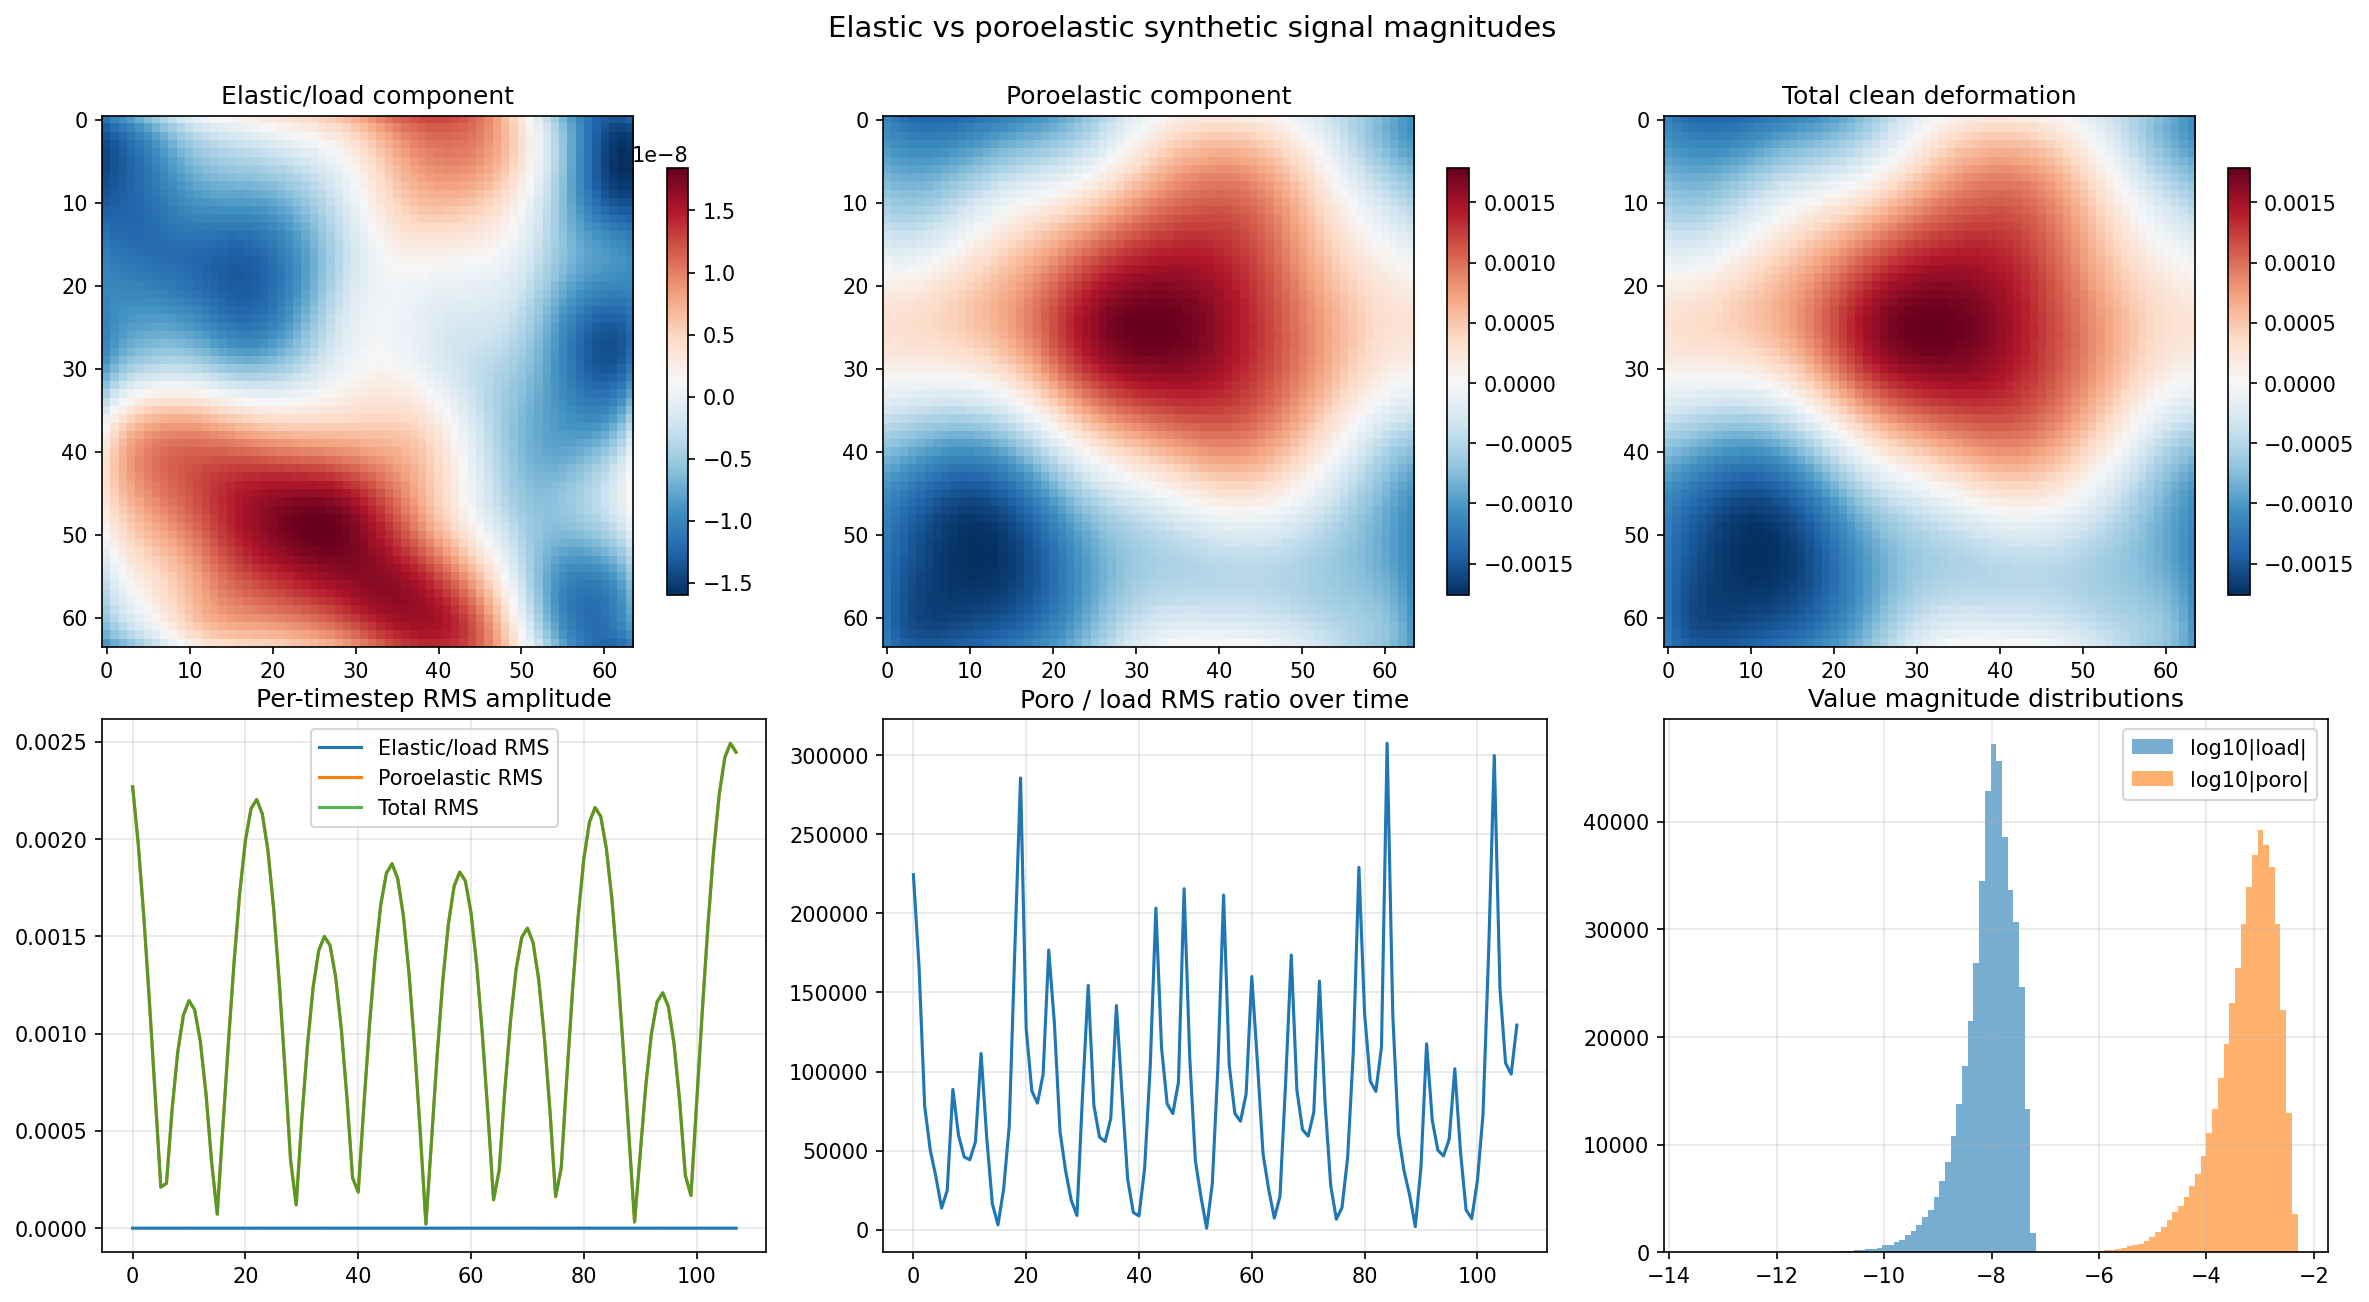

In [1]:
# Embedded figure: elastic vs poroelastic magnitude mismatch


### Figure 2. Architecture Progression Toward The Clean Candidate

This figure shows the move from earlier branch-aware/frequency-separated baselines to the dual-decoder clean anchor.


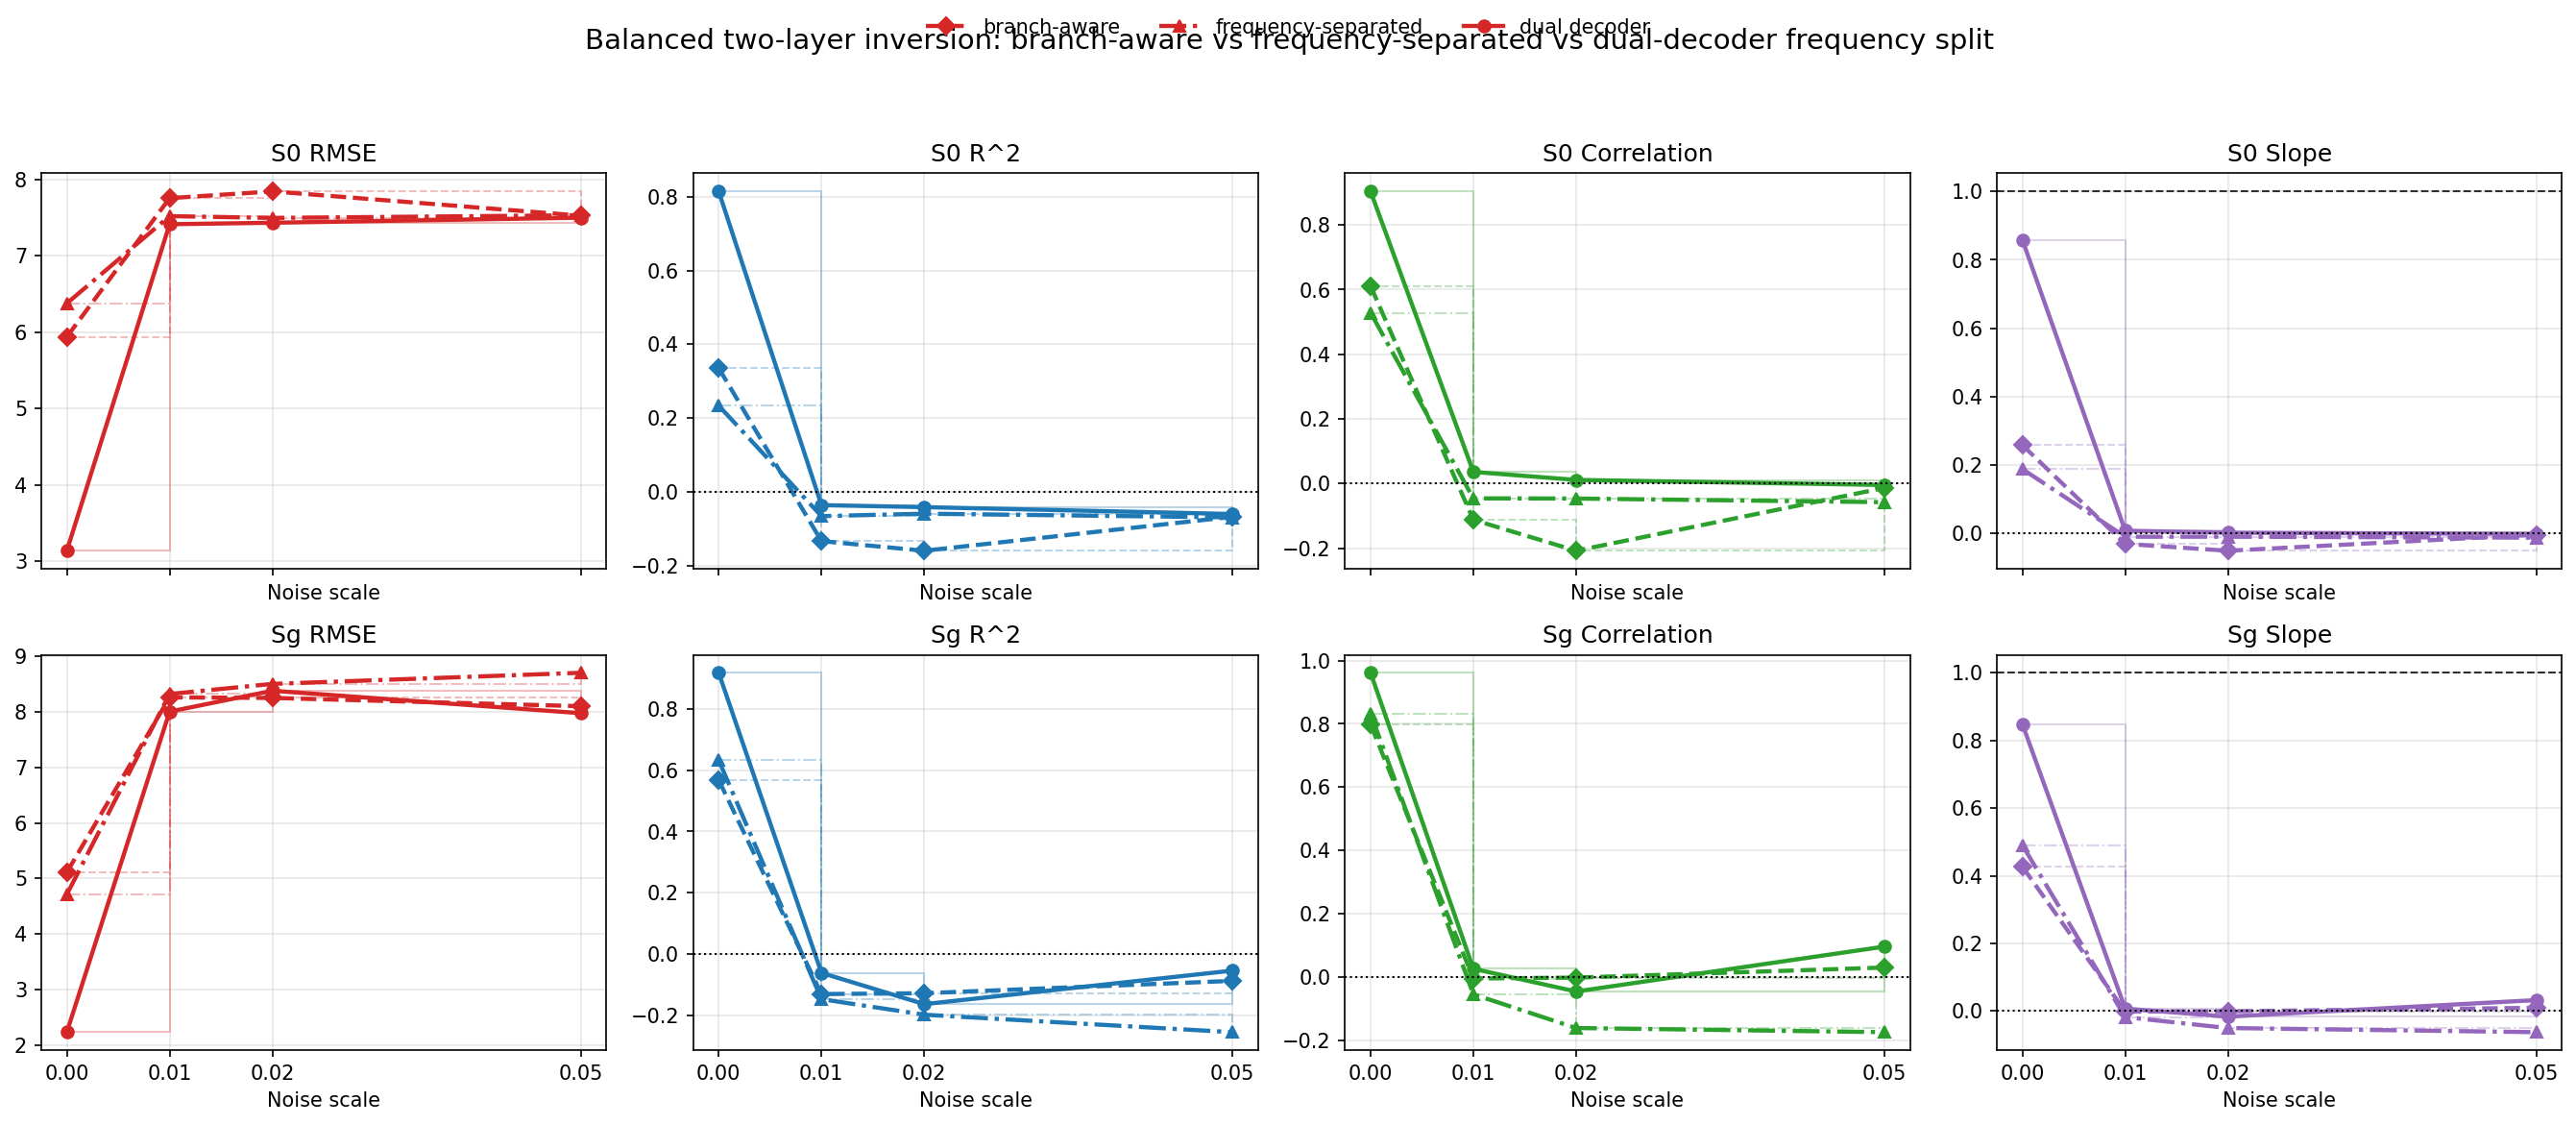

In [1]:
# Embedded figure: dual-decoder progression


### Figure 3. Best Robustness Branch Comparison

This figure shows the current best direct-conditioned refinement path, ending in the hybrid noisy-stage `Sg`-emphasis model.


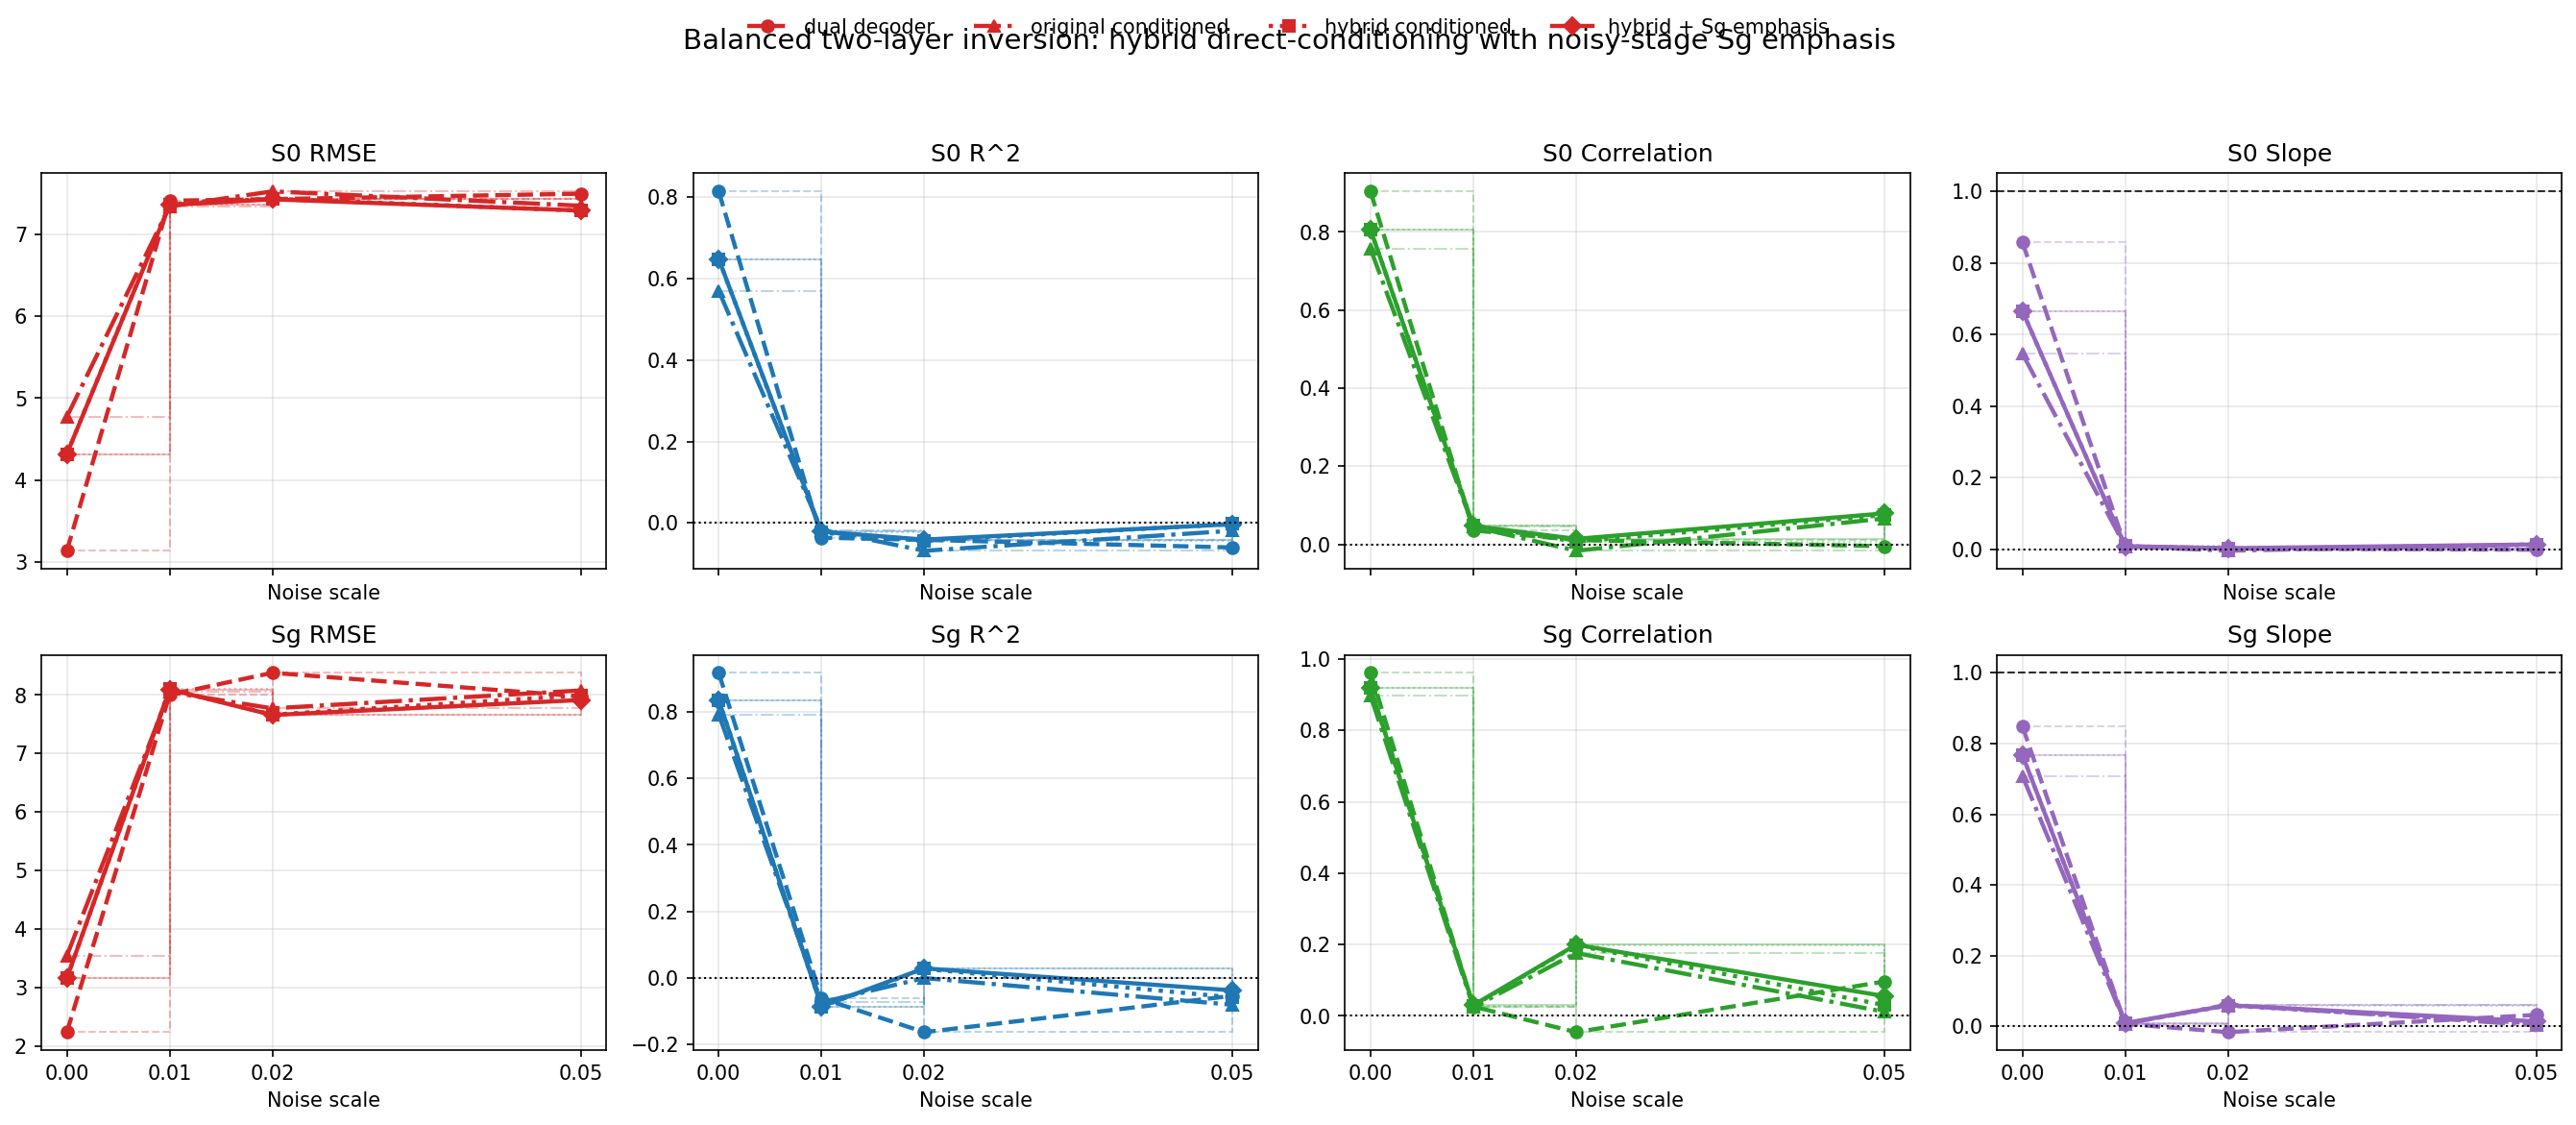

In [1]:
# Embedded figure: best robustness branch comparison


### Figure 4. Multi-Seed Stability Of The Final Candidate Branch

This figure shows the mean and spread across seeds for the final candidate branch. It is the key figure for the current limitation statement.


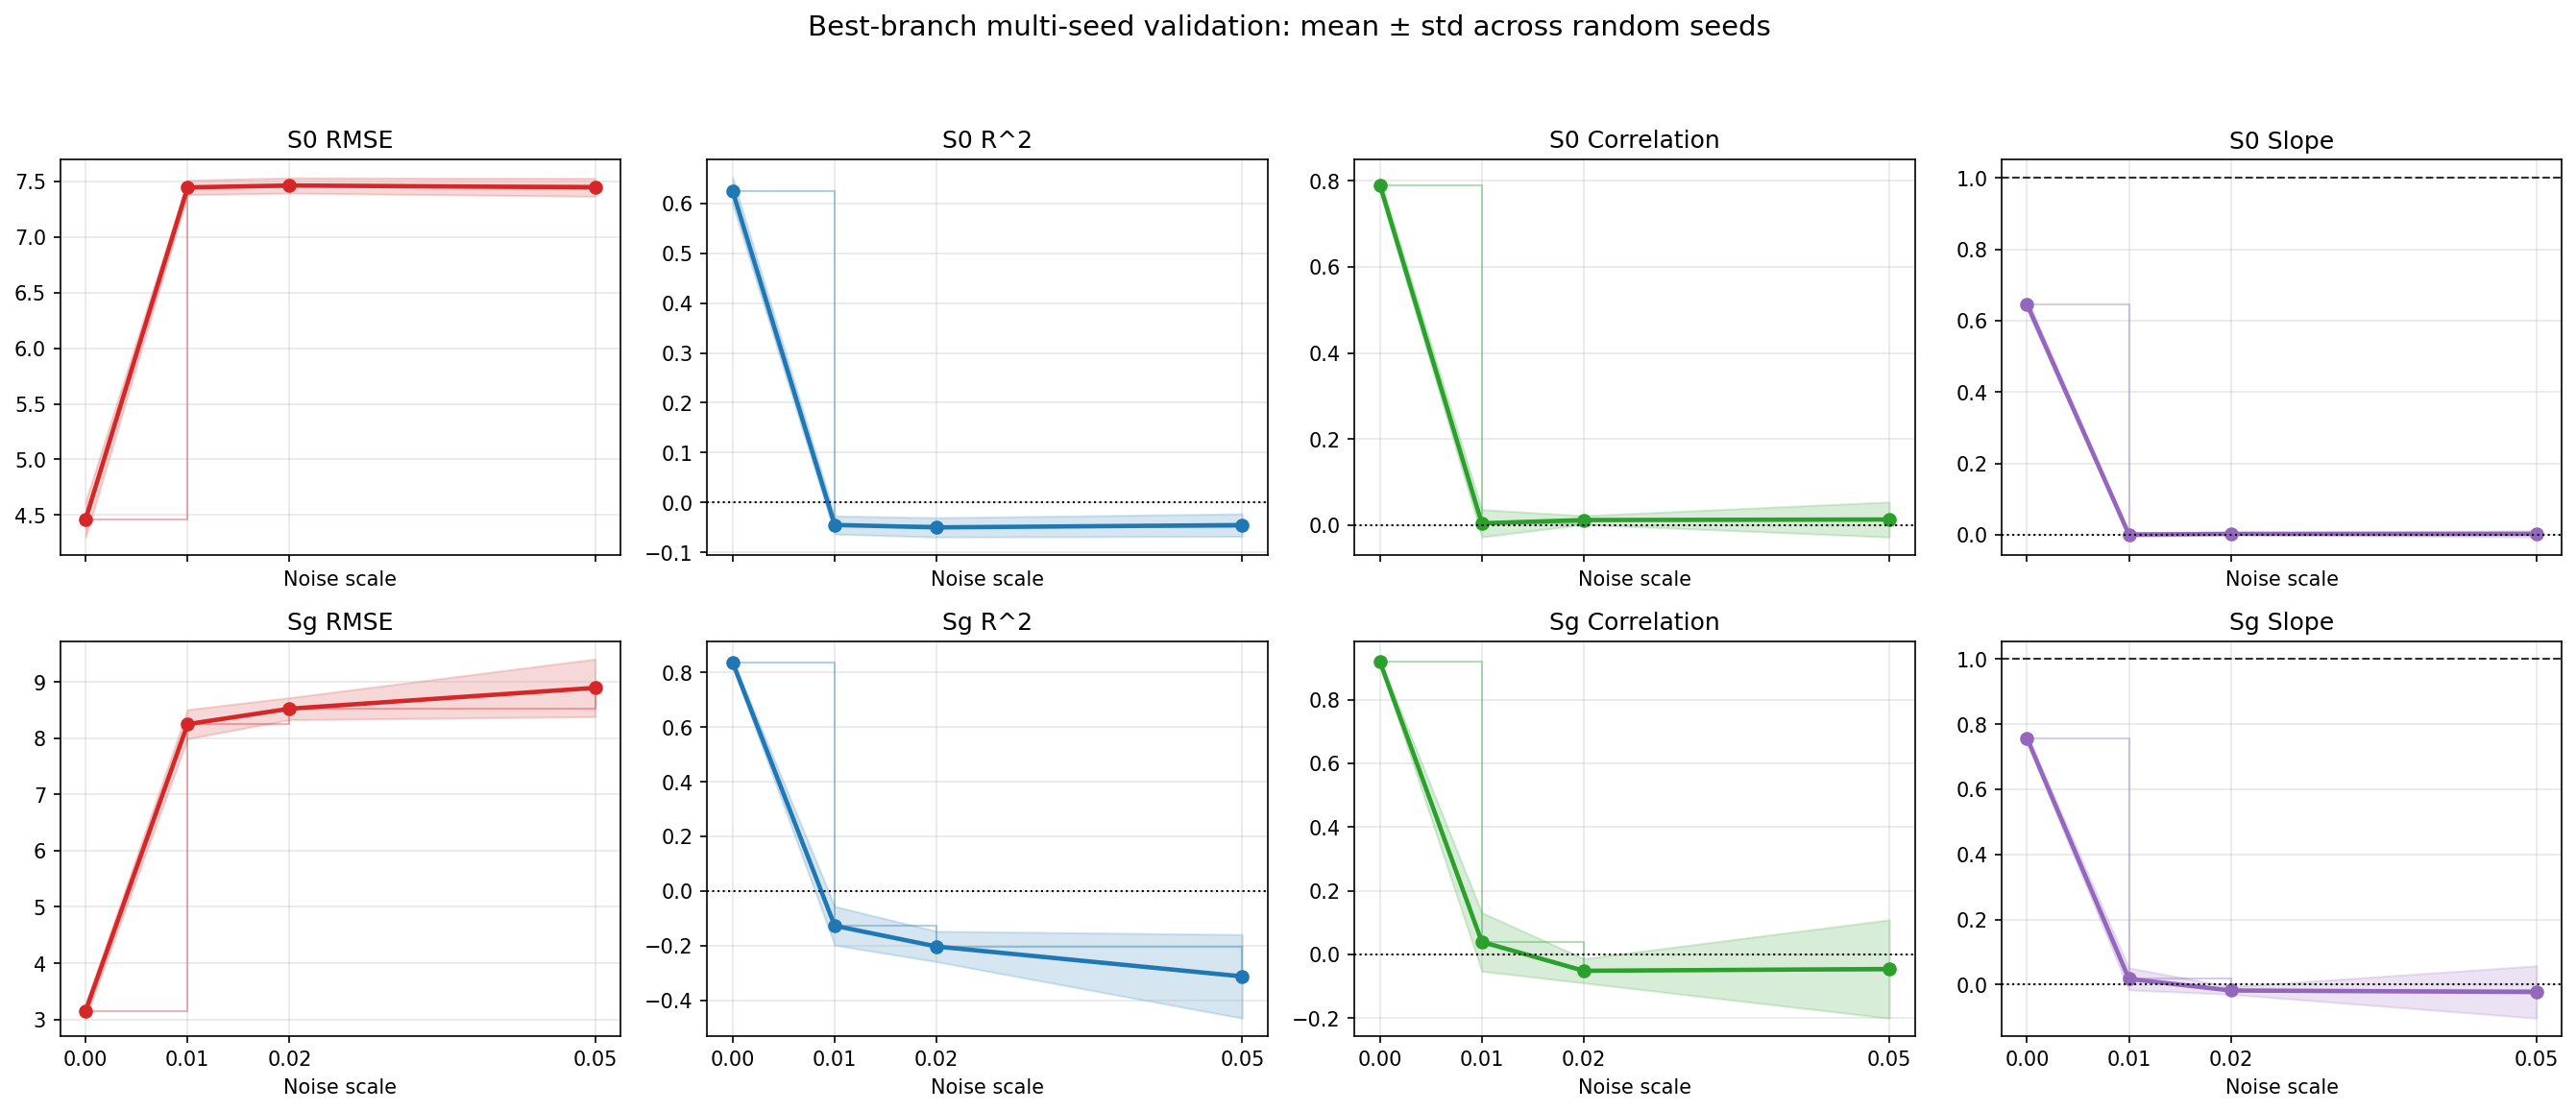

In [1]:
# Embedded figure: multi-seed validation of the final candidate branch


### Appendix Figure. EMA Final Round

Optional appendix figure documenting the final stabilization attempt and why it was not adopted.


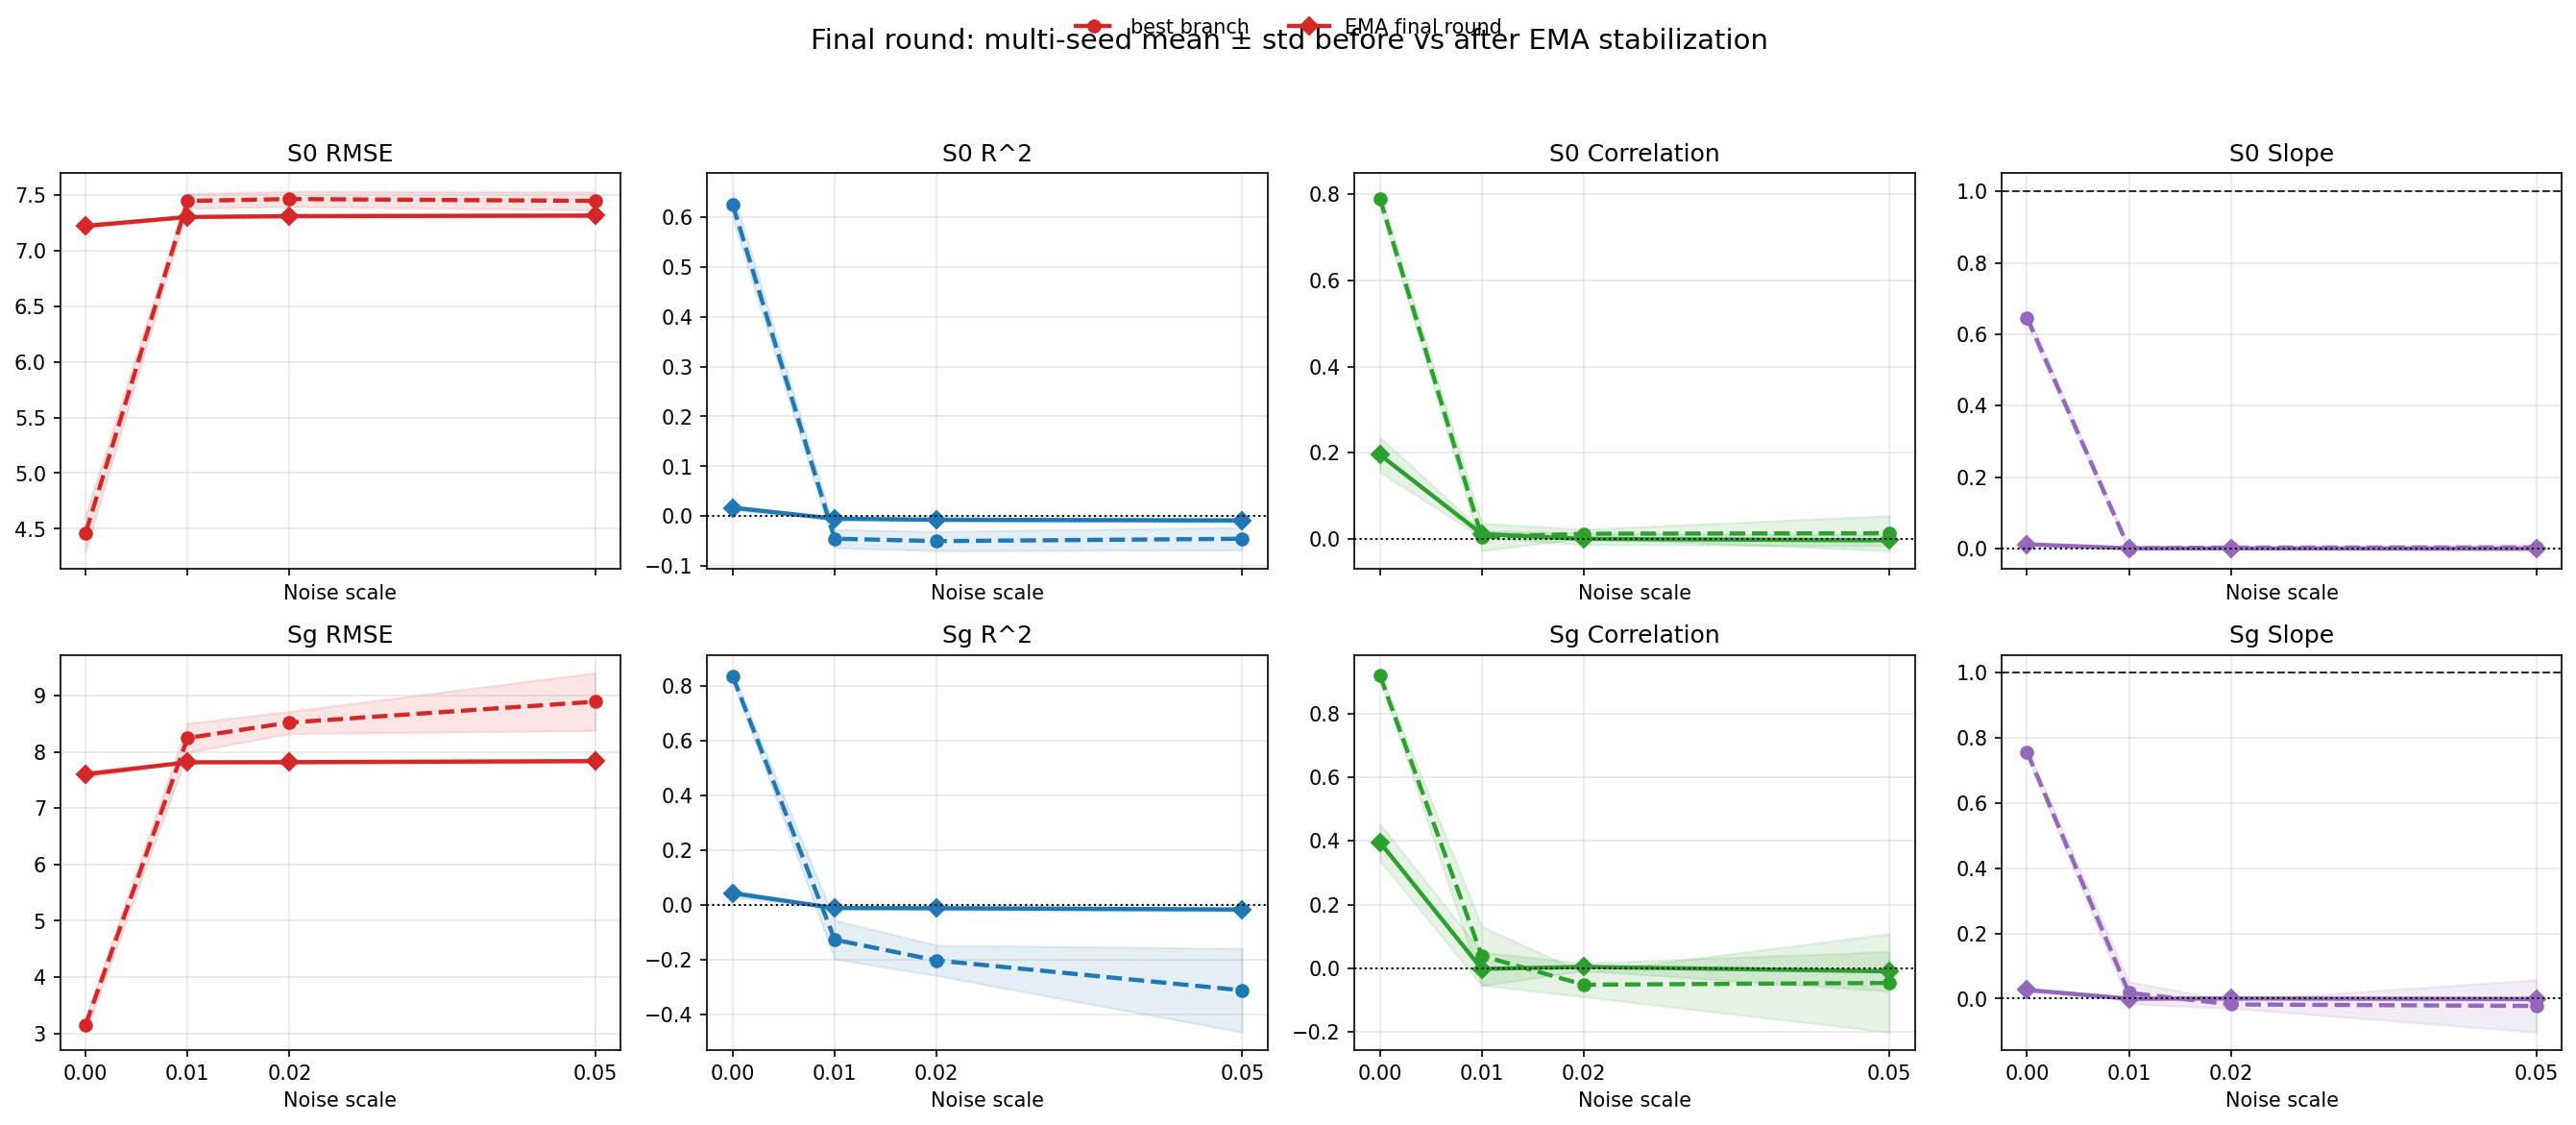

In [1]:
# Embedded figure: EMA final-round comparison
